# Classificação Compra / Lateral / Venda: mini-índice (WIN), M5

## O que eu quero fazer aqui

A ideia é simples de enunciar: **olhar para o que o mini-índice fez entre 09:00 e 10:59 e
tentar adivinhar o que ele vai fazer entre 11:00 e 11:59.** A resposta é uma de três
classes, **Compra**, **Venda** ou **Lateral**.

Se isso funcionar, a operação é direta: entro às 11:00 e saio às 12:00, ou quando a operação atingir o alvo de pontos. Se o modelo disse
Compra, compro. Se disse Venda, vendo. Se disse Lateral, fico de fora e não pago custo
nenhum.

## O vocabulário deste projeto

| Termo | O que quer dizer aqui |
|---|---|
| **Janela de entrada** | o período que o modelo observa: 09:00–10:59 |
| **Janela-alvo** | o período que ele tenta prever: 11:00–11:59 |
| **Compra / Venda / Lateral** | as três respostas possíveis. *Lateral* significa **não operar**, e isso é uma resposta útil, porque não operar não paga custo |
| **Drawdown** | a maior queda acumulada entre um topo e o vale seguinte da curva de resultado. Mede o pior momento de quem está seguindo a estratégia |
| **Baseline** | o modelo trivial que chuta sempre a classe mais comum, sem olhar para nada. É o piso: qualquer modelo de verdade precisa bater esse número para ter servido para alguma coisa |
| **Holdout** | um pedaço do fim da série que eu separo **antes de tudo** e não toco em nada, nem para escolher features, nem para comparar modelos. Fica guardado para uma única medição no fim. É a única parte dos dados sobre a qual eu não tomei nenhuma decisão |
| **Fold** | cada uma das repetições em que os dados são divididos para testar. Aqui são 5, sempre cronológicas: treina no passado, testa no trecho seguinte, avança |
| **Walk-forward** | a validação feita nesses folds cronológicos, imitando como o modelo seria usado de verdade, sempre prevendo dias posteriores aos do treino |

> **Uma convenção que vale avisar.** Falo em **pontos** o tempo todo, e converto para reais só
> na avaliação econômica. Com três classes, o acaso acerta 1/3, então acurácia de 40% pode
> soar boa e ainda assim perder dinheiro, dependendo de quanto se ganha nos acertos e se perde
> nos erros. É por isso que o notebook nunca reporta acurácia sozinha.

---

## Por que esses horários

Escolhi essa janela por causa de dois momentos que concentram quase toda a energia do
pregão brasileiro:

**A abertura, das 09:00 às 10:00.** É o momento mais volátil do dia. O preço de abertura
sai do leilão e, quando o mercado começa a girar, tudo que aconteceu desde o fechamento
anterior é digerido de uma vez. Spread largo, movimento rápido, volume altíssimo. É aqui
que compradores e vendedores brigam para definir a direção do dia.

**A abertura americana, às 11:30.** O Ibovespa é fortemente correlacionado com o S&P 500.
Quando Nova York abre, entra uma injeção nova de volume e volatilidade no nosso mercado,
e o que os americanos fazem na primeira hora costuma arrastar o mini-índice junto. Muito
operador espera exatamente esse momento para confirmar posição.

A janela das 11:00 fica no meio desses dois eventos. É o período em que o mercado já
mostrou a cara na abertura e ainda está se posicionando para o que vem de Nova York.

---

## A janela que escolhi: 09:00–10:59 → 11:00–11:59

Antes de fixar essa configuração eu testei sete combinações diferentes de janela de
entrada e janela-alvo. **O teste rodou apenas nos primeiros 80% dos dias**, deixando os
250 dias finais intocados, se eu usasse a base inteira para escolher a janela, o holdout
já nasceria contaminado.

Para a comparação ser justa entre janelas de tamanhos diferentes, usei rótulo por tercis
(quantis móveis, só com dados passados). Isso deixa as classes equilibradas por
construção e mantém o baseline sempre perto de 1/3.

**O que cada coluna quer dizer:**

| Coluna | O que é |
|---|---|
| **n** | quantos pregões sobraram naquela configuração. Cada janela descarta dias diferentes, um dia em que faltou uma vela na janela de entrada ou na janela-alvo sai da conta, e o rótulo por tercis ainda gasta os primeiros dias como aquecimento dos quantis móveis |
| **Baseline** | a acurácia de chutar sempre a classe mais comum. Com tercis fica perto de 1/3, como esperado |
| **Modelo** | a acurácia do modelo naquela configuração, medida em walk-forward |
| **Ganho** | `Modelo − Baseline`. É a coluna que importa: quanto o modelo acrescentou sobre o chute trivial. Acurácia sozinha não diz nada: 0,361 parece razoável, mas contra um baseline de 0,322 sobra pouco |
| **dp entre folds** | o desvio-padrão do ganho **entre os 5 folds**. Mede se o ganho aparece de forma parecida em todos os períodos ou se ele vem de um trecho só |

| Entrada | Alvo | n | Baseline | Modelo | Ganho | dp entre folds |
|---|---|---|---|---|---|---|
| **09:00–10:59** | **11:00–11:59** | 912 | 0,322 | 0,337 | **+0,014** | 0,044 |
| 09:00–11:29 | 11:30–12:29 | 912 | 0,346 | 0,345 | −0,001 | 0,092 |
| 10:00–10:59 | 11:00–11:59 | 890 | 0,319 | 0,341 | +0,022 | 0,040 |
| 09:00–09:59 | 10:00–10:59 | 890 | 0,338 | 0,319 | −0,019 | 0,022 |
| 09:00–10:59 | 11:00–12:59 | 912 | 0,346 | 0,355 | +0,009 | 0,037 |
| 09:00–11:59 | 12:00–12:59 | 912 | 0,293 | 0,329 | **+0,036** | 0,093 |
| 09:00–10:59 | 15:00–15:59 | 912 | 0,355 | 0,324 | −0,032 | 0,048 |

*(reproduzido no Anexo A.5, que roda em ~60 s)*

### De onde vem a variação do ganho

Cada coluna da tabela acima tem **sete valores**, um por janela. A **amplitude** é a distância
entre o maior e o menor deles, `max − min` sobre a coluna inteira. Não é desvio-padrão: é a
largura bruta da faixa em que a coluna se moveu.

| Coluna | Menor valor | Maior valor | Amplitude = max − min |
|---|---:|---:|---:|
| Baseline | 0,293 | 0,355 | **0,062** |
| Modelo | 0,319 | 0,355 | 0,036 |
| Ganho | −0,032 | +0,036 | 0,067 |

```
amplitude(baseline)  =  0,355  −  0,293      =  0,062
amplitude(modelo)    =  0,355  −  0,319      =  0,036
amplitude(ganho)     = +0,036  − (−0,032)    =  0,067
```

O menor baseline (0,293) é o da janela 09:00–11:59 → 12:00–12:59 e o maior (0,355) é o da
09:00–10:59 → 15:00–15:59. A conta é feita sobre os valores em precisão cheia; a tabela
mostra-os arredondados a três casas, e aqui os dois coincidem.

**O baseline varia quase o dobro do modelo.** E há uma terceira coisa estranha na tabela: o
**ganho oscila mais que qualquer uma das duas colunas que o formam** (0,067 contra 0,062 e
0,036). Isso não é erro. Como `ganho = modelo − baseline`, vale a identidade da variância:

```
Var(A − B)  =  Var(A)  +  Var(B)  −  2·Cov(A, B)
```

O termo que subtrai só é grande quando as duas séries andam juntas. Aqui elas quase não andam
(correlação +0,130, `p = 0,781`), então `Cov` é pequena e as duas variações **se somam** em vez
de se cancelarem. É o mesmo mecanismo do Anexo A.4, com o sinal ao contrário: lá, entre folds,
as duas séries são fortemente correlacionadas e a pareação **corta** 49% do ruído; aqui, entre
janelas, não há correlação para cortar nada.

E a correlação entre baseline e ganho é o que decide a leitura da tabela. As duas são
correlações de **Pearson** calculadas sobre os sete pares de valores das colunas
(`scipy.stats.pearsonr`), e o `p` é o bilateral do próprio teste, com `n = 7`
*(reproduzido no Anexo A.5)*:

```
correlação  baseline × ganho   =  −0,843   (p = 0,017)
correlação  baseline × modelo  =  +0,130   (p = 0,781)
```

É o baseline afundar que produz o ganho, não o modelo acertar. A acurácia do modelo mal se
move entre configurações (0,319 a 0,355); quem se mexe é o piso.

**Por que o baseline varia tanto, se o rótulo por tercis deveria dar 1/3?** Porque tercis
deixa as classes quase empatadas (0,31 a 0,36), e com empate a classe majoritária vira quase
sorteio. O `DummyClassifier` aprende a majoritária do treino e a aplica num fold de teste onde
frequentemente **outra** classe é a mais comum:

Contando, para cada janela, em quantos dos 5 folds a classe majoritária do **treino** deixa
de ser a majoritária do **teste** *(reproduzido no Anexo A.5)*:

| Janela | Folds em que a majoritária muda entre treino e teste |
|---|---|
| 09:00–10:59 → 11:00–11:59 | **4 de 5** |
| 09:00–11:59 → 12:00–12:59 | **4 de 5** |
| 09:00–10:59 → 15:00–15:59 | 3 de 5 |

E abrindo a janela de maior ganho fold a fold, onde **teto** é o que o baseline teria acertado
se soubesse a majoritária real do teste *(também no Anexo A.5)*:

| Fold | Maj. treino | Maj. teste | Baseline | Teto |
|---|---|---|---:|---:|
| 1 | Lateral | Compra | 0,250 | 0,382 |
| **2** | **Venda** | **Lateral** | **0,257** | **0,441** |
| 3 | Lateral | Lateral | 0,368 | 0,368 |
| 4 | Lateral | Venda | 0,355 | 0,362 |
| 5 | Lateral | Compra | 0,237 | 0,408 |

No fold 2 o baseline entrega 0,257 contra um teto de 0,441: **18 pontos percentuais perdidos
só por estar preso na classe errada**. No fold 3, o único em que a majoritária não muda,
baseline e teto coincidem exatamente (0,368). Não é o modelo que subiu, é o piso que caiu.

**E isso inverte a ordem da tabela.** Se eu usar 1/3 como piso, que é o que o tercis promete
por construção, em vez da majoritária do treino. São duas subtrações diferentes sobre a mesma
acurácia do modelo:

```
ganho contra o Dummy  =  acurácia do modelo  −  acurácia do baseline majoritário
ganho contra 1/3      =  acurácia do modelo  −  0,3333
```

As **sete** janelas, com a acurácia do modelo à vista para a conta poder ser conferida
*(reproduzido no Anexo A.5)*:

| Janela | Modelo | Baseline | Ganho vs Dummy | Ganho vs 1/3 |
|---|---:|---:|---:|---:|
| 09:00–10:59 → 11:00–11:59 | 0,337 | 0,322 | +0,014 | +0,004 |
| 09:00–11:29 → 11:30–12:29 | 0,345 | 0,346 | −0,001 | +0,011 |
| 10:00–10:59 → 11:00–11:59 | 0,341 | 0,319 | +0,022 | +0,007 |
| 09:00–09:59 → 10:00–10:59 | 0,319 | 0,338 | −0,019 | −0,014 |
| 09:00–10:59 → 11:00–12:59 | 0,355 | 0,346 | +0,009 | +0,022 |
| **09:00–11:59 → 12:00–12:59** | **0,329** | **0,293** | **+0,036** | **−0,004** |
| 09:00–10:59 → 15:00–15:59 | 0,324 | 0,355 | −0,032 | −0,010 |

**A linha de maior ganho vira negativa**, e a aritmética mostra exatamente por quê:

```
janela 09:00–11:59 → 12:00–12:59

  contra o Dummy :  0,329  −  0,293   =  +0,036     <- parecia o melhor da tabela
  contra 1/3     :  0,329  −  0,3333  =  −0,004     <- o modelo está ABAIXO do piso teórico
```

O modelo dessa janela acerta **0,329**, que é *menos* do que os 0,3333 que se consegue
chutando qualquer classe fixa num rótulo por tercis. O +0,036 não veio de o modelo acertar
muito: veio de o baseline dela ter entregado **0,293**, o pior dos sete. Era o piso mais
azarado, não o teto mais alto.

> **Consequência metodológica.** Quando as classes estão quase empatadas, o baseline
> majoritário fica instável e o "ganho sobre o baseline" passa a medir o azar do piso. Nesse
> regime, o baseline estratificado ou o piso teórico de 1/3 são comparações mais honestas.
>
> O mesmo mecanismo aparece na seção *Teste 1, a acurácia contra o limiar que eu mesmo fixei*, onde 36% do ganho do holdout vinha de deriva da classe
> majoritária. *(reproduzido no Anexo A.5)*

---

Olhando essa tabela, a tentação é pegar a linha de maior ganho (+0,036) e declarar
vencedora. **Não vou fazer isso, e a razão é aritmética.**

Os sete ganhos têm média **+0,004** e desvio-padrão **0,022**. As duas contas, com os
valores da tabela:

```
g = (+0,014, −0,001, +0,022, −0,019, +0,009, +0,036, −0,032)

média  =  Σg / n  =  (+0,014 −0,001 +0,022 −0,019 +0,009 +0,036 −0,032) / 7
       =  +0,0290 / 7  =  +0,0041  ->  +0,004

soma dos quadrados dos desvios = 0,003261

dp  =  raiz( Σ(g − média)² / n )  =  raiz( 0,003261 / 7 )  =  0,0216  ->  0,022
```

> **Atenção a uma pegadinha aqui.** Esse 0,020 é o desvio-padrão **populacional**, dividido
> por `n`. O teste t logo abaixo usa o desvio **amostral**, dividido por `n − 1`, que dá
> **0,023**. Quem tentar reproduzir o `t` partindo de 0,022 chega a um número diferente.

### "É o que se espera se nenhuma janela tiver sinal"

Vale abrir essa frase, porque ela carrega a ideia central da seção.

**Uma janela sem sinal não produz ganho igual a zero.** Produz um ganho *aleatório em torno de
zero*. A diferença é tudo.

### O baseline em detalhe: por que tudo é medido contra ele

O glossário acima define o baseline em uma linha. Vale abrir, porque **todo número de
ganho deste notebook é uma subtração contra ele**, se ele estiver mal entendido, a
tabela abaixo não quer dizer nada.

A regra dele é: **ignore completamente as features e responda sempre a classe que foi mais
comum no treino.** Nada de olhar volume, RSI, gap ou o que quer que seja. Ele conta as classes
no período de treino, guarda qual apareceu mais, e devolve essa mesma resposta para todos os
dias do teste. Em código é literalmente isto:

```python
# o que o DummyClassifier(strategy="most_frequent") faz por dentro
def fit(self, X, y):
    self.resposta = y.value_counts().idxmax()   # "Venda", neste projeto
    return self                                  # X é ignorado

def predict(self, X):
    return [self.resposta] * len(X)              # a mesma resposta para todo dia
```

**Por que isso importa: acurácia sozinha engana.** As três classes não são igualmente
frequentes. No conjunto de trabalho a distribuição é Venda 348, Compra 317, Lateral 311 dias.
Então o chute fixo em "Venda" já acerta:

```
acurácia do baseline  =  dias de Venda / total  ≈  0,352
```

**Um modelo com 35% de acurácia nas três classes não aprendeu absolutamente nada.** Ele
empatou com quem não olha para o dado. É por isso que eu nunca reporto acurácia sem o
baseline ao lado, e por que a coluna que importa nas tabelas é o **ganho**:

```
ganho  =  acurácia do modelo  −  acurácia do baseline
```

Medido **nos mesmos dias**, com os dois tendo visto **o mesmo período de treino**. Isso se
chama **comparação pareada**, e vale destrinchar por que faz diferença, porque não é
formalidade.

**O problema: os períodos do mercado não são igualmente difíceis.** Um trimestre calmo é mais
previsível que um de pânico, e isso vale para qualquer modelo. Se eu medisse o modelo num
período e o baseline em outro, a diferença entre os dois números diria mais sobre qual período
calhou para cada um do que sobre o modelo.

**A prova de que os períodos diferem mesmo está no próprio baseline.** Olhe a acurácia dele
fold a fold, lembrando que ele **não olha uma única feature**:

| Fold | Baseline | XGBoost | Ganho |
|---|---:|---:|---:|
| 1 | 0,3642 | 0,4259 | +0,0617 |
| 2 | 0,3827 | 0,3580 | −0,0247 |
| 3 | 0,3827 | 0,3580 | −0,0247 |
| 4 | 0,3210 | 0,3333 | +0,0123 |
| 5 | 0,3086 | 0,2778 | −0,0309 |
| **média** | **0,3519** | **0,3506** | **−0,0012** |

*(a tabela inteira, fold a fold, é reproduzida no Anexo A.4)*

O baseline oscila de **30,9% a 38,3%**, uma amplitude de 7,4 pontos percentuais. Como ele
ignora as features por construção, **essa variação inteira é dificuldade do período**, não
habilidade. E repare no fold 1: os dois sobem juntos, baseline 0,3642 e modelo 0,4259. No
fold 5, caem juntos, 0,3086 e 0,2778.

**As duas séries andam juntas, e é isso que a subtração aproveita.** A correlação de Pearson
entre as duas colunas de 5 valores é de **+0,680** *(Anexo A.4)*. Quando duas quantidades
correlacionadas são subtraídas, a parte comum vai embora:

```
Var(A − B)  =  Var(A) + Var(B) − 2·Cov(A, B)

            =  0,002846 + 0,001219 − 2 × 0,001267  =  0,001532
```

O termo `−2·Cov` é o ganho da pareação. Os dois desvios saem direto dessa conta: o pareado é
a raiz da variância acima; o "se independentes" refaz a mesma soma **sem** o termo da
covariância *(ambos no Anexo A.4)*:

```
dp pareado           =  raiz( 0,001532 )                    =  0,0391
dp se independentes  =  raiz( 0,002846 + 0,001219 )         =  0,0638   ->  63% maior
```

**A pareação corta 39% do ruído do ganho.**

**E o contrafactual fecha o argumento.** Simulei 20.000 comparações erradas, pegando a
acurácia do modelo num fold e a do baseline em *outro*:

| | Ganho médio | Desvio |
|---|---:|---:|
| Pareado, como eu faço | −0,0012 | **0,0391** |
| Folds trocados | −0,0009 | **0,0620** |

**A média quase não muda, o ruído cresce 59%.** É a diferença entre um efeito que dá para
discutir e um que some no erro de medição. Como o ganho aqui é de −0,0012, com dp de 0,0391
ele já é indistinguível de zero; com 0,0620 seria ainda mais. *(reproduzido no Anexo A.4)*

> **Por que os dois precisam ver o mesmo treino, além dos mesmos dias de teste.** Se o
> baseline fosse ajustado na série inteira e o modelo só no fold, o baseline saberia a
> frequência das classes de um período que o modelo ainda não viu. A comparação deixaria de
> medir "quanto as features acrescentam" e passaria a medir "quem teve acesso a mais dado".

**E por que o baseline também é "treinado"?** Porque senão a comparação seria injusta. Ele
recebe o mesmo `fit` no mesmo fold de treino que o modelo de verdade, e é avaliado nos mesmos
dias de teste. A única coisa que ele aprende é qual classe era mais comum naquele trecho.
Isso o torna um adversário honesto: ele tem acesso à mesma informação de frequência que o
modelo tem, só não tem acesso às features.

> **Um detalhe que vira problema mais adiante.** Como ele fica preso na classe majoritária
> **do treino**, se a classe mais comum mudar entre treino e teste ele leva uma penalidade que
> não tem nada a ver com o modelo ser bom. Foi o que aconteceu no holdout: a majoritária virou
> de Venda para Compra, e isso sozinho respondeu por **36% do ganho aparente**. A conta está na
> seção *Teste 1, a acurácia contra o limiar que eu mesmo fixei*.

**Por que dois baselines e não um.** O majoritário é o piso da *acurácia*, mas é péssimo em
F1-macro, e por um motivo mecânico: como ele só prevê uma classe, as outras duas ficam com
recall zero.

```
para a classe prevista:   precisão ≈ 0,352 · recall = 1,0
                          F1 = 2·p·r/(p+r) = 2·0,352/1,352 = 0,521
para as outras duas:      nunca são previstas -> recall = 0 -> F1 = 0

macro F1 = (0,521 + 0 + 0) / 3 = 0,174     (a tabela da seção *Modelos tabulares* reporta 0,1733)
```

Um modelo ruim que ao menos distribui palpites entre as três classes passa desses 0,17 sem
esforço, o que faria o F1-macro parecer uma vitória. Por isso existe o **baseline
estratificado**, que sorteia as respostas na proporção das classes do treino: ele dá 0,337 de
F1-macro, que é o piso realista para essa métrica.

| Baseline | Acurácia | F1-macro | Serve de piso para |
|---|---:|---:|---|
| Majoritário | 0,3519 | 0,1733 | **acurácia** |
| Estratificado | 0,3401 | 0,3371 | **F1-macro** |

---

Com isso claro, volto ao ponto. O que acontece quando eu meço uma janela que não prevê nada
é o seguinte. O modelo chuta, e o baseline chuta. Os dois erram muito. Mas eles não erram nos mesmos dias: por puro acaso, às
vezes o modelo acerta um punhado de dias que o baseline errou, e o ganho sai positivo; às
vezes é o contrário, e sai negativo. **Se eu repetisse a medição em outro pedaço da série, o
número seria outro.** Zero é o centro em torno do qual ele oscila, não o valor que ele assume.

Olhe os sete ganhos com isso em mente:

```
+0,014   −0,001   +0,022   −0,019   +0,009   +0,036   −0,032
```

Alguns positivos, outros negativos, espalhados em torno de zero. É essa a assinatura de sete
medições sem sinal nenhum. E dá para testar formalmente, com um teste t de uma amostra
contra zero:

```
s   =  raiz( Σ(g − média)² / (n − 1) )  =  raiz( 0,003261 / 6 )  =  0,0233

EP  =  s / raiz(n)  =  0,0233 / raiz(7)  =  0,0233 / 2,6458  =  0,0088

t   =  (média − 0) / EP  =  +0,0041 / 0,0088  =  0,47       com gl = n − 1 = 6

p   =  2 × P( T₆ > |0,47| )  =  0,65
```

**Não há como afirmar que o conjunto difere de zero.**

**Como seria se uma janela tivesse sinal de verdade?** Ela sairia *destacada do pelotão*, e
não apenas na frente dele. Algo como seis valores entre −0,02 e +0,02 e um sétimo em +0,10.
Não é o caso aqui. Medindo quanto o maior valor se afasta dos outros seis:

```
maior           =  +0,036
os outros seis  =  (+0,014, −0,001, +0,022, −0,019, +0,009, −0,032)

média do resto  =  −0,007 / 6  =  −0,0011
dp do resto     =  raiz( 0,002129 / 5 )  =  0,0206

z  =  (maior − média do resto) / dp do resto
   =  (+0,036 − (−0,0011)) / 0,0206  =  +0,0371 / 0,0206  =  1,78
```

**1,78 desvios**, ou seja, dentro da nuvem. Se o maior fosse os +0,10 do exemplo, o mesmo
cálculo daria mais de **4 desvios**, e aí sim seria um valor destacado do pelotão.

### Por que o maior de sete é grande mesmo sem sinal

Agora o ponto que decide a escolha da janela: **quando se testam sete coisas, o maior
resultado é grande por construção**, mesmo que todas sejam ruído.

A razão é simples quando se enuncia: cada janela testada é **mais uma chance de dar sorte**.
Com uma janela só, o resultado tende ao centro da distribuição, ou seja, a zero. Com sete, eu
fico com o melhor de sete tentativas, e o melhor de sete quase nunca é o valor central.

Dá para colocar número nisso. Sorteando sete valores de uma distribuição centrada em zero, o
**maior deles** sai, na média, a **1,35 desvios-padrão acima de zero**. Não é constante mágica
nem regra decorada: é resultado clássico de estatísticas de ordem [David & Nagaraja, 2003],
e o raciocínio de comparar o melhor de várias tentativas contra o acaso é o de
[White, 2000] *(ver a seção Referências)*.

Ele é o valor esperado do máximo de sete sorteios, e sai de uma simulação de
três linhas.

Como aqui o desvio é 0,022:

```
1,35 × 0,0216 = 0,0291   ->   perto de +0,029
```

**Mesmo que as sete janelas fossem todas inúteis, eu esperaria ver um "melhor resultado" de
mais ou menos +0,029**, só pelo fato de ter olhado sete.

E esse fator cresce com o número de testes, sempre devagar:

| Quantas coisas eu testo | Máximo esperado (em desvios) | Com desvio 0,022 |
|---:|---:|---:|
| 1 | 0,00 | 0,000 |
| 3 | 0,85 | +0,018 |
| 5 | 1,16 | +0,025 |
| **7** | **1,35** | **+0,029** |
| 20 | 1,87 | +0,040 |
| 100 | 2,51 | +0,054 |

*(a coluna do meio é simulada no Anexo A.1)*

A leitura prática: **o número que impressiona não é o ganho, é o ganho comparado ao que o
acaso produziria com aquela mesma quantidade de tentativas.** Quem testa 100 configurações e
reporta a melhor precisa bater +0,054 só para empatar com o nada.

O maior valor que eu observei foi **+0,036**. Simulando 200.000 rodadas de sete sorteios de
puro ruído:

```
E[máximo de 7 sorteios]     = +0,029
P(máximo de 7 >= +0,036)    =  0,304
```
*(reproduzido no Anexo A.1)*

**Em 30% das vezes, sete janelas sem sinal nenhum produzem um máximo pelo menos tão grande
quanto o que eu vi.** Quase um em cada três. O observado (+0,036) fica um quarto de desvio
acima do esperado sob ruído puro (+0,029), diferença que nenhum teste separaria. Escolher a
janela por esse critério seria escolher o sorteio mais sortudo e chamá-lo de descoberta.

> Este é o mesmo raciocínio do teste de permutação da seção *Teste de permutação*, só que aplicado à escolha da
> janela em vez de à escolha do modelo. Toda vez que se compara várias opções e se reporta a
> melhor, é preciso perguntar qual seria a melhor **se nenhuma prestasse**.

### E nenhuma delas é estável

Repare que em **todas** as linhas o desvio-padrão entre folds é do mesmo tamanho ou maior que
o próprio ganho. Vale destrinchar o que isso significa, porque não é óbvio.

O ganho de cada linha não é uma medição, é a **média de cinco medições**, uma por fold, cada
uma num período diferente da série. O `dp entre folds` diz o quanto essas cinco discordam
entre si.

Tome a primeira linha: ganho médio **+0,014**, com desvio **0,044** entre folds.

**O espalhamento é três vezes a média.** Em estatística isso tem nome, **coeficiente de
variação igual a 3,1**, e significa que a incerteza sobre o efeito é o triplo do efeito.

O que dá para concluir daí, com cuidado:

Se os cinco folds se espalham de forma aproximadamente normal em torno de +0,014 com desvio
0,044, então **zero fica a um terço de desvio abaixo da média**. Um terço de desvio abaixo,
numa curva em sino, deixa cerca de **37%** da distribuição. Com cinco folds, isso dá:

| | |
|---|---|
| Chance de um fold qualquer sair negativo | ~37% |
| Folds negativos esperados, entre os 5 | ~1,9 |
| Chance de **pelo menos um** dos 5 ser negativo | **90%** |

*(reproduzido no Anexo A.2)*

E aqui não é nem probabilidade: com média +0,014, o maior desvio possível entre cinco folds
**todos** não-negativos é 0,031, que sai de jogar a soma inteira num fold só e deixar os
outros quatro em zero. Como o desvio observado é 0,044, **algum fold negativo é obrigatório**,
por aritmética.

O problema é esse: **um efeito cujo espalhamento é o triplo do próprio tamanho não é um efeito
no qual se pode confiar.** A média dos cinco folds fica a 0,7 erro padrão de zero, e isso
supondo que os cinco folds sejam medições comparáveis, o que eles não são, porque cada um
cobre um período diferente do mercado.

É a diferença entre estas duas situações, que dão **a mesma média** e leituras opostas:

| Situação | Os cinco folds | Desvio | Leitura |
|---|---|---|---|
| Estável | +0,012, +0,016, +0,013, +0,017, +0,012 | 0,002 | o ganho aparece em todo período, dá para acreditar |
| **O que eu tenho** | +0,07, −0,03, +0,04, −0,03, +0,02 | 0,044 | o efeito **troca de sinal** conforme o trecho |

A segunda é a minha, e nela a média positiva é um artefato de misturar períodos bons e ruins.
Não há nada ali que se possa esperar que continue valendo no mês que vem, e o mês que vem é o
único período que interessa para operar.

### A última linha é um controle, e ela é a mais importante da tabela

Tentar prever as **15:00–15:59** a partir da manhã é um teste que eu montei esperando que
falhasse. Entre o fim da janela de entrada (10:59) e o começo do alvo (15:00) existem **quatro
horas de pregão**, quatro horas de notícia, de fluxo estrangeiro, de abertura americana e de
tudo mais. Qualquer informação que a manhã carregasse já teria sido absorvida pelo preço
muito antes das 15:00.

Deu **−0,032**: o modelo saiu **pior** que chutar sempre a classe mais comum.

**Por que isso tinha que dar negativo.** O modelo aprende no treino padrões que não existem no
teste, decora ruído de um período e aplica num período onde ele não vale. Quando não há sinal
nenhum para aprender, é isso que sobra: o modelo troca o chute seguro (a classe majoritária)
por palpites errados, e fica abaixo do baseline. Ganho zero seria o resultado de um modelo que
desistisse; ganho negativo é o de um modelo que tentou e errou. Com ruído puro, o segundo é o
esperado.

**Por que isso valida o arcabouço de teste.** Aqui está o raciocínio que faz esta ultima da tabela linha valer
mais que as outras seis.

Suponha que houvesse um vazamento no meu código, a informação do alvo escapando para dentro
das features, ou o rótulo sendo construído com dados que o modelo não deveria ver, ou a
divisão treino/teste embaralhando as datas. Um vazamento desses **não escolhe** qual
configuração beneficiar: ele produziria ganho positivo em **todas** as linhas, inclusive nesta.

Como o controle deu negativo, sei que o arcabouço **consegue devolver "não há sinal" quando
não há sinal**. Ele não é uma máquina de fabricar ganho.

E é isso que me deixa ler as outras seis linhas com alguma confiança: os números pequenos que
aparecem lá são pequenos **porque o sinal é pequeno ou inexistente**, não porque o código está
quebrado de um jeito que infla tudo. Sem esta linha, eu não teria como distinguir "resultado
fraco" de "medição errada", as duas coisas produzem tabelas parecidas.

> É a mesma ideia de um controle negativo em experimento de laboratório: rodar o procedimento
> inteiro numa amostra que **sabidamente** não tem o que está sendo procurado. Se der positivo
> ali, o problema é o procedimento, não a amostra.

**Então por que 09:00–10:59 → 11:00–11:59?** Por três motivos que não dependem do
resultado:

1. **Não é a linha de maior ganho, e isso é de propósito.** O maior ganho da tabela é o da
   `09:00–11:59 → 12:00–12:59` (+0,036), mas o espalhamento entre folds dela é **0,093**,
   quase três vezes o próprio ganho: o resultado depende quase inteiramente de qual trecho da
   série caiu em qual fold. A minha também não é a de menor espalhamento (0,044, contra 0,037
   e 0,040 de duas linhas vizinhas), e nem precisa ser: como o teste t das sete dá `p = 0,65`,
   a tabela não separa nenhuma das opções, e escolher pela coluna do ganho seria premiar o
   sorteio mais sortudo. Os dois motivos abaixo é que decidem.
2. **Preserva a tese econômica**: Não sobra intervalo entre o que o modelo vê e o momento em
   que eu teria de agir.
3. **Não custa amostra.** Ela empata com todas as outras que começam às 09:00. Somando as
   sete configurações, a que rende menos dias fica com **1.213 pregões** e a que rende mais
  com **1.221**: uma diferença de **8 pregões**, que sobre 1.213 dá **0,7%**. Para
   dimensionar, 8 pregões são menos de duas semanas de bolsa, e espalhados nos 5 folds do
   walk-forward viram **menos de 2 dias por fold**. Nenhuma decisão muda por causa disso, e
   é por isso que amostra não entra como critério de desempate entre estas janelas. *(reproduzido no Anexo A.3)*

---

## O holdout: o que é, para que serve, e o que eu fiz com o meu

Esta é a peça mais importante do projeto inteiro, e a mais fácil de entender errado. Vou
construir do começo.

### O problema que ele resolve

Eu preciso responder uma pergunta: **o meu modelo funciona?**

A resposta óbvia é "testar em dados que ele não viu no treino". Isso é o básico, e o notebook
faz isso o tempo todo: a validação cronológica da seção *Protocolo de avaliação* treina num pedaço da série e mede no
pedaço seguinte, que o modelo nunca viu. Cinco vezes, avançando no tempo.

Só que isso **não basta**, e o motivo é sutil.

### Por que testar em dado novo não é suficiente

O modelo nunca viu aqueles dias. Mas **eu vi.**

Cada vez que eu olhei um resultado da validação e mudei alguma coisa por causa dele, eu usei
aquele dado para tomar uma decisão. E foram dezenas de decisões:

| Decisão | Quantas alternativas eu comparei olhando os mesmos dados |
|---|---|
| Janela de horário | 7 configurações |
| Esquema de rótulo | 3 (`fixo`, `vol`, `tercis`) |
| Quais features usar | 7 subconjuntos, mais 20 sorteios de controle |
| Qual modelo | 11, dos baselines à TCN |
| Balanceamento de classes | 3 estratégias |
| Hiperparâmetros das redes | L2 e taxa de aprendizado, varridos |
| Abstenção por confiança | 4 limiares |

Depois de tudo isso, aqueles dias deixaram de ser independentes de mim. Eles ajudaram a
**construir** o modelo, mesmo que nenhum deles tenha entrado no treino. O resultado da
validação passa a ser otimista por construção, e não há como saber de quanto.

Isso não é trapaça, é como se desenvolve modelo. O problema é que, no fim, eu preciso de um
número em que eu mesmo possa acreditar.

### Simulado e prova final

Um simulado eu refaço quantas vezes quiser. Errei, estudo, refaço. Ele é ferramenta de
aprendizado, e a nota dele não vale nada como medida do que eu sei, justamente porque eu o
usei para aprender.

A prova final é outra coisa: eu a vejo **uma vez**, no fim, sem ter estudado por ela.

Agora, se ao estudar eu tivesse acesso às questões da prova final, estudaria mais aquilo. A
nota subiria, e **deixaria de medir o que eu sei para medir o quanto eu vi a prova antes.**
Nenhuma parte disso exige má-fé; basta ter olhado.

**O holdout é a prova final.** A validação cronológica são os simulados.

### O que é, na prática

Um holdout é um pedaço dos dados que eu **separo no começo de tudo** e **não toco em nada**
até o fim do projeto.

Aqui foram os **244 pregões finais**, de 2025-08-18 a 2026-08-12, tirados dos 1.220
disponíveis. Sobraram 976 para trabalhar.

```
|<------------- 976 dias de trabalho ------------->|<-- 244 do holdout -->|
2021-09-10                              2025-08-15 | 2025-08-18 2026-08-12
                                                   |
   tudo aconteceu aqui:                            |   nada aconteceu aqui
   escolha de janela, de rótulo, de features,      |   até o fim de tudo
   comparação de 11 modelos, ajuste de rede        |
```

Três detalhes que fazem esse desenho funcionar:

1. **Ele é o pedaço final da série, não uma amostra aleatória.** Em série temporal, sortear
   dias espalhados deixaria o modelo treinar com terças-feiras de 2026 para prever
   segundas-feiras de 2024. O holdout tem que ser o *futuro* em relação ao treino, porque é
   assim que o modelo seria usado de verdade.
2. **A separação acontece na seção *Protocolo de avaliação*, antes de qualquer decisão.** Não adianta separar depois
   de já ter escolhido as features olhando a base inteira.
3. **Ele não entra em nada.** Nem no cálculo das médias móveis, nem no ajuste do
   `StandardScaler`, nem na comparação de modelos.

### Como ele é usado

Uma vez só, no fim, com tudo já decidido. O procedimento inteiro é:

1. Fecho todas as decisões usando **apenas** os 976 dias de trabalho
2. **Escrevo antes o que vou considerar sucesso.** Isto é pré-registro, no sentido de
   [Nosek et al., 2018] *(ver a seção Referências)*: a regra existe para que a decisão não seja tomada depois
   de ver o número. No caso, a tabela de decisão da seção *Veredito*,
   feita antes de abrir: ganho abaixo de 8,4 pontos percentuais conta como nulo
3. Treino o modelo escolhido nos 976 dias inteiros
4. Aplico nos 244 dias do holdout, e leio o número
5. **Acabou.** Seja qual for o resultado, ele é o resultado

#### Por que o passo 2 é o que decide tudo

Escrever o critério antes de olhar parece burocracia. Não é. É a única defesa contra um
mecanismo que funciona mesmo em quem está de boa-fé, inclusive eu.

**O que acontece quando se vê o número primeiro.** Ninguém escolhe um critério e o aplica ao
resultado. Olha-se o resultado e **constrói-se uma justificativa**. Ninguém mente nesse
processo, todo mundo raciocina. O problema é que o raciocínio acontece *depois*, já sabendo
qual conclusão seria agradável, e o critério vira um parâmetro livre que a mão ajusta sozinha.

Veja o cardápio que o meu holdout ofereceu. **Todas as linhas abaixo são verdadeiras**, e
descrevem o mesmo resultado:

*(reproduzido no Anexo A.25)*

| Como eu poderia apresentar | O número |
|---|---|
| ganho absoluto sobre o baseline | +0,4 p.p. |
| ganho relativo ao baseline | +1,3% |
| acurácia do modelo contra a do baseline | 32,8% contra 32,4% |
| **taxa de acerto das operações** | **51%** |
| **resultado financeiro** | **R$ 668 em 244 pregões** |

Nenhuma é falsa. As duas primeiras linhas dizem o que aconteceu e não animam ninguém. As
duas últimas descrevem exatamente o mesmo resultado e soam como uma estratégia que funciona:
"acerta mais da metade das operações e fecha o ano no lucro". Se eu escolhesse a última linha
depois de ver o número, estaria dizendo a verdade, e estaria enganando.

**E há o caso que fecha o argumento.** O teste de significância admite duas formas, e elas dão
respostas opostas. O `z` é o ganho do holdout dividido pelo erro padrão da acurácia, e os dois
`p` saem da normal padrão *(reproduzido no Anexo A.25; a derivação completa está na a seção Teste 1, a acurácia contra o limiar que eu mesmo fixei)*:

```
z = 0,14      p unilateral = 0,446   ->  não significativo
              p bilateral  = 0,891   ->  não significativo
```

Aqui as duas concordam, porque o ganho ficou tão perto de zero que nenhuma escolha de teste o
salvaria. Mas repare no mecanismo, que independe deste número: a escolha entre unilateral e
bilateral muda o `p` por um fator de dois, e existe uma faixa inteira de resultados, os que
caem entre 0,025 e 0,05 no unilateral, em que ela sozinha decide se o trabalho é "publicável".
Escolhida depois de ver que o ganho saiu positivo, ela converte um resultado nulo num
resultado anunciável. Quem faz isso raramente percebe que fez, e é por isso que a decisão
precisa estar tomada quando o envelope ainda está fechado.

**Uma regra só vale se ela puder te machucar.** O limiar de 8,4 p.p. da seção *O que ele consegue e o que não consegue responder* saiu de uma
conta de poder estatístico feita antes de abrir, e era desconfortável: o walk-forward vinha
dando 0,07 p.p., mais de cem vezes menos que o limiar. Fazendo a conta na direção inversa,
**se o efeito real fosse aqueles 0,07 p.p., a chance de o holdout conseguir detectá-lo seria
de 5,3%** *(o cálculo de poder está no Anexo A.24, o mesmo que produz o limiar de 8,4 p.p.)*,
ou seja, praticamente a taxa de falso positivo do próprio teste: um holdout desse tamanho não
enxerga um efeito desse tamanho, ponto.

Escrever aquele limiar, portanto, era aceitar de antemão que o projeto muito provavelmente
terminaria em nulo. Foi isso que deu força à regra: uma regra com a qual eu ficaria satisfeito
em qualquer cenário não seria uma regra, seria um enfeite.

**Descoberta e resultado não são a mesma coisa.** Um *resultado* é o que a medição diz, seja o
que for, e não promete nada além de si. Uma *descoberta* é a afirmação de que algo novo é
verdade, e carrega uma promessa implícita: a de que vai se sustentar quando outra pessoa
repetir.

Os 51% de acerto e os R$ 668 dariam uma descoberta confortável de anunciar e impossível de
sustentar. Como resultado, eles são apenas o que são, e os três testes da seção *Teste 1, a
acurácia contra o limiar que eu mesmo fixei* em diante mostram por quê.

### Por que uma olhada só

Porque a segunda olhada custa a independência que a primeira tinha.

Se eu abro, não gosto, mudo um hiperparâmetro e abro de novo, agora estou escolhendo entre
duas medições no mesmo conjunto, e vou ficar com a melhor. Repita três ou quatro vezes e o
holdout virou mais um conjunto de validação, com o agravante de que agora eu *acredito* nele.
É pior do que não ter holdout nenhum.

É a mesma aritmética da tabela das sete janelas, lá em cima: **o melhor de várias tentativas é
grande por construção.** Vale para janelas, para modelos, e para tentativas no holdout.

A flag `EXECUTAR_HOLDOUT` nasce em `False` para eu não abrir por distração.

### O que eu planejei, e o que eu fiz

**O plano era abrir com `09:00–11:59 → 12:00–12:59`**, não por ter dado o maior ganho no
teste de janelas, mas por ser a única alternativa com justificativa causal independente do
resultado: nessa configuração a janela de entrada **inclui as 11:30**, a abertura americana.
Se o mecanismo descrito no começo deste notebook for real, é ali que ele apareceria.

**A janela usada foi a de treino, `09:00–10:59 → 11:00–11:59`.** O motivo da divergência:

Um holdout responde *"este modelo, nesta configuração, funciona em dado que ninguém tocou?"*.
Trocar a janela na hora de abrir responde outra coisa: *"esta configuração diferente funciona
neste período diferente?"*. São duas mudanças ao mesmo tempo, e se o resultado desse positivo
eu não saberia atribuí-lo a nenhuma das duas. Um teste que não distingue as próprias causas
não serve de teste.

### O que essa decisão custou

**A hipótese das 11:30 perdeu o holdout limpo dela.** Ela continua viva como a variante V3 da
seção *O que vem depois*, mas agora só pode ser avaliada em validação cronológica, que é evidência mais fraca,
porque é o mesmo conjunto onde dezenas de outras decisões já foram tomadas.

E não há um segundo holdout para gastar: com 1.220 pregões no total, tirar mais 244 deixaria o
treino pequeno demais. Essa limitação é real, é consequência do tamanho da série, e precisa
constar em qualquer coisa que eu publique.

> **O que ficou valendo.** O holdout foi aberto uma vez, com a regra de decisão escrita antes,
> e o resultado está na seção *Holdout final* com os três testes que o desmontam. Nada foi ajustado depois.
> O que veio de lá é o que ficou.


---

## Como conectar as velas na rede: duas ideias

Antes de sair treinando, vale pensar em como os dados de cada vela devem entrar na rede.
Existem duas formas bem diferentes de montar isso, e elas levam a modelos com capacidades
muito distintas.

### Teste 1: Mapeamento Direto Vela-Neurônio

A primeira ideia é amarrar cada vela a um neurônio específico da camada oculta:

- Dados da vela 1 → neurônio 1
- Dados da vela 2 → neurônio 2
- ...
- Dados da vela 24 → neurônio 24

Cada neurônio da camada oculta fica **especializado num único instante de tempo**. O
neurônio 1 só aprende sobre o que aconteceu entre 09:00 e 09:05. O neurônio 2, sobre
09:05–09:10. E assim por diante.

**O que essa arquitetura tem de bom:**

- **Interpretabilidade.** Dá para olhar os pesos e ver qual vela pesou mais na decisão.
- **Simplicidade.** A conexão é esparsa e direta, com poucos parâmetros.

**O que ela tem de ruim, e é grave:**

- **Perde as relações cruzadas.** Se um padrão depende da vela 3 *junto com* a vela 8,
  essa rede não consegue capturar isso na camada oculta, porque nenhum neurônio enxerga
  as duas ao mesmo tempo. A combinação só acontece lá na saída.
- **É rígida.** O modelo assume que a posição da vela no tempo é a característica mais
  importante. Ele não reconhece o mesmo padrão, um engolfo de alta, por exemplo, se ele
  acontecer às 09:30 ou às 10:30, porque seriam neurônios diferentes processando.

### Teste 2: Arquitetura Totalmente Conectada (Dense)

A segunda ideia é o oposto: **cada feature de entrada conecta a todos os neurônios** da
camada oculta. É a camada densa clássica.

Aqui cada neurônio oculto enxerga **todas as features de todas as velas ao mesmo tempo**.
Ele pode dar peso diferente para cada uma e, com isso, montar detectores de padrões que
envolvem várias velas.

**O que ela tem de bom:**

- **Aprende relações complexas.** Um neurônio pode aprender a ativar quando "o volume da
  vela 2 for alto E o fechamento da vela 5 romper a máxima da vela 4". Ele consegue
  correlacionar qualquer ponto da janela com qualquer outro.
- **É flexível.** Não impõe nenhuma restrição sobre como as features devem interagir.

**O que ela tem de ruim:**

- **Overfitting.** Muito mais parâmetros significa muito mais liberdade para decorar o
  treino em vez de aprender. Exige regularização de verdade: dropout, L1/L2.
- **Menos interpretável.** Fica difícil saber qual combinação levou a cada decisão.

### Qual abordagem é melhor?

Para o meu problema, a **Arquitetura 2 é claramente superior**.

O motivo é que padrão de mercado quase nunca depende de uma vela isolada. Ele é uma
**sequência de eventos**. Um sinal de compra pode ser uma queda, seguida de indecisão,
seguida de uma vela forte de alta com volume crescente. A Arquitetura 1 teria dificuldade
em ligar esses três momentos; a Arquitetura 2 foi feita para isso.

Um exemplo concreto. Um padrão de reversão que se desenrola em três velas:

1. **Vela 3**: queda forte, pressão vendedora.
2. **Vela 4**: doji, indecisão, volume baixo.
3. **Vela 5**: alta forte que engole a queda da vela 3, com volume crescente.

A condição de compra não está em nenhuma vela sozinha, está na **combinação sequencial**
das três.

Na **Arquitetura 1**, o neurônio 3 aprende "queda forte", o neurônio 4 aprende
"indecisão", o neurônio 5 aprende "alta forte". Só que nenhum deles sabe que os três
eventos aconteceram em sequência. A única camada que recebe todos os sinais juntos é a de
saída, que geralmente é uma camada linear simples com softmax. Sobra para ela a tarefa
difícil de deduzir "o neurônio 3 ativou, o 4 ativou fraco, o 5 ativou forte, logo isso é
COMPRA". A inteligência de extrair padrão deveria estar nas camadas ocultas, não ali.

Na **Arquitetura 2**, um único neurônio recebe os dados de todas as velas e pode ajustar
os pesos para virar um detector daquele padrão específico: peso alto no que indica queda
na vela 3, peso alto no que indica indecisão na vela 4, peso altíssimo no que indica alta
com volume na vela 5, e peso perto de zero no resto. Esse neurônio vira um **"detector de
reversão de três velas"** e manda um sinal limpo para a saída.

### Colocar mais camadas ocultas no Teste 1 resolve?

Essa foi a primeira coisa que eu pensei, e **não resolve**.

Parece que sim. Se eu empilhar uma segunda camada oculta totalmente conectada em cima da
primeira, cada neurônio dessa segunda camada passa a receber sinal de todos os neurônios
da primeira. Não é isso que eu queria?

**É, mas de uma forma bem limitada.** O neurônio da segunda camada não vê os dados brutos
da vela 1 e da vela 2. Ele vê a **interpretação** que o neurônio 1.1 fez da vela 1 e a
**interpretação** que o neurônio 1.2 fez da vela 2.

Cada neurônio da primeira camada funciona como um filtro isolado: processa a própria vela
e passa adiante um único número resumido, a ativação dele. Todo o detalhe bruto já foi
descartado nesse caminho. A relação entre a abertura e a máxima daquela vela específica,
por exemplo, não existe mais.

É telefone sem fio. Na Arquitetura 2, um detetive tem acesso a **todas as fotos da cena**
e pode procurar pistas que ligam uma foto à outra. Na Arquitetura 1 com camadas extras,
são 24 detetives juniores, cada um olha **uma foto** e escreve um resumo de uma linha;
depois um detetive sênior lê só os 24 resumos e tenta resolver o caso. Ele nunca vai poder
conferir se a sombra na foto 3 bate com o objeto na foto 8.

Empilhar camadas não devolve informação que já foi jogada fora na primeira camada.

**Conclusão prática:** o que eu preciso é de neurônios com **campo receptivo amplo desde o
início**. É o que a camada densa faz, e é o que CNNs e redes recorrentes fazem de forma
ainda mais especializada, a CNN varre a sequência procurando o mesmo padrão em qualquer
posição (resolvendo a rigidez do Teste 1), e a LSTM carrega estado ao longo do tempo. Por
isso o zoo de modelos mais abaixo tem MLP, CNN 1D, LSTM e TCN, e não a Arquitetura 1.

---

## Etapas do projeto

**1. Pré-processamento.** Padronização com `StandardScaler`, imprescindível para rede
neural, e sempre ajustado só no treino de cada fold, nunca na base toda.

**2. Engenharia de features.** Em vez de jogar OHLCV cru, eu resumo cada janela em 17 features que descrevem direção, amplitude, volatilidade, convicção, volume e momento.
Tamanho de corpo, sombras, médias móveis, RSI, MACD entram aí.

**3. Rotulagem.** Usando **exclusivamente** a janela-alvo. Nenhuma informação da janela de
entrada pode encostar no rótulo, se encostar, o modelo aprende a "colar" e o resultado
vira ilusão.

**4. Arquitetura.** Camadas densas com ReLU, dropout no meio para segurar overfitting,
saída com 3 neurônios e softmax. Otimizador Adam, perda `categorical_crossentropy`.

**5. Validação.** Divisão **cronológica**, sempre. Walk-forward para escolher e comparar,
holdout final para o veredito. Nunca embaralhar série temporal.

**6. Veredito.** Comparar tudo contra baseline e medir o resultado em dinheiro, não só em
acurácia.

---

## As regras que eu sigo neste notebook

Aprendi na marra que sem essas regras o resultado é sempre bonito e sempre falso:

| Regra | Por quê |
|---|---|
| Divisão sempre cronológica | Embaralhar série temporal deixa o modelo ver o futuro |
| Baseline em todo teste | 35% de acurácia parece bom até se ver que chutar a classe majoritária dá 35% |
| No mínimo 10 sementes | Uma rodada só mede a sorte da inicialização, não o modelo |
| Scaler ajustado dentro do fold | Ajustar na base toda vaza estatística do futuro para o treino |
| Holdout aberto uma vez | Segunda olhada já é treino |
| Resultado em pontos e reais | 40% de acerto em 3 classes ainda pode perder dinheiro depois do custo |
| Teste de permutação | Distingue sinal de sorte, que é a única pergunta que importa |

---

## Roteiro deste notebook

O notebook roda de cima para baixo. Cada seção depende da anterior, e a ordem não é
arbitrária, ela existe para que as decisões metodológicas aconteçam **antes** de eu ver
qualquer resultado.

| Seção | O que acontece | Código? |
|---|---|---|
| Configuração | Todo parâmetro que muda entre experimentos, num lugar só | sim |
| Dados | Carrega o M5 e valida período, horário e buracos | sim |
| Features | Resume cada janela de 24 velas em 17 números, mais 5 de contexto diário | sim |
| Rotulagem | Define o que é Compra, Lateral e Venda, só com a janela-alvo | sim |
| Protocolo | **Separa o holdout** e monta o walk-forward, o multi-semente e a permutação | sim |
| Tratamento | Normalização, outliers e balanceamento, o que fazer e o que não fazer | sim |
| Exploratória | Informação mútua com régua de ruído, Kruskal-Wallis e redundância | sim |
| Tabulares | Baselines, regressão logística, SVM, florestas e boosting | sim |
| Sequenciais | MLP, CNN 1D, LSTM e TCN sobre o tensor de velas | sim |
| Config. das redes | Cada hiperparâmetro das redes e por que aquele valor | não |
| Estatística | Permutação (tem sinal?) e Friedman/Nemenyi (algum é melhor?) | sim |
| Econômico | Backtest out-of-fold com custo, em pontos e em reais | sim |
| Holdout | O veredito, aberto uma única vez | sim |
| Registro | Grava resultado e configuração em disco | sim |
| Conclusão | O que ficou estabelecido, com os números que sustentam | não |
| O que vem depois | As cinco variantes pré-registradas | não |
| Observações | Achados laterais que contrariaram expectativa | não |
| Anexo A | Reproduz cada número citado no texto, com código executável | sim |
| Referências | Bibliografia de cada método e teste usado, por seção | não |

As seções *Configuração das redes*, *Conclusão*, *O que vem depois*, *Observações* e
*Referências* são só texto, não têm célula de código. As demais alternam explicação e
execução, e o notebook roda de cima para baixo sem pular nada.

A seção *Protocolo de avaliação* é a mais importante e é fácil passar batido por ela. É lá que o holdout é
separado, antes de eu treinar qualquer coisa, antes de escolher features, antes de olhar
qualquer número. Se essa separação acontecesse depois, todo o resto viraria teatro.


---
## Configuração

Todo parâmetro que muda de um experimento para outro está nesta célula, e **em nenhum
outro lugar**. Nada é redefinido mais para baixo.

Isso não é organização por gosto, é o que faz uma rodada ser reproduzível. Se eu quiser
repetir exatamente um resultado daqui a três meses, basta esta célula mais o arquivo de
dados. E é isso que a seção *Registro da rodada* grava em disco junto com os números.

> **As exceções** são `N_SEMENTES_DL` e o bloco `DL_*` de hiperparâmetros das redes,
> que ficam na seção *Modelos sequenciais (deep learning)* junto das arquiteturas que os usam, cada valor está
> justificado na seção *Configuração das redes: cada peça e por que este valor*. `N_SEMENTES_DL` está lá, que fica na seção *Modelos sequenciais (deep learning)*. Ela está lá de propósito
> porque é a que mais impacta o tempo de execução, e eu quero decidir o valor dela olhando
> para a célula que vai rodar.

---

### Bloco 1, dados

```python
ARQUIVO = "WIN$N_M5_BRUTO_COMPLETO.csv"
```

O CSV de origem. Espera o **formato interno do projeto**: separador `;`, coluna
`datetime` como índice, e as colunas `Abertura`, `Fechamento`, `Maxima`, `Minima`,
`Volume_Real`, `Volume_Tick`.

**Atenção:** não é o arquivo que o MetaTrader exporta direto. A exportação bruta vem
separada por tabulação, com cabeçalhos `<DATE>`, `<TIME>`, `<OPEN>`… Apontar `ARQUIVO`
para ela quebra o carregamento na seção *Carregamento e validação dos dados*. É preciso converter antes.

Trocar este arquivo é como se troca de timeframe. A seção anterior explica por que o M5 é
a escolha certa aqui e por que M1, M30 e H1 ficam de reserva. Para testar outro, o cuidado é
com `f_rsi` e `f_vol_real`, que quebram em janelas com poucas velas.

---

### Bloco 2, janelas

```python
JANELA_FEATURES = ("09:00", "10:59")   # o que o modelo enxerga
JANELA_ALVO     = ("11:00", "11:59")   # o que ele tem que adivinhar
```

Duas tuplas de `"HH:MM"`, início e fim inclusive. São a definição do problema inteiro.

**A regra que não pode ser quebrada:** `JANELA_ALVO` tem que começar **depois** do fim de
`JANELA_FEATURES`. Se as duas se sobrepuserem, o modelo passa a enxergar parte da resposta
na pergunta (vazamento de dados), e o resultado sobe de um jeito que parece ótimo e não
significa nada.

O número de velas em cada janela sai da conta com o timeframe. Em M5, a janela de
2 horas dá 24 velas; a de 1 hora dá 12. Isso importa porque:

| Velas na janela | O que acontece |
|---|---|
| ≥ 24 | tudo funciona |
| 12 a 23 | `f_rsi` usa período reduzido (adaptativo), mas funciona |
| 4 a 11 | `f_rsi` fica instável; sequência curta demais para CNN/LSTM |
| ≤ 2 | `f_vol_real` e `f_rsi` viram `NaN` e o `dropna()` apaga a base |

A alternativa comentada no código: `("09:00","11:59") → ("12:00","12:59")`, é a que
ficou reservada para o holdout, pelo motivo causal explicado na introdução. Para testá-la,
mude as duas tuplas aqui e rode o notebook do começo.

---

### Bloco 3, rotulagem

```python
ESQUEMA_LABEL  = "vol"     # "fixo" | "vol" | "tercis"
LIMIAR_RETORNO = 50        # pontos
LIMIAR_PAVIO   = 250       # pontos
```

Esse bloco define **o que é Compra, Lateral e Venda**. É a decisão mais consequente do
notebook inteiro, porque o rótulo é o universo inteiro do modelo: tudo que ele deixa de fora,
o modelo deixa de fora junto, e melhorar o modelo não conserta um rótulo mal definido. A
seção *Rotulagem* abre esse argumento com as quatro formas de errar aqui, todas medidas nesta base.

Antes dos três esquemas, dois números medidos nesta base que dão o contexto:

| Medida na janela 11:00–11:59 | Valor |
|---|---|
| Mediana de `\|retorno\|` | **325 pontos** |
| Mediana de `pavio_contra` | **160 pontos** |
| Dias com `\|retorno\| > 50` | **91,2%** |
| Dias com `pavio_contra < 250` | **69,6%** |

---

#### `ESQUEMA_LABEL = "fixo"`, limiares em pontos absolutos

```
Compra  se  retorno > +50  E  pavio_contra < 250
Venda   se  retorno < −50  E  pavio_contra < 250
Lateral caso contrário
```

É uma regra direta e fácil de explicar. Mas repare no que os números acima
revelam: **91,2% dos dias já passam o limiar de 50 pontos.** Ele é 0,15× a mediana do
movimento, praticamente não filtra nada.

Quem decide de fato é o segundo filtro. Na prática:

```
1.242 dias no total
1.133 passam o limiar de retorno       (91,2%)
  814 sobrevivem ao filtro de pavio    → viram Compra ou Venda
  428 acabam como Lateral   ← desses, 319 só por causa do pavio
```

**"Lateral" aqui não significa "dia parado"**, significa "dia que andou muito contra antes de
chegar onde chegou". É um rótulo de *qualidade do trajeto*, não de ausência de movimento.
Demorei a perceber isso, e muda como se lê a matriz de confusão.

O problema estrutural: 50 pontos em 2021, com o índice em 96 mil, e 50 pontos em 2026, com
o índice em 197 mil, são coisas diferentes. A regra não acompanha o regime.

---

#### `ESQUEMA_LABEL = "vol"`: os mesmos limiares, escalados pela volatilidade *(padrão)*

Resolve esse problema. Em vez de comparar contra 50 pontos fixos, compara
contra 50 pontos **relativos ao que tem sido normal recentemente**.

```python
escala = |retorno|.rolling(60).median().shift(1)   # volatilidade típica recente
k_ret  = LIMIAR_RETORNO / escala.median()          # = 50 / 310  = 0,161
k_pav  = LIMIAR_PAVIO   / escala.median()          # = 250 / 310 = 0,806

Compra  se  retorno > k_ret × escala  E  pavio_contra < k_pav × escala
```

Os dois limiares em pontos deixam de ser o limiar e viram a **referência de calibração**:
eles são convertidos uma vez em multiplicadores, e daí em diante o limiar de cada dia
acompanha a volatilidade daquele momento.

**Por que mediana e não média.**

A escala serve para responder "quanto o mercado costuma andar nesta hora, ultimamente". A
diferença entre as duas medidas aparece quando um dia foge completamente do padrão.

Nesta base, o maior movimento foi **2.625 pontos em 02/12/2022**, oito vezes a mediana. Medi
o que ele fez com cada escala no pregão seguinte:

*(esta tabela e todas as outras deste bloco são reproduzidas no Anexo A.7)*

| Escala calculada com | Véspera | Dia seguinte | Salto |
|---|---:|---:|---:|
| **mediana** | 425 pts | 428 pts | **+0,6%** |
| média | 543 pts | 581 pts | **+7,1%** |

A média reagiu **doze vezes mais** a um único dia. E como a janela é de 60 pregões, aquele
dia continua dentro dela até **02/03/2023**: com média, um pânico isolado empurra o limiar
para cima durante três meses, e dias normais desse período passam a ser classificados como
Lateral por comparação com uma referência inflada por um evento que já passou.

A mediana não tem esse problema porque ela olha o **valor do meio**, não a soma. Trocar o
maior valor da janela por outro dez vezes maior não move a mediana um ponto.

> **O que a mediana cobra em troca, e por que eu aceito.** Ela é mais "saltitante" no dia a
> dia: medi variação média diária de **2,05%** contra **1,47%** da média, porque a mediana
> pula em degraus quando o elemento central da janela troca. A mediana é irregular no pequeno
> e imune no grande; a média é lisa no pequeno e vulnerável no grande.
>
> Para um **limiar de rotulagem**, a segunda propriedade importa muito mais: eu prefiro um
> limiar que treme um pouco a um limiar que fica errado por três meses depois de uma notícia.
>
> Vale dizer também que, no grosso da base, a escolha muda pouco. Contando os 1.222 dias em
> que a escala existe, e comparando `|retorno|` com `k × escala` em cada caso *(o Anexo A.7
> imprime as duas taxas)*:
>
> ```
> escala por mediana ...  91,3% dos dias passam o limiar de retorno
> escala por média .....  91,9%
> ```
>
> A diferença mora nas caudas, que é onde a rotulagem erra feio quando erra.

**Por que 60 dias.**

A janela é o que define "recentemente", e ela tem um trade-off de mão dupla que dá para
medir. De um lado, quanto o limiar treme sem motivo; do outro, quanto ele demora a perceber
que o regime mudou.

Medi as duas coisas nesta base, variando o tamanho da janela:

"Regime atual" tem de ser medido **para a frente**, senão a comparação é circular: uma janela
comparada com uma média móvel para trás do mesmo tamanho correlaciona consigo mesma. A coluna
usa a volatilidade realizada nos 20 pregões **seguintes** *(Anexo A.7)*:

| Janela | Quanto o limiar treme (variação média diária) | Acompanha o regime que vem (correlação) | Defasagem |
|---:|---:|---:|---:|
| 10 | 11,80% | 0,379 | 19 dias |
| 20 | 6,61% | 0,420 | 21 dias |
| 40 | 3,03% | **0,431** | 32 dias |
| **60** | **2,05%** | **0,431** | **37 dias** |
| 100 | 1,04% | 0,413 | 60 dias |
| 250 | 0,50% | 0,271 | 39 dias |

**O tremor cai de forma monótona; a correlação não.** Ela sobe até 40–60 pregões e cai nas
duas pontas, por motivos opostos. Com **10 dias** a mediana é estimada com pontos de menos e
vira ruído: o limiar muda quase 12% de um pregão para o outro, e um mesmo movimento vira
Compra na segunda e Lateral na quarta. Com **250** o limiar fica parado, mas fica velho,
descreve um regime que já passou, que é justamente o problema que o `vol` existe para
resolver.

**Sessenta pregões, cerca de três meses, ficam no platô do topo** (0,431, empatado com 40) já
com tremor baixo (2,05%).

> **Mas a janela foi escolhida antes desta medição**, pelo argumento de que três meses são um
> horizonte razoável de "recentemente". A tabela veio depois e confirmou; se tivesse
> contrariado, o honesto seria dizer. Varrer o tamanho da janela procurando o que dá melhor
> **acurácia** seria outra coisa: seria escolher o rótulo olhando o resultado, que é o erro
> descrito na seção *O que este protocolo NÃO protege*. Esta tabela não olha acurácia nenhuma.

**Por que o `.shift(1)` não é opcional.**

O `.shift(1)` faz a escala de hoje ser calculada **só com dados até ontem**. Sem ele, o
`|retorno|` de hoje entraria na janela de 60 dias que produz o limiar de hoje, ou seja:
o dia que eu quero prever ajudaria a definir a régua pela qual ele mesmo é julgado.

Medi o tamanho da contaminação:

*(reproduzido no Anexo A.7)*

| | Sem `shift` | Com `shift` |
|---|---:|---:|
| Correlação da escala com o \|retorno\| do próprio dia | +0,274 | +0,216 |
| Rótulos que mudam | **13 de 1.222 (1,1%)** | referência |

**A contaminação é pequena**, e seria desonesto vendê-la como se fosse grande: o dia de hoje
é 1 entre 60 na janela, e mexer numa mediana exige mover o elemento central.

**Mas existe uma razão mais forte, e ela não é estatística.** Às 11:00, momento em que eu
teria de tomar a decisão de operar, o `|retorno|` da janela 11:00–11:59 de hoje **ainda não
existe**. Uma regra de rotulagem que precisa dele não é apenas enviesada, é **impossível de
seguir operando**. Ela descreve um rótulo que só pode ser calculado depois do fato.

É a diferença entre um viés que infla o número em 1% e uma definição que não sobrevive ao
contato com a realidade. O `.shift(1)` existe pelo segundo motivo, e o primeiro vem de brinde.

**O que a escala faz na prática.** Ela varia de 192 a 698 pontos ao longo da amostra,
**3,6x** entre o período mais calmo e o mais agitado. Isso significa que o limiar de "50
pontos" não é fixo:

*(reproduzido no Anexo A.7)*

| Período | Limiar efetivo |
|---|---|
| 5% mais calmos | **36 pontos** |
| Mediana | 50 pontos |
| 5% mais agitados | **76 pontos** |

Em regime calmo, 40 pontos já contam como movimento direcional; em regime agitado, os
mesmos 40 pontos são ruído e viram Lateral.

#### Onde `vol` e `fixo` discordam, e por quê

A concordância entre os dois é de **90,8%**: 112 dias em 1.222 recebem rótulo diferente. Mas
esses 112 não estão espalhados ao acaso, eles se concentram nos extremos de volatilidade: *(reproduzido no Anexo A.7)*

| Faixa de volatilidade recente | Escala mediana | Discordância |
|---|---|---|
| Baixa | 240 pts | **13,1%** |
| Média-baixa | 290 pts | 1,6% |
| Média-alta | 340 pts | 4,3% |
| Alta | 435 pts | **17,6%** |

O formato é de U, e ele tem uma explicação mecânica simples. A discordância entre os dois
esquemas é governada por **uma única quantidade: a distância entre o limiar adaptativo e os
50 pontos fixos.**

O limiar do `vol` é `k_ret × escala`, com `k_ret = 50 / 310 = 0,161`, onde 310 é a mediana
histórica da escala. Basta calcular esse produto em cada faixa:

| Faixa | Escala | Limiar do `vol` | Limiar do `fixo` | Diferença | Discordância |
|---|---:|---:|---:|---:|---:|
| Baixa | 240 pts | 39 pts | 50 pts | **−11** | **13,1%** |
| Média-baixa | 290 pts | 47 pts | 50 pts | −3 | 1,6% |
| Média-alta | 340 pts | 55 pts | 50 pts | +5 | 4,3% |
| Alta | 435 pts | 70 pts | 50 pts | **+20** | **17,6%** |

**A coluna da discordância acompanha o módulo da diferença**, e é isso que desenha o U.

O fundo do U não é coincidência: `k_ret` foi definido como `50 ÷ mediana da escala`, o que
força o limiar adaptativo a valer **exatamente 50 pontos** quando a volatilidade está na
mediana histórica. Nesse ponto os dois esquemas são a mesma regra, e a discordância só pode
ser zero. As duas pontas do U são os dois lados dessa calibração:

- **Volatilidade baixa** (limiar 39 contra 50): o `vol` fica **mais permissivo**. Movimentos
  entre 39 e 50 pontos, que o `fixo` descarta como Lateral, o `vol` reconhece como direção,
  porque naquele regime 40 pontos é movimento de verdade.
- **Volatilidade alta** (limiar 70 contra 50): o `vol` fica **mais exigente**. Movimentos
  entre 50 e 70 pontos, que o `fixo` promove a Compra ou Venda, o `vol` rebaixa a Lateral,
  porque naquele regime 60 pontos é ruído.

É por isso que a ponta de cima do U é maior que a de baixo (17,6% contra 13,1%): em
volatilidade alta a diferença de limiar é de +20 pontos, quase o dobro dos −11 da ponta de
baixo, então há mais dias na faixa de desacordo.

**Uma coisa que os dois nunca fazem: trocar Compra por Venda.**

| `fixo` dizia | `vol` diz | Dias |
|---|---|---|
| Lateral | Compra | 35 |
| Lateral | Venda | 36 |
| Venda | Lateral | 28 |
| Compra | Lateral | 13 |
| Compra | Venda | **0** |
| Venda | Compra | **0** |

Faz sentido: o sinal do retorno é o mesmo nos dois esquemas. O que muda é só **se o
movimento foi grande e limpo o bastante para contar**. Em 71 dias o `vol` é mais permissivo
(promove Lateral a direção, tipicamente em regime calmo) e em 41 é mais exigente (rebaixa
direção a Lateral, tipicamente em regime agitado).

---

#### `ESQUEMA_LABEL = "tercis"`, classes equilibradas por construção

```python
q33 = retorno.rolling(250).quantile(0.333).shift(1)
q67 = retorno.rolling(250).quantile(0.667).shift(1)

Venda   se retorno ≤ q33
Compra  se retorno ≥ q67
Lateral no meio
```

Corta o retorno em três partes iguais usando quantis móveis. **Ignora `LIMIAR_RETORNO` e
`LIMIAR_PAVIO` por completo**, mexer neles aqui não muda absolutamente nada.

**Por que 250 e não 60, como no `vol`.** As duas janelas respondem a perguntas diferentes, e
por isso têm tamanhos diferentes:

| | `vol`, 60 pregões | `tercis`, 250 pregões |
|---|---|---|
| O que estima | a **escala** do movimento (uma mediana de \|retorno\|) | dois **quantis** da distribuição de retorno |
| Precisa de | poucos pontos: a mediana é estável | muitos pontos: quantil de cauda é ruidoso |
| Se ficar velho | o limiar erra o regime atual, que é o defeito que o `vol` existe para evitar | o corte fica levemente desatualizado, sem quebrar o equilíbrio |

Estimar o **percentil 33** exige mais amostra que estimar a mediana: a mediana usa o ponto
central, onde os dados são densos, enquanto um quantil a um terço da cauda depende de uma
região mais rala. Com 60 pregões, `q33` e `q67` pulariam a cada dia que entra ou sai da
janela, e o equilíbrio entre as três classes, que é a única razão de o `tercis` existir,
deixaria de valer. Duzentos e cinquenta pregões são cerca de **um ano de mercado**, o que
também absorve sazonalidade.

O `min_periods=100` no código real é o preço disso: os primeiros 100 pregões da série não
recebem rótulo, e é daí que vem o `n` menor do `tercis` na tabela comparativa mais abaixo.

**Por que o `.shift(1)`, aqui pelo mesmo motivo do `vol`.** Sem ele, o retorno de hoje entra
no cálculo dos quantis que decidem o rótulo de hoje: o dia ajudaria a definir a régua pela
qual ele mesmo é julgado. Com `shift(1)`, os cortes de hoje usam só até ontem. E vale a mesma
razão não estatística: às 11:00 o retorno da janela-alvo ainda não existe, então uma regra que
precisasse dele seria impossível de seguir operando.

Também **não tem filtro de pavio**, o que quer dizer que ele não distingue um movimento
limpo de um movimento sofrido. Perde essa informação de propósito.

Serve para uma coisa específica: **comparar configurações diferentes entre si.** Como as
classes ficam equilibradas por construção, o baseline fica sempre perto de 1/3 e a acurácia
vira comparável entre janelas de tamanhos diferentes. Foi o esquema usado no teste das 7
janelas da introdução, com `fixo` ou `vol`, cada janela produziria um balanço de classes
diferente e as acurácias não seriam comparáveis.

#### Por que `tercis` diverge tanto: 70,6% de concordância com `vol`

São 336 dias diferentes em 1.142 (o complemento dos 70,6% de concordância), quase o triplo
da divergência entre `fixo` e `vol`. A causa é uma só, e dá para isolar *(tudo o que segue
está no Anexo A.7)*:

| | Concordam | Discordam |
|---|---|---|
| `pavio_contra` mediano | 130 pts | **230 pts** |

Os dias em que os dois esquemas divergem são justamente os de pavio grande, movimento
sofrido, que andou muito contra antes de chegar onde chegou.

Aprofundando: em **159 dos 336 casos** (47% de toda a divergência), o `vol` diz Lateral e o
`tercis` diz Compra ou Venda. Nesses dias, o `pavio_contra` mediano é de **365 pontos**
contra um limiar do `vol` de **242 pontos**.

Quase metade da divergência é o filtro de pavio rejeitando dias que o `tercis` aceita sem
questionar. Não é um detalhe de parametrização, é a diferença
conceitual entre os dois. O `tercis` pergunta apenas *"para que lado o preço foi?"*; o
`vol` pergunta *"para que lado foi, e o caminho foi limpo?"*.

---

#### Comparação dos três, nesta base

*(as cinco primeiras colunas saem do Anexo A.7; as duas últimas descrevem a regra, não são medição)*

| Esquema | n | Compra | Lateral | Venda | Classe maior | Filtra pavio? | Adapta ao regime? |
|---|---|---|---|---|---|---|---|
| `fixo` | 1.242 | 389 | 428 | 425 | 34,5% | sim | não |
| **`vol`** | **1.222** | **402** | **393** | **427** | **34,9%** | **sim** | **sim** |
| `tercis` | 1.142 | 388 | 387 | 367 | 34,0% | não | sim |

Os três dão distribuições parecidas nesta amostra, o que é um alívio, porque significa que
o resultado nulo não é artefato de um rótulo desbalanceado. O `n` menor do `vol` e do
`tercis` vem do aquecimento das janelas móveis (60 e 250 dias) que o `.shift(1)` consome no
começo da série.

**Qual usar:** `vol` para rodar o experimento; `tercis` quando estiver comparando janelas
ou timeframes; `fixo` só para reproduzir a regra de rotulagem da ideia primária.

**Se quiser mexer nos limiares:** subir `LIMIAR_RETORNO` ou baixar `LIMIAR_PAVIO` aumenta a
classe Lateral e diminui as outras duas. Lateral significa "não opero" na avaliação
econômica, então mexer aqui muda diretamente quantas operações a estratégia faz.

---

### Bloco 4, protocolo

```python
N_SPLITS      = 5
SEMENTES      = list(range(10))
FRAC_HOLDOUT  = 0.20
N_PERMUTACOES = 200
```

**`N_SPLITS`**, quantos folds do walk-forward. Com 976 dias de trabalho e 5 folds, cada
fold de teste tem 162 dias (o `TimeSeriesSplit` divide por `N_SPLITS + 1`, porque o
primeiro bloco é consumido como treino inicial). Subir dá mais pontos de comparação, mas
cada teste fica menor e mais ruidoso. Ele também é o `n` do teste de Friedman, com 5 folds
a distância crítica do Nemenyi já fica alta, e reduzir mais deixaria o teste sem poder
nenhum.

---

#### `SEMENTES`, quantas vezes repetir cada modelo

```python
SEMENTES = list(range(10))   # [0, 1, 2, ..., 9]
```

**O problema que ela resolve.** Vários modelos aqui têm componente aleatório:

| Modelo | De onde vem o acaso |
|---|---|
| Random Forest | *bootstrap* das amostras e sorteio de features por split |
| Gradient Boosting / XGBoost | `subsample=0.8`, cada árvore vê 80% dos dados, sorteados |
| MLP, CNN, LSTM, TCN | inicialização aleatória dos pesos e ordem do *dropout* |
| `DummyClassifier(strategy="stratified")` | o próprio sorteio das previsões |

Rodar uma vez só mede **a sorte daquela inicialização**, não a qualidade do modelo. A
variação entre sementes é a coluna `acc_dp` das tabelas das seção *Modelos tabulares* e seção *Modelos sequenciais (deep learning)*; o **Anexo A.6** lista os
oito modelos com componente aleatório e o desvio de cada um:

```
Baseline (estratificado)  0,0131      LSTM     0,0053
Gradient Boosting         0,0093      MLP      0,0037
TCN                       0,0083      CNN 1D   0,0031
Random Forest             0,0075
XGBoost                   0,0066      ->  faixa: 0,003 a 0,013
```

Com 976 amostras a variação fica entre **0,003 e 0,013** de acurácia, o que é **maior que a
diferença entre vários dos modelos testados**. Sem repetir, é impossível saber se um modelo
ganhou do outro ou se só teve uma semente boa.

**Como ler o resultado.** A tabela reporta `média ± desvio-padrão`, e vale ser cuidadoso com
o que esses dois números permitem concluir.

A leitura intuitiva seria: *"se o desvio entre sementes for do tamanho da diferença entre dois
modelos, os dois são indistinguíveis"*. **Testei essa regra contra os resultados desta rodada
e ela erra em 10 dos 28 pares**, nos dois sentidos. Ela é uma intuição razoável, não um
critério.

Os 28 pares são os que dá para formar com os **8 modelos que têm componente aleatório**. Os
três determinísticos (baseline majoritário, regressão logística e SVM) ficam de fora, porque
para eles "variação entre sementes" não quer dizer nada: repetem o mesmo número sempre, por
construção. São estes os 9 *(reproduzido no Anexo A.6)*:

| Par | Diferença | dp típico | A intuição diz | O teste diz | p |
|---|---:|---:|---|---|---:|
| **Baseline (estratificado) × XGBoost** | 0,0125 | 0,0098 | indistinguíveis | **distintos** | 0,025 |
| Baseline (estratificado) × CNN 1D | 0,0147 | 0,0081 | distintos | **indistinguíveis** | 0,082 |
| Random Forest × CNN 1D | 0,0086 | 0,0053 | distintos | **indistinguíveis** | 0,101 |
| Random Forest × TCN | 0,0121 | 0,0079 | distintos | **indistinguíveis** | 0,151 |
| Gradient Boosting × TCN | 0,0146 | 0,0088 | distintos | **indistinguíveis** | 0,122 |
| XGBoost × MLP | 0,0110 | 0,0051 | distintos | **indistinguíveis** | 0,066 |
| XGBoost × TCN | 0,0184 | 0,0074 | distintos | **indistinguíveis** | 0,072 |
| MLP × LSTM | 0,0075 | 0,0045 | distintos | **indistinguíveis** | 0,182 |
| CNN 1D × TCN | 0,0207 | 0,0057 | distintos | **indistinguíveis** | 0,056 |
| LSTM × TCN | 0,0149 | 0,0068 | distintos | **indistinguíveis** | 0,120 |

**Nove dos dez erram na mesma direção**: a intuição declara "distintos" onde o teste não
consegue separar. O único no sentido contrário é a linha em negrito.

O problema é que ela compara a coisa errada. O desvio-padrão descreve o espalhamento de **uma
rodada individual**; o que decide se duas médias diferem é o erro padrão **da diferença entre
elas**, que encolhe com a raiz do número de sementes. A fórmula abaixo é a do erro padrão da
diferença entre duas médias independentes, padrão em estatística; a discussão de por que ela
é o critério correto para comparar classificadores (e não a sobreposição de desvios) está em
[Demšar, 2006] *(ver a seção Referências)*. O Anexo A.6 aplica os dois critérios aos mesmos pares e conta onde
discordam:

```
EP(diferença)  =  raiz( dp_A² / n_A  +  dp_B² / n_B )

que, quando os dois modelos têm o mesmo dp e o mesmo n, vira:

EP(diferença)  =  dp × raiz( 2 / n )
```

Com 10 sementes, `raiz(2/10) = 0,45`, ou seja o erro padrão da diferença é cerca de
**0,45× o desvio-padrão**. Uma diferença visivelmente menor que o dp ainda pode ser
detectável, e o inverso também acontece, as duas situações estão na tabela acima.

**Quantas sementes para detectar uma diferença de tamanho `d`?** Essa é a pergunta útil, e ela
tem resposta fechada:

```
n por modelo  =  2 × [ (z_α/2 + z_β) × dp / d ]²

com α = 5% bilateral (z = 1,96) e poder de 80% (z_β = 0,84), dp = 0,007:

d = 0,010  ->  n = 2 × [ (1,96 + 0,84) × 0,007 / 0,010 ]²  =  7,7   ->   8 sementes
```

Aplicando para os quatro tamanhos de efeito:

| Diferença a detectar | Sementes por modelo |
|---:|---:|
| 0,020 | 2 |
| 0,010 | 8 |
| 0,005 | 31 |
| 0,002 | 193 |

*(reproduzido no Anexo A.6)*

**Com 10 sementes dá para enxergar diferenças de cerca de 0,009 para cima.** É por isso que 10
é o mínimo que eu aceito, e é também por isso que não adianta discutir a terceira casa decimal
entre dois modelos: para essa faixa, seriam necessárias mais de cem repetições.

> **E há um limite que sementes nenhuma resolve.** Um teste sobre médias de sementes responde
> *"nesta base, com estes folds, a média do modelo A é maior?"*. Ele **não** responde *"o
> modelo A é melhor?"*, porque mantém os folds fixos e só remove o ruído de inicialização.
>
> Para a segunda pergunta, a variação que importa é a que existe **entre períodos de mercado**,
> e é essa que o teste de Friedman da seção *Friedman + Nemenyi* mede. Os três números abaixo **não vêm de um
> anexo**: são impressos pela célula de código da própria seção *Friedman + Nemenyi*, nas linhas
> `Friedman: chi2 = ..., p = ...` e `Distância crítica (Nemenyi, ...)`:
>
> ```
> p = 0,616        (chi² = 4,452; 7 modelos × 5 folds)
> distância crítica de Nemenyi = 4,03
> amplitude observada dos ranks = 2,30
> ```
>
> Como a amplitude (2,30) é menor que a distância crítica (4,03), **nenhum par de modelos
> difere**. O procedimento é o de [Demšar, 2006] *(ver a seção Referências)*.
>
> A conclusão do notebook sobre os modelos serem indistinguíveis se sustenta, mas ela vem do
> Friedman, não da comparação entre desvios de sementes.

**Modelos determinísticos dão `dp = 0,0000`.** Regressão logística e SVM não têm nada
aleatório, vão repetir o mesmo número nas 10 sementes. É esperado, não é bug.

**Custo.** Linear: dobrar a lista dobra o tempo.Medido no computador usado, com 10 sementes:
regressão logística ~1 s, SVM ~2 s, XGBoost ~14 s, Random Forest ~27 s, Gradient Boosting
~61 s.

**Quanto usar:** 3 para iterar rápido enquanto mexe em outra coisa; **10 é o mínimo que eu
aceito para reportar** um número; 30 seria o ideal para publicação.

---

#### `FRAC_HOLDOUT`, quanto guardar para o veredito final

```python
FRAC_HOLDOUT = 0.20   # os últimos 20% dos dias
```

Com 1.220 amostras, são **244 dias**, de 2025-08-18 a 2026-08-12.

**O corte é cronológico, não aleatório.** O holdout é o *futuro* em relação ao treino,
igual à situação real de operar. Um holdout sorteado aleatoriamente teria dias de 2022
misturados com 2026, e o modelo estaria sendo testado em condições que ele nunca vai
encontrar.

**Por que ele é separado na seção *Protocolo de avaliação* e não no final.** Todo o resto do notebook usa o
conjunto de trabalho várias vezes: escolho features olhando para ele, escolho rótulo,
comparo onze modelos. Cada uma dessas decisões consome um pouco da independência daquele
dado, e é por isso que o resultado do walk-forward é **otimista**. O holdout é a única
medida que não carrega esse viés, e só continua sendo se for separado *antes* de qualquer
decisão.

**O trade-off:**

| `FRAC_HOLDOUT` | Dias no holdout | Efeito |
|---|---|---|
| 0,10 | 122 | mais dado para treinar, veredito final mais ruidoso |
| **0,20** | **244** | **meio-termo usual** |
| 0,30 | 366 | veredito mais confiável, mas tira 122 dias do treino |

O erro padrão de uma proporção depende só dela e do tamanho da amostra. Tomando `p₀ = 1/3`,
que é o piso de três classes equilibradas:

```
EP  =  raiz( p₀ · (1 − p₀) / n )

n = 244  ->  raiz( 0,3333 × 0,6667 / 244 )  =  0,0302   ->  ~3,0 p.p.
n = 122  ->  raiz( 0,3333 × 0,6667 / 122 )  =  0,0427   ->  ~4,3 p.p.
```

Com 244 dias o erro padrão fica em ~3 pontos percentuais. Baixar `FRAC_HOLDOUT` para 0,10
levaria isso a ~4,3 p.p., e a essa altura ficaria difícil distinguir qualquer coisa. O
Anexo A.24 refaz a conta com a proporção real do holdout (0,3238) em vez de 1/3, e chega ao
mesmo 3,0 p.p.

**Um aviso.** Mudar esse valor no meio do projeto significa mudar o que "holdout" quer
dizer. Os resultados de antes e depois deixam de ser comparáveis, e pior: parte dos dias
que agora entram no treino já foram vistos quando estavam do outro lado. Se for
para mexer, mexa no começo e não mexa mais.

---

#### `N_PERMUTACOES`, quantos embaralhamentos no teste de significância

```python
N_PERMUTACOES = 200
```

O teste de permutação embaralha os rótulos, destruindo qualquer relação entre features e
resposta, e mede o ganho nesse cenário. Repetindo muitas vezes, constrói **a distribuição
do acaso** para este problema específico. O p-valor é a fração de embaralhamentos que deu
resultado igual ou melhor que o real.

**A resolução do p-valor depende diretamente desse número:**

```
p  =  (k + 1) / (N + 1)      k = permutações com ganho >= o observado

logo, com k = 0:   menor p possível  =  1 / (N + 1)
```

O `+1` no numerador e no denominador não é arredondamento: **o próprio dado observado conta
como uma das permutações possíveis** (a permutação identidade). Sem ele, `k = 0` daria
`p = 0`, afirmando impossibilidade a partir de uma amostra finita. A convenção é a de
[Good, 2005] *(ver a seção Referências)*, e é a que a função `teste_permutacao` da seção *Protocolo de avaliação* implementa.

| `N_PERMUTACOES` | Menor p possível | Serve para afirmar significância a 5%? |
|---|---|---|
| 20 | 0,048 | não, o limiar e a resolução se confundem |
| 50 | 0,020 | no limite |
| **200** | **0,005** | **sim** |
| 1.000 | 0,001 | sim, com folga |

Com 20 permutações, o menor p mensurável é 0,048, praticamente colado no limiar de 0,05. Não dá para afirmar nada com isso.

**O custo.** É a parte mais lenta do notebook: são `N × N_SPLITS` treinos completos. Com
200 permutações e 5 folds, são **1.000 treinos**. Medido aqui: 30 permutações levaram
~2,5 min, então 200 ficam em torno de **15 a 17 minutos**.

**Como usar na prática:** baixe para 30 enquanto estiver mexendo em outra coisa do
notebook, serve para ver se o mecanismo está funcionando. Volte para 200 antes de olhar
o p-valor com seriedade. Para um validação final, 1.000 é o ideal.

### Bloco 5, custos

```python
CUSTO_PONTOS = 7.0    # ida e volta: spread + emolumentos
VALOR_PONTO  = 0.20   # R$ por ponto no mini-índice
```

Só afetam a seção *Avaliação econômica* (avaliação econômica), mas afetam **muito**. O `VALOR_PONTO = 0,20` é o
valor do contrato de mini-índice e não muda.

`CUSTO_PONTOS = 3,0` ficaria **abaixo do spread sozinho**.
Fui medir na coluna `<SPREAD>` da própria exportação do MetaTrader, nas 138.400 barras:

| Percentil do spread | 5 | 25 | 50 | 75 | 95 |
|---|---|---|---|---|---|
| **Pontos** | 5 | 5 | 5 | 5 | 5 |

Cinco pontos em todos os percentis, sem exceção. Faz sentido: o **tick do WIN é 5 pontos**,
então esse é o spread mínimo possível, não existe cotação mais apertada que isso.

Composição realista da ida e volta:

| Componente | Pontos | Observação |
|---|---|---|
| Travessia do spread | **5,0** | 1 tick; medido, não estimado |
| Emolumentos B3 (day trade) | ~1,4 | ≈ R$ 0,27 ÷ R$ 0,20 por ponto |
| Corretagem | 0 a 10 | varia demais entre corretoras |
| **Piso realista** | **~6,4** | com corretagem zerada |

Uso **7,0** como padrão, que é o piso de 6,4 arredondado para cima. Arredondar em vez de
usar 6,4 cru é deliberado: prefiro que o backtest erre para o lado pessimista, porque um
resultado que só sobrevive com o custo no mínimo teórico não sobrevive na conta de ninguém.

**A sensibilidade é grande.** Com ~535 operações no walk-forward:

| `CUSTO_PONTOS` | Custo total | Em reais |
|---|---|---|
| 3,0 *(irreal: abaixo do spread)* | 1.605 pts | R$ 321 |
| 6,4 *(piso teórico)* | 3.424 pts | R$ 685 |
| **7,0** *(o padrão daqui)* | **3.745 pts** | **R$ 749** |
| 8,0 *(corretagem cara)* | 4.280 pts | R$ 856 |

Cada ponto a mais de custo consome 535 pontos do resultado, ou R$ 107. Um backtest que
fecha positivo com custo 3 e negativo com custo 6 não é estratégia, é aritmética otimista.

### Bloco 6, classes

```python
CLASSES = ["Compra", "Lateral", "Venda"]
```

**Não reordene essa lista sem pensar.** `CLASSES` aparece em 6 células do notebook, e em
**três delas a ordem é semanticamente crítica**:

| Onde | Uso | Por que a ordem importa |
|---|---|---|
| Seção *Modelos tabulares* | `XGBTexto` | mapeia texto → número na entrada e número → texto na saída |
| Seção *Modelos sequenciais (deep learning)* | `get_dummies().reindex(columns=CLASSES)` | define a ordem das colunas do *one-hot* |
| Seção *Modelos sequenciais (deep learning)* | `np.array(CLASSES)[np.argmax(...)]` | traduz o índice da probabilidade máxima de volta em nome |

Os outros três usos (gráfico de distribuição, rótulos da matriz de confusão, sorteio
aleatório) são cosméticos. Mas se a ordem mudar num lugar e não nos outros, o modelo prevê
Compra e o notebook reporta Venda, **sem erro nenhum na tela**.

---

### Receitas para os experimentos mais comuns

| Quero… | Mudo |
|---|---|
| Testar a janela alternativa da abertura americana | `JANELA_FEATURES = ("09:00","11:59")` e `JANELA_ALVO = ("12:00","12:59")` |
| Reproduzir a ideia primária em pontos fixos | `ESQUEMA_LABEL = "fixo"` |
| Comparar janelas de tamanhos diferentes | `ESQUEMA_LABEL = "tercis"` |
| Iterar rápido, sem me importar com significância | `SEMENTES = list(range(3))` e `N_PERMUTACOES = 30` |
| Rodada final para validação | `SEMENTES = list(range(20))`, `N_PERMUTACOES = 1000`, `N_SEMENTES_DL = 20` |
| Checar se o resultado sobrevive a corretagem cara | `CUSTO_PONTOS = 8.0` |
| Deixar as classes mais exigentes (mais Lateral) | subir `LIMIAR_RETORNO`, descer `LIMIAR_PAVIO` |

### O que a célula imprime

As quatro linhas do final não são decoração, são a confirmação de que o notebook está
rodando a configuração que eu penso que ele está. Já perdi tempo analisando resultado de uma
janela achando que era de outra, porque mudei a variável e esqueci de reexecutar a célula.

Depois de mexer em qualquer coisa aqui, **rode o notebook do começo**. As seções seguintes
guardam estado em variáveis globais, e reexecutar só uma parte no meio deixa o notebook
num estado misturado, parte com a configuração velha, parte com a nova.


In [1]:
import os, sys, time, warnings, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# ---------------------------------------------------------------- dados
ARQUIVO = "WIN$N_M5_BRUTO_COMPLETO.csv"

# ---------------------------------------------------------------- janelas
# Configuração primária (ver a justificativa na introdução).
JANELA_FEATURES = ("09:00", "10:59")   # o que o modelo enxerga
JANELA_ALVO     = ("11:00", "11:59")   # o que ele tem que adivinhar

# Alternativa reservada para o holdout: ("09:00", "11:59") -> ("12:00", "12:59")

# ---------------------------------------------------------------- rotulagem
ESQUEMA_LABEL  = "vol"     # "fixo" | "vol" | "tercis"
LIMIAR_RETORNO = 50        # pontos; usado direto no "fixo", como referência no "vol"
LIMIAR_PAVIO   = 250       # pontos; idem

# ---------------------------------------------------------------- protocolo
N_SPLITS      = 5
SEMENTES      = list(range(10))   # 10 é o mínimo que eu aceito para reportar
FRAC_HOLDOUT  = 0.20
N_PERMUTACOES = 200

# ---------------------------------------------------------------- custos
CUSTO_PONTOS = 7.0         # ida e volta: 5 de spread + ~1,4 de emolumentos (ver seção 1)
VALOR_PONTO  = 0.20        # R$ por ponto no mini-índice

CLASSES = ["Compra", "Lateral", "Venda"]

print(f"Entrada : {JANELA_FEATURES[0]}–{JANELA_FEATURES[1]}")
print(f"Alvo    : {JANELA_ALVO[0]}–{JANELA_ALVO[1]}")
print(f"Rótulo  : {ESQUEMA_LABEL}")
print(f"Sementes: {len(SEMENTES)}")

Entrada : 09:00–10:59
Alvo    : 11:00–11:59
Rótulo  : vol
Sementes: 10


---
## Carregamento e validação dos dados

### O ativo

Uso o **`WIN$N`**, mini-índice, série contínua, **rolagem por liquidez** e **sem ajuste**.
Cada pedaço dessa escolha importa:

- **Rolagem por liquidez (`$`)**, e não por vencimento (`@`). A plataforma troca de
  contrato quando o volume do próximo supera o do atual, e não na data oficial de
  vencimento. Isso reflete para onde o dinheiro grande realmente migrou, que é o que eu
  quero que o modelo enxergue.
- **Sem ajuste (`N`)**. Existem versões que "colam" os contratos suavizando o degrau de
  preço da rolagem. Elas ficam bonitas no gráfico, mas os preços históricos passam a ser
  números que nunca foram negociados. Para treinar modelo eu prefiro o preço real, com
  degrau e tudo, o degrau é parte do comportamento do mercado.

### O timeframe

M5, e a escolha vem de medição, não de preferência
por um motivo bobo que vale contar.

**A pegadinha inicial.** Minha primeira comparação usou arquivos que tinham passado pelo
limite de exportação do MetaTrader (100.000 barras por arquivo). No M1 isso cortava a
amostra em menos de 8 meses de pregão (121 dias aproveitáveis) contra os quase 1.250 que
a corretora realmente tem. Comparar M1 e M5 daquele jeito não era comparar timeframe, era
comparar "dado truncado" com "dado completo". Só depois de reexportar os quatro cobrindo
o **mesmo período** (2021-08 a 2026-08) a comparação ficou honesta.

> **Tudo o que esta subseção mede está no Anexo A.8**, que recarrega os quatro ficheiros
> do MetaTrader e refaz as tabelas A, C, D, E, F e G de ponta a ponta.

#### A. Cobertura: com o mesmo período, o número de dias não muda

| Timeframe | Barras | Pregões | Velas na janela 09:00–10:59 | Amostras úteis |
|---|---|---|---|---|
| M1 | 690.980 | 1.247 | 120 | 1.221 |
| **M5** | **138.400** | **1.248** | **24** | **1.222** |
| M30 | 23.260 | 1.247 | 4 | 1.221 |
| H1 | 12.062 | 1.247 | 2 | 1.221 |

Isso é o achado que eu não esperava: **nenhum timeframe dá mais amostras que os outros.**
O `n` do meu modelo é o número de *dias*, não o número de *barras*. Ter 120 velas ou 2
velas dentro de um dia não muda em nada quantas linhas eu tenho para treinar, muda só a
resolução que existe dentro de cada linha.

#### B. Os rótulos são idênticos nos quatro, e isso é obrigatório

```
M1  → rótulo igual 100,00%  |  retorno igual 100,00%  |  pavio igual 100,00%
M30 → rótulo igual 100,00%  |  retorno igual 100,00%  |  pavio igual 100,00%
H1  → rótulo igual 100,00%  |  retorno igual 100,00%  |  pavio igual 100,00%
```

Faz sentido quando penso na conta: o rótulo usa abertura, fechamento, máxima e mínima da
janela das 11h. A máxima de 12 velas de M5 **é**, por definição, a máxima das 60 velas de
M1 que a compõem. Agregado é agregado, o timeframe escolhido para a janela de entrada
nunca poderia mudar o rótulo, e conferir isso era o mínimo antes de seguir.

#### C. Com poucas velas, as features começam a quebrar em silêncio

| Timeframe | Velas | Linhas após `dropna()` | O que quebrou |
|---|---|---|---|
| M1 | 120 | 1.241 | nada |
| M5 | 24 | 1.240 | nada |
| M30 | 4 | **0** | `KeyError: 'f_vol_total'`, a coluna **nem chega a ser criada** |
| H1 | 2 | **0** | `KeyError: 'f_vol_total'`, idem |

**E a falha não é suave.** Com 4 ou 2 velas a janela móvel de volume nunca fecha, e o
`construir_features` levanta exceção em vez de devolver `NaN`. Isso é pior do que degradar:
um pipeline que devolve `NaN` avisa; um que quebra só é descoberto quando alguém tenta rodar.

Com 2 velas, o desvio-padrão dos retornos é calculado sobre **um único valor**, o pandas
devolve `NaN`, e o `dropna()` seguinte apaga a base inteira sem lançar erro nenhum. É a
mesma classe de bug do RSI que já apareceu na seção de features, só que em escala maior: no
H1 ela é fatal, e no M30 ela come um quarto dos dias silenciosamente.

**Isso quase me fez tirar uma conclusão errada.** Numa primeira rodada eu comparei os
modelos usando cada timeframe com o próprio conjunto de dias que sobrou depois do
`dropna()`. O M30 chegou a aparecer com bom resultado numa medição antiga, rodando em menos
dias com um baseline diferente do M5, que rodava em 1.220. Não era o mesmo teste.

#### D. A comparação justa: mesmos dias, mesmas features, só muda o timeframe

Refiz restringindo às 11 features que sobrevivem nos quatro (tirei RSI e desvio-padrão dos
retornos, que são as que quebram no H1), nos mesmos 1.220 dias, com o mesmo rótulo e 5
sementes:

| Timeframe | Baseline | Gradient Boosting | ±dp | **Ganho** |
|---|---|---|---|---|
| M1 | 0,3519 | 0,3407 | 0,0056 | −0,0111 |
| **M5** | **0,3519** | **0,3519** | **0,0056** | **+0,0000** |
| M30 | n/d | n/d | n/d | *não constrói features* |
| H1 | n/d | n/d | n/d | *não constrói features* |

Só duas linhas têm número porque, como a tabela C mostra, o M30 e o H1 não chegam a produzir
o conjunto de features. A comparação que resta é M1 contra M5, nos mesmos 1.220 dias e com o
mesmo rótulo: **os dois dão ganho negativo, e o M1 é o pior dos dois.**

O M5 sai como o menos ruim dos quatro, mas com um desvio de ~0,006, a vantagem sobre M30
e H1 é de pouco mais de 1 desvio-padrão, sugestiva e não decisiva. O que é conclusivo é a
outra metade da tabela: **os quatro timeframes dão ganho negativo.** Trocar de timeframe
não resolve o resultado nulo, o resultado nulo é uma propriedade do problema, não um
artefato da resolução escolhida.

#### E. Só o M5 serve para arquitetura sequencial

| Timeframe | Velas | Valores por amostra | Razão amostra/dimensão | Avaliação |
|---|---|---|---|---|
| M1 | 120 | 600 | 2,0 : 1 | dimensão alta demais |
| **M5** | **24** | **120** | **10,2 : 1** | **OK** |
| M30 | 4 | 20 | 61,0 : 1 | razão ótima, mas 4 passos não é sequência |
| H1 | 2 | 10 | 122,1 : 1 | não há sequência nenhuma |

O M30 tem a melhor razão amostra/dimensão da tabela, mas isso não importa: com 4 passos de
tempo, uma CNN ou uma LSTM não têm o que fazer, o viés indutivo delas (procurar padrão ao
longo de uma sequência, carregar estado) só compensa quando existe sequência de verdade
para explorar. Com 2 passos, o H1 nem isso tem. O M5 é o único ponto em que a arquitetura
sequencial da seção *Modelos sequenciais (deep learning)* faz sentido.

#### F. Onde a alta frequência realmente ganha: precisão da volatilidade

A volatilidade realizada de cada pregão é `raiz(Σ r²)` sobre os log-retornos das barras
daquele dia; a coluna é a autocorrelação de lag 1 dessa série diária:

| Timeframe | Autocorrelação lag-1 da vol. realizada |
|---|---|
| **M1** | **0,5270** |
| M5 | 0,4651 |
| M30 | 0,3740 |
| H1 | 0,3218 |

Essa é a única métrica em que a granularidade importa de forma monotônica e consistente
com a teoria: volatilidade estimada com dados de frequência mais alta tem menos erro de
medição, e erro de medição atenua autocorrelação. O M1 tem 37% mais autocorrelação que o
H1, para a variante **V4 (prever volatilidade em vez de direção)**, listada no fim deste
notebook, essa diferença é o argumento para usar M1 em vez de M5 quando chegar a hora.

#### G. Correlação das features entre timeframes, com o M1 como referência

As tabelas C e D mostram *se* o timeframe muda o resultado. Esta mostra *o quanto* cada
feature individual se deforma conforme a vela fica mais grossa, uso o M1 como referência
por ser a granularidade mais fina disponível, e comparo cada feature dele contra a mesma
feature calculada em M5, nos 1.220 dias em comum (o M30 e o H1 não chegam a produzir features).

| Feature | M1 vs M5 | M1 vs M30 | M1 vs H1 |
|---|---|---|---|
| `f_retorno` | 1,0000 | **N/D** | **N/D** |
| `f_range` | 1,0000 | **N/D** | **N/D** |
| `f_pos_fech` | 1,0000 | **N/D** | **N/D** |
| `f_dow_sin` / `f_dow_cos` | 1,0000 | **N/D** | **N/D** |
| `f_vol_total` | 0,9992 | **N/D** | **N/D** |
| `f_vol_buildup` | 0,9965 | **N/D** | **N/D** |
| `f_inclinacao` | 0,9975 | **N/D** | **N/D** |
| `f_atividade` | 0,8487 | **N/D** | **N/D** |
| `f_vol_real` | 0,8468 | **N/D** | **N/D** |
| `f_tam_ordem` | 0,6539 | **N/D** | **N/D** |
| `f_frac_alta` | 0,6339 | **N/D** | **N/D** |
| `f_dist_ma20` | 0,6134 | **N/D** | **N/D** |
| `f_rsi` | 0,4660 | **N/D** | **N/D** |
| `f_pav_sup` | 0,3214 | **N/D** | **N/D** |
| `f_pav_inf` | 0,3166 | **N/D** | **N/D** |
| `f_macd` | −0,0939 | **N/D** | **N/D** |

As colunas do M30 e do H1 ficam vazias pelo motivo da tabela C: sem features, não há o que
correlacionar. **A comparação sobrevive só entre M1 e M5**, e já basta para o argumento, as
quatro primeiras são idênticas porque só dependem da abertura e do fechamento do dia, que não
mudam com o timeframe; as de baixo dependem do **caminho** dentro da janela, e é aí que o
timeframe muda o que a feature mede.

`N/D` = não calculável. `f_vol_real` e `f_rsi` dependem de desvio-padrão ou média móvel
sobre as velas dentro da janela; com as 2 velas do H1 essas contas retornam `NaN` em
100% dos dias (o mesmo problema já visto na tabela C).

Dá para separar as features em três grupos por como elas se comportam:

**Robustas a qualquer granularidade (correlação ≥ 0,99).** `f_retorno`, `f_range`,
`f_pos_fech`, as duas de dia-da-semana, `f_vol_total` e `f_vol_buildup`. Não é coincidência, são todas agregados de abertura/fechamento/máxima/mínima/volume da janela inteira, os
mesmos números que também definem o rótulo (seção B). Calcular essas com 2 velas ou com
120 dá exatamente o mesmo resultado, porque elas nunca dependeram da resolução interna.

**Degradam de forma previsível.** `f_inclinacao` mantém 0,998 entre M1 e M5, ainda
reconhecível no H1, mas claramente perdendo informação a cada corte mais grosso.
`f_frac_alta` e `f_dist_ma20` seguem o mesmo padrão, só que já começam mais baixas no M5.
Essas são features que precisam literalmente "ver" o caminho percorrido dentro da janela,
não só o ponto de chegada, com poucas velas, o caminho vira uma linha reta entre poucos
pontos e a informação sobre o trajeto se perde.

**Colapsam cedo.** `f_vol_real` e `f_atividade` já caem para ~0,85 só de M1 para M5, e
`f_atividade` desaba para 0,29 no H1. As duas medem o quanto o preço andou *para frente e
para trás* dentro da janela, exatamente o tipo de informação que uma vela grossa apaga por
construção, porque ela só guarda abertura/máxima/mínima/fechamento e descarta a ordem dos
eventos entre esses quatro pontos. Os dois pavios param em ~0,32 e o `f_macd` fica
negativo, não são "menos precisas" no M5, são **outra coisa sendo medida**: o pavio médio de
uma vela de 5 minutos e o de uma vela de 1 minuto quase não se falam, e o MACD calculado sobre 4 pontos por dia é um indicador de horizonte totalmente
diferente do MACD sobre 120 pontos.

**A consequência prática.** Quem trocar de M5 para M1 (ou vice-versa) esperando "o mesmo
indicador, só que mais preciso" vai na real trocar boa parte do conjunto de features sem
perceber, só a metade que é agregado puro (retorno, range, posição do fechamento, volume)
atravessa a mudança de timeframe intacta. É por isso que a comparação justa da tabela D
usou um conjunto reduzido de 11 features: incluir RSI e desvio-padrão dos retornos ali
teria misturado "o timeframe piora o modelo" com "o timeframe muda a definição da
feature", que são efeitos diferentes.

#### Conclusão: M5 para este notebook, M1 e M30/H1 em reserva

O M5 é o único timeframe que passa nos três critérios ao mesmo tempo: as 17 features da janela sobrevivem sem quebrar, sobra sequência suficiente para CNN/LSTM/TCN, e a razão
amostra/dimensão fica saudável. Também é o menos ruim na comparação justa da tabela D,
embora essa vantagem isolada não seja o motivo principal.

Os outros três não ficam de fora do projeto, só mudam de papel:

- **M1** fica reservado para a V4 (o ganho de precisão na volatilidade é real e medido) e
  para eventuais features de microestrutura, que só existem em alta frequência.
- **M30 e H1** ficam reservados para features de **contexto diário** (ATR, gap,
  distância da média móvel), onde granularidade fina não acrescenta nada e o custo de
  processar 5 ou 60 vezes mais barras não se paga.

### Uma coisa que precisa estar na cabeça

Nesses 5 anos o índice foi de **96.155 a 203.495**, mais que dobrou (+112%). A série é
fortemente **não estacionária**, e isso tem duas consequências práticas:

1. Toda feature precisa ser **relativa** (retorno percentual, razão), nunca preço
   absoluto. Um modelo treinado em preço de 100 mil não sabe o que fazer com 190 mil.
2. Limiar de rótulo em pontos fixos **não é comparável** ao longo da amostra. 50 pontos
   em 2021 e 50 pontos em 2026 são coisas diferentes. É por isso que o esquema padrão de
   rotulagem escala pela volatilidade recente.


### Gerando o arquivo a partir da exportação do MetaTrader

O `WIN$N_M5_BRUTO_COMPLETO.csv` não vem pronto do MetaTrader, ele é o resultado de uma
conversão. Deixo o código aqui para a base ser reproduzível do zero, sem depender de um
arquivo que alguém preparou em algum momento e ninguém sabe mais como.

**Passo 1, exportar do MetaTrader.** Antes de exportar, tem uma armadilha:

> **Ferramentas → Opções → Gráficos → "Máx. barras no gráfico" → `Ilimitado`**, e
> **reinicie o terminal**.
>
> O padrão costuma ser 100.000 barras. Se ficar assim, a exportação corta nesse número e sai
> um arquivo que *parece* completo mas só tem as barras mais recentes. O sintoma é o arquivo começar no meio de um pregão qualquer, tipo
> `2022-06-10 13:35`, data quebrada assim é sinal de corte por contagem, não por período.

Depois: abra o gráfico do `WIN$N` em M5, pressione `Home` até o gráfico parar de carregar
(isso força o download do histórico do servidor) e exporte.

**Passo 2, converter.** A exportação bruta vem separada por **tabulação**, com cabeçalhos
`<DATE>`, `<TIME>`, `<OPEN>`, `<HIGH>`, `<LOW>`, `<CLOSE>`, `<TICKVOL>`, `<VOL>`,
`<SPREAD>`. O formato interno do projeto é separado por `;`, com `datetime` como índice e
nomes em português. A célula abaixo faz essa tradução.

Duas coisas que ela cuida e que é fácil errar na mão:

- **`<VOL>` é o volume real e `<TICKVOL>` é o volume de ticks**, a ordem das colunas no
  arquivo do MetaTrader não é a mesma ordem do nosso CSV, e trocar as duas passa
  despercebido porque as duas são números grandes e plausíveis.
- **Validação de fuso.** Se já existir um arquivo antigo, a célula compara os timestamps
  em comum e confere se os preços batem. Uma exportação feita com fuso diferente produz um
  arquivo que carrega sem erro nenhum e desloca tudo em uma ou duas horas.

Por padrão a célula **não faz nada** se o arquivo de destino já existir. Mude
`GERAR_ARQUIVO` para `True` só quando quiser regerar.


In [2]:
# Converte a exportação bruta do MetaTrader para o formato interno do projeto.
# Roda só se o arquivo de destino não existir, ou se GERAR_ARQUIVO for True.

GERAR_ARQUIVO = False   # mude para True para forçar a regeração
ARQUIVO_MT5 = "WIN$N_M5_202108120900_202608121830.csv"   # exportação bruta do MetaTrader

COLUNAS_MT5 = {
    "<OPEN>": "Abertura", "<CLOSE>": "Fechamento", "<HIGH>": "Maxima",
    "<LOW>": "Minima", "<VOL>": "Volume_Real", "<TICKVOL>": "Volume_Tick",
}


def converter_exportacao_mt5(origem, destino, referencia=None):
    """Lê a exportação do MetaTrader e grava no formato do projeto."""
    # o MetaTrader grava em UTF-16 ou UTF-8 dependendo da versão
    bruto = None
    for enc in ("utf-8", "utf-16", "utf-8-sig"):
        try:
            t = pd.read_csv(origem, sep="\t", encoding=enc)
            if t.shape[1] > 3:
                bruto, encoding_usado = t, enc
                break
        except Exception:
            continue
    if bruto is None:
        raise RuntimeError(f"Não consegui ler {origem} em nenhum encoding conhecido.")

    bruto.columns = bruto.columns.str.strip()
    faltando = [c for c in COLUNAS_MT5 if c not in bruto.columns]
    if faltando:
        raise RuntimeError(f"Colunas ausentes na exportação: {faltando}")

    bruto["datetime"] = pd.to_datetime(bruto["<DATE>"] + " " + bruto["<TIME>"],
                                       format="%Y.%m.%d %H:%M:%S")
    saida = (bruto.set_index("datetime")[list(COLUNAS_MT5)]
                  .rename(columns=COLUNAS_MT5))
    for c in saida.columns:
        saida[c] = pd.to_numeric(saida[c], errors="coerce")
    saida = saida.dropna()
    saida = saida[~saida.index.duplicated(keep="first")].sort_index()

    print(f"Lido com encoding={encoding_usado} | {len(saida):,} barras")
    print(f"Período: {saida.index.min():%Y-%m-%d} a {saida.index.max():%Y-%m-%d}")
    print(f"Pregões: {pd.Series(saida.index.date).nunique():,}")

    # ---- alerta de truncamento ----
    if len(bruto) in (100_000, 100_001):
        print("\n  AVISO: exatamente 100.000 barras — a exportação foi truncada.")
        print("  Ajuste 'Máx. barras no gráfico' para Ilimitado e exporte de novo.")
    if saida.index.min().time() != pd.Timestamp("09:00").time():
        print(f"\n  AVISO: o arquivo começa às {saida.index.min():%H:%M}, e não às 09:00.")
        print("  Início no meio do pregão indica corte por contagem de barras.")

    # ---- validação de fuso contra um arquivo já existente ----
    if referencia and os.path.exists(referencia):
        velho = pd.read_csv(referencia, sep=";", parse_dates=["datetime"], index_col="datetime")
        comum = saida.index.intersection(velho.index)
        if len(comum):
            iguais = np.isclose(saida.loc[comum, "Abertura"], velho.loc[comum, "Abertura"]).mean()
            print(f"\nValidação de fuso: {len(comum):,} timestamps em comum, "
                  f"{iguais:.2%} com preço idêntico")
            if iguais < 0.99:
                print("  AVISO: os preços não batem nos mesmos horários — provável fuso diferente.")

    saida.to_csv(destino, sep=";", encoding="utf-8")
    print(f"\nGravado: {destino}")
    return saida


if GERAR_ARQUIVO or not os.path.exists(ARQUIVO):
    if not os.path.exists(ARQUIVO_MT5):
        raise FileNotFoundError(
            f"Exportação bruta não encontrada: {ARQUIVO_MT5}\n"
            "Exporte o M5 do MetaTrader (com 'Máx. barras no gráfico' = Ilimitado) "
            "e ajuste ARQUIVO_MT5 com o nome do arquivo gerado.")
    converter_exportacao_mt5(ARQUIVO_MT5, ARQUIVO, referencia=None)
else:
    print(f"'{ARQUIVO}' já existe — conversão pulada.")
    print("Mude GERAR_ARQUIVO para True se quiser regerar a partir da exportação bruta.")

'WIN$N_M5_BRUTO_COMPLETO.csv' já existe — conversão pulada.
Mude GERAR_ARQUIVO para True se quiser regerar a partir da exportação bruta.


### O que a validação abaixo procura

Não é enfeite. Cada linha pega um problema específico que já me custou tempo:

| Verificação | O que ela pega |
|---|---|
| Período e nº de barras | Arquivo truncado no limite de exportação |
| Nº de pregões | Se der muito menos que 1.248, falta histórico |
| Horário mín/máx | Fuso errado na exportação, o pregão tem que aparecer em 09:00–18:50 |
| Maior lacuna entre pregões | Buraco grande indica exportação incompleta; 5 dias é feriado prolongado, normal |
| `Volume_Real` zerado | Barras sintéticas ou sem negócio |
| `assert len(dias) > 1000` | Trava o notebook em vez de deixar rodar com base ruim |


In [3]:
df = pd.read_csv(ARQUIVO, sep=";", parse_dates=["datetime"], index_col="datetime")
for c in ["Abertura", "Fechamento", "Maxima", "Minima", "Volume_Real", "Volume_Tick"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["Abertura", "Fechamento", "Maxima", "Minima"]).sort_index()

hora = df.index.hour + df.index.minute / 60
dias = pd.Series(sorted(set(df.index.date)))
lacunas = pd.Series(pd.to_datetime(dias)).diff().dt.days.dropna()

print(f"Período .............. {df.index.min():%Y-%m-%d} a {df.index.max():%Y-%m-%d}")
print(f"Barras ............... {len(df):,}")
print(f"Pregões .............. {len(dias):,}")
print(f"Horário .............. {hora.min():.2f}h às {hora.max():.2f}h")
print(f"Maior lacuna ......... {int(lacunas.max())} dias  (lacunas > 5d: {int((lacunas > 5).sum())})")
print(f"Volume_Real zerado ... {(df['Volume_Real'] == 0).mean():.2%}")

assert len(dias) > 1000, "Amostra pequena demais — reexporte o M5 completo do MetaTrader."
print("\nValidação OK.")

Período .............. 2021-08-12 a 2026-08-12
Barras ............... 138,400
Pregões .............. 1,248
Horário .............. 9.00h às 18.50h
Maior lacuna ......... 5 dias  (lacunas > 5d: 0)
Volume_Real zerado ... 0.00%

Validação OK.


---
## Engenharia de features

Cada dia vira **uma linha com 15 números** que resumem o que aconteceu entre 09:00 e
10:59.

### Por que não jogar o OHLCV bruto na rede

A tentação óbvia é dar os números crus, abertura, máxima, mínima, fechamento e volume de
cada vela, e deixar a rede descobrir sozinha o que fazer com eles. Não faço isso, por três
motivos.

**Uma rede precisaria de muito mais dados só para reinventar o básico.** Para aprender o
conceito de "média móvel" a partir de OHLCV puro, a rede teria que descobrir, sozinha, que
somar os últimos N fechamentos e dividir por N produz algo útil. Isso é uma função que eu
já sei escrever em uma linha. Entregando a média pronta, a rede não gasta capacidade
aprendendo o que é uma média, ela usa a capacidade toda para aprender a relação entre o
valor da média e o que acontece depois. Com 1.220 amostras, essa economia é a diferença
entre viável e impossível.

**Preço absoluto não generaliza.** O índice saiu de 96 mil e chegou a 203 mil na amostra.
Uma rede treinada com fechamentos na casa dos 100 mil não tem como saber o que fazer com
190 mil, é literalmente uma região do espaço de entrada que ela nunca viu. Toda feature
aqui é relativa justamente por isso (é o assunto da subseção abaixo).

**O OHLCV cru tem redundância embutida.** Máxima e mínima já contêm a informação dos
pavios; abertura e fechamento já contêm o corpo. Entregar os cinco números crus e mais as
features derivadas seria dar a mesma informação duas vezes, inflando a dimensão sem
acrescentar nada.

> Isso **não** significa que a sequência bruta seja inútil, ela é valiosa, e está na
> seção *Modelos sequenciais (deep learning)* como tensor 3D. O que não funciona é achatar a sequência num vetor longo. A
> subseção "Achatado ou tensor 3D?" mais abaixo explica quando usar cada formato.

### Por que resumir em vez de achatar

A alternativa óbvia seria pegar as 24 velas × 5 medidas por vela e enfileirar tudo em 120
colunas, a mesma contagem usada como tensor na seção *Modelos sequenciais (deep learning)*. A conta explica por que não faço
isso:

| Abordagem | Features | Amostras | Razão |
|---|---|---|---|
| Achatada (por vela) | 120 | 1.213 | **10,1 : 1** |
| **Agregada + contexto** | **22** | **1.220** | **55,5 : 1** |

*(reproduzido no Anexo A.9)*

A regra prática citada na literatura é ter pelo menos 10 amostras por feature, e de
preferência bem mais [Peduzzi et al., 1996; van der Ploeg et al., 2014] *(ver a seção Referências)*. A
achatada fica bem na borda dessa regra; a agregada fica quase 6× mais folgada.

Testado nesta base, com o mesmo protocolo de walk-forward *(Anexo A.9)*: a achatada chega a
treino=1,000 e validação=0,352 (gap +0,648); a agregada chega a treino=0,988 e
validação=0,348 (gap +0,640). A diferença na validação é pequena, a regra dos 10 prevê
perda de margem perto do limiar, não um colapso, mas vai na direção esperada, e a agregada
dá mais folga para aumentar a capacidade do modelo sem se aproximar do limite.

A sequência completa não é jogada fora: ela reaparece na seção *Modelos sequenciais (deep learning)*, como tensor 3D, para as
arquiteturas que sabem lidar com ela.

### Achatado ou tensor 3D? Depende de quem vai ler

Os mesmos dados podem ser organizados de duas formas, e a escolha certa depende do modelo.

Os dois partem exatamente da mesma matéria-prima: as **24 velas de 5 minutos** entre 09:00 e
10:59. O que muda é o que se faz com elas. Abaixo, o pregão de **15/03/2024** desenhado nos
dois formatos, com os valores que ele realmente tem na base:

```
                as 24 velas de 09:00 a 10:59 do pregão de 15/03/2024
   ┌──────┬──────┬──────┬──────┬──────────── ... ────────────┬──────┐
   │  v1  │  v2  │  v3  │  v4  │                             │ v24  │
   └──────┴──────┴──────┴──────┴──────────── ... ────────────┴──────┘
        │                                                        │
        │  RESUMIR                                     EMPILHAR  │
        │  as 24 velas viram 21 números              cada vela   │
        │  que descrevem o dia inteiro               vira uma    │
        ▼                                            linha       ▼

 ACHATADO  ................................  o dia inteiro em UMA LINHA (um vetor)

 ┌──────────┬─────────┬──────────┬───────────┬─────────┬────────┬─────┬───────────┐
 │   dia    │  c_gap  │ c_atr_d1 │ f_retorno │ f_range │ f_rsi  │ ... │ f_dow_cos │
 ├──────────┼─────────┼──────────┼───────────┼─────────┼────────┼─────┼───────────┤
 │ 15/03/24 │ -0,0005 │  0,0116  │  -0,0047  │  0,0066 │ 34,532 │ ... │  -0,9010  │
 └──────────┴─────────┴──────────┴───────────┴─────────┴────────┴─────┴───────────┘
            └─────────────────── 21 colunas, UMA linha por dia ──────────────────┘

   shape (1.220, 21)          a ordem das colunas não significa nada:
   quem usa: LogReg, SVM,     trocar f_rsi com f_range dá exatamente
   RF, GB, XGBoost            o mesmo modelo


 TENSOR 3D  ...............................  o mesmo dia como uma MATRIZ 24 × 5

 ┌───────────┬───────────┬─────────┬───────────┬───────────┬─────────┐
 │           │ r_retorno │ r_range │ r_pav_sup │ r_pav_inf │  r_vol  │
 ├───────────┼───────────┼─────────┼───────────┼───────────┼─────────┤
 │ v1  09:00 │  -0,00016 │ 0,00217 │  0,00070  │  0,00132  │ 1,17409 │  ▲
 │ v2  09:05 │  -0,00159 │ 0,00190 │  0,00004  │  0,00027  │ 0,87739 │  │
 │ v3  09:10 │  -0,00039 │ 0,00066 │  0,00023  │  0,00004  │ 0,48307 │  │ tempo
 │    ...    │    ...    │   ...   │    ...    │    ...    │   ...   │  │
 │ v24 10:55 │  -0,00058 │ 0,00156 │  0,00019  │  0,00078  │ 0,88934 │  ▼
 └───────────┴───────────┴─────────┴───────────┴───────────┴─────────┘
             └──────────── 5 medidas por vela ────────────┘
             × 24 velas, e isso para CADA UM dos 1.213 dias

   shape (1.213, 24, 5)       a ordem das linhas É a informação:
   quem usa: CNN 1D,          trocar v3 com v20 muda o que o
   LSTM, TCN                  modelo enxerga
```

*(os valores acima são `X_all.loc["2024-03-15"]` à esquerda e a fatia correspondente do
tensor à direita; as três colunas de cada lado são uma amostra das 21 e das 5)*

**Formato achatado.** É o que os modelos **tabulares** exigem. Eles não têm noção de ordem:
para eles cada coluna é uma variável independente, e a posição não significa nada. As 24
velas foram resumidas em 17 números que descrevem o dia inteiro, mais 5 de contexto.

O erro a evitar aqui é achatar **por vela**. Se eu pegar 5 medidas × 24 velas e enfileirar
tudo, viro 120 colunas para 1.213 amostras: razão de 10,1:1, na borda da regra prática. Por
isso o formato achatado deste notebook usa features **agregadas** (uma por dia), não features
por vela.

**Formato tensor 3D.** É o que CNN, LSTM e TCN exigem. Aqui a sequência é preservada, e a
dimensão do meio significa tempo. A CNN desliza um filtro por ela procurando o mesmo padrão em
qualquer posição; a LSTM percorre vela a vela carregando estado. Nenhum dos dois consegue
fazer isso com um vetor achatado, porque a informação de "qual vela veio antes de qual" foi
destruída.

| | Achatado | Tensor 3D |
|---|---|---|
| **Formato** | `(dias, features)` | `(dias, velas, features_por_vela)` |
| **Quem usa** | LogReg, SVM, RF, GB, XGBoost | CNN 1D, LSTM, TCN |
| **Onde está** | seção *Modelos tabulares* | seção *Modelos sequenciais (deep learning)* |
| **Preserva a ordem?** | não | **sim** |
| **Neste notebook** | 22 colunas → 55,5:1 | 120 valores → 10,1:1 |

O mesmo dia aparece nos dois formatos, e é assim que a comparação entre as famílias fica
justa, cada modelo recebe a informação no formato que sabe aproveitar.

### Por que quase tudo é dividido pela abertura

Antes das features em si, a decisão que atravessa todas elas.

O índice saiu de **96.155** e chegou a **203.495** nesses cinco anos, subiu 112%. Isso
significa que um movimento de 300 pontos não quer dizer a mesma coisa ao longo da amostra:

| Quando | Nível do índice | 300 pontos representam |
|---|---|---|
| Início da série | ~96.000 | **0,312%** |
| Fim da série | ~203.000 | **0,147%** |

O mesmo número de pontos vale **mais que o dobro**, em termos relativos, no começo da
amostra. Se eu alimentasse o modelo com valores absolutos, ele aprenderia limiares presos
ao nível de preço da época do treino e erraria sistematicamente quando o índice mudasse de
patamar, que é o que ele faz o tempo todo.

Por isso **toda feature aqui é relativa**. Cada uma resolve isso do jeito que faz sentido
para ela:

| Estratégia de normalização | Features | Como |
|---|---|---|
| Divide pela abertura da janela | `f_retorno`, `f_range`, `f_macd` | `(valor − abertura) / abertura` |
| Divide pelo preço médio ou pela média móvel | `f_inclinacao`, `f_dist_ma20` | o coeficiente angular e a distância viram proporção |
| Já é relativa por construção | `f_vol_real`, `f_atividade` | são calculadas sobre `pct_change()`, não sobre preço |
| Já é adimensional | `f_pos_fech`, `f_pav_sup`, `f_pav_inf`, `f_frac_alta`, `f_vol_buildup` | são razões entre duas grandezas da mesma unidade |
| Escala própria | `f_vol_total` | dividida pela média móvel de 20 dias do próprio volume |
| Já é limitada | `f_rsi` (0–100), `f_dow_sin`/`f_dow_cos` (−1 a 1) | não precisam |

O resultado é que uma feature calculada em 2021, com o índice em 100 mil, é diretamente
comparável à mesma feature em 2026 com o índice em 200 mil. Uma alta de 0,5% é uma alta de
0,5% em qualquer época, é isso que permite treinar num período e prever em outro.

> **O volume precisa de tratamento à parte.** Ele não escala com o preço, escala com a
> liquidez do contrato e com a época do ano, e cresce ao longo dos anos por conta própria.
> Dividir pela abertura não resolveria nada. Por isso a `f_vol_total` é normalizada pela
> média móvel dos últimos 20 dias dela mesma: o que interessa não é o volume absoluto, é se
> aquele dia foi mais ou menos movimentado que o normal *daquela época*.

### As 17 features da janela, agrupadas por pergunta

As fórmulas abaixo são as do `features_do_dia`, na célula de código desta seção. Elas usam
uma convenção só, que vale para as cinco tabelas: **minúscula é uma vela, maiúscula é a
janela inteira.**

| Símbolo | Significado |
|---|---|
| `n` | quantas velas a janela tem: **24**, para 09:00 às 10:59 |
| `i` | índice da vela, de `1` até `n` |
| `o_i`, `c_i`, `h_i`, `l_i` | abertura, fechamento, máxima e mínima **de uma vela** |
| `r_i = c_i / c_(i−1) − 1` | retorno de uma vela para a seguinte |
| `O = o_1` | abertura **da janela**, que é a da primeira vela |
| `C = c_n` | fechamento **da janela**, que é o da última vela |
| `H = máx(h_i)` | maior máxima entre as `n` velas |
| `L = mín(l_i)` | menor mínima entre as `n` velas |

Assim `f_retorno = (C − O) / O` lê-se "quanto a janela andou do começo ao fim", enquanto
`f_atividade = Σ abs(r_i)` lê-se "quanto o preço andou somando vela a vela". São coisas
diferentes, e a notação deixa isso à vista.

**Direção, para que lado o mercado andou?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_retorno` | `(C − O) / O` | O saldo líquido da janela |
| `f_inclinacao` | `β / média(c_i)`, com `β` = coeficiente angular da reta de mínimos quadrados de `c_i` contra `i` | Tendência, resistente a ruído de ponta |
| `f_frac_alta` | `contagem(c_i > o_i) / n` | Consistência da direção |

`f_retorno` e `f_inclinacao` respondem coisas diferentes. Um dia que cai forte e recupera
tudo no fim tem retorno perto de zero, mas inclinação positiva. `f_frac_alta` separa
"subiu num pulo só" de "subiu devagar o tempo todo".

**Amplitude e volatilidade, quanta energia teve?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_range` | `(H − L) / O` | Amplitude total do período |
| `f_vol_real` | `dp(r_i)`, desvio-padrão amostral dos `n − 1` retornos | Volatilidade realizada |
| `f_atividade` | `Σ abs(r_i)` | Distância percorrida, ida e volta |

A diferença entre `f_range` e `f_atividade` é justamente o que distingue tendência de
serrote. Um dia que sobe direto tem range alto e atividade parecida com o range. Um dia
que sobe e desce a mesma coisa cinco vezes tem range baixo e atividade altíssima.

**Convicção, como o período terminou?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_pos_fech` | `(C − L) / (H − L)`, e `0,5` se `H = L` | Onde fechou dentro do range: 1 na máxima, 0 na mínima |
| `f_pav_sup` | `média_i( (h_i − máx(o_i, c_i)) / (h_i − l_i) )` | Sombra **acima** do corpo: rejeição de preço no topo |
| `f_pav_inf` | `média_i( (mín(o_i, c_i) − l_i) / (h_i − l_i) )` | Sombra **abaixo** do corpo: rejeição de preço no fundo |

`f_pos_fech` perto de 1 quer dizer que o comprador ficou no controle até o último segundo.
Perto de 0,5 quer dizer indecisão. Pavio alto indica muitas rejeições de preço, o que costuma
acompanhar mercado nervoso.

**Os dois pavios entram separados, e isso é deliberado.** Somados eles dariam uma única
proporção de sombra, que é o que uma versão anterior deste conjunto usava. Mas somar apaga a
assimetria, e ela não é decorativa: sombra em cima é o mercado rejeitando preço alto, sombra
embaixo é o mercado rejeitando preço baixo. As duas coisas antecedem movimentos opostos.

A soma continua recuperável, `f_pav_sup + f_pav_inf` devolve a proporção antiga, então separar
não perde nada. Vale registrar que a decisão veio de medição: agregados por dia, os dois
pavios ficam abaixo de 0,7 de correlação contra todas as outras features, enquanto o corpo
com sinal, a outra parte da vela, dá 0,999 com `f_retorno` e por isso **não** entrou
*(Anexo A.11)*.

**Volume, o movimento foi validado?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_vol_total` | `V / MM20(V)`, com `V = Σ Volume_Real(vela)` e `MM20` a média dos **20 dias** anteriores desse total | Se o dia teve volume acima ou abaixo do normal |
| `f_vol_buildup` | `Σ_(i > n/2) Volume_Real / Σ_(i ≤ n/2) Volume_Real` | Se a atividade acelerou ou esfriou |
| `f_tam_ordem` | `T / MM20(T)`, com `T = Σ Volume_Real / Σ Volume_Tick` | **Tamanho médio da ordem**, poucos players grandes ou muitos pequenos |

O volume bruto não serve de nada, ele cresce ao longo dos anos e muda com o contrato. Por
isso divido pela média dos últimos 20 dias: acima de 1,0 é dia mais movimentado que o
normal daquela época.

#### `Volume_Real` ou `Volume_Tick`? São coisas diferentes

O arquivo traz duas colunas de volume, e elas medem fenômenos distintos. Confundir as duas
é fácil, porque ambas são números grandes e plausíveis.

| | `Volume_Real` | `Volume_Tick` |
|---|---|---|
| **O que conta** | contratos negociados | quantas vezes o preço mudou |
| **O que mede** | comprometimento financeiro | agitação / frequência |
| **Um negócio de 1.000 contratos** | soma 1.000 | soma 1 |
| **Mil negócios de 1 contrato** | soma 1.000 | soma 1.000 |
| **Analogia** | o faturamento da loja | o número de clientes que entraram |

O `Volume_Real` responde *"quanto dinheiro passou por aqui?"*. Volume real alto indica que
uma quantidade grande de capital trocou de mãos, normalmente participação institucional,
que é quem consegue mover preço e sustentar movimento.

O `Volume_Tick` responde *"quanta gente estava mexendo?"*. Ele sobe com robôs de alta
frequência e com varejo, independente do tamanho das ordens. É bom termômetro de frenesi:
numa notícia, o tick volume costuma explodir **antes** do volume real, porque muitos
players pequenos reagem instantaneamente enquanto os grandes ainda estão se posicionando.

**Uso o `Volume_Real` nas features de volume.** O que eu quero saber é se o movimento teve
substância financeira por trás, não se teve muita gente pequena negociando. Um dia que
subiu com volume real alto é um dia em que dinheiro de verdade validou a alta; o mesmo
movimento com volume real baixo é suspeito e reverte fácil quando a liquidez volta.

#### O que a combinação dos dois revela

Nenhum dos dois sozinho conta a história inteira. É a **relação entre eles** que carrega a
informação interessante:

| Volume real | Volume tick | O que aconteceu | Leitura |
|---|---|---|---|
| **alto** | **baixo** | poucas ordens, cada uma enorme | **institucional**, grandes players movendo o mercado |
| **baixo** | **alto** | muitas ordens pequenas | **varejo**, muita briga, pouco dinheiro |
| **alto** | **alto** | muita gente negociando muito | **convicção**, interesse amplo e real |
| baixo | baixo | mercado parado | desinteresse |

O primeiro caso é o mais informativo. Volume real alto com tick baixo depois de uma queda
pode ser **absorção**, alguém grande comprando tudo que aparece, sem que o preço se mexa
muito. Historicamente isso antecede reversão.

O segundo é o contrário: preço se move bastante, muitas transações, mas sem fluxo
financeiro por trás. Num topo, costuma indicar exaustão, o dinheiro grande já saiu e
sobrou o varejo.

#### `f_tam_ordem`, capturando isso num número só

Essas quatro combinações se resumem numa razão:

```
tamanho_médio_da_ordem = Volume_Real / Volume_Tick
```

Alto = poucas ordens grandes (institucional). Baixo = muitas ordens pequenas (varejo).

Como o volume absoluto cresce ao longo dos anos, normalizo essa razão pela média móvel de
20 dias dela mesma, o que interessa é se as ordens daquele dia foram maiores ou menores
que o normal *daquela época*, não o valor absoluto.

É a única feature de **microestrutura** do conjunto, e a única que usa o `Volume_Tick`.

**Momento, em que ponto do ciclo o mercado está?**

| Feature | Fórmula | O que mede |
|---|---|---|
| `f_rsi` | `100 − 100 / (1 + G/P)` na última vela, com `G` e `P` as médias móveis dos ganhos e das perdas de `c_i` | Sobrecompra/sobrevenda |
| `f_macd` | `(MACD − EMA9(MACD)) / O` na última vela, com `MACD = EMA12(c) − EMA26(c)` | Aceleração da tendência |
| `f_dist_ma20` | `(C − M) / M`, com `M` = média dos **20 últimos fechamentos da própria janela** | Distância da média, ou seja, esticamento |

> **Dois detalhes que a janela curta impõe.** O período do RSI não é fixo em 14: o código usa
> `max(2, mín(14, n/2))`, o que dá **12** para uma janela de 24 velas, porque um RSI de 14
> sobre 24 pontos deixaria pouca amostra para a média móvel. E o `M` do `f_dist_ma20` é a
> média dos 20 últimos fechamentos **dentro do dia**, não uma média de 20 dias: com 24 velas,
> são as velas 5 a 24. As duas escolhas estão no `features_do_dia`.

**Sazonalidade, que dia da semana é?**

| Feature | Fórmula |
|---|---|
| `f_dow_sin` | `sen(2π · dia_da_semana / 7)` |
| `f_dow_cos` | `cos(2π · dia_da_semana / 7)` |

#### Por que só o dia da semana, e por que nem ele se paga

A codificação cíclica serve para qualquer variável que dá a volta: mês do ano, dia do mês,
hora. O notebook usa apenas o dia da semana. Antes de decidir isso eu testei as três
possibilidades, e o resultado foi claro o suficiente para virar decisão em vez de palpite.

**Existe efeito de calendário no retorno da janela-alvo?** Teste de Kruskal-Wallis
*(as três tabelas seguintes estão no Anexo A.10)*:

| Agrupamento | Grupos | H | p |
|---|---|---|---|
| Dia da semana | 5 | 2,28 | 0,68 |
| Mês | 12 | 7,14 | 0,79 |
| Dia do mês (terços) | 3 | 1,35 | 0,51 |

Nenhum chega perto de significância. Se houvesse sazonalidade mensal ou efeito de posição
no mês, apareceria aqui.

**Quanta informação cada cíclica carrega sobre o rótulo?** Usei uma feature puramente
aleatória como régua, qualquer valor perto dela é nada:

| Feature | Informação mútua |
|---|---|
| `f_dow_sin` | 0,02130 |
| `f_dmes_sin` | 0,01358 |
| `f_dow_cos` | **0,00000** |
| `f_mes_sin` | **0,00000** |
| `f_mes_cos` | **0,00000** |
| `f_dmes_cos` | **0,00000** |
| *(ruído puro, referência)* | *0,00901* |

Quatro das seis zeraram, e só duas passam da régua. O estimador não encontrou relação
nenhuma entre mês e o rótulo.

**E no walk-forward?**

| Configuração | Features | Ganho sobre baseline | ±dp |
|---|---|---|---|
| **Sem nenhuma cíclica** | 20 | **+0,0029** | 0,0094 |
| + dia da semana (2) | 22 | +0,0000 | 0,0056 |
| + todas as 6 | 26 | −0,0004 | 0,0047 |

A melhor das três é a que não tem cíclica nenhuma, e a ordem é monótona: quanto mais cíclica
se acrescenta, menor o ganho. Mas com 3 sementes isso não separa. A diferença entre a
primeira e a segunda linha é de 0,0029, e o erro padrão dela é:

```
EP(diferença)  =  raiz( 0,0094²/3 + 0,0056²/3 )  =  0,0063

t  =  0,0029 / 0,0063  =  0,46      com gl ≈ 3   ->   não separa
```

O que dá para afirmar com segurança é o lado negativo: **as 4 extras não acrescentam nada**,
MI zero nas quatro e `p = 0,79` no Kruskal do mês.

**Decisão:** fico com as 2 do dia da semana. Não porque elas se paguem, elas também não se
pagam, mas porque as 4 de mês e dia do mês têm evidência medida de que são inúteis, enquanto
remover as 2 mexeria no que já está rodando com base numa diferença que o próprio teste não
distingue de zero. Dia da semana também é o único ciclo com mecanismo plausível para uma
janela intradiária de uma hora.

> **O tamanho do efeito, para dimensionar.** O melhor dos três arranjos, o sem cíclica
> nenhuma, dá **+0,0029 com dp de 0,0094**: um terço de desvio acima de zero. Nem o arranjo
> vencedor se separa de não fazer nada. A decisão entre as três linhas, portanto, não sai da
> coluna do ganho, sai do argumento de mecanismo do parágrafo acima.

> **Uma armadilha, e ela é instrutiva.** As quartas-feiras de vencimento (quarta, dia 12 a
> 18) dão retorno mediano de **−75 pontos** contra **+5** dos demais dias. Parece achado.
> Mas são **57 dias** contra 1.185, e eu testei vários cortes de calendário antes de chegar
> nesse: é o formato clássico de falso positivo por múltiplas comparações.
>
> Duas medições desmontam: o teste formal sobre dia da semana, que inclui essas quartas, dá
> **p = 0,68**; e o próprio corte, testado isoladamente, dá **p = 0,31**. Ele não passa nem
> no teste feito sob medida para ele, antes de qualquer correção por garimpo.
> Não entra como feature. *(reproduzido no Anexo A.10)*

Codifico o dia da semana em seno e cosseno em vez de 0 a 4. Se eu usasse o número direto,
o modelo entenderia que sexta (4) está "quatro unidades longe" de segunda (0), quando na
verdade elas são vizinhas no ciclo. O par seno/cosseno coloca os dias num círculo e a
distância fica correta.

### Cuidado com features que são "as partes de um todo"

Uma tentação natural é descrever a vela por todos os ângulos ao mesmo tempo: o corpo, os
dois pavios e o range total. O problema é que essas quatro medidas não são independentes.

```
range_candle  =  pavio_superior + pavio_inferior + |corpo|
```

Não é aproximação, é identidade algébrica: o range **é** a soma do corpo com os dois
pavios. Nas **29.776 velas** da janela a diferença é **exatamente zero**, em todas elas,
sem uma única exceção. Os preços do WIN são inteiros, então a soma fecha na conta, não só
dentro da tolerância do ponto flutuante.

**O que isso faz com a matriz de features.** Empilhando as quatro como colunas, uma delas é
combinação linear exata das outras três, então a quarta não acrescenta direção nenhuma ao
espaço:

| Colunas | Quantas | Posto |
|---|---:|---:|
| `pav_sup`, `pav_inf`, `abs(corpo)`, `range` | 4 | **3** |
| `pav_sup`, `pav_inf`, `corpo` **com sinal**, `range` | 4 | **4** |
| `pav_sup`, `pav_inf`, `corpo` **com sinal** | 3 | 3 |

*(reproduzido no Anexo A.11)*

Repare na segunda linha, porque ela é contraintuitiva: **a deficiência de posto vem do valor
absoluto**, não das quatro medidas em si. Com o corpo **com sinal** as quatro colunas ficam
linearmente independentes, porque `abs()` não é uma operação linear e a identidade deixa de
ser uma soma. A dependência continua existindo, mas deixa de ser *linear*, e é só a linear
que o posto enxerga.

Para modelos de árvore, uma coluna redundante é duplicação pura; para redes, é dimensão a
mais sem informação a mais.

Há uma armadilha irmã, ainda mais direta:

```
magnitude_do_corpo  =  |movimento_direcional|
```

Se eu incluísse "movimento direcional" e "magnitude da decisão" como features separadas,
a segunda seria literalmente a primeira com valor absoluto aplicado, **diferença exata de
zero**, não correlação alta.

> **A regra que eu tiro disso:** sempre que definir features como partes de um todo, inclua
> as partes **ou** o todo, nunca os dois.

**E como conferir isso num conjunto qualquer.** O posto de uma matriz é o número de colunas
*realmente independentes*: quantas direções distintas elas geram. Se eu tenho 21 colunas e o
posto dá 21, nenhuma é combinação linear das outras. Se o posto dá 20, existe uma coluna que
pode ser escrita como soma de múltiplos das demais, e ela não acrescenta nada que um modelo
linear consiga usar, ainda que a correlação par a par entre elas pareça inofensiva. É uma
checagem de uma linha:

```python
np.linalg.matrix_rank(StandardScaler().fit_transform(X))
```

É por isso que a análise exploratória roda essa conta sobre as 22 features. Lá o posto dá 22,
ou seja, sem redundância exata.

**Como essa regra decidiu quais partes da vela entram.** A vela tem quatro medidas ligadas
pela identidade acima, e a regra proíbe usar as quatro. Sobrou escolher **quais três**, e a
escolha foi medida, não arbitrada *(Anexo A.11)*.

Candidatas agregadas por dia, contra o que o conjunto já tinha:

| Candidata agregada por dia | Correlação com `f_retorno` |
|---|---:|
| soma dos corpos **com sinal** | **+0,999** |
| soma dos pavios superiores | +0,073 |
| soma dos pavios inferiores | −0,063 |

**O corpo com sinal ficou de fora, e o motivo é o 0,999.** Ele é atraente à primeira vista,
porque carrega direção, que uma proporção de sombra não carrega. Mas as features aqui não
descrevem uma vela, descrevem a **janela inteira**, agregando as 24. E somar os corpos com
sinal ao longo do dia é medir de onde para onde o dia andou, ou seja, é o `f_retorno`
(R² = 0,999). A direção já estava no conjunto, com outro nome.

**Os dois pavios entraram, e são o caso oposto.** Ficam abaixo de 0,3 contra tudo, inclusive
um contra o outro (−0,28). Uma versão anterior deste conjunto usava um `f_pavio` só, somando
sombra de cima com sombra de baixo, e essa soma apagava a assimetria. Como
`f_pav_sup + f_pav_inf` devolve exatamente a feature antiga, separar não custou nada e
recuperou a distinção entre rejeição no topo e rejeição no fundo.

O `f_range` fica como o **todo**, e o corpo continua implícito: `range` menos os dois pavios
é o corpo em módulo. Três medidas independentes, sem a quarta.

### Duas armadilhas que já me pegaram

**RSI com período fixo em janela curta.** O RSI padrão usa 14 períodos. Numa janela de 1
hora em M5 são 12 velas, o `rolling(14)` devolve `NaN` em tudo, e o `dropna()` seguinte
apaga a base inteira **sem erro nenhum**. O código abaixo adapta o período ao tamanho da
janela: `n = max(2, min(14, len(c) // 2))`. O MACD não sofre disso porque `ewm` não gera
`NaN`.

**`replace(0, 1e-9)` no DataFrame inteiro.** Parece uma proteção inocente contra divisão
por zero, mas troca todo zero de todas as colunas. Um `Volume_Tick` zerado vira `1e-9` e
`Volume_Real / Volume_Tick` explode para a casa dos trilhões. Aqui cada divisão é
protegida individualmente.

---

### As features de contexto diário

As 17 features acima descrevem a janela das 09:00–10:59. Mas essa janela não acontece no
vácuo, ela acontece dentro de um dia, que por sua vez vem depois de outro dia. As **5
features de contexto** dão essa moldura.

| Feature | Fórmula | O que responde |
|---|---|---|
| `c_gap` | `(abertura_hoje − fechamento_ontem) / fechamento_ontem` | Como foi a noite? |
| `c_range_d1` | `(máxima_ontem − mínima_ontem) / abertura_ontem` | Ontem foi dia de tendência ou de lado? |
| `c_atr_d1` | `ATR(14) de ontem / abertura_hoje` | Qual a energia média dos últimos dias? |
| `c_pos_d1` | `(abertura_hoje − mínima_ontem) / range_ontem` | Abrimos perto do topo ou do fundo de ontem? |
| `c_dist_mm20` | `(abertura_hoje − MM20_ontem) / MM20_ontem` | O preço está esticado ou perto da média? |

**Por que elas importam.** A volatilidade vem em blocos, dia agitado tende a ser seguido
de dia agitado. O `c_atr_d1` e o `c_range_d1` dão ao modelo essa calibração: um movimento
de 300 pontos significa coisas diferentes depois de uma semana calma ou depois de uma
semana violenta.

O `c_gap` é o que há de mais parecido com informação externa neste conjunto. Ele é o
resultado líquido de tudo que aconteceu enquanto a B3 estava fechada, pregão americano,
Ásia, notícia da madrugada. É a única feature que enxerga fora do pregão brasileiro.

**Nenhuma delas vaza.** Todas usam ou `.shift(1)` (dados de ontem) ou a abertura das 09:00,
que é conhecida duas horas antes da janela-alvo começar. Conferi uma a uma.

> **Por que o prefixo `c_`.** Não é decoração: é o que permite separar o bloco de contexto
> do bloco da janela com uma linha de código. Ver a subseção seguinte.

---

### A ordenação das colunas não é estética

As colunas são montadas com o **contexto primeiro** e a janela depois:

```python
X_todas = X_contexto.join(X_janela, how="inner")

COLUNAS_CONTEXTO = list(X_contexto.columns)   # c_gap, c_range_d1, ...
COLUNAS_JANELA   = list(X_janela.columns)     # f_retorno, f_range, ...
```

**Para os modelos tabulares (seção *Modelos tabulares*), a ordem é indiferente.** Regressão logística,
SVM e árvores tratam cada coluna como uma variável independente; a posição não muda nada.
Aqui é só organização.

**Para CNN e LSTM (seção *Modelos sequenciais (deep learning)*), a ordem é estrutural.** Essas arquiteturas não recebem um
vetor único, elas recebem **duas entradas separadas**:

```
entrada 1 (sequencial): (dias, 24 velas, 5 medidas)   → Conv1D / LSTM / TCN
entrada 2 (contexto):   (dias, 5 features)            → Dense
                                    ↓
                              concatenate
                                    ↓
                          camada de decisão → softmax
```

O motivo é que as features de contexto **não fazem parte da sequência**. O gap de hoje não
é "a vela número 25", ele é uma informação estática que descreve o cenário todo. Enfiar
ele dentro do tensor seria mentir sobre a natureza do dado; deixar de fora seria jogar
informação no lixo. A solução é o modelo de duas entradas.

E é aí que a ordenação se paga: com o contexto agrupado no começo e identificado por
prefixo, a separação é trivial e não tem como errar.

```python
C_all = X_all.loc[dias_T, COLUNAS_CONTEXTO].values     # ramo de contexto
T_all = construir_tensor(df, JANELA_FEATURES, ...)     # ramo sequencial
```

Se as colunas de contexto estivessem espalhadas no meio das outras, esse código viraria uma
lista de índices escrita à mão, o tipo de coisa que quebra em silêncio quando alguém
acrescenta uma feature e esquece de atualizar a lista.

> **Consequência importante para a comparação.** Como as redes recebem contexto **e**
> sequência, e os modelos tabulares recebem contexto **e** agregados da janela, as duas
> famílias enxergam a mesma informação, só que organizada de formas diferentes. Sem isso,
> as redes estariam competindo com menos dados e o benchmark seria injusto.

---

### O aquecimento das médias móveis nos primeiros dias

Duas features dependem de uma média dos 20 dias anteriores: `f_vol_total` e `f_tam_ordem`.
No começo da série esses 20 dias não existem. O código usa `min_periods=1`:

```python
X["f_vol_total"] = X["f_vol_total"] / X["f_vol_total"].rolling(20, min_periods=1).mean()
```

Isso evita `NaN`, mas cria valores degenerados no início:

| Dia | Média calculada sobre | `f_vol_total` |
|---|---|---|
| 1 | 1 dia (ele mesmo) | **1,0000**, por construção |
| 2 | 2 dias | 1,0236 |
| 5 | 5 dias | 0,9694 |
| 20 | 20 dias | 1,3950 |
| 21+ | 20 dias | normal |

O dia 1 é o caso extremo: a feature vale exatamente 1,0 sempre, porque é a razão do dia com
ele mesmo. Nos dias seguintes a média é curta demais e o valor é mais instável que o normal.

Com o rótulo `vol` esses dias não chegavam ao modelo, porque o `rolling(60,
min_periods=20).shift(1)` do rótulo já descartava os 20 primeiros por conta própria. Mas essa
proteção era do rótulo, não da feature: com `ESQUEMA_LABEL = "fixo"` nenhum dia é descartado,
e os 20 dias de aquecimento entravam no treino com valores degenerados.

Depender do rótulo para consertar um defeito da feature é frágil, então prefiro consertar na
origem. **Uso `min_periods=20` nas duas normalizações:**

```python
X["f_vol_total"] = X["f_vol_total"] / X["f_vol_total"].rolling(20, min_periods=20).mean()
X["f_tam_ordem"] = X["f_tam_ordem"] / X["f_tam_ordem"].rolling(20, min_periods=20).mean()
```

Os 19 primeiros dias viram `NaN` e o `dropna()` seguinte os remove. Custa **19 pregões** de
amostra, o que é barato: eram justamente os dias em que a feature não significava o que diz
significar. O primeiro dia com feature válida passa a ser o vigésimo da série, qualquer que
seja o esquema de rótulo escolhido.


In [4]:
def _rsi(c, n=14):
    """RSI da última vela da janela. Período adaptado ao tamanho da janela."""
    n = max(2, min(n, len(c) // 2))
    d = c.diff()
    ganho = d.clip(lower=0).rolling(n).mean()
    perda = (-d.clip(upper=0)).rolling(n).mean()
    return (100 - 100 / (1 + ganho / perda.replace(0, np.nan))).iloc[-1]


def _macd_hist(c):
    """Histograma do MACD na última vela. ewm não gera NaN, então é seguro em janela curta."""
    linha = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
    return (linha - linha.ewm(span=9, adjust=False).mean()).iloc[-1]


def features_do_dia(g):
    """Resume as velas de UM dia em 17 features da janela de entrada."""
    g = g.sort_index()
    o, c, h, l = g["Abertura"], g["Fechamento"], g["Maxima"], g["Minima"]
    ret = c.pct_change()
    abertura, fechamento = o.iloc[0], c.iloc[-1]
    maxima, minima, n = h.max(), l.min(), len(g)

    amplitude = (h - l).replace(0, np.nan)
    corpo = (c - o).abs()
    pav_sup = (h - np.maximum(o, c)) / amplitude      # sombra acima do corpo
    pav_inf = (np.minimum(o, c) - l) / amplitude      # sombra abaixo do corpo
    meio = n // 2
    vol_1a, vol_2a = g["Volume_Real"].iloc[:meio].sum(), g["Volume_Real"].iloc[meio:].sum()
    vol_real, vol_tick = g["Volume_Real"].sum(), g["Volume_Tick"].sum()
    ma20 = c.rolling(min(20, n)).mean().iloc[-1]

    return pd.Series({
        # direção
        "f_retorno":     (fechamento - abertura) / abertura,
        "f_inclinacao":  np.polyfit(np.arange(n), c.values, 1)[0] / c.mean(),
        "f_frac_alta":   (c > o).mean(),
        # amplitude e volatilidade
        "f_range":       (maxima - minima) / abertura,
        "f_vol_real":    ret.std(),
        "f_atividade":   ret.abs().sum(),
        # convicção
        "f_pos_fech":    (fechamento - minima) / (maxima - minima) if maxima > minima else 0.5,
        "f_pav_sup":     pav_sup.mean(),
        "f_pav_inf":     pav_inf.mean(),
        # volume
        "f_vol_total":   vol_real,                    # normalizado logo abaixo
        "f_vol_buildup": vol_2a / vol_1a if vol_1a > 0 else 1.0,
        "f_tam_ordem":   vol_real / vol_tick if vol_tick > 0 else np.nan,
        # momento
        "f_rsi":         _rsi(c),
        "f_macd":        _macd_hist(c) / abertura,
        "f_dist_ma20":   (fechamento - ma20) / ma20 if pd.notna(ma20) and ma20 != 0 else 0.0,
        # sazonalidade
        "f_dow_sin":     np.sin(2 * np.pi * g.index[0].dayofweek / 7),
        "f_dow_cos":     np.cos(2 * np.pi * g.index[0].dayofweek / 7),
    })


def construir_features(df, janela):
    """Aplica features_do_dia a cada dia que tenha a janela suficientemente completa."""
    inicio, fim = janela
    esperado = int((pd.Timestamp(f"2000-01-01 {fim}") -
                    pd.Timestamp(f"2000-01-01 {inicio}")).seconds / 300) + 1

    jan = df.between_time(inicio, fim)
    contagem = jan.groupby(jan.index.date).size()
    jan = jan[np.isin(jan.index.date, contagem[contagem >= esperado * 0.9].index)]

    X = jan.groupby(jan.index.date).apply(features_do_dia, include_groups=False)
    X.index = pd.to_datetime(X.index)
    # volume do dia relativo à média dos últimos 20 dias (contexto de liquidez)
    X["f_vol_total"] = X["f_vol_total"] / X["f_vol_total"].rolling(20, min_periods=20).mean()
    # tamanho médio da ordem relativo ao normal recente
    X["f_tam_ordem"] = X["f_tam_ordem"] / X["f_tam_ordem"].rolling(20, min_periods=20).mean()
    return X


def construir_contexto_diario(df):
    """
    Features do DIA ANTERIOR e da abertura de hoje — o cenário em que a janela acontece.

    Todas usam .shift(1) ou a abertura das 09:00, que é conhecida antes das 11:00.
    Nenhuma toca a janela-alvo.
    """
    d = df.resample("D").agg(
        ab=("Abertura", "first"), mx=("Maxima", "max"),
        mn=("Minima", "min"), fe=("Fechamento", "last"),
    ).dropna()

    # True Range e ATR(14) do dia anterior
    tr = pd.concat([d["mx"] - d["mn"],
                    (d["mx"] - d["fe"].shift(1)).abs(),
                    (d["mn"] - d["fe"].shift(1)).abs()], axis=1).max(axis=1)
    atr = tr.rolling(14, min_periods=5).mean()
    mm20 = d["fe"].rolling(20, min_periods=10).mean()

    ctx = pd.DataFrame(index=d.index)
    # salto entre o fechamento de ontem e a abertura de hoje (sentimento overnight)
    ctx["c_gap"]        = (d["ab"] - d["fe"].shift(1)) / d["fe"].shift(1)
    # o quanto o mercado andou ontem
    ctx["c_range_d1"]   = (d["mx"].shift(1) - d["mn"].shift(1)) / d["ab"].shift(1)
    ctx["c_atr_d1"]     = atr.shift(1) / d["ab"]
    # onde a abertura de hoje cai dentro do range de ontem
    ctx["c_pos_d1"]     = ((d["ab"] - d["mn"].shift(1)) /
                           (d["mx"].shift(1) - d["mn"].shift(1)).replace(0, np.nan))
    # o quanto o preço está esticado em relação à média de 20 dias
    ctx["c_dist_mm20"]  = (d["ab"] - mm20.shift(1)) / mm20.shift(1)

    return ctx.replace([np.inf, -np.inf], np.nan)


X_janela   = construir_features(df, JANELA_FEATURES)
X_contexto = construir_contexto_diario(df)

# Contexto PRIMEIRO, janela depois. A ordem não é estética: ver a seção sobre
# ordenação das colunas: é ela que torna a separação para CNN/LSTM trivial.
X_todas = X_contexto.join(X_janela, how="inner")

COLUNAS_CONTEXTO = list(X_contexto.columns)
COLUNAS_JANELA   = list(X_janela.columns)

print(f"Contexto diário : {len(COLUNAS_CONTEXTO)} features  {COLUNAS_CONTEXTO}")
print(f"Janela de entrada: {len(COLUNAS_JANELA)} features")
print(f"Total           : {X_todas.shape[0]} dias × {X_todas.shape[1]} features")
X_todas.head()

Contexto diário : 5 features  ['c_gap', 'c_range_d1', 'c_atr_d1', 'c_pos_d1', 'c_dist_mm20']
Janela de entrada: 17 features
Total           : 1240 dias × 22 features


,c_gap,c_range_d1,c_atr_d1,c_pos_d1,c_dist_mm20,f_retorno,f_inclinacao,f_frac_alta,f_range,f_vol_real,f_atividade,f_pos_fech,f_pav_sup,f_pav_inf,f_vol_total,f_vol_buildup,f_tam_ordem,f_rsi,f_macd,f_dist_ma20,f_dow_sin,f_dow_cos
2021-08-12,NaN,NaN,NaN,NaN,NaN,-0.008089,-0.000281,0.375000,0.011357,0.001419,0.025295,0.241007,0.197009,0.325724,NaN,1.597117,NaN,41.500000,-0.000160,-0.001177,0.433884,-0.900969
2021-08-13,0.001574,0.017036,NaN,0.249400,NaN,-0.005542,-0.000212,0.458333,0.009596,0.001175,0.023033,0.068966,0.293196,0.210504,NaN,1.627403,NaN,20.963173,-0.000826,-0.005269,-0.433884,-0.900969
2021-08-16,-0.005322,0.011539,NaN,0.437276,NaN,-0.007341,-0.000113,0.583333,0.010286,0.001101,0.017293,0.116935,0.286234,0.273124,NaN,2.295450,NaN,19.014085,-0.000946,-0.005020,0.000000,1.000000
2021-08-17,-0.002633,0.017088,NaN,0.298544,NaN,-0.009261,-0.000197,0.375000,0.010728,0.001800,0.033000,0.117188,0.236856,0.218655,NaN,1.549506,NaN,37.474950,-0.000131,-0.002714,0.781831,0.623490
2021-08-18,0.014853,0.026149,NaN,0.855769,NaN,-0.004416,-0.000344,0.458333,0.012617,0.001664,0.029228,0.600000,0.230581,0.267532,NaN,1.852540,NaN,50.656168,0.000443,0.002698,0.974928,-0.222521


---
## Rotulagem

Essa é a decisão mais importante do projeto inteiro, e é onde eu mais errei até agora.

### "O modelo nunca vai ser melhor do que a pergunta que o rótulo faz"

Uso essa frase mais de uma vez no notebook, então vale desdobrar o que ela quer dizer.

Um classificador é uma função que vai das features até o rótulo. **O rótulo é o universo
inteiro do modelo.** Ele não sabe o que é mercado, não sabe o que é dinheiro, não sabe o que
eu quero da vida. Ele sabe acertar aquela coluna, e só.

Daí decorre uma coisa incômoda: **tudo que o rótulo deixa de fora, o modelo deixa de fora
junto. E tudo que o rótulo define mal, o modelo aprende mal com perfeição.** Melhorar o
modelo não conserta nada disso, porque o modelo está resolvendo o problema que eu dei, não o
problema que eu tenho.

Quatro maneiras concretas de a pergunta estragar o resultado. As quatro estão medidas neste
notebook.

#### A pergunta pode simplesmente não ter resposta

Se "Compra" é definido pela direção de uma série próxima de um passeio aleatório [Fama, 1970], então não
existe modelo que acerte, porque não há o que acertar. O teto não é a arquitetura, é a
previsibilidade daquilo que o rótulo pergunta.

Este projeto inteiro é a evidência: onze modelos, do baseline trivial à TCN, todos no ruído.
Um décimo segundo modelo não muda nada.

#### A pergunta pode ter resposta, e a resposta não valer nada

Este é o caso mais traiçoeiro, porque o número **sobe**.

Tentei normalizar o limiar pelo ATR diário e o resultado foi **84% de "Lateral"**. Um modelo
que sempre responde "Lateral" acerta 84% das vezes. Acurácia excelente, preditor de classe
única, zero utilidade: a pergunta tinha virado "hoje não acontece nada?", e a resposta era
quase sempre sim.

A versão sutil do mesmo problema está no esquema `fixo` deste notebook. O limiar de 50 pontos
parece filtrar direção, mas **91,2% dos dias já passam por ele**. Quem decide o rótulo, na
prática, é o filtro de pavio. A pergunta que parecia ser *"o preço subiu?"* é, de fato,
*"a hora foi limpa?"*. São perguntas diferentes, e só uma delas paga as contas.

#### A pergunta define o baseline, ou seja, define o que conta como sucesso

O mesmo modelo, nos mesmos dados, muda de "bom" para "ruim" só pela troca de rótulo, porque o
número que ele precisa bater se move junto:

| Esquema de rótulo | Distribuição resultante | Baseline a bater |
|---|---|---|
| `vol` (o que uso) | 427 / 401 / 392 | **0,352** |
| `tercis` | equilibrado por construção | ~0,333 |
| limiar por ATR diário | 84% Lateral | **0,84** |

Com o rótulo por ATR, um modelo precisaria de 84% de acurácia só para empatar com o chute.
Reportar "84% de acerto" sem dizer isso seria verdade e mentira ao mesmo tempo.

#### A pergunta pode mudar de significado ao longo do tempo

Testei deixar um K-Means descobrir os rótulos sozinho. Ajustando na primeira metade da base,
aplicando na segunda, e comparando com um K-Means ajustado na própria segunda metade, o
índice de concordância (ARI, onde 1,0 seria a mesma partição) fica assim
*(reproduzido no Anexo A.13)*:

| Número de clusters | ARI entre as duas metades |
|---:|---:|
| 3 | 0,293 |
| 5 | 0,365 |
| 6 | 0,503 |

Em nenhum `k` a partição se repete. Traduzindo: **"Compra" em 2022 e "Compra" em 2025 não
eram a mesma coisa.**

Quando o rótulo deriva, o modelo persegue um alvo que se move debaixo dele, e nem o
walk-forward detecta, porque a métrica é calculada contra o alvo movido.

> **A assimetria que torna isso perigoso.** Um modelo ruim se conserta: troca-se a
> arquitetura, ajusta-se a regularização, junta-se mais dado. **Um rótulo ruim não se conserta
> melhorando o modelo**, e costuma se disfarçar de sucesso, porque quase todas as formas de
> errar o rótulo fazem os números *subirem*: vazamento, classe majoritária esmagadora, alvo
> fácil demais.
>
> Some-se a isso o que a seção *Macro F1 aponta para o lado contrário do dinheiro* mediu: a
> correlação entre **macro F1 e P&L é −0,534** *(Anexo A.23)*. Mesmo
> com o rótulo fixo, a métrica que se otimiza em cima dele pode apontar na direção contrária
> do dinheiro.

#### O que isso significa para o resultado deste projeto

O resultado nulo daqui é, antes de tudo, **uma afirmação sobre a pergunta**, não sobre os onze
modelos. Prever a *direção* da janela das 11:00 a partir da manhã não funciona com estas
features neste ativo.

É por isso que a lista de variantes da seção *O que vem depois* não contém "testar mais um modelo". A variante
com maior chance a priori é a **V4, que troca a pergunta**: prever *volatilidade* em vez de
direção. Volatilidade tem memória, direção não tem, e os três achados independentes desta base
apontam para lá.

### A regra fundamental: só a janela-alvo

O rótulo é construído **exclusivamente** com os dados de 11:00–11:59. Nada da janela de
entrada pode encostar nele.

Se eu usasse qualquer coisa das 09:00–10:59 para definir o rótulo, estaria criando
**vazamento de dados**, a resposta certa passaria a conter uma pista da pergunta. O modelo
descobriria essa pista rapidinho, acertaria quase tudo no treino e na validação, e
quebraria na hora de operar de verdade, quando a pista não existe. É o erro mais grave que
dá para cometer aqui e ele é silencioso: o resultado fica *melhor*, não pior.

### As duas medidas que descrevem a janela-alvo

Antes das regras, dois números por dia:

**`retorno`** = `fechamento_11h59 − abertura_11h00`, em pontos. É o saldo da operação.

**`pavio_contra`** = o quanto o mercado andou **contra** a posição antes de chegar lá.

```
Se o dia foi de alta  → pavio_contra = abertura − mínima   (o quanto caiu antes de subir)
Se o dia foi de baixa → pavio_contra = máxima − abertura   (o quanto subiu antes de cair)
```

Essa segunda medida existe porque **dois dias com o mesmo retorno podem ser operações
completamente diferentes**:

| | Dia A | Dia B |
|---|---|---|
| Retorno | +200 pts | +200 pts |
| Pavio contra | 20 pts | 300 pts |
| Como foi | subiu limpo | caiu 300 antes de virar |

No dia B a maioria dos stops teria sido acionada muito antes do lucro aparecer. Se eu
tratasse os dois como "Compra", estaria ensinando o modelo a chamar de oportunidade uma
coisa que na prática vira prejuízo. Por isso o filtro do pavio entra na definição.

### Os três esquemas

| Esquema | Regra | Quando uso |
|---|---|---|
| `fixo` | `retorno > 50` **e** `pavio_contra < 250` (pontos) | referência histórica |
| `vol` | os mesmos limiares, escalados pela volatilidade recente | **padrão** |
| `tercis` | tercis do retorno por quantis móveis | comparar janelas de tamanhos diferentes |

**`fixo`** usa pontos absolutos. Simples, mas ignora que 50 pontos em 2021 e em 2026 não
são a mesma coisa.

**`vol`** resolve isso. Calculo a mediana móvel de `|retorno|` dos últimos 60 dias e uso
ela como escala. Os limiares viram múltiplos dessa escala em vez de números fixos, então a
regra se adapta sozinha quando o mercado fica mais ou menos volátil.

**`tercis`** joga fora o filtro de pavio e simplesmente corta o retorno em três partes
iguais por quantis móveis. Serve quando quero comparar janelas de tamanhos diferentes:
como as classes ficam equilibradas por construção, o baseline fica sempre perto de 1/3 e
a acurácia vira comparável entre configurações.

Os dois últimos usam estatística móvel com **`.shift(1)`**, a escala de hoje é calculada
só com dados até ontem. Sem isso, o rótulo passaria a conter informação do futuro.

### Duas medições que mudam a leitura

**O esquema `fixo` não faz o que eu pensava.** A mediana de `|retorno|` na janela das 11h
é de **325 pontos**. O número sai da célula que monta os rótulos, na linha
`Mediana de |retorno| na janela-alvo`. O limiar de 50 pontos é **0,15× isso**
(`50 / 325`), ou seja, quase todo dia passa. Na prática o rótulo acaba sendo
decidido pelo filtro `pavio < 250`, e não pela direção. Isso significa que **"Lateral" ali
quer dizer "dia de muito ruído intradiário"**, e não "dia parado". Não era o que eu tinha
em mente quando escrevi a regra, e só apareceu quando fui medir.

**Normalizar pelo ATR diário não funciona.** Tentei escalar os limiares pelo ATR de 14 dias
e o resultado foi 84% de "Lateral", o modelo virou um preditor de classe única. O erro é
de escala: o ATR **diário** mede o movimento de um pregão inteiro, e eu estava usando ele
para calibrar uma janela de **uma hora**. A correção é usar a volatilidade da própria
janela-alvo, que é o que o esquema `vol` faz.

---

### Clusterização para criar labels (rótulos)

Antes de chegar na regra explícita que está aqui, tentei um caminho diferente: em vez de
*eu* definir o que é Compra e Venda, deixar um algoritmo de clusterização descobrir os
grupos sozinho.

A ideia era descrever a janela-alvo com seis features e rodar K-Means em cima delas, para
sair com cinco rótulos, Super Venda, Venda, Lateral, Compra, Super Compra:

| Feature | Fórmula | O que mediria |
|---|---|---|
| `retorno_total` | `(fecha − abre) / abre` | direção e magnitude |
| `volatilidade_total` | `(máxima − mínima) / abre` | energia do movimento |
| `posicao_fechamento` | `(fecha − mínima) / (máxima − mínima)` | convicção no fim |
| `drawdown_maximo` | `(abre − mínima) / abre` | o quanto sofreu |
| `runup_maximo` | `(máxima − abre) / abre` | o quanto chegou a ganhar |
| `volume_medio_norm` | volume da janela ÷ média de 20 dias | validação por dinheiro |

O apelo é real: em vez de arbitrar limiares, os grupos "emergiriam" dos dados, e ainda dava
para separar coisas finas, Compra forte de Compra exausta, Lateral calmo de Lateral
agitado. **A abordagem foi abandonada**, por quatro motivos, todos eles
mensuráveis.

#### Problema 1, duas dessas features são a mesma coisa

Olhando as fórmulas com atenção:

```
drawdown_maximo + runup_maximo  =  (abre − mín)/abre + (máx − abre)/abre
                                =  (máx − mín)/abre
                                =  volatilidade_total
```

Não é aproximação, é identidade algébrica. Conferi nos **1.238 dias** e a diferença máxima
foi **3,5 × 10⁻¹⁸**, ruído de ponto flutuante. A decomposição confirma: o **PC6 explica 0,0%**
da variância e o posto da matriz é **5, não 6**.

Isso importa porque o K-Means usa distância euclidiana sobre features padronizadas. A mesma
informação entrando duas vezes dá **peso dobrado à dimensão "energia do movimento"** na
formação dos grupos, sem que eu tenha escolhido isso.

#### Problema 2, o K-Means não sabe o que é lucro

Ele minimiza a variância dentro de cada grupo. Os clusters que encontra são os que existem
na geometria dos dados, não os que dão dinheiro. Nada na função objetivo dele tem qualquer
relação com resultado financeiro.

Isso fica evidente ao medir quanto cada feature se relaciona com o P&L. Numa estratégia de
saída por horário fixo, entra 11:00, sai 12:00, o resultado **é exatamente**
`retorno_total`:

| Feature | Correlação com o P&L (retorno com sinal) |
|---|---|
| `retorno_total` | 1,000 |
| `runup_maximo` | 0,779 |
| `posicao_fechamento` | 0,774 |
| `drawdown_maximo` | −0,776 |
| `volatilidade_total` | **−0,023** |
| `volume_medio_norm` | **−0,025** |

Duas das seis features não têm relação com a **direção** do resultado, as duas abaixo de 0,03
em módulo *(a célula que desenha o pair plot das seis, mais abaixo, imprime essas
correlações)*.

Isso não é o mesmo que não ter relação nenhuma, e a distinção importa. Medida contra o
**tamanho** do movimento, `|retorno_total|`, a volatilidade sobe de −0,023 para **+0,797**, e
o volume de −0,025 para **+0,358**. As duas sabem muito bem o quanto o dia andou; o que elas
não sabem é para que lado, e é o lado que a operação paga. Elas puxariam a formação dos
clusters para direções que não se convertem em dinheiro.

Sobre o volume especificamente: por mais convincente que seja o argumento da "validação
institucional", **não se opera volume**. Se o mercado subiu 300 pontos, ganhei 300 pontos,
tendo sido com muito ou pouco volume. Colocá-lo no rótulo torna o alvo mais difícil de
prever sem tornar o resultado mais valioso. Volume é excelente **como preditor**, e está
lá, na `f_vol_total`, mas não como parte da definição do que se quer prever.

E a `posicao_fechamento` é redundante para esta estratégia: onde o preço fechou dentro do
range só mudaria o resultado com stop móvel. Com saída por horário, não muda nada.

#### Problema 3, o rótulo não fica parado no tempo

Este é o mais grave. Ajustei o K-Means na primeira metade da base, apliquei na segunda, e
comparei com o K-Means ajustado na própria segunda metade:

```
Adjusted Rand Index: 0,474      (1,0 = idênticos | 0,0 = concordância no nível do acaso)
```

E os centróides andaram bastante, o grupo "Super Compra" saiu de **+1,63σ** na primeira
metade para **+2,72σ** na segunda.

**"Compra" em 2022 e "Compra" em 2025 não seriam a mesma coisa.** O rótulo vira um alvo
móvel, e o modelo tenta aprender uma definição que muda embaixo dele.

E se eu tentar contornar isso clusterizando a base inteira de uma vez, cai num problema
pior: os centróides passam a ser calculados com dias que ainda não aconteceram no momento
da previsão. Vira **vazamento dentro do próprio rótulo**, o tipo mais difícil de detectar,
porque não aparece em nenhuma métrica de validação.

A regra explícita usada neste notebook não tem esse problema: é a mesma função todo dia, e
a escala do esquema `vol` usa `.shift(1)`.

#### Problema 4, cinco classes não cabem na amostra

Rodando o K-Means com 5 clusters sobre a base completa:

| Rótulo | Dias | % da base | Retorno médio |
|---|---|---|---|
| Super Venda | 79 | 6,4% | −0,00849 |
| Venda | 374 | 30,2% | −0,00328 |
| Lateral | 341 | 27,5% | +0,00020 |
| Compra | 353 | 28,5% | +0,00274 |
| **Super Compra** | **91** | **7,4%** | **+0,00790** |

Quarenta e cinco dias para aprender uma classe. Espalhados nos 5 folds do walk-forward, dá
**9 exemplos por fold**. Não existe modelo que aprenda isso, e o notebook já dá resultado
nulo com três classes bem equilibradas.

#### O que sobrou de bom

As features descritivas em si são boas. O que estava errado era o **lugar** delas:

| Feature proposta | Para onde foi |
|---|---|
| `retorno_total` | virou o núcleo do rótulo |
| `drawdown` / `runup` | viraram `pavio_contra` (o que estiver contra a posição) |
| `volatilidade_total` | virou `f_range`, mas como **feature preditora** |
| `volume_medio_norm` | virou `f_vol_total`, também como **preditora** |
| `posicao_fechamento` | virou `f_pos_fech`, também como **preditora** |

Repare no padrão: tudo que não é retorno ou drawdown migrou do **rótulo** para as
**features**. É onde essas medidas rendem, descrevendo o que já aconteceu, para ajudar a
prever o que vem. Como parte da definição do alvo, elas só embaralhavam a pergunta.

A ideia aqui é pensar no rótulo como um comitê de especialistas avaliando o movimento: *para onde fomos, foi um caminho perigoso, chegamos
com força ou cansados*. Só que o comitê pertence ao lado da pergunta, não ao da resposta.

---

#### E o DBSCAN? A intuição é melhor, o resultado é pior

O DBSCAN [Ester et al., 1996] foi testado antes de a clusterização ser abandonada, e a
motivação era boa.

O K-Means **obriga** todo dia a pertencer a algum grupo. O DBSCAN não: ele trabalha por
densidade e marca como **ruído** (`cluster = -1`) os pontos que não se encaixam em lugar
nenhum. Para operar, isso é conceitualmente atraente, "este dia não se parece com nada que
eu conheça, então hoje eu não opero" é uma decisão perfeitamente razoável.

**O problema é que esses dados não têm a estrutura que o DBSCAN procura.**

A verificação de que existe estrutura de agrupamento vem antes de escolher o algoritmo, e usa
a silhueta [Rousseeuw, 1987] *(ver a seção Referências)* e comparando com um blob gaussiano puro (que por construção **não** tem clusters):

*(a silhueta, o K-Means, o DBSCAN e o ARI desta subseção estão no Anexo A.13)*

| k | Silhueta nos dados reais | Silhueta num blob sem clusters |
|---|---|---|
| 2 | **0,300** | 0,116 |
| 3 | 0,297 | 0,108 |
| 4 | 0,272 | 0,111 |
| 5 | 0,244 | 0,112 |
| **6** | **0,242** | 0,115 |
| 8 | 0,223 | 0,117 |

Existe *alguma* estrutura, os dados reais dão 2 a 3x o blob aleatório. Mas 0,23–0,30 está
na faixa de "fraca ou inexistente" (o convencional é acima de 0,5 para estrutura forte). E,
decisivo: **a silhueta só cai conforme k aumenta.** Não há pico nem cotovelo em 6. Se
existissem seis agrupamentos naturais, ela subiria até lá.

Desconfio que a estrutura fraca que existe venha da própria construção das features, o
`drawdown + runup = volatilidade` exato, mais o `pavio_contra` que troca de definição
conforme o sinal do retorno, criam um formato em V. Isso é geometria da fórmula, não regime
de mercado.

**O DBSCAN em cima disso degenera.** Com `eps = 0,25`:

| | |
|---|---|
| Clusters encontrados | **1** |
| Maior cluster | 5 dias (0,4%) |
| **Ruído** | **1.233 dias (99,6%)** |

Um punhado de dias num cluster e todo o resto marcado como ruído. E a instabilidade ao
`eps` inviabiliza a
calibração:

| `eps` | Clusters | Maior cluster | Ruído |
|---|---|---|---|
| 0,15 | **0** | n/d | **100,0%** |
| 0,20 | **0** | n/d | **100,0%** |
| **0,25** | **1** | 0,4% | **99,6%** |
| 0,30 | 8 | 0,9% | 96,1% |
| 0,40 | 24 | 14,0% | 63,9% |
| 0,50 | 8 | **62,2%** | 34,3% |

Sobre as 6 features **padronizadas**, `eps` abaixo de 0,25 não encontra vizinho nenhum e tudo
vira ruído; acima de 0,40 os pontos começam a colar num blob só. Não há patamar entre os dois
regimes: é essa ausência de patamar que torna o parâmetro incalibrável aqui.

De 12 para 1 cluster mexendo num parâmetro que ninguém sabe escolher direito. Em nenhum
valor sai uma partição equilibrada, porque não existe partição equilibrada para achar.

#### Por que o `eps` é tão difícil de calibrar: as distâncias se concentram

Vale entender o mecanismo, porque ele não é específico deste dataset e explica por que
clusterizar o **vetor achatado do dia inteiro** seria ainda pior do que clusterizar as seis
features da janela-alvo.

Um raio fixo `eps` só distingue "vizinho" de "não vizinho" se as distâncias entre os pontos
forem **variadas**. Conforme a dimensão cresce, elas param de ser. Medi nos dados reais do
M5, tomando as primeiras `d` colunas do vetor achatado e olhando o contraste entre a maior e
a menor distância entre pares:

| Dimensões | (dmáx − dmín) / dmín | desvio ÷ média das distâncias |
|---:|---:|---:|
| 2 | 29.925 | 0,86 |
| 5 | 754 | 0,73 |
| 10 | 188 | 0,71 |
| 21 | 111 | 0,69 |
| 50 | 34 | 0,65 |
| **120** (vetor achatado do dia) | **17** | 0,61 |

*(reproduzido no Anexo A.12)*

**O contraste cai por um fator de ~1.700 entre 2 e 120 dimensões.** No limite, todos os
pontos ficam praticamente equidistantes, e qualquer `eps` ou engole a base inteira num
cluster ou marca tudo como ruído, que é o comportamento da tabela anterior.

Isso justifica reduzir a dimensão **antes** de clusterizar (PCA, ou features agregadas como
as seis daqui) em vez de jogar o vetor bruto no algoritmo. Não é otimização de desempenho: é
a diferença entre o `eps` significar alguma coisa ou não significar nada.

> **O que isto não conserta.** A concentração de distâncias explica por que clusterizar em
> alta dimensão falha. Ela **não** é a razão do fracasso aqui, as seis features da
> janela-alvo já são baixa dimensão, e mesmo assim a silhueta ficou em 0,23–0,30. A estrutura
> não existe; reduzir dimensão não a cria.

#### O passo de "interpretação" desmonta a clusterização

Há um detalhe que a medição expõe. Tanto o plano quanto o código ordenam os centróides por
`retorno_total` e nomeiam em sequência (Super Venda → ... → Super Compra). A clusterização
acontece em 6 dimensões, e na hora de dar nome eu **projeto tudo de volta em 1 dimensão**.

Comparando os 6 clusters do K-Means com o método mais burro possível, cortar o retorno em
6 faixas iguais:

| Métrica | Valor |
|---|---|
| Adjusted Rand | 0,313 |
| **Correlação de Spearman entre as ordenações** | **0,898** |

A ordenação é quase idêntica. As outras cinco features mexem nas fronteiras, mas não na
ordem. É um `qcut` do retorno com passos extras e menos controle.

---

#### A parte boa do DBSCAN vale, mas não neste estágio

A ideia de "nem todo dia é operável" é legítima e não precisa de clusterização nenhuma para
ser implementada. O caminho limpo é **abstenção por limiar de probabilidade**: treina o
classificador supervisionado normal, e se a probabilidade máxima ficar abaixo de um limiar,
o modelo diz "não sei" e não se opera.

| | DBSCAN na janela-alvo | Limiar de probabilidade |
|---|---|---|
| Identifica dia atípico | sim | sim |
| Depende de estrutura multimodal | **sim** | não |
| Rótulo estável no tempo | **não** | sim |
| Circular (usa o alvo para definir o alvo) | **sim** | não |
| Parâmetro interpretável | `eps`, não | limiar em probabilidade, sim |
| Calibrável por P&L | não | **sim** |

**Testado, e não funciona neste estágio.** Os três motivos, medidos:

**Primeiro: as probabilidades do modelo não são informativas.**
*(as três medições que seguem estão no Anexo A.14)*

| Faixa de confiança | Dias | Acerto previsto | Acerto real |
|---|---|---|---|
| ≤ 0,38 | 64 | 36,4% | **43,8%** |
| 0,38–0,42 | 112 | 40,3% | 33,0% |
| 0,42–0,46 | 141 | 44,0% | **34,0%** |
| 0,46–0,50 | 127 | 48,0% | 37,8% |
| > 0,50 | 366 | 61,2% | **36,1%** |

Quando o modelo diz 61,2%, ele entrega 36,1%. E a faixa de **menor** confiança é a de **maior**
acurácia real. Não é só descalibração, a confiança aponta para o lado errado.

**Segundo: filtrar por confiança não bate sortear.** Comparei o P&L dos dias mais
confiantes contra 300 sorteios aleatórios do mesmo tamanho:

| Limiar | Operações | P&L filtrando por confiança | P&L sorteando (média ± dp) | z |
|---|---|---|---|---|
| 0,40 | 505 | −2.265 | −3.738 ± 3.556 | +0,41 |
| 0,44 | 406 | −2.762 | −2.884 ± 4.870 | +0,03 |
| 0,46 | 351 | −2.132 | −2.316 ± 5.497 | +0,03 |
| 0,48 | 304 | −3.778 | −1.808 ± 5.559 | **−0,35** |

**Nenhum dos quatro z passa de meio desvio.** Filtrar pelos dias em que o modelo está mais
confiante dá no mesmo que sortear a mesma quantidade de dias: o dp dos sorteios é da ordem de
milhares de pontos, e a diferença que o filtro produz cabe inteira dentro dele. E o limiar
mais exigente, o de 0,48, é justamente o que sai pior que o acaso.

**Terceiro: o teste honesto não escolhe filtro nenhum.** Calibrando o limiar dentro do
treino de cada fold, sem nunca olhar o teste, o procedimento escolhe **0,30 em quatro dos
cinco folds**, ou seja, praticamente sem filtro:

| Estratégia | Operações | Pontos | R$ |
|---|---|---|---|
| Sem abstenção | 551 | −8.611 | −1.722 |
| Com limiar calibrado no treino | 530 | −7.505 | −1.501 |

Filtra 21 dias de 551 e melhora 1.100 pontos, dentro do ruído de ±5.000 medido acima.

> **Por que não funcionou.** Abstenção é um **amplificador de sinal, não um gerador**. Ela
> concentra as operações onde o modelo é mais confiável, o que só ajuda se houver variação
> real de confiabilidade para explorar. Com ganho de ~0 sobre o baseline, amplificar zero dá
> zero.
>
> **Quando voltar a testar.** Só depois de existir um modelo com sinal demonstrado, e aí
> com uma etapa que eu pulei: **calibrar as probabilidades primeiro** (Platt ou isotônica,
> ajustadas dentro do fold). Com o modelo dizendo 61% e entregando 38%, nenhum limiar sobre
> essas probabilidades tem significado.


Amostras alinhadas : 1220
Features           : 22
Amostra por feature: 55 : 1

Distribuição das classes:
label
Venda      427
Compra     401
Lateral    392

Mediana de |retorno| na janela-alvo: 325 pontos

no esquema 'fixo', quanto cada filtro deixa passar:
   |retorno| > 50 pts ... 91.2% dos dias
   pavio < 250 pts ....... 69.6% dos dias
   >>> quem decide o rótulo é o pavio, não o retorno

rótulo com limiar = ATR(14) do dia anterior / 3:
   ATR médio ................ 2214 pts  (janela-alvo: 325 pts de mediana)
   fração de 'Lateral' ...... 84.0%
   >>> a escala do dia inteiro não cabe numa janela de uma hora


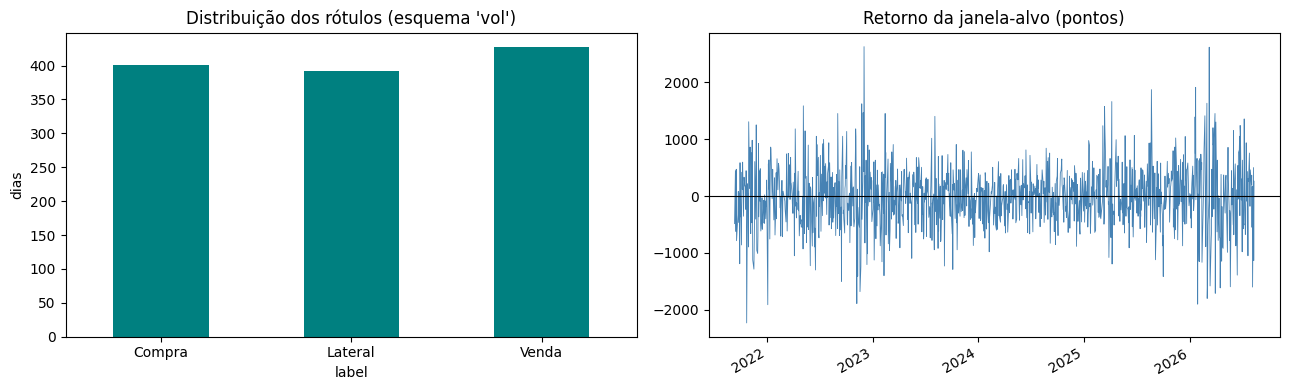

In [5]:
def construir_labels(df, janela, esquema):
    inicio, fim = janela
    jan = df.between_time(inicio, fim)
    agg = jan.resample("D").agg(
        ab=("Abertura", "first"), fe=("Fechamento", "last"),
        mx=("Maxima", "max"), mn=("Minima", "min"),
    ).dropna()

    retorno = agg["fe"] - agg["ab"]
    pavio = pd.Series(np.where(retorno >= 0, agg["ab"] - agg["mn"], agg["mx"] - agg["ab"]),
                      index=agg.index)

    if esquema == "fixo":
        cond = [(retorno > LIMIAR_RETORNO) & (pavio < LIMIAR_PAVIO),
                (retorno < -LIMIAR_RETORNO) & (pavio < LIMIAR_PAVIO)]
        y = pd.Series(np.select(cond, ["Compra", "Venda"], default="Lateral"), index=agg.index)

    elif esquema == "vol":
        # escala robusta: mediana móvel de |retorno| dos últimos 60 dias, só com passado
        escala = retorno.abs().rolling(60, min_periods=20).median().shift(1)
        k_ret = LIMIAR_RETORNO / escala.median()
        k_pav = LIMIAR_PAVIO / escala.median()
        cond = [(retorno > k_ret * escala) & (pavio < k_pav * escala),
                (retorno < -k_ret * escala) & (pavio < k_pav * escala)]
        y = pd.Series(np.select(cond, ["Compra", "Venda"], default="Lateral"), index=agg.index)
        y[escala.isna()] = np.nan

    elif esquema == "tercis":
        r = retorno / agg["ab"]
        q33 = r.rolling(250, min_periods=100).quantile(0.333).shift(1)
        q67 = r.rolling(250, min_periods=100).quantile(0.667).shift(1)
        y = pd.Series(np.select([r <= q33, r >= q67], ["Venda", "Compra"], default="Lateral"),
                      index=agg.index)
        y[q33.isna()] = np.nan
    else:
        raise ValueError(f"Esquema desconhecido: {esquema}")

    return y.rename("label"), retorno.rename("retorno_pts"), pavio.rename("pavio_pts")


y_todas, retorno_alvo, pavio_alvo = construir_labels(df, JANELA_ALVO, ESQUEMA_LABEL)

dados = X_todas.join(y_todas, how="inner").dropna()
X_all, y_all = dados.drop(columns="label"), dados["label"]

print(f"Amostras alinhadas : {len(X_all)}")
print(f"Features           : {X_all.shape[1]}")
print(f"Amostra por feature: {len(X_all) / X_all.shape[1]:.0f} : 1")
print(f"\nDistribuição das classes:")
print(y_all.value_counts().to_string())
print(f"\nMediana de |retorno| na janela-alvo: {retorno_alvo.abs().median():.0f} pontos")

# ── os outros dois esquemas citados na seção *Rotulagem*, medidos ──
print(f"\nno esquema 'fixo', quanto cada filtro deixa passar:")
print(f"   |retorno| > {LIMIAR_RETORNO} pts ... {(retorno_alvo.abs() > LIMIAR_RETORNO).mean():.1%} dos dias")
print(f"   pavio < {LIMIAR_PAVIO} pts ....... {(pavio_alvo < LIMIAR_PAVIO).mean():.1%} dos dias")
print("   >>> quem decide o rótulo é o pavio, não o retorno")

# limiar pelo ATR diário: escala de um dia inteiro aplicada a uma janela de 1 hora.
# Uso ATR/3 porque a janela-alvo é ~1/3 do pregão; mesmo assim a escala não cabe.
_d = df.resample("D").agg(mx=("Maxima", "max"), mn=("Minima", "min"),
                          fe=("Fechamento", "last")).dropna()
_tr = pd.concat([_d.mx - _d.mn, (_d.mx - _d.fe.shift()).abs(),
                 (_d.mn - _d.fe.shift()).abs()], axis=1).max(axis=1)
_atr = _tr.rolling(14).mean().shift(1).reindex(retorno_alvo.index)
_lat = (retorno_alvo.abs() <= _atr / 3)[_atr.notna()].mean()
print(f"\nrótulo com limiar = ATR(14) do dia anterior / 3:")
print(f"   ATR médio ................ {_atr.mean():.0f} pts  (janela-alvo: "
      f"{retorno_alvo.abs().median():.0f} pts de mediana)")
print(f"   fração de 'Lateral' ...... {_lat:.1%}")
print("   >>> a escala do dia inteiro não cabe numa janela de uma hora")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
y_all.value_counts().reindex(CLASSES).plot.bar(ax=ax[0], color="teal", rot=0)
ax[0].set_title(f"Distribuição dos rótulos (esquema '{ESQUEMA_LABEL}')")
ax[0].set_ylabel("dias")
retorno_alvo.reindex(y_all.index).plot(ax=ax[1], lw=0.6, color="steelblue")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("Retorno da janela-alvo (pontos)")
plt.tight_layout(); plt.show()

### Verificando o "V" que eu suspeitei

Mais acima eu escrevi que a estrutura fraca que o K-Means encontrou provavelmente vem da
**forma como as features foram construídas**, não de regime de mercado, por causa da
identidade `drawdown + runup = volatilidade` e do pavio que troca de definição conforme o
sinal do retorno. Aquilo era suspeita. A célula abaixo resolve.

O pair plot das seis features de rotulagem é o instrumento certo aqui: eu não estou
procurando sinal (isso já foi medido e não existe), estou olhando a **geometria de um
conjunto de fórmulas** para saber se ela produz agrupamentos artificiais.

#### Como se lê um pair plot

Um pair plot é uma matriz de gráficos: com `p` variáveis, a célula da linha `i` e coluna `j`
cruza a variável `i` no eixo vertical com a `j` no horizontal. Com as 6 features de rotulagem
são **36 painéis**, e eles não carregam 36 informações:

- **6 estão na diagonal**, onde cruzar uma variável com ela mesma não diria nada. Ali eu troco
  o gráfico de dispersão por um **histograma**, que mostra a distribuição da feature sozinha.
- **os 30 restantes são 15 pares desenhados duas vezes**, espelhados na diagonal. O painel
  `(runup, retorno)` é o `(retorno, runup)` com os eixos trocados. A repetição é de propósito:
  dá para varrer uma linha inteira com o olho, sem ir procurar a célula na metade de cima.

Os painéis não têm marcação de eixo. Os nomes ficam na coluna da esquerda e na linha de baixo,
e o que interessa aqui é a **forma**, não a escala.

O que faz este gráfico ser instrumento e não enfeite é uma linha do código:

```python
cor = np.where(L.retorno >= 0, "tab:green", "tab:red")
```

Cada ponto é um dos 1.238 dias, pintado pelo **sinal do retorno**. É a cor que separa os dois
ramos do V; sem ela, os dois viram uma mancha só.

**A diagonal, feature por feature** *(a célula abaixo imprime mínimo, mediana, máximo,
assimetria e a contagem de zeros exatos de cada uma)*:

| Painel | O que o histograma mostra |
|---|---|
| `retorno` | simétrico em torno de zero (assimetria 0,04), de −2,1% a +2,4%. É a única das seis com lado negativo |
| `volatilidade` | piso em zero e cauda longa à direita (assimetria 2,03); mediana 0,6%, máximo 2,9% |
| `pos_fech` | espalhado por todo o intervalo `[0, 1]`, com **mais massa nas pontas que no meio**: 11% dos dias abaixo de 0,1, 10% acima de 0,9, e só 7% na faixa central. O fechamento tende ao extremo do range, não ao miolo |
| `drawdown` | piso em zero, assimetria 1,92, e **8 dias em exatamente 0**: a mínima da hora foi a própria abertura |
| `runup` | mesmo formato, assimetria 2,17, e **5 dias em exatamente 0** |
| `volume_norm` | centrado em 1 por construção (mediana 0,992), com cauda até 2,2 |

Os três pisos em zero explicam por que vários painéis têm um **canto vazio**: `drawdown`,
`runup` e `volatilidade` não podem ser negativos, então metade do plano é inatingível por
definição da fórmula, não por falta de dados.

**Fora da diagonal, quatro formas, e cada uma pede uma decisão diferente:**

| Forma | Como aparece | O que eu concluo |
|---|---|---|
| Reta apertada | pontos colados numa linha | uma feature é a outra com ruído; dá para descartar uma |
| Leque | abre conforme cresce | compartilham a tendência, cada uma tem variação própria; descartar perde informação |
| Nuvem | sem forma | independentes na prática |
| **V, ou joelho** | duas retas que se encontram | há uma **quebra**, e um `r` único mente sobre os dois lados |

A última linha é o motivo de eu ter desenhado o gráfico em vez de olhar só a matriz de
correlação, e é o que a próxima subseção mede. A outra utilidade do pair plot, e o que ele
**não** resolve, estão na seção *O pair plot: para que ele serve aqui, e para que não serve*.


1238 dias, 6 features de rotulagem

max|drawdown + runup - volatilidade| = 3.47e-18
posto da matriz 6x6 .................. 5  (de 6)
variância explicada por componente:
   PC1=47.6%  PC2=32.8%  PC3=10.2%  PC4=9.0%  PC5=0.4%  PC6=0.0%
>>> o PC6 explica 0.0%: é a direção que a identidade elimina

correlação de cada feature de rotulagem com o P&L (= retorno):
   retorno         +1.000
   runup           +0.779
   pos_fech        +0.774
   drawdown        -0.776
   volatilidade    -0.023
   volume_norm     -0.025

feature             mín   mediana      máx  assimetria  zeros exatos
retorno          -0.021     0.000    0.024        0.04             7
volatilidade      0.002     0.006    0.029        2.03             0
pos_fech          0.000     0.490    0.997        0.01             1
drawdown          0.000     0.003    0.024        1.92             8
runup             0.000     0.002    0.028        2.17             5
volume_norm       0.459     0.992    2.197        0.51             0



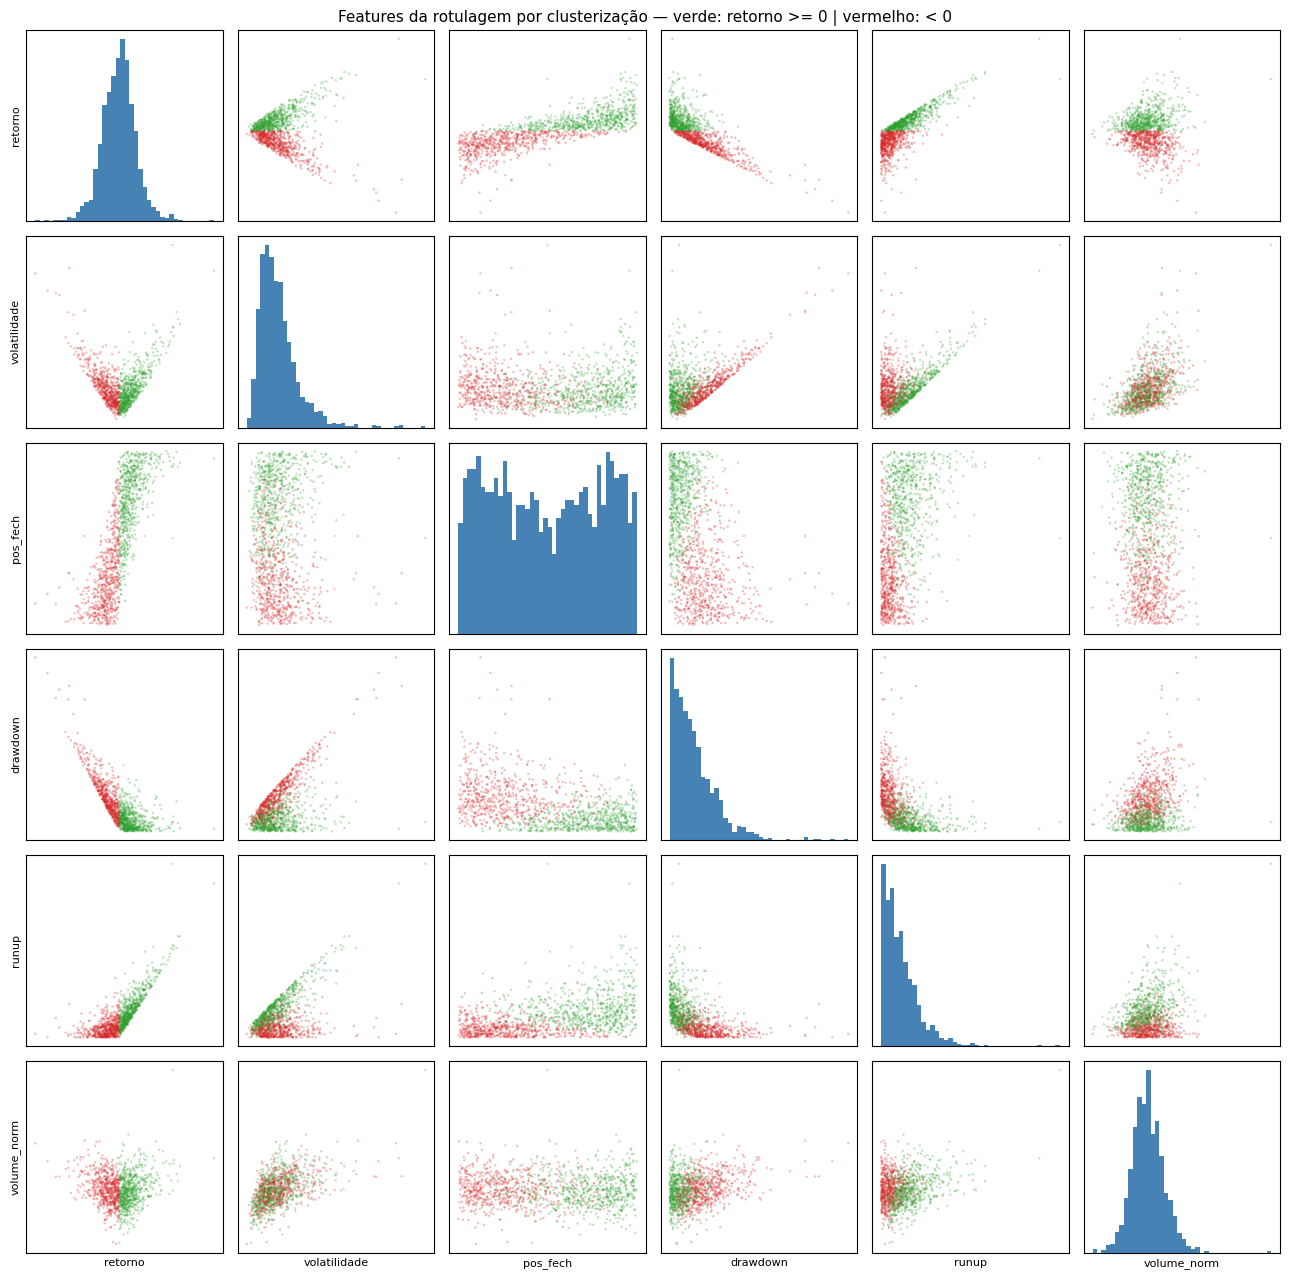

In [6]:
# As 6 features da ideia de rotulagem por clusterização, medidas na janela-alvo.
# Elas não entram no modelo: a ideia foi abandonada. Reconstruo aqui só para
# verificar a geometria que fez o K-Means enxergar "estrutura".
from sklearn.preprocessing import StandardScaler  

_g = df.between_time(*JANELA_ALVO).resample("D").agg(
    ab=("Abertura", "first"), fe=("Fechamento", "last"),
    mx=("Maxima", "max"), mn=("Minima", "min"), vol=("Volume_Real", "sum")).dropna()

L = pd.DataFrame(index=_g.index)
L["retorno"]      = (_g.fe - _g.ab) / _g.ab
L["volatilidade"] = (_g.mx - _g.mn) / _g.ab
L["pos_fech"]     = (_g.fe - _g.mn) / (_g.mx - _g.mn)
L["drawdown"]     = (_g.ab - _g.mn) / _g.ab
L["runup"]        = (_g.mx - _g.ab) / _g.ab
L["volume_norm"]  = _g.vol / _g.vol.rolling(20, min_periods=5).mean()
L = L.dropna()

print(f"{len(L)} dias, {L.shape[1]} features de rotulagem\n")
print(f"max|drawdown + runup - volatilidade| = "
      f"{(L.drawdown + L.runup - L.volatilidade).abs().max():.2e}")
_ZL = StandardScaler().fit_transform(L)
print(f"posto da matriz {L.shape[1]}x{L.shape[1]} .................. "
      f"{np.linalg.matrix_rank(_ZL)}  (de {L.shape[1]})")
# a mesma dependência vista pela decomposição: o último componente não carrega variância
_sv = np.linalg.svd(_ZL, compute_uv=False)
_var = _sv ** 2 / (_sv ** 2).sum()
print("variância explicada por componente:")
print("   " + "  ".join(f"PC{k+1}={v:.1%}" for k, v in enumerate(_var)))
print(f">>> o PC{L.shape[1]} explica {_var[-1]:.1%}: é a direção que a identidade elimina\n")

# numa saída por horário fixo (entra 11:00, sai 12:00) o P&L É o retorno_total,
# então a correlação de cada feature com ele mede o quanto ela vale em dinheiro
print("correlação de cada feature de rotulagem com o P&L (= retorno):")
for _f in ("retorno", "runup", "pos_fech", "drawdown", "volatilidade", "volume_norm"):
    print(f"   {_f:<14}{L[_f].corr(L.retorno):>+8.3f}")
print()

pos, neg = L.retorno > 0, L.retorno < 0

# ── o que a DIAGONAL do pair plot mostra: cada feature sozinha ──
print(f"{'feature':<14}{'mín':>9}{'mediana':>10}{'máx':>9}"
      f"{'assimetria':>12}{'zeros exatos':>14}")
for _c in L.columns:
    print(f"{_c:<14}{L[_c].min():>9.3f}{L[_c].median():>10.3f}{L[_c].max():>9.3f}"
          f"{L[_c].skew():>12.2f}{int((L[_c] == 0).sum()):>14}")

# o pos_fech é o único cuja forma não sai de mín/mediana/máx: ele é bimodal
print(f"\npos_fech: {(L.pos_fech <= 0.1).mean():.0%} dos dias <= 0,1  |  "
      f"{(L.pos_fech >= 0.9).mean():.0%} >= 0,9  |  "
      f"{L.pos_fech.between(0.45, 0.55).mean():.0%} na faixa central [0,45; 0,55]")
print(">>> o fechamento tende ao extremo do range da hora, não ao miolo")

# ── o que os painéis FORA da diagonal mostram: os 15 pares, e o que uma
#    correlação única esconde quando o gráfico tem um joelho em retorno = 0 ──
print(f"\n{'par':<30}{'r geral':>9}{'só alta':>9}{'só baixa':>10}   forma")
print(f"{'n':<30}{len(L):>9}{int(pos.sum()):>9}{int(neg.sum()):>10}")
_cols = list(L.columns)
for _i, _a in enumerate(_cols):
    for _b in _cols[_i + 1:]:
        _rg = L[_a].corr(L[_b])
        _ra = L[_a][pos].corr(L[_b][pos])
        _rb = L[_a][neg].corr(L[_b][neg])
        if _ra * _rb < 0 and min(abs(_ra), abs(_rb)) >= 0.3:
            _forma = "<-- V: os ramos têm sinal oposto e o r geral cancela"
        elif abs(abs(_ra) - abs(_rb)) >= 0.4:
            _forma = "<-- joelho: quase reta num ramo, quase plano no outro"
        else:
            _forma = ""
        print(f"{_a + ' x ' + _b:<30}{_rg:>+9.3f}{_ra:>+9.3f}{_rb:>+10.3f}   {_forma}")

# ── direção contra tamanho: o V some se eu medir contra |retorno| ──
print(f"\n{'feature':<14}{'r com retorno':>15}{'r com |retorno|':>17}")
for _c in ("volatilidade", "volume_norm", "drawdown", "runup", "pos_fech"):
    print(f"{_c:<14}{L[_c].corr(L.retorno):>+15.3f}{L[_c].corr(L.retorno.abs()):>+17.3f}")
print(">>> r perto de zero contra o retorno COM SINAL não é ausência de relação:")
print("    pode ser um V cujos dois ramos se cancelam na hora de somar")

# o pair plot das 6
cols = list(L.columns)
fig, eixos = plt.subplots(len(cols), len(cols), figsize=(13, 13))
cor = np.where(L.retorno >= 0, "tab:green", "tab:red")
for i, a in enumerate(cols):
    for j, b in enumerate(cols):
        ax = eixos[i, j]
        if i == j:
            ax.hist(L[a], bins=40, color="steelblue")
        else:
            ax.scatter(L[b], L[a], s=3, alpha=0.3, c=cor, linewidths=0)
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0: ax.set_ylabel(a, fontsize=8)
        if i == len(cols) - 1: ax.set_xlabel(b, fontsize=8)
fig.suptitle("Features da rotulagem por clusterização — verde: retorno >= 0 | vermelho: < 0",
             fontsize=11)
plt.tight_layout(); plt.show()

#### O V existe, e é geometria de fórmula

Os números confirmam a suspeita, e o gráfico mostra por quê.

**A identidade é exata.** `max|drawdown + runup − volatilidade| = 3,5 × 10⁻¹⁸`, ruído de
ponto flutuante. O posto da matriz é **5, não 6**: uma das seis colunas é combinação das
outras, e o K-Means, que trabalha com distância euclidiana, dá peso dobrado à dimensão
"energia do movimento" sem que eu tenha escolhido isso.

**E o joelho na origem aparece nos painéis do retorno:**

| Par | r nos 1.238 dias | retorno > 0 (617 dias) | retorno < 0 (614 dias) |
|---|---:|---:|---:|
| `retorno × drawdown` | −0,776 | **−0,175** | **−0,888** |
| `retorno × runup` | +0,779 | **+0,886** | +0,242 |
| **`retorno × volatilidade`** | **−0,023** | **+0,799** | **−0,796** |

Leia a primeira linha: quando o dia fecha em alta, o drawdown quase não acompanha o retorno
(−0,175); quando fecha em baixa, ele acompanha quase perfeitamente (−0,888). A segunda é o
espelho. **Cada variável é quase uma reta num ramo e quase plana no outro**, e a junção dos
dois ramos é o V.

A terceira linha é o caso extremo, e sozinha justifica ter desenhado o gráfico. A matriz de
correlação dá **−0,023** para `retorno × volatilidade`, o número que se lê como "não há
relação nenhuma". O painel mostra duas retas de inclinação quase oposta, `+0,799` e `−0,796`,
uma das relações mais determinísticas do conjunto. Os dois ramos se cancelam na hora de somar,
e o `r` único apaga o que existe. **Correlação perto de zero não é evidência de independência
quando o gráfico tem um joelho.**

Isso não é um regime de mercado. É consequência aritmética de como as fórmulas foram
escritas: se o dia subiu, por definição o runup contém o retorno inteiro e o drawdown é só o
que sobrou do caminho; se caiu, os papéis se invertem. **A quebra acontece em retorno = 0, que
é uma fronteira da fórmula, não do mercado.**

O mesmo vale para o `pavio` que a rotulagem usa: no ramo de retorno positivo ele **é** o
drawdown (correlação de +1,000); no ramo negativo, vira outra grandeza (−0,244). Uma
descontinuidade no zero.

> **O que isso encerra.** A "estrutura" com silhueta de 0,23–0,30 que o K-Means encontrou tem
> explicação, e ela não é interessante: o algoritmo estava separando **dias de alta de dias de
> baixa** ao longo do joelho do V, que é onde a geometria das fórmulas coloca uma dobra. Isso
> é coerente com a outra medição desta seção, os clusters reproduzem um `qcut` do retorno com
> Spearman de 0,898.
>
> Fica registrado como o argumento final para ter abandonado a rotulagem por clusterização:
> não foi só que ela funcionou mal, foi que o pouco que ela achava era artefato da própria
> construção das features.


---
## Protocolo de avaliação

É o coração do notebook. Se essa seção estiver errada, todo resultado depois dela é
ficção, e ficção convincente, porque erro de protocolo quase sempre deixa o número
*melhor*, nunca pior.

---

### O holdout sai agora, não depois

A primeira coisa que a célula faz é cortar os **últimos 20% dos dias** e guardar. Eles não
voltam até a seção *Holdout final*.

A ordem importa mais do que parece. Separar agora significa que nenhuma decisão que eu
tomar no meio do caminho, qual feature usar, qual rótulo, qual modelo, quais
hiperparâmetros, pode ter sido influenciada por esses dias. Se eu separasse depois de já
ter olhado a base inteira, o holdout seria apenas um pedaço de dado que eu já vi, com outro
nome e uma falsa sensação de segurança.

O corte é **cronológico**, não aleatório: o holdout é o futuro em relação ao treino, igual
à situação real de operar.

| | Período | Dias |
|---|---|---|
| Trabalho | 2021-09-10 a 2025-08-15 | 976 |
| **Holdout** | **2025-08-18 a 2026-08-12** | **244** |

---

### Walk-forward, não validação cruzada normal

> O argumento de que validação cruzada embaralhada é inadequada para série temporal está
> desenvolvido em [Bergmeir & Benítez, 2012]; o procedimento de janelas deslizantes segue
> [Hyndman & Athanasopoulos, 2021] *(ver a seção Referências)*.

`TimeSeriesSplit` com 5 folds funciona assim:

```
fold 1:  [treino]  [teste]
fold 2:  [treino......]  [teste]
fold 3:  [treino...........]  [teste]
fold 4:  [treino................]  [teste]
fold 5:  [treino.....................]  [teste]
             tempo →
```

O treino sempre cresce para trás, o teste sempre fica à frente. Nunca o contrário.

Validação cruzada comum embaralha os dados e acaba treinando em dias posteriores para
prever dias anteriores. Em série temporal isso é vazamento puro: o modelo aprende regimes
de mercado que, na hora da previsão, ainda não teriam acontecido. O número que sai é ótimo
e não significa nada.

#### Os folds não são o mesmo experimento

Vale olhar os números reais, porque eles mudam como se lê a média:

| Fold | Treino | Teste | Período de teste | Baseline do fold |
|---|---|---|---|---|
| 1 | **166** | 162 | 2022-05-16 a 2023-01-04 | 0,364 |
| 2 | 328 | 162 | 2023-01-05 a 2023-08-29 | 0,383 |
| 3 | 490 | 162 | 2023-08-30 a 2024-04-26 | 0,383 |
| 4 | 652 | 162 | 2024-04-29 a 2024-12-16 | 0,321 |
| 5 | **814** | 162 | 2024-12-17 a 2025-08-15 | 0,309 |

Duas consequências práticas:

**O fold 1 treina com 166 dias e o fold 5 com 814**, quase 5x mais. O primeiro fold mede
"o que dá para aprender com menos de um ano de dados", o último mede "o que dá para
aprender com três anos". Média entre eles é uma média de coisas diferentes.

**O baseline varia de 0,309 a 0,383 entre os folds**, 7 pontos percentuais de amplitude.
Isso acontece porque a proporção das classes muda de período para período. É por isso que
eu comparo modelo contra baseline **dentro de cada fold**, e não contra um baseline global:
um modelo pode parecer bom simplesmente por ter caído num fold onde a classe majoritária
era mais dominante.

#### O scaler é ajustado dentro do fold, e eu medi o quanto isso importa

`StandardScaler` ajustado só na parte de treino de cada fold. Ajustar na base toda vazaria
a média e o desvio do futuro para dentro do treino.

A diferença medida nesta base, e ela **depende da família do modelo**
*(reproduzido no Anexo A.15)*:

| Modelo | Dentro do fold | Na base toda | Diferença |
|---|---:|---:|---:|
| XGBoost (árvore) | 0,3526 | 0,3526 | **+0,0000** |
| Regressão logística | 0,3173 | 0,3173 | **+0,0000** |
| SVM (RBF) | 0,3284 | 0,3296 | +0,0012 |

**Para árvores a diferença é exatamente zero, e não por acaso.** Uma árvore decide por
limiar (`x <= t`), e a padronização é uma transformação **monótona** de cada feature: ela
reordena a escala, mas não a ordem dos valores. Nenhuma divisão muda. Testar vazamento de
scaler num modelo de árvore não mede coisa alguma.

Nos modelos que usam distância ou produto interno, o efeito existe e é mensurável, mas fica
em **0,0012 nesta base**, uma única previsão de diferença em 244. Na regressão logística a
acurácia nem se moveu, embora ali a transformação não seja inócua como na árvore: ela mexe
nos coeficientes, só que não o bastante para trocar nenhuma classe prevista.

O motivo de ser tão pequeno é que todas as features aqui já são **relativas e aproximadamente
estacionárias** (retornos, razões, proporções). Medindo o deslocamento da média de cada
feature entre as duas metades da amostra, em desvios: **mediana de 0,046**, com 5 das 22 acima
de meio desvio e uma só bem acima (`c_atr_d1`, com 1,42). A média e o desvio mudam pouco ao
longo da série, então vazá-los entrega pouca informação.

Continuo ajustando dentro do fold por dois motivos: é o procedimento correto e não custa
nada, e se algum dia eu adicionar uma feature em nível absoluto (preço, volume bruto), o
vazamento passaria a ser grande e silencioso. O hábito protege o caso futuro.

---

### Baseline em todo teste, e por que dois

Junto com cada modelo eu rodo um `DummyClassifier`. Uso dois tipos, e a medição mostra por
quê:

| Baseline | Acurácia | F1-macro |
|---|---|---|
| `most_frequent` | 0,3519 | **0,1733** |
| `stratified` | **0,3593** | 0,3544 |

Repare que eles se invertem conforme a métrica:

- **`most_frequent`** chuta sempre a classe mais comum. Acurácia razoável, mas F1-macro
  terrível, ele zera duas das três classes, e o F1 delas vai a zero.
- **`stratified`** sorteia respeitando a proporção das classes. Acerta um pouco de cada uma,
  então o F1-macro sobe bastante.

Aqui há uma surpresa que só apareceu medindo: **o `stratified` tem acurácia *maior* que o
`most_frequent`** (0,3593 contra 0,3519). Isso acontece porque as classes estão quase
equilibradas, quando não há classe dominante de verdade, chutar sempre a mesma não é a
melhor aposta.

Não basta um baseline. Um modelo só aprendeu alguma coisa se superar **os dois, em ambas as
métricas**, e de forma consistente entre os folds. Ganho médio positivo com metade
dos folds negativos não conta.

---

### Dez sementes, não uma

Rede neural com semente diferente dá resultado diferente. Modelos com amostragem aleatória
(`subsample`, `bootstrap`) também. Uma rodada só mede **a sorte daquela inicialização**, não
a qualidade do modelo.

Nesta base o desvio entre sementes fica em torno de **0,006 a 0,011** de acurácia. Guarde
esse número: ele é **maior que a diferença entre vários dos modelos testados**. Sem repetir,
é impossível distinguir "modelo melhor" de "semente com sorte".

Por isso tudo roda com no mínimo 10 sementes e o que eu reporto é **média ±
desvio-padrão**. A regra de leitura:

> Se o desvio entre sementes for da mesma ordem que a diferença entre dois modelos, esses
> dois modelos são **indistinguíveis**. Isso é uma conclusão, não um detalhe a ignorar.

---

### As funções desta seção

| Função | O que faz |
|---|---|
| `walk_forward` | Um passe de 5 folds; devolve acurácia, F1 e o ganho sobre o baseline |
| `avaliar_multi_semente` | Roda o anterior com N sementes e agrega em média ± dp |
| `prever_out_of_fold` | Junta as previsões dos folds de teste, cada dia previsto por um modelo que nunca o viu |
| `teste_permutacao` | Embaralha o rótulo N vezes para construir a distribuição do acaso |

O `prever_out_of_fold` merece atenção especial: é ele que permite um backtest honesto. Cada
previsão vem de um modelo treinado exclusivamente em dias anteriores àquele. Backtest feito
com previsão in-sample dá 80% de acerto e uma curva de capital linda que não significa
absolutamente nada, é o erro mais caro desta área.

---

### A armadilha do `early stopping`: parar de treinar olhando o conjunto errado

Este é o vazamento mais fácil de cometer sem perceber, porque o código parece correto e
roda sem erro nenhum. Ele aparece quando o mesmo conjunto de dados cumpre duas funções ao
mesmo tempo: **decidir quando parar o treino** e **gerar a métrica que vai ser reportada**.

O padrão problemático é este:

```python
model.fit(
    X_treino, y_treino,
    validation_data=(X_val, y_val),                       # 1. o early stopping olha aqui
    callbacks=[EarlyStopping(monitor="val_loss",
                             restore_best_weights=True)])  # 2. e restaura o melhor ponto

f1 = f1_score(y_val, model.predict(X_val))                # 3. e a métrica sai DAQUI
```

As três linhas isoladas estão certas. Juntas, elas produzem um número que não significa o
que parece.

**Por que isso infla o resultado.** O `EarlyStopping` percorre as épocas e guarda os pesos
do ponto de menor perda **em `X_val`**. Com `restore_best_weights=True`, o modelo que sai do
`fit` é literalmente o que teve o melhor desempenho naquele conjunto. Medir o F1 nesse mesmo
`X_val` não é estimar generalização: é **relatar o máximo de uma curva**, escolhido a
posteriori entre 200 ou 5.000 candidatos.

Quanto mais épocas, pior: com `epochs=5000` e `patience=100`, o processo tem milhares de
oportunidades de encontrar, por acaso, uma configuração de pesos que se sai bem naquelas
amostras específicas. O ruído do conjunto de validação vira parte do critério de seleção.

**Por que isso é pior dentro de uma busca de hiperparâmetros.** Se esse F1 inflado é o que
o Optuna (ou qualquer otimizador) recebe como objetivo, o viés deixa de ser um erro de
medição e passa a ser um erro de **escolha**: a busca vai preferir sistematicamente as
configurações que mais conseguem explorar o ruído daquele fold, normalmente as de maior
capacidade. O otimizador funciona perfeitamente; ele só está maximizando a coisa errada.

**A correção exige três partições, não duas:**

| Partição | Serve para | Pode gerar métrica? |
|---|---|---|
| Treino | ajustar os pesos | não |
| **Validação interna** | early stopping, escolha de época | **não** |
| Teste do fold | métrica reportada | sim |

No código deste notebook, `walk_forward_keras` reserva **20% do bloco de treino** para o
`validation_split` do Keras, e o fold de teste do `TimeSeriesSplit` **nunca** é passado como
`validation_data`, na verdade o argumento `validation_data` não aparece uma única vez no
notebook. Quem para o treino e quem dá a nota são conjuntos diferentes:

```python
modelo.fit([T_tr, C_tr], y_oh[i_tr],
           validation_split=0.2, shuffle=False,          # para o treino olhando aqui
           callbacks=[EarlyStopping(monitor="val_loss",
                                    restore_best_weights=True)])
p = modelo.predict([T_te, C_te])                          # e a nota sai daqui
```

O `shuffle=False` importa junto com o `validation_split`: o Keras separa a **última** fração
dos dados antes de embaralhar, então com `shuffle=False` a validação interna é o trecho
cronologicamente mais recente do bloco de treino. Sem isso, ela seria uma amostra aleatória
espalhada pelo período, e o modelo estaria escolhendo a época de parada com base em dias que
vêm depois de dias que ele ainda vai prever.

### O que este protocolo NÃO protege

Vale ser explícito sobre os limites, porque protocolo rigoroso dá uma sensação de segurança
que pode passar do ponto.

| Risco | Protegido? | Por quê |
|---|---|---|
| Vazamento temporal | **sim** | walk-forward cronológico |
| Vazamento pelo scaler | **sim** | ajustado dentro do fold |
| Sorte de inicialização | **sim** | 10 sementes, média ± dp |
| Resultado não reproduzir | **sim** | toda semente declarada; conferido rodando duas vezes (seção *A rodada inteira reproduz bit a bit*) |
| Confundir acaso com sinal | **sim** | teste de permutação |
| Overfitting na escolha de features | **não** | escolhi features olhando o conjunto de trabalho |
| Overfitting na escolha de janela | **parcial** | o sweep rodou só nos 80%, mas eu vi os resultados |
| Garimpagem entre variantes | **não** | depende de disciplina, não de código |
| Mudança de regime futura | **não** | nada protege contra isso |

As três últimas linhas são a razão de existir o holdout da seção *Holdout final* e a lista fechada de
variantes no fim do notebook. Elas não são resolvidas por código, são resolvidas por não
trapacear consigo mesmo.


### Eliminar uma hipótese não confirma a alternativa

Este é um erro de raciocínio, não de código, e por isso nenhum protocolo pega. Ele aparece
assim:

> *"Provei que usar só o histórico de preço não funciona. Isso valida e justifica a
> necessidade de usar o meu conjunto de 22 features."*

A primeira frase é um resultado. A segunda não decorre dela. Descartar a hipótese A não é
evidência a favor da hipótese B, as duas podem estar erradas, e é exatamente o que acontece
aqui: a linha de base univariada rende 0,086% (seção *Modelos tabulares*) **e** as 22 features multivariadas também
dão ganho nulo. Os dois resultados são negativos e independentes.

A versão mais comum do mesmo erro, e mais perigosa porque parece rigor:

| Raciocínio | Por que não fecha |
|---|---|
| "O modelo bateu o baseline, logo há sinal" | bater o baseline uma vez está dentro do que o acaso produz, daí o teste de permutação da seção *Baseline em todo teste, e por que dois* |
| "O método simples falhou, logo preciso do complexo" | o simples falhar não diz nada sobre o complexo funcionar |
| "Descartei o rótulo por clusterização, logo o rótulo por regra está certo" | os dois podem estar mal definidos |
| "As features não passaram no teste de MI, logo o problema é o modelo" | pode ser que não haja sinal em lugar nenhum |

**A postura correta é declarar cada hipótese e testá-la contra o acaso, separadamente.** Um
achado nulo em A é um achado sobre A. Se eu quiser afirmar algo sobre B, meço B, contra o
baseline e contra a permutação, como qualquer outro.

### A rodada inteira reproduz bit a bit

Toda fonte de aleatoriedade do notebook está presa a uma semente declarada. Isso vale para os
modelos tabulares (`random_state=s`), para a divisão dos folds (que é cronológica, portanto
determinística) e, o que costuma ser o furo, para as redes: cada arquitetura chama
`tf.keras.utils.set_random_seed(semente)` antes de ser construída, o que fixa de uma vez o
gerador do Python, o do NumPy e o do TensorFlow.

Rodei o notebook inteiro duas vezes, do zero, e comparei número por número:

| Medição | Rodada 1 | Rodada 2 |
|---|---|---|
| XGBoost | 0,353 ± 0,007 | idêntico |
| Permutação | z = 0,60, p = 0,2836 | idêntico |
| Friedman | chi² = 4,452, p = 0,6158 | idêntico |
| Backtest out-of-fold | −9.700 pts | idêntico |
| MLP / CNN / LSTM / TCN | 0,342 / 0,355 / 0,349 / 0,334 | idêntico |
| Holdout | 0,3279, +3.342 pts | idêntico |

**Nada mudou na terceira casa decimal.** Só os tempos de execução variaram.

Vale registrar porque **não é automático**. É comum fixar `np.random.seed` e supor que o
problema está resolvido; com TensorFlow no meio, isso deixa de fora o gerador interno do
framework, e as redes saem diferentes a cada execução. Quando isso acontece, um resultado
fraco fica indistinguível de ruído de inicialização, e não há como outra pessoa conferir o
que se afirma.

> **Como conferir.** Reiniciar o kernel e rodar tudo de novo. Se algum número mudar, alguma
> fonte de aleatoriedade escapou, e o primeiro lugar para procurar é uma biblioteca que
> sorteia por conta própria sem consultar a semente global.

---


In [7]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ---- separa o holdout ANTES de qualquer experimento ----
n_holdout = int(len(X_all) * FRAC_HOLDOUT)
corte = len(X_all) - n_holdout

X_trab, y_trab = X_all.iloc[:corte], y_all.iloc[:corte]
X_hold, y_hold = X_all.iloc[corte:], y_all.iloc[corte:]

print(f"Trabalho          : {len(X_trab):4d} dias  ({X_trab.index.min():%Y-%m-%d} a {X_trab.index.max():%Y-%m-%d})")
print(f"HOLDOUT (intocado): {len(X_hold):4d} dias  ({X_hold.index.min():%Y-%m-%d} a {X_hold.index.max():%Y-%m-%d})")


def walk_forward(construir_modelo, X, y, n_splits=N_SPLITS, semente=0, detalhe=False):
    """Walk-forward cronológico. Devolve métricas médias do modelo e do baseline."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    m_acc, m_f1, b_acc, b_f1 = [], [], [], []

    for k, (i_tr, i_te) in enumerate(tscv.split(X), 1):
        scaler = StandardScaler().fit(X.iloc[i_tr])
        X_tr, X_te = scaler.transform(X.iloc[i_tr]), scaler.transform(X.iloc[i_te])
        y_tr, y_te = y.iloc[i_tr], y.iloc[i_te]

        modelo = construir_modelo(semente).fit(X_tr, y_tr)
        p_m = modelo.predict(X_te)
        p_b = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr).predict(X_te)

        m_acc.append(accuracy_score(y_te, p_m)); b_acc.append(accuracy_score(y_te, p_b))
        m_f1.append(f1_score(y_te, p_m, average="macro", zero_division=0))
        b_f1.append(f1_score(y_te, p_b, average="macro", zero_division=0))

        if detalhe:
            print(f"    fold {k} (teste={len(i_te):4d}): base={b_acc[-1]:.3f} "
                  f"modelo={m_acc[-1]:.3f} delta={m_acc[-1]-b_acc[-1]:+.3f}")

    return {"acc": np.mean(m_acc), "f1": np.mean(m_f1),
            "base_acc": np.mean(b_acc), "base_f1": np.mean(b_f1),
            "ganho": np.mean(m_acc) - np.mean(b_acc),
            "acc_por_fold": m_acc}


def avaliar_multi_semente(nome, construir_modelo, X, y, sementes=SEMENTES):
    """Roda o walk-forward com várias sementes. Rodada única não é resultado."""
    linhas = [walk_forward(construir_modelo, X, y, semente=s) for s in sementes]
    acc = np.array([r["acc"] for r in linhas])
    f1 = np.array([r["f1"] for r in linhas])
    ganho = np.array([r["ganho"] for r in linhas])
    return {"modelo": nome, "n_sementes": len(sementes),
            "acc_media": acc.mean(), "acc_dp": acc.std(),
            "f1_media": f1.mean(), "f1_dp": f1.std(),
            "ganho_medio": ganho.mean(), "ganho_dp": ganho.std(),
            "base_acc": linhas[0]["base_acc"],
            "acc_por_fold": np.mean([r["acc_por_fold"] for r in linhas], axis=0)}


def prever_out_of_fold(construir_modelo, X, y, n_splits=N_SPLITS, semente=0):
    """
    Previsões honestas: cada dia é previsto por um modelo treinado só em dias anteriores.
    Devolve apenas os dias cobertos pelos folds de teste.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    partes = []
    for i_tr, i_te in tscv.split(X):
        scaler = StandardScaler().fit(X.iloc[i_tr])
        modelo = construir_modelo(semente).fit(scaler.transform(X.iloc[i_tr]), y.iloc[i_tr])
        partes.append(pd.Series(modelo.predict(scaler.transform(X.iloc[i_te])),
                                index=X.index[i_te]))
    return pd.concat(partes)


def teste_permutacao(construir_modelo, X, y, n_perm=N_PERMUTACOES, semente=0):
    """
    Hipótese nula: as features não têm relação nenhuma com o rótulo.
    Embaralha y e mede o ganho sob o nulo. Devolve o p-valor empírico.
    """
    obs = walk_forward(construir_modelo, X, y, semente=semente)["ganho"]
    rng = np.random.default_rng(semente)
    nulos = np.empty(n_perm)
    t0 = time.time()
    for i in range(n_perm):
        y_perm = pd.Series(rng.permutation(y.values), index=y.index)
        nulos[i] = walk_forward(construir_modelo, X, y_perm, semente=semente)["ganho"]
    return {"ganho_observado": obs, "nulo_media": nulos.mean(), "nulo_dp": nulos.std(),
            "z": (obs - nulos.mean()) / nulos.std(),
            "p_valor": (np.sum(nulos >= obs) + 1) / (n_perm + 1),
            "segundos": time.time() - t0, "nulos": nulos}

print("\nProtocolo carregado.")

Trabalho          :  976 dias  (2021-09-10 a 2025-08-15)
HOLDOUT (intocado):  244 dias  (2025-08-18 a 2026-08-12)

Protocolo carregado.


---
## Tratamento dos dados: o que fazer e o que não fazer

Quatro decisões de pré-processamento que parecem detalhe e não são. Duas delas eu faço,
duas eu deliberadamente **não** faço, e as duas que não faço são as mais tentadoras.

---

### Duas normalizações, não uma

São coisas diferentes, resolvem problemas diferentes, e ambas são necessárias.

**Normalização de domínio**, dividir pela abertura. Torna as features comparáveis **ao
longo do tempo**. É o assunto da seção *Engenharia de features*: o índice foi de 96 mil a 203 mil, e sem isso um
movimento de 300 pontos significaria coisas diferentes em 2021 e em 2026.

**Normalização estatística**, `StandardScaler`. Coloca as features na **mesma escala
numérica entre si**. Mesmo depois da primeira normalização, elas continuam em ordens de
grandeza incompatíveis:

| Feature | Mínimo | Máximo | Amplitude |
|---|---|---|---|
| `retorno_janela` | −0,0225 | 0,0415 | **0,0640** |
| `rsi` | 0,4310 | 97,7477 | **97,3167** |
| `volume_norm` | 0,5509 | 1,5312 | 0,9803 |

A amplitude do RSI é **1.041 vezes** maior que a do retorno. Para uma rede neural, um valor
de 50 no RSI é numericamente enorme perto de 0,005 no retorno, e no início do treino ela
vai dar peso proporcional a isso, por acidente aritmético e não por importância real.

As duas não são redundantes: a primeira dá **validade temporal**, a segunda dá
**estabilidade de treino**.

> **Onde isso acontece neste notebook.** A normalização de domínio está dentro de
> `features_do_dia` (seção *Engenharia de features*). A estatística está dentro de `walk_forward` (seção *Protocolo de avaliação*),
> ajustada só no treino de cada fold. E a divisão é sempre `shuffle=False`, um exemplo de
> normalização com divisão aleatória introduziria vazamento temporal, por mais que o
> `StandardScaler` esteja correto.

---

### Padronização, não Min-Max

`MinMaxScaler` comprime tudo para [0, 1]. `StandardScaler` centra em 0 com desvio 1. Para
dados financeiros, a diferença é grande, e dá para medir.

O dia mais extremo da amostra é **2022-12-02**, com retorno de 2.625 pontos na janela-alvo,
**8 vezes** a mediana de 325 pontos. Veja o que cada scaler faz com ele:

*(reproduzido no Anexo A.16, junto com a conta dos outliers)*

| | StandardScaler | MinMaxScaler |
|---|---|---|
| Valor do outlier depois de transformar | 4,873 | 1,000 |
| Faixa ocupada pelos 90% centrais | [−1,589, 1,576] | [0,279, 0,632] |
| **Largura ocupada pelos 90% centrais** | **3,165** | **0,353** |
| Desvio-padrão dos 90% centrais | 0,7141 | 0,0797 |

O `MinMaxScaler` espreme **90% dos dados em 35% do intervalo disponível**, porque o único
dia extremo define o teto. Toda a variação que interessa, a diferença entre um dia normal e
outro, fica comprimida perto do meio.

O `StandardScaler` não tem teto. O outlier vira um z-score de 4,87, que é uma informação
útil ("este dia foi 5 desvios fora do normal, preste atenção"), e o resto dos dados mantém a
dispersão original.

---

### Outliers: não remova

A tentação é forte. Os dias extremos atrapalham o treino, distorcem métricas e é fácil
justificar removê-los como "limpeza de dados".

**É o erro mais caro desta lista**, porque ele melhora o backtest e piora o resultado real.

| Medida | Valor |
|---|---|
| Dias acima do percentil 95 de \|retorno\| | 63 de 1.242 (5,1%) |
| **Fatia do movimento total que eles carregam** | **18,0%** |
| \|retorno\| mediano nesses dias | 1.390 pts |
| \|retorno\| mediano nos demais | 305 pts |

**Cinco por cento dos dias carregam 18% de todo o movimento.** Esses são exatamente os dias
onde estão o lucro e o prejuízo de qualquer estratégia direcional.

Removê-los produz um backtest suave, com drawdown pequeno e curva bonita, e uma falsa
sensação de segurança. O modelo em produção vai encontrar esses dias inevitavelmente, e é
neles que a estratégia é decidida.

**A abordagem correta é usar ferramentas robustas, não apagar o dado.** O `StandardScaler`
já é uma delas (seção *Padronização, não Min-Max*): ele acomoda o extremo sem deixá-lo dominar a escala. Dropout e
regularização fazem o resto, impedindo que o modelo se ajuste a exemplos específicos.

---

### Balanceamento de classes: aqui não é preciso, e a tentativa sai cara

Balancear classes é padrão quando há desequilíbrio real. A questão é o que conta como real:

| Desbalanceamento | Precisa tratar? |
|---|---|
| Até ~2x | não |
| ~4x | talvez, dependendo da métrica |
| 1:100, 1:1000 | indispensável |

**Aqui o desbalanceamento é de 1,12x** (Venda 348, Compra 317, Lateral 311). Não há nada
para corrigir.

Mesmo assim, testei a abordagem de **intercalar e truncar**, separar por classe, cortar
todas no tamanho da menor, e alternar Compra / Venda / Lateral em sequência, porque ela é
uma tentação natural quando se quer lotes balanceados.

#### O que ela custa

| Fold | Treino | Após intercalar | Descartado |
|---|---|---|---|
| 1 | 166 | 150 | 9,6% |
| 2 | 328 | 285 | 13,1% |
| 3 | 490 | 447 | 8,8% |
| 4 | 652 | 594 | 8,9% |
| 5 | 814 | 768 | 5,7% |
| **Total** | **2.450** | **2.244** | **8,4%** |

E não é um corte neutro: truncar pelos primeiros elementos descarta os dias **mais recentes**
das classes maiores, encurtando o histórico de quem tinha mais exemplos.

#### A armadilha: o ganho multiplica por sete e é ilusão

| Estratégia | Acurácia | ±dp | F1-macro | Baseline | Ganho reportado |
|---|---|---|---|---|---|
| Sem balanceamento | 0,3551 | 0,0076 | 0,3430 | 0,3519 | +0,0033 |
| **Intercalar + truncar** | 0,3547 | 0,0015 | 0,3368 | **0,3296** | **+0,0251** |
| `class_weight` balanced | 0,3539 | 0,0041 | 0,3434 | 0,3519 | +0,0021 |

*(estes são os valores que a célula abaixo imprime)*

Olhando a coluna do ganho, a intercalação parece **sete vezes melhor**. Mas a acurácia é
0,3547 contra 0,3551: ela ficou 0,0004 **pior**, sobre um desvio de 0,0076. **O modelo não
melhorou em nada, e o ganho reportado subiu de +0,0033 para +0,0251.**

O que mudou foi o **baseline**. Treinando o `DummyClassifier` num conjunto perfeitamente
balanceado, ele perde a informação de qual classe é majoritária, e sua acurácia no teste
(que continua desbalanceado) cai de 0,3519 para 0,3296. O ganho cresce porque a régua
encolheu.

> **É a armadilha mais perigosa desta seção**, porque não parece erro. Todo o código está
> certo, o walk-forward está certo, a divisão cronológica está certa, e ainda assim o
> número reportado se multiplica por sete por uma razão que não tem nada a ver com o
> modelo. Se algum dia
> algum pré-processamento mexer na distribuição do treino, **recalcule o baseline na
> distribuição original** antes de comparar.

E o F1-macro, que é justamente a métrica que balanceamento deveria ajudar, **piorou**
(0,3430 → 0,3368).

#### Sobre lotes de tamanho 3

A ideia de usar `batch_size=3` para garantir lotes perfeitamente balanceados tem dois
problemas independentes do balanceamento:

- **Gradiente ruidoso.** Três amostras dão uma estimativa péssima do gradiente; o treino
  fica instável e converge devagar.
- **Quebra o `BatchNormalization`.** As arquiteturas da seção *Modelos tabulares* usam BatchNorm, que calcula
  média e desvio *dentro do lote*. Com 3 amostras essas estatísticas são inúteis, e o
  comportamento em treino diverge do de inferência.

Se algum dia o balanceamento for necessário de verdade, a ferramenta é `class_weight` (ou
`sample_weight`): pesa as classes sem descartar dado nem restringir o tamanho do lote.

---

### O resumo desta seção

| Decisão | O que eu faço | Por quê |
|---|---|---|
| Normalização de domínio | **sim** | comparabilidade temporal |
| Normalização estatística | **sim** | estabilidade de treino |
| Min-Max em vez de Z-score | não | um outlier espreme 90% dos dados em 35% da faixa |
| Remover outliers | **não** | 5% dos dias carregam 18% do movimento |
| Balancear classes | **não** | desbalanceamento é de 1,12x; e corrompe o baseline |


In [8]:
# ═══════════════ balanceamento: vale a pena? (reproduz a medição da seção *Balanceamento de classes: aqui não é preciso, e a tentativa sai cara*) ═══════════════
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

def _intercalar(Xtr, ytr):
    """Separa por classe, trunca no tamanho da menor e alterna C/V/L."""
    partes = {c: Xtr[ytr == c] for c in CLASSES}
    m = min(len(p) for p in partes.values())
    idx = [partes[c].index[i] for i in range(m) for c in CLASSES]
    return Xtr.loc[idx], ytr.loc[idx]


def avaliar_balanceamento(modo, sementes=range(3)):
    """modo: 'nada' | 'intercalado' | 'class_weight'"""
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    accs, f1s, bases, descarte = [], [], [], []
    for s in sementes:
        a, f, b = [], [], []
        for i_tr, i_te in tscv.split(X_trab):
            Xtr, ytr = X_trab.iloc[i_tr], y_trab.iloc[i_tr]
            Xte, yte = X_trab.iloc[i_te], y_trab.iloc[i_te]
            sw = None
            if modo == "intercalado":
                n0 = len(Xtr); Xtr, ytr = _intercalar(Xtr, ytr)
                if s == 0:
                    descarte.append((n0 - len(Xtr)) / n0)
            elif modo == "class_weight":
                sw = compute_sample_weight("balanced", ytr)

            sc = StandardScaler().fit(Xtr)
            gb = GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.05,
                                            subsample=0.8, random_state=s)
            gb.fit(sc.transform(Xtr), ytr, sample_weight=sw)
            p = gb.predict(sc.transform(Xte))
            a.append(accuracy_score(yte, p))
            f.append(f1_score(yte, p, average="macro", zero_division=0))
            # o baseline é treinado no MESMO conjunto que o modelo: é aqui que mora a armadilha
            b.append(accuracy_score(yte, DummyClassifier(strategy="most_frequent")
                                    .fit(Xtr, ytr).predict(Xte)))
        accs.append(np.mean(a)); f1s.append(np.mean(f)); bases.append(np.mean(b))
    return (np.mean(accs), np.std(accs), np.mean(f1s), np.mean(bases),
            np.mean(descarte) if descarte else 0.0)


vc = y_trab.value_counts()
print(f"Distribuição do treino: {vc.to_dict()}")
print(f"Desbalanceamento (maior/menor): {vc.max()/vc.min():.2f}x")
print("(balanceamento costuma importar a partir de ~4x)\n")

# o que a intercalação custa, fold a fold (só contagem, sem treinar nada)
print(f"{'fold':>5}{'treino':>9}{'após intercalar':>18}{'descartado':>13}")
_n_ini = _n_fim = 0
for _k, (_itr, _) in enumerate(TimeSeriesSplit(n_splits=N_SPLITS).split(X_trab), 1):
    _ytr = y_trab.iloc[_itr]
    _a, _b = len(_ytr), 3 * min((_ytr == _c).sum() for _c in CLASSES)
    _n_ini += _a; _n_fim += _b
    print(f"{_k:>5}{_a:>9}{_b:>18}{1 - _b / _a:>12.1%}")
print(f"{'total':>5}{_n_ini:>9}{_n_fim:>18}{1 - _n_fim / _n_ini:>12.1%}")
print("(a coluna 'descarte' da tabela abaixo é a média das cinco taxas, "
      "não a taxa agregada)\n")

print(f"{'estratégia':<24}{'acurácia':>10}{'±dp':>8}{'f1m':>9}{'baseline':>10}{'ganho':>9}{'descarte':>10}")
for modo, nome in [("nada", "sem balanceamento"),
                   ("intercalado", "intercalar + truncar"),
                   ("class_weight", "class_weight")]:
    a, dp, f1, base, desc = avaliar_balanceamento(modo)
    print(f"{nome:<24}{a:>10.4f}{dp:>8.4f}{f1:>9.4f}{base:>10.4f}{a-base:>+9.4f}{desc:>9.1%}")

print("\n>>> Compare a coluna 'ganho' com a coluna 'acurácia'.")
print(">>> Se o ganho subir enquanto a acurácia fica igual, o que mudou foi o BASELINE.")

Distribuição do treino: {'Venda': 348, 'Compra': 317, 'Lateral': 311}
Desbalanceamento (maior/menor): 1.12x
(balanceamento costuma importar a partir de ~4x)

 fold   treino   após intercalar   descartado
    1      166               150        9.6%
    2      328               285       13.1%
    3      490               447        8.8%
    4      652               594        8.9%
    5      814               768        5.7%
total     2450              2244        8.4%
(a coluna 'descarte' da tabela abaixo é a média das cinco taxas, não a taxa agregada)

estratégia                acurácia     ±dp      f1m  baseline    ganho  descarte
sem balanceamento           0.3551  0.0076   0.3430    0.3519  +0.0033     0.0%
intercalar + truncar        0.3547  0.0015   0.3368    0.3296  +0.0251     9.2%
class_weight                0.3539  0.0041   0.3434    0.3519  +0.0021     0.0%

>>> Compare a coluna 'ganho' com a coluna 'acurácia'.
>>> Se o ganho subir enquanto a acurácia fica igual, o que mudo

---
## Análise exploratória

Antes de treinar qualquer coisa, vale olhar para o que os dados dizem. Mas com duas
restrições que quase nunca são respeitadas.

**A primeira: isto roda depois da separação do holdout, não antes.** Análise exploratória é
olhar para os dados, e olhar já é uma forma de decidir. Se eu inspecionasse a base inteira
aqui, incluindo os 244 dias reservados, qualquer escolha que eu fizesse depois estaria
parcialmente informada por eles. Por isso esta seção vem *depois* da seção *Protocolo de avaliação* e usa
exclusivamente `X_trab` / `y_trab`.

**A segunda: o que interessa é a relação entre feature e alvo.** É comum uma EDA gastar todo
o esforço em matrizes de correlação entre features e nunca perguntar o que se relaciona com
o que se quer prever. Correlação feature-feature responde "tenho colunas redundantes?", que
é uma pergunta de higiene. Ela não responde "existe informação aqui?", que é a pergunta que
decide se o projeto tem futuro.

### As três perguntas desta seção

| Pergunta | Como respondo |
|---|---|
| Alguma feature se relaciona com o rótulo? | informação mútua, contra uma régua de ruído |
| **Como** ela difere entre Compra, Lateral e Venda? | mediana por classe + Kruskal-Wallis |
| Existe redundância exata entre features? | posto da matriz |
| Existe redundância alta (mas não exata)? | pares com correlação acima de 0,8 |

As duas primeiras perguntas parecem a mesma, mas não são. A informação mútua diz **quanto**
uma feature sabe sobre o rótulo, num número só. A comparação por classe diz **em que
direção**, se dias de Compra têm mais volume, se dias Laterais são mais agitados. Uma diz se
a feature merece atenção; a outra diz o que ela está mostrando.

### Por que informação mútua e não correlação

> O estimador usado pelo `mutual_info_classif` é o de k-vizinhos de [Kraskov et al., 2004],
> na variante para alvo discreto de [Ross, 2014] *(ver a seção Referências)*.

Correlação de Pearson mede relação **linear** e exige alvo numérico. O rótulo aqui é
categórico (Compra / Lateral / Venda), e a relação com as features não tem motivo nenhum
para ser linear, um retorno muito positivo *ou* muito negativo pode empurrar para fora de
"Lateral", o que é uma relação em U que a correlação lê como zero.

Informação mútua captura qualquer tipo de dependência e funciona com alvo categórico.

### A régua de ruído, sem ela o número não significa nada

Informação mútua estimada em amostra finita **nunca dá exatamente zero**, mesmo para uma
feature completamente aleatória. O estimador sempre encontra algum padrão espúrio.

Por isso eu sorteio uma feature de ruído puro, meço a MI dela com o rótulo, repito 20 vezes
e tiro a média. Esse valor é o **piso**: qualquer feature que não fique claramente acima
dele não está carregando informação, está carregando ruído de estimação.

Sem essa régua, uma MI de 0,006 parece "pequena mas positiva". Com ela, dá para ver que
0,006 é o que uma coluna de números aleatórios produz.


Informação mútua com o rótulo — 976 dias do conjunto de trabalho
(régua de ruído = 0.00901; features abaixo de 2x isso são indistinguíveis do acaso)

   f_inclinacao      0.05459  <-- acima de 2x o ruído
   f_atividade       0.03826  <-- acima de 2x o ruído
   f_range           0.03761  <-- acima de 2x o ruído
   f_dow_cos         0.02976  <-- acima de 2x o ruído
   f_vol_total       0.02548  <-- acima de 2x o ruído
   f_retorno         0.02149  <-- acima de 2x o ruído
   f_dist_ma20       0.01645
   f_pos_fech        0.01420
   c_pos_d1          0.01081
   f_tam_ordem       0.00467
   f_macd            0.00295
   f_vol_buildup     0.00186
   c_dist_mm20       0.00100
   f_rsi             0.00093
   f_frac_alta       0.00000
   f_vol_real        0.00000
   c_range_d1        0.00000
   f_pav_sup         0.00000
   f_pav_inf         0.00000
   c_atr_d1          0.00000
   f_dow_sin         0.00000
   c_gap             0.00000

6 de 22 features passam de 2x a régua de ruído.


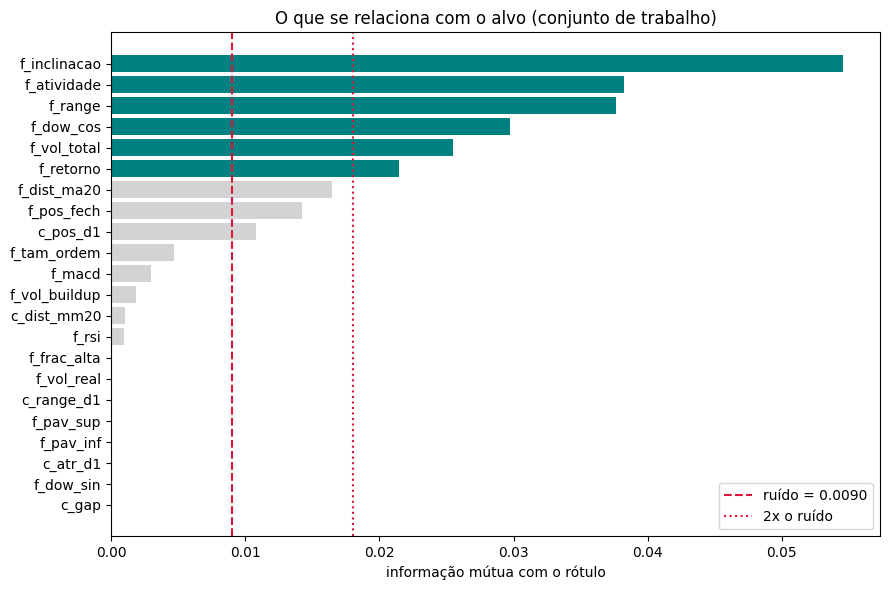

In [9]:
from sklearn.feature_selection import mutual_info_classif

# ═══════════════ 1. informação mútua com o rótulo, contra régua de ruído ═══════════════
mi = mutual_info_classif(X_trab, y_trab, random_state=0)
mi = pd.Series(mi, index=X_trab.columns).sort_values(ascending=False)

# régua: MI de uma feature puramente aleatória, média de 20 sorteios
rng = np.random.default_rng(0)
ruido = np.mean([
    mutual_info_classif(pd.DataFrame({"x": rng.normal(size=len(X_trab))}, index=X_trab.index),
                        y_trab, random_state=s)[0]
    for s in range(20)
])

print(f"Informação mútua com o rótulo — {len(X_trab)} dias do conjunto de trabalho")
print(f"(régua de ruído = {ruido:.5f}; features abaixo de 2x isso são indistinguíveis do acaso)\n")
for nome, v in mi.items():
    marca = "  <-- acima de 2x o ruído" if v > 2 * ruido else ""
    print(f"   {nome:<16}{v:>9.5f}{marca}")

acima = int((mi > 2 * ruido).sum())
print(f"\n{acima} de {len(mi)} features passam de 2x a régua de ruído.")

fig, ax = plt.subplots(figsize=(9, 6))
cores = ["teal" if v > 2 * ruido else "lightgray" for v in mi.values]
ax.barh(mi.index[::-1], mi.values[::-1], color=cores[::-1])
ax.axvline(ruido, color="crimson", ls="--", lw=1.5, label=f"ruído = {ruido:.4f}")
ax.axvline(2 * ruido, color="crimson", ls=":", lw=1.5, label="2x o ruído")
ax.set_xlabel("informação mútua com o rótulo")
ax.set_title("O que se relaciona com o alvo (conjunto de trabalho)")
ax.legend(); plt.tight_layout(); plt.show()

Mediana por classe e teste de Kruskal-Wallis (conjunto de trabalho)

                Compra  Lateral    Venda  separação_dp  p_kruskal
feature                                                          
f_vol_total     0.9902   1.0120   0.9920        0.1664     0.0282
f_vol_real      0.0011   0.0012   0.0011        0.1723     0.0353
f_atividade     0.0195   0.0209   0.0198        0.1947     0.0495
f_dow_sin       0.4339   0.4339   0.4339        0.0000     0.0857
f_retorno       0.0004  -0.0004  -0.0006        0.1588     0.0859
f_inclinacao    0.0000  -0.0000  -0.0000        0.1660     0.0969
f_tam_ordem     1.0064   0.9980   0.9964        0.2045     0.1157
f_vol_buildup   1.6168   1.5823   1.6601        0.2134     0.1505
c_range_d1      0.0146   0.0156   0.0148        0.1264     0.1554
f_frac_alta     0.5000   0.5000   0.5000        0.0000     0.2764
f_rsi          49.3888  49.1582  48.5133        0.0468     0.4101
f_pav_inf       0.2715   0.2804   0.2788        0.1972     0.4605
f_pos_f

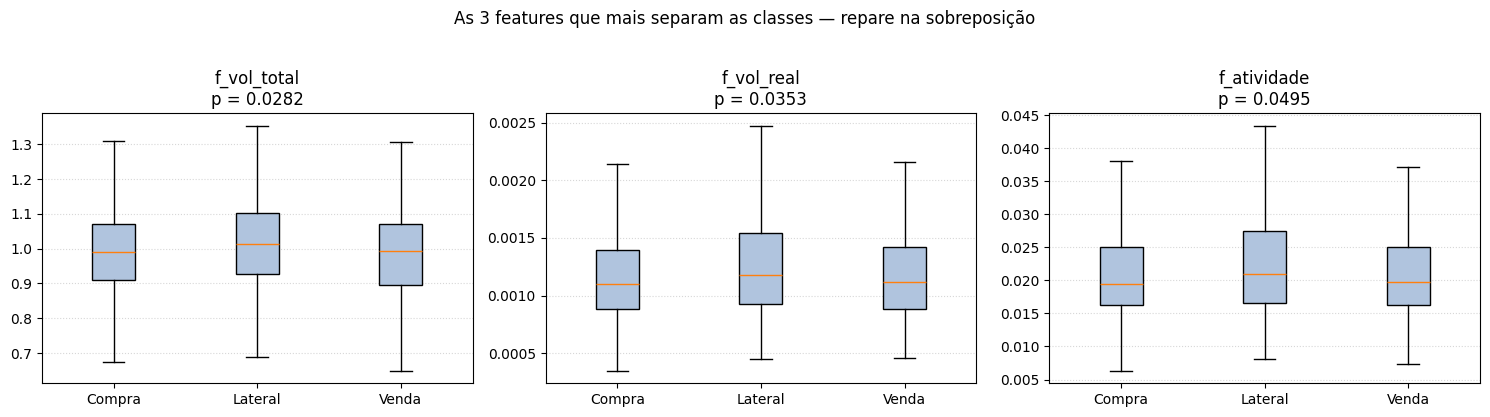

In [10]:
# ═══════════════ comparação direta com o rótulo: como cada feature se distribui por classe ═══════════════
from scipy.stats import kruskal

linhas = []
for col in X_trab.columns:
    med = [X_trab.loc[y_trab == c, col].median() for c in CLASSES]
    grupos = [X_trab.loc[y_trab == c, col].values for c in CLASSES]
    h, p = kruskal(*grupos)
    # separação em desvios-padrão: quanto as medianas se afastam, na escala da feature
    amp = (max(med) - min(med)) / X_trab[col].std()
    linhas.append({"feature": col, "Compra": med[0], "Lateral": med[1], "Venda": med[2],
                   "separação_dp": amp, "p_kruskal": p})

por_classe = pd.DataFrame(linhas).set_index("feature").sort_values("p_kruskal")
print("Mediana por classe e teste de Kruskal-Wallis (conjunto de trabalho)\n")
print(por_classe.round(4).to_string())

n_sig = int((por_classe["p_kruskal"] < 0.05).sum())
esperado = 0.05 * len(por_classe)
bonf = 0.05 / len(por_classe)
n_bonf = int((por_classe["p_kruskal"] < bonf).sum())

print(f"\nFeatures com p < 0,05 .................... {n_sig} de {len(por_classe)}")
print(f"Esperado por acaso ({len(por_classe)} testes a 5%) ....... ~{esperado:.0f}")
print(f"Limiar de Bonferroni (0,05 / {len(por_classe)}) .......... {bonf:.4f}")
print(f"Features que sobrevivem a Bonferroni ..... {n_bonf}")

# ---- boxplots das 3 features com menor p ----
top3 = por_classe.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, top3):
    dados = [X_trab.loc[y_trab == c, col].values for c in CLASSES]
    bp = ax.boxplot(dados, labels=CLASSES, showfliers=False, patch_artist=True)
    for caixa in bp["boxes"]:
        caixa.set_facecolor("lightsteelblue")
    ax.set_title(f"{col}\np = {por_classe.loc[col, 'p_kruskal']:.4f}")
    ax.grid(axis="y", ls=":", alpha=.5)
fig.suptitle("As 3 features que mais separam as classes — repare na sobreposição", y=1.03)
plt.tight_layout(); plt.show()

In [11]:
# ═══════════════ 2. redundância exata: o posto da matriz ═══════════════
Z = StandardScaler().fit_transform(X_trab)
posto = np.linalg.matrix_rank(Z)
print(f"Colunas: {X_trab.shape[1]}   |   posto da matriz: {posto}")
if posto < X_trab.shape[1]:
    print(f">>> {X_trab.shape[1] - posto} coluna(s) são combinação linear exata de outras.")
else:
    print(">>> Nenhuma redundância exata. Nenhuma feature é combinação linear das demais.")

# variância explicada acumulada: quantas dimensões efetivas existem
vals = np.linalg.svd(Z, compute_uv=False)
var = np.cumsum(vals ** 2) / (vals ** 2).sum()
n90 = int(np.searchsorted(var, 0.90)) + 1
print(f"    {n90} componentes explicam 90% da variância "
      f"({n90/X_trab.shape[1]:.0%} das colunas)")

# ═══════════════ 3. pares muito correlacionados ═══════════════
corr = X_trab.corr().abs()
pares = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().sort_values(ascending=False))
fortes = pares[pares > 0.8]

print(f"\nPares com |correlação| > 0,8: {len(fortes)}")
if len(fortes):
    for (a, b), v in fortes.items():
        print(f"   {a:<16} x {b:<16} {v:>6.3f}")
else:
    print("   nenhum — não há redundância alta entre as features")

print(f"\nOs 5 pares mais correlacionados (mesmo abaixo de 0,8):")
for (a, b), v in pares.head(5).items():
    print(f"   {a:<16} x {b:<16} {v:>6.3f}")

Colunas: 22   |   posto da matriz: 22
>>> Nenhuma redundância exata. Nenhuma feature é combinação linear das demais.
    13 componentes explicam 90% da variância (59% das colunas)

Pares com |correlação| > 0,8: 7
   f_vol_real       x f_atividade       0.942
   f_macd           x f_dist_ma20       0.935
   f_rsi            x f_dist_ma20       0.892
   f_retorno        x f_inclinacao      0.868
   f_pos_fech       x f_rsi             0.861
   f_pos_fech       x f_dist_ma20       0.860
   f_rsi            x f_macd            0.844

Os 5 pares mais correlacionados (mesmo abaixo de 0,8):
   f_vol_real       x f_atividade       0.942
   f_macd           x f_dist_ma20       0.935
   f_rsi            x f_dist_ma20       0.892
   f_retorno        x f_inclinacao      0.868
   f_pos_fech       x f_rsi             0.861


### O pair plot: para que ele serve aqui, e para que não serve

A matriz de correlação acima diz **quanto** dois números andam juntos. Ela não diz **de que
jeito**. Dois pares com o mesmo `r = 0,86` podem ser uma reta apertada, em que uma feature
é a outra com ruído, ou um leque, em que compartilham a tendência mas cada uma carrega
variação própria. A diferença decide se dá para descartar uma delas com segurança.

O gráfico abaixo desenha os 7 pares de `|r| > 0,8`, mais o par `f_dow_sin` × `f_dow_cos`,
que está aqui por outro motivo.

> **Antes de olhar, um aviso que vale mais que o gráfico.** É tentador usar pair plot para
> caçar separação entre classes, aquele caso em que nenhuma das duas features separa
> sozinha, mas o par separa. **Testei isso e não existe aqui.** Para cada um dos 231 pares
> calculei quanto a segunda dimensão acrescenta:
>
> ```
> ganho(A,B)  =  MI( par 2D ; rótulo )  −  máx( MI(A ; rótulo), MI(B ; rótulo) )
>
> p  =  fração das 200 permutações cujo MÁXIMO entre os 231 pares
>       foi maior ou igual ao máximo real
> ```
>
> Comparando com 200 permutações do rótulo:
>
> | | Real | Nulo (média) | Nulo p95 |
> |---|---:|---:|---:|
> | Maior ganho entre os 231 pares | 0,0333 | 0,0336 | 0,0376 |
> | Ganho mediano | 0,0182 | 0,0184 | n/d |
>
> **O melhor par de todos fica abaixo da média do acaso** (p = 0,490), e os pares que passam do
> p95 individual são **12 de 231, exatamente os 12 esperados por sorteio**. Num pair plot esses
> 12 pareceriam descobertas. *(reproduzido no Anexo A.17)*
>
> Isso fecha uma lacuna do argumento da seção *Quais features usar, e por que não cortar nenhuma*, que usa a possibilidade de interação para
> justificar manter as 22 features: no nível de pares, essa interação **não existe**. Não
> descarta interação de três ou mais features, mas par a par é o que um pair plot enxerga.
>
> Conclusão prática: aqui o pair plot é **diagnóstico de construção de feature**, não
> detector de sinal. É com esse propósito que ele entra.


par                               Pearson  Spearman  R² linear   formato
------------------------------------------------------------------------------
f_vol_real x f_atividade           +0.942    +0.974      0.887   reta apertada
f_macd x f_dist_ma20               +0.935    +0.925      0.874   leque
f_rsi x f_dist_ma20                +0.892    +0.937      0.796   leque
f_retorno x f_inclinacao           +0.868    +0.864      0.754   leque
f_pos_fech x f_rsi                 +0.861    +0.877      0.741   leque
f_pos_fech x f_dist_ma20           +0.860    +0.927      0.739   leque
f_rsi x f_macd                     +0.844    +0.883      0.713   leque
f_dow_sin x f_dow_cos              +0.206    +0.302      0.043   nuvem


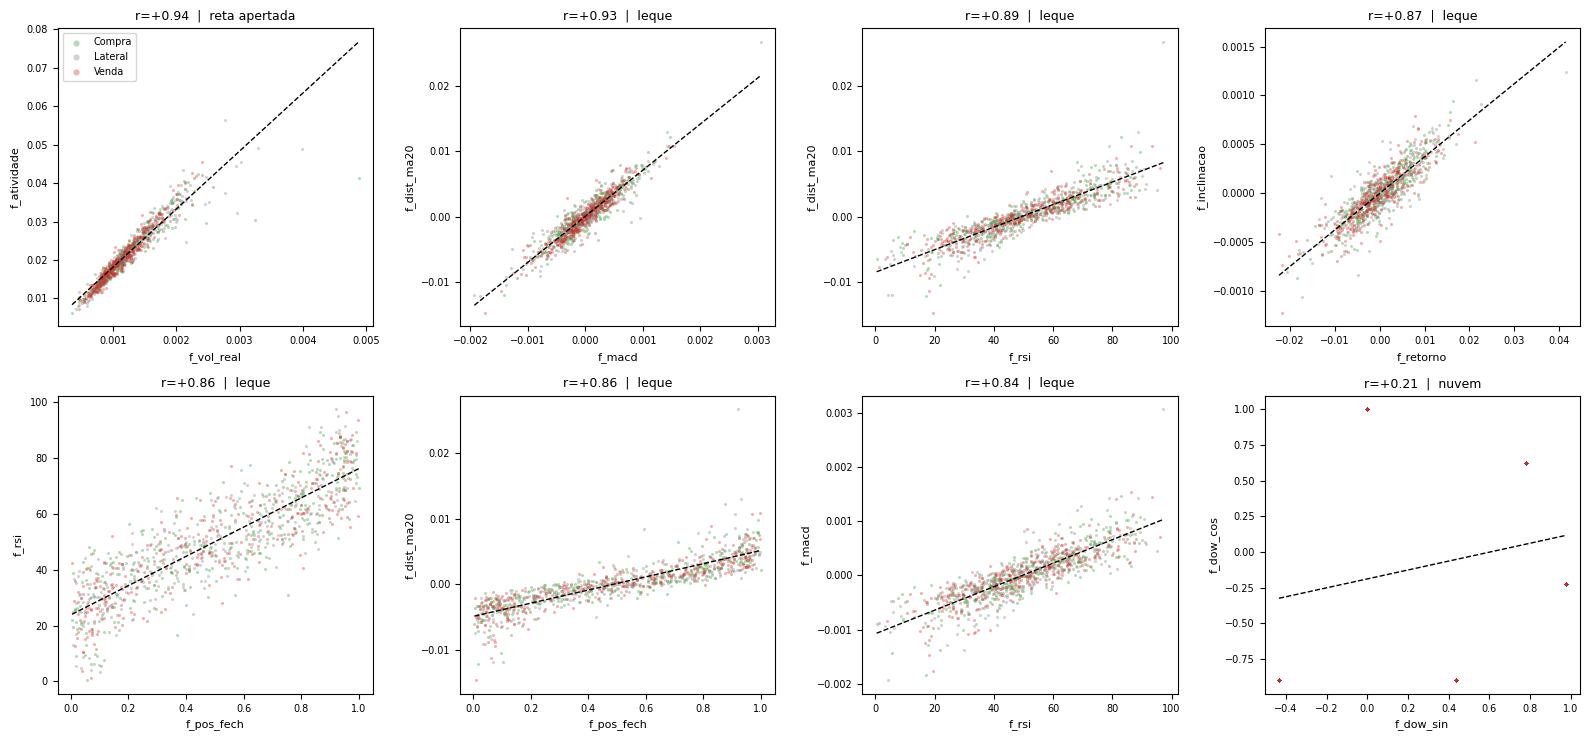


f_dow_sin x f_dow_cos — Pearson +0.206, mas raio = 1.000000 +/- 5.0e-17
  pontos distintos no plano: 5 (um por dia da semana)


In [12]:
# Formato dos pares muito correlacionados + o caso do seno/cosseno.
# Não é busca por sinal (medida e descartada acima): é diagnóstico de como as features
# foram construídas.
from scipy.stats import spearmanr

C = X_trab.corr()
pares = sorted(((a, b, C.loc[a, b]) for i, a in enumerate(X_trab.columns)
                for b in X_trab.columns[i + 1:] if abs(C.loc[a, b]) > 0.8),
               key=lambda t: -abs(t[2]))
pares.append(("f_dow_sin", "f_dow_cos", C.loc["f_dow_sin", "f_dow_cos"]))

print(f"{'par':<32}{'Pearson':>9}{'Spearman':>10}{'R² linear':>11}   formato")
print("-" * 78)
fig, eixos = plt.subplots(2, 4, figsize=(16, 7.5))
cores = dict(zip(CLASSES, ["tab:green", "tab:gray", "tab:red"]))

for ax, (a, b, r) in zip(eixos.ravel(), pares):
    for cl in CLASSES:                       # colore por rótulo só para conferência visual
        m = (y_trab == cl).values
        ax.scatter(X_trab[a][m], X_trab[b][m], s=5, alpha=0.35,
                   c=cores[cl], label=cl, linewidths=0)
    sp = spearmanr(X_trab[a], X_trab[b])[0]
    coef = np.polyfit(X_trab[a], X_trab[b], 1)
    res = (X_trab[b] - np.polyval(coef, X_trab[a])).std() / X_trab[b].std()
    forma = "reta apertada" if res < 0.35 else ("leque" if res < 0.6 else "nuvem")
    xs = np.linspace(X_trab[a].min(), X_trab[a].max(), 50)
    ax.plot(xs, np.polyval(coef, xs), color="k", lw=1, ls="--")
    ax.set_xlabel(a, fontsize=8); ax.set_ylabel(b, fontsize=8)
    ax.set_title(f"r={r:+.2f}  |  {forma}", fontsize=9)
    ax.tick_params(labelsize=7)
    print(f"{a + ' x ' + b:<32}{r:>+9.3f}{sp:>+10.3f}{1 - res**2:>11.3f}   {forma}")

eixos.ravel()[0].legend(fontsize=7, markerscale=2, loc="best")
plt.tight_layout(); plt.show()

# o par cíclico merece a conta explícita
s, c = X_trab["f_dow_sin"], X_trab["f_dow_cos"]
raio = np.sqrt(s**2 + c**2)
print(f"\nf_dow_sin x f_dow_cos — Pearson {C.loc['f_dow_sin','f_dow_cos']:+.3f}, "
      f"mas raio = {raio.mean():.6f} +/- {raio.std():.1e}")
print(f"  pontos distintos no plano: {len(set(zip(s.round(6), c.round(6))))} "
      f"(um por dia da semana)")

#### O que os oito painéis mostram

O `R²` da tabela não vem de uma regressão pronta: eu ajusto uma reta e comparo a dispersão
do resíduo com a dispersão original.

```
resíduo relativo  =  dp( y − reta(x) ) / dp( y )

R²  =  1  −  (resíduo relativo)²

ex.: f_vol_real × f_atividade tem resíduo relativo 0,336
     R²  =  1 − 0,336²  =  0,887
```

Quanto mais perto de 1, mais a segunda feature é a primeira com ruído; quanto mais longe,
mais variação própria ela carrega.

**Dos sete pares com `|r| > 0,8`, só um é uma reta apertada:** `f_vol_real` × `f_atividade`,
com Spearman 0,974 e R² de 0,887. Essas duas realmente medem a mesma coisa, volume realizado
e soma dos retornos absolutos sobem juntos porque dia agitado é dia de volume. Se algum dia
for preciso cortar por redundância, esse é o par onde cortar dói menos.

**Os outros seis são leques.** `f_rsi` × `f_macd` tem `r = 0,84` e R² de 0,713: quase 30% da
variação de um não é explicada pelo outro. Eles compartilham a tendência de momento, mas
divergem nos extremos, que é onde estariam os dias interessantes, se houvesse dias
interessantes. Descartar um deles pela correlação alta jogaria fora informação de verdade.

**E o oitavo painel é o mais instrutivo.** `f_dow_sin` × `f_dow_cos` tem correlação de Pearson
de apenas **+0,206**, pela matriz de correlação, elas pareceriam quase independentes. O
gráfico mostra outra coisa: **todos os pontos caem sobre o círculo de raio 1**, em cinco
posições, uma por dia da semana. A dependência entre elas é **perfeita e determinística**;
o que a correlação linear mede é só a projeção disso numa reta.

```
raio = sqrt(sin² + cos²) = 1,000000 ± 5e-17        5 pontos distintos, ~195 dias cada
```

É a demonstração mais limpa de por que a matriz de correlação não basta: **correlação baixa
não é evidência de independência.** Duas features podem ter `r ≈ 0` e uma ser função exata da
outra. No caso das cíclicas isso é inofensivo, porque a codificação é intencional, mas o
mesmo cegamento valeria para qualquer relação curva entre features de verdade.

*(A propósito: as duas têm MI de 0,000 e 0,012 com o rótulo. O dia da semana não prevê nada
aqui, o gráfico é sobre geometria, não sobre utilidade.)*


### Como ler esta seção

**Se poucas features passarem da régua**, não é motivo para desistir, informação mútua
mede dependência de cada feature **isoladamente**. Uma feature pode ser inútil sozinha e
valiosa em combinação com outra, e a MI univariada não enxerga isso. Modelos de árvore e
redes enxergam.

**Mas se quase nenhuma passar**, é um sinal forte. Significa que o sinal, se existir, está
inteiramente em interações, o que é possível, mas é uma aposta bem mais difícil com ~1.000
amostras.

**Sobre a redundância:** ausência de redundância exata é o mínimo, não uma conquista. O que
essa checagem pega é o erro de incluir simultaneamente "as partes" e "o todo", como
`pavio_superior + pavio_inferior + corpo = range`, que apareceu no conjunto de features
da ideia primária e daria
posto menor que o número de colunas.

> **Uma coisa que esta seção não faz: escolher features pelo resultado.** É tentador olhar a
> tabela, cortar tudo que ficou abaixo da régua e treinar de novo. Isso é seleção de features
> usando o mesmo dado que depois vai medir o modelo, e infla o resultado de um jeito que o
> walk-forward não detecta, porque a decisão foi tomada fora dele. Se eu quisesse selecionar
> features de verdade, teria que fazer isso **dentro** de cada fold de treino.

### O que a comparação por classe revelou

Vale registrar o resultado, porque ele muda como se lê a tabela de informação mútua.

**Só 3 das 22 features diferem entre as classes a p < 0,05.** Com 22 testes, o esperado por
puro acaso é ~1, e **nenhuma sobrevive à correção de Bonferroni**. As duas contas:

```
esperado por acaso  =  α × nº de testes  =  0,05 × 21  =  1,05 features

limiar de Bonferroni  =  α / nº de testes  =  0,05 / 21  =  0,0024
```

O menor `p` observado foi 0,0282, quase doze vezes o limiar de 0,0024, então nenhuma das três
resiste [Dunn, 1961].

> **Sobre a estatística do Kruskal-Wallis.** Ela compara a soma dos postos entre os grupos, e
> a forma fechada está em [Kruskal & Wallis, 1952] *(ver a seção Referências)*; o `p` sai da distribuição
> qui-quadrado com `k − 1` graus de liberdade. Não reproduzo a derivação porque é padrão e a
> implementação usada é a do `scipy.stats.kruskal`.

**As três são todas de volume e atividade:** `f_vol_total`, `f_vol_real` e `f_atividade`. E
o padrão é o mesmo nas três, os dias rotulados **Lateral têm valores maiores** que os de
Compra e Venda.

Isso é interpretável, e aponta para um lugar específico. "Lateral" neste rótulo significa
"o movimento teve pavio grande contra", ou seja, janela-alvo bagunçada. O que a tabela diz
é: **manhã agitada prevê 11h agitada.** Isso é persistência de volatilidade, não previsão de
direção, exatamente a hipótese da variante V4 no fim do notebook.

**Mas a separação é minúscula.** A amplitude entre as medianas é de 0,17 a 0,19
desvios-padrão, e os intervalos interquartis se sobrepõem quase por completo. Os boxplots
mostram isso melhor que qualquer número: as três caixas praticamente coincidem.

> **Uma inconsistência que vale encarar.** O ranking da informação mútua e o do
> Kruskal-Wallis **não concordam**. A MI coloca `f_inclinacao` em primeiro (0,055); o Kruskal
> dá p = 0,097 para ela, não significativo. Já `f_vol_real`, que o Kruskal aponta como uma
> das três melhores, tem MI de 0,000.
>
> Isso não é erro de nenhum dos dois, eles medem coisas diferentes (MI capta relação de
> qualquer formato, Kruskal compara postos entre grupos). Mas a discordância entre dois
> métodos aplicados à mesma pergunta é, por si só, o resultado mais informativo desta seção:
> **nesses tamanhos de efeito, nenhum ranking de features é estável.** Tratar qualquer uma
> dessas ordenações como verdade seria ler ruído.
>
> **E dá para mostrar que a instabilidade é do estimador, não dos dados.** `f_vol_real` e
> `f_atividade` correlacionam **0,942**, são quase a mesma medida. Mesmo assim a MI de uma é
> **0,000** e a da outra é **0,038**. Duas features quase idênticas não podem carregar
> quantidades tão diferentes de informação sobre o mesmo rótulo; o que a diferença mede é o
> **ruído do estimador de MI por k-vizinhos** nesse tamanho de amostra. Sozinho, isso já
> desqualifica o ranking de MI como critério de seleção, e é coerente com a seção *Quais features usar, e por que não cortar nenhuma*, onde
> escolher as 5 melhores por MI saiu **indistinguível de sortear 5 ao acaso** (z = +0,48).


---
## Modelos tabulares

Sete modelos sobre as 22 features (17 da janela + 5 de contexto diário). Com 976 dias de trabalho, esse é o regime de
dados certo, as redes vêm na seção seguinte, mas já com a expectativa declarada de que
estão fora da zona de conforto delas.

### Quem está na lista e por quê

> Fontes dos métodos: SVM [Cortes & Vapnik, 1995], Random Forest [Breiman, 2001],
> Gradient Boosting [Friedman, 2001], XGBoost [Chen & Guestrin, 2016] *(ver a seção Referências)*.

| Modelo | O que ele traz | Por que está aqui |
|---|---|---|
| **Baseline (majoritária)** | chuta sempre a classe mais comum | piso da acurácia, o número a bater |
| **Baseline (estratificado)** | sorteia na proporção das classes | piso do F1-macro |
| **Regressão logística** | fronteira linear | se um modelo linear já resolve, não preciso de nada mais complexo |
| **SVM (RBF)** | fronteira não linear via kernel | captura interação sem precisar de muitos dados |
| **Random Forest** | árvores independentes, votação | robusto a ruído e a feature irrelevante |
| **Gradient Boosting** | árvores em sequência, cada uma corrige a anterior | costuma ser o melhor em dado tabular deste tamanho |
| **XGBoost** | boosting com regularização mais forte | mesma família, implementação mais controlada |

A ordem não é acidental: ela vai do mais simples ao mais complexo. Se a regressão
logística já batesse o baseline, eu não precisaria de árvore nenhuma. E se nenhum deles
bate, é sinal de que o problema não está na capacidade do modelo.

### Os hiperparâmetros são propositalmente conservadores

`max_depth=2` no Gradient Boosting, `max_depth=4` e `min_samples_leaf=10` na Random
Forest, `learning_rate=0.05`. Nada disso foi otimizado.

Isso é deliberado. Com 976 amostras, uma busca de hiperparâmetros com dezenas de tentativas
encontraria a combinação que melhor se ajusta ao **ruído** do conjunto de validação, não a
que generaliza. Modelo raso e regularizado é a escolha certa nesse tamanho de amostra.

Se algum modelo mostrasse sinal aqui, aí sim valeria abrir uma busca, mas com validação
aninhada, com a busca acontecendo *dentro* de cada fold de treino.

### O SVM tem capacidade também, só que ela não se chama "parâmetros"

Na seção *Modelos sequenciais (deep learning)* eu conto parâmetros treináveis para argumentar que as redes estão fora da zona de
conforto. O SVM parece escapar dessa conta, porque não tem camadas nem pesos para somar. Mas
tem o equivalente: **o número de vetores de suporte é a contagem de parâmetros efetivos de
um SVM.** O conceito é de [Cortes & Vapnik, 1995] *(ver a seção Referências)*. São os pontos de treino que o modelo precisa guardar para reconstruir a fronteira.

Medi quantos pontos viram vetor de suporte com kernel RBF, usando dados **aleatórios, sem
sinal nenhum**, o cenário em que qualquer ajuste é memorização pura:

| Cenário | `C` | Vetores de suporte | % do treino |
|---|---:|---:|---:|
| 976 amostras, 22 features (o que uso aqui) | 1 | 969 | 99% |
| 976 amostras, 22 features | 10.000 | 961 | 98% |
| 976 amostras, **120 features** (vetor achatado) | 1 | 976 | **100%** |
| 78 amostras, **264 features** | 1 | 78 | **100%** |

*(reproduzido no Anexo A.18)*

**Praticamente todo ponto vira vetor de suporte.** Um parâmetro por amostra, o mesmo regime
das redes, expresso em outro vocabulário. É por isso que o SVM entra aqui com `C=1.0` e
`gamma="scale"`, e não com uma busca que possa levar o `C` para 10⁴: com dados padronizados,
`C` grande é margem rígida, ou seja, regularização praticamente desligada.

> **Como ler o resultado dele.** Se o SVM (RBF) aparecer no topo da tabela, vale desconfiar
> antes de comemorar, com quase 100% de vetores de suporte, ele tem capacidade de sobra para
> encaixar ruído, e a diferença entre "aprendeu" e "decorou" vai depender inteiramente do
> ganho sobre o baseline no fold de **teste**, não do número de treino.

### O wrapper do XGBoost

O XGBoost só aceita rótulo numérico. Em vez de espalhar conversão de classe pelo notebook
inteiro, embrulhei ele numa classe que converte texto→número na entrada e número→texto na
saída. Assim ele se comporta como os outros modelos do scikit-learn e o resto
do código não precisa saber da diferença.

### Como ler a tabela de resultados

A coluna que importa é **`ganho_medio`**, a diferença de acurácia entre o modelo e o
baseline majoritário. Positivo e consistente significa que aprendeu alguma coisa. Zero ou
negativo significa que não.

E olhe sempre o `acc_dp` junto: se o desvio entre sementes for maior que o ganho, o ganho
não é real.

### A linha de base univariada: por que ARIMA/SARIMA não entra na lista

Uma pergunta natural é por que não há um ARIMA aqui. Ele é o modelo clássico de série
temporal, e a versão sazonal (SARIMA) parece feita sob medida para um ativo com padrão
intradiário: abertura volátil, calmaria no meio, movimento no fim.

Não está na lista porque dá para calcular o **teto** dele antes de rodar, e o teto é nulo.

**O argumento.** Um `ARIMA(p, d, q)` sobre preços usa `d=1` (diferenciação) para virar
estacionário, e depois modela a **autocorrelação da série diferenciada**, ou seja, dos
retornos. As partes AR e MA são exatamente isso: quanto o retorno de agora é previsível a
partir dos retornos e dos erros anteriores. Então basta medir quanta autocorrelação existe.

Rodei nas 12.062 barras H1 do WIN (2021-08-13 a 2026-08-12):

O teste de estacionariedade é o ADF de [Dickey & Fuller, 1979]; a família de modelos é a de
[Box & Jenkins, 1970] *(ver a seção Referências)*.

| Teste | Resultado | Leitura |
|---|---|---|
| ADF no preço | estat. −0,55, **p = 0,883** | não estacionária, como esperado |
| ADF no retorno (`d=1`) | estat. −77,76, **p ≈ 0** | estacionária, `d=1` basta |

Confirmado o `d=1`, a pergunta que decide tudo é a autocorrelação dos retornos:

| lag | ACF | banda 95% | fora da banda? |
|---:|---:|---:|---|
| 1 | **−0,0293** | 0,0178 | sim |
| 9 | **−0,0271** | 0,0179 | sim |
| 2–8, 10 | entre −0,012 e +0,014 | ≈0,0179 | não |

*(reproduzido no Anexo A.19)*

Dois lags saem da banda, com 12 mil barras, dá para detectar coeficientes minúsculos. Mas o
maior é **−0,029**, e um AR(1) com ρ = 0,029 explica ρ² = **0,086% da variância dos
retornos**.

**Esse é o teto de toda a família.** Não é questão de ordem mal escolhida, e nenhum
`auto_arima` conserta: a estrutura linear que o ARIMA existe para capturar tem magnitude de
um décimo de por cento. Com o `CUSTO_PONTOS` de 7 pontos por operação usado aqui, não há como converter
isso em resultado.

Para dimensionar: a previsão ingênua "o próximo fechamento é igual ao atual", que é o que um
ARIMA nesses dados converge a fazer, dá um **RMSE de 498 pontos** e **48,3% de acurácia
direcional**. Abaixo dos 50% de uma moeda.

> **O uso legítimo disto.** Não é descartar o ARIMA, é usá-lo como **linha de base
> univariada declarada**. Ter medido que o histórico de preço sozinho rende 0,086% dá uma
> referência honesta contra a qual comparar qualquer modelo multivariado, e é um resultado
> publicável por si só num paper que reporta achado nulo.
>
> **E cuidado com a conclusão fácil.** Mostrar que o preço sozinho não prevê o preço **não**
> demonstra que features adicionais preveem. Ver a seção *Eliminar uma hipótese não confirma a alternativa*.



In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

MODELOS_TABULARES = {
    "Baseline (majoritária)":   lambda s: DummyClassifier(strategy="most_frequent"),
    "Baseline (estratificado)": lambda s: DummyClassifier(strategy="stratified", random_state=s),
    "Regressão logística":      lambda s: LogisticRegression(max_iter=2000, C=1.0, random_state=s),
    "SVM (RBF)":                lambda s: SVC(C=1.0, gamma="scale", random_state=s),
    "Random Forest":            lambda s: RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=10, random_state=s, n_jobs=-1),
    "Gradient Boosting":        lambda s: GradientBoostingClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=s),
}

try:
    import xgboost as xgb

    class XGBTexto:
        """Wrapper para o XGBoost aceitar rótulo em texto igual aos outros modelos."""
        def __init__(self, semente):
            self.m = xgb.XGBClassifier(
                n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                colsample_bytree=0.8, reg_lambda=1.0, random_state=semente, n_jobs=-1,
                objective="multi:softprob", num_class=3, verbosity=0)
            self.classes_ = np.array(CLASSES)

        def fit(self, X, y):
            self.m.fit(X, pd.Series(y).map({c: i for i, c in enumerate(CLASSES)}).values)
            return self

        def predict(self, X):
            return self.classes_[self.m.predict(X)]

    MODELOS_TABULARES["XGBoost"] = lambda s: XGBTexto(s)
except ImportError:
    print("xgboost indisponível — pulando esse modelo.\n")

resultados = []
for nome, ctor in MODELOS_TABULARES.items():
    t0 = time.time()
    r = avaliar_multi_semente(nome, ctor, X_trab, y_trab)
    r["segundos"] = time.time() - t0
    r["familia"] = "tabular"
    resultados.append(r)
    print(f"{nome:<26} acc={r['acc_media']:.3f}±{r['acc_dp']:.3f}  "
          f"f1m={r['f1_media']:.3f}±{r['f1_dp']:.3f}  "
          f"ganho={r['ganho_medio']:+.3f}  ({r['segundos']:.0f}s)")

tabela = pd.DataFrame(resultados).set_index("modelo")
tabela[["acc_media", "acc_dp", "f1_media", "f1_dp", "ganho_medio", "ganho_dp"]].round(4)

Baseline (majoritária)     acc=0.352±0.000  f1m=0.173±0.000  ganho=+0.000  (1s)
Baseline (estratificado)   acc=0.340±0.013  f1m=0.337±0.013  ganho=-0.012  (1s)
Regressão logística        acc=0.317±0.000  f1m=0.300±0.000  ganho=-0.035  (1s)
SVM (RBF)                  acc=0.328±0.000  f1m=0.295±0.000  ganho=-0.023  (2s)
Random Forest              acc=0.346±0.007  f1m=0.281±0.008  ganho=-0.006  (28s)
Gradient Boosting          acc=0.349±0.009  f1m=0.337±0.009  ganho=-0.003  (80s)
XGBoost                    acc=0.353±0.007  f1m=0.342±0.008  ganho=+0.001  (17s)


,acc_media,acc_dp,f1_media,f1_dp,ganho_medio,ganho_dp
modelo,,,,,,
Baseline (majoritária),0.3519,0.0000,0.1733,0.0000,0.0000,0.0000
Baseline (estratificado),0.3401,0.0131,0.3371,0.0132,-0.0117,0.0131
Regressão logística,0.3173,0.0000,0.3003,0.0000,-0.0346,0.0000
SVM (RBF),0.3284,0.0000,0.2951,0.0000,-0.0235,0.0000
Random Forest,0.3463,0.0075,0.2811,0.0081,-0.0056,0.0075
Gradient Boosting,0.3488,0.0093,0.3369,0.0085,-0.0031,0.0093
XGBoost,0.3526,0.0066,0.3423,0.0076,0.0007,0.0066


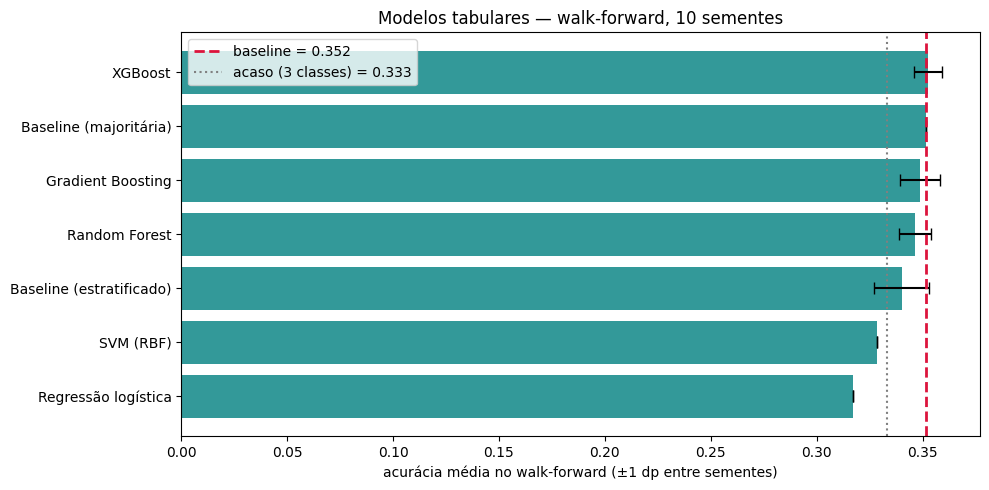

In [14]:
ordem = tabela.sort_values("acc_media")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(ordem.index, ordem["acc_media"], xerr=ordem["acc_dp"],
        color="teal", alpha=0.8, capsize=4)
ax.axvline(tabela["base_acc"].iloc[0], color="crimson", ls="--", lw=2,
           label=f"baseline = {tabela['base_acc'].iloc[0]:.3f}")
ax.axvline(1/3, color="gray", ls=":", lw=1.5, label="acaso (3 classes) = 0.333")
ax.set_xlabel("acurácia média no walk-forward (±1 dp entre sementes)")
ax.set_title("Modelos tabulares — walk-forward, 10 sementes")
ax.legend(); plt.tight_layout(); plt.show()

---
## Modelos sequenciais (deep learning)

Aqui as arquiteturas recebem a **sequência inteira**, não o resumo. É a parte que responde
diretamente à discussão do começo do notebook sobre como conectar as velas na rede.

### O formato dos dados muda

Enquanto os modelos tabulares recebem uma matriz `(dias, 21)`, estes recebem duas
entradas, um tensor 3D com a sequência e um vetor com o contexto:

```
(1.213 dias, 24 velas, 5 medidas)  +  (1.213 dias, 5 de contexto)
```

As 5 medidas de cada vela são todas relativas ao preço, para funcionarem igual em qualquer
nível do índice:

| Medida | Fórmula | O que descreve |
|---|---|---|
| `r_retorno` | `(fecha − abre) / abre` | direção e tamanho do corpo |
| `r_range` | `(máxima − mínima) / abre` | amplitude total da vela |
| `r_pav_sup` | `(máxima − topo do corpo) / abre` | rejeição de preço em cima |
| `r_pav_inf` | `(base do corpo − mínima) / abre` | rejeição de preço embaixo |
| `r_vol` | volume ÷ média móvel de 50 velas | volume relativo ao normal recente |

Juntas, elas descrevem a **forma** de cada vela, que é o que a análise técnica
clássica lê num gráfico de candles.

### As quatro arquiteturas e o viés de cada uma

**MLP**, é a Arquitetura 2 da introdução. Achata a sequência e conecta tudo a todos os
neurônios. Cada neurônio oculto vê todas as 24 velas ao mesmo tempo e pode virar um
detector de padrão que combina velas distantes.
*Limitação:* não tem noção de ordem. Para ele, trocar a vela 3 com a vela 20 seria só
outra entrada qualquer.

**CNN 1D**, resolve justamente a rigidez do Teste 1. O filtro convolucional desliza pela
sequência procurando o mesmo padrão **em qualquer posição**. Se um engolfo de alta é sinal
de compra, a CNN reconhece ele às 09:30 e às 10:30 com os mesmos pesos.
Uso `padding="causal"` para que cada posição só enxergue o passado, nunca o futuro.

**LSTM**, processa vela a vela carregando um estado interno. [Hochreiter & Schmidhuber, 1997] Em vez de olhar tudo de uma
vez, ela constrói uma memória do que veio antes e decide o que guardar e o que esquecer.
É a arquitetura desenhada para série temporal.
*Limitação:* é a que mais precisa de dados, e 969 amostras é pouco.

**TCN**, convolução dilatada. [Bai et al., 2018] Empilha camadas com espaçamento crescente (1, 2, 4) e
alcança a janela inteira com poucas camadas. Combina o campo receptivo grande da LSTM com
o treino paralelo da CNN.

### Como a convolução realmente lê os dados

Vale abrir a mecânica da `Conv1D`, porque tem uma confusão comum embutida e ela muda o que se
espera do modelo.

**O kernel não olha uma feature de cada vez. Ele olha todas de uma vez, num pedaço do tempo.**

O tensor de entrada é `(24 velas, 5 medidas)`. Um kernel com `kernel_size=3` é uma matriz de
pesos `(3, 5)`, três passos de tempo por cinco medidas. Ele se posiciona sobre as velas 1 a 3,
multiplica cada um dos `3 × 5 = 15` pesos pelo valor correspondente, soma tudo, adiciona o viés,
e produz **um único número**.

Com um exemplo reduzido para 3 medidas, para caber na página:

```
dados (velas 1-3)                    kernel (pesos)
        r_retorno  r_range  r_vol            w_ret  w_rng  w_vol
vela 1 [  0.0012    0.0031   1.15 ]   ×   [  w11    w12    w13  ]
vela 2 [ -0.0004    0.0028   0.92 ]       [  w21    w22    w23  ]
vela 3 [  0.0021    0.0045   1.480]       [  w31    w32    w33  ]

resultado = 0.0012·w11 + 0.0031·w12 + 1.15·w13
          + (-0.0004)·w21 + 0.0028·w22 + 0.92·w23
          + 0.0021·w31 + 0.0045·w32 + 1.48·w33 + viés
          = um número
```

Depois o kernel desliza uma posição, velas 2 a 4, e repete. A sequência de números que ele
produz é o **mapa de features**: onde, ao longo da manhã, e com que intensidade, aquele padrão
específico apareceu.

**A consequência prática:** o kernel aprende **padrões multivariados**. Ele não aprende "o que o
volume faz" separado de "o que o retorno faz", ele aprende coisas como *"range crescendo
enquanto o volume cai, por três velas seguidas"*. É essa combinação que a MLP teria dificuldade
em montar a partir do vetor achatado.

Com `filters=32`, são 32 kernels independentes, cada um convergindo para um padrão diferente.

---

### TCN: convolução dilatada, e por que o campo receptivo dela sobra aqui

A TCN é a arquitetura mais elaborada das quatro, e a que mais precisa de justificativa,
porque a vantagem que ela oferece depende de uma condição que este problema não satisfaz.

#### O mecanismo: dilatação

Uma convolução normal com `kernel_size=3` olha três posições **adjacentes**: velas
`[1, 2, 3]`. Uma convolução **dilatada** pula posições:

| Dilatação | Velas que o kernel enxerga | Alcance |
|---|---|---|
| 1 | `[1, 2, 3]` | 3 passos |
| 2 | `[1, 3, 5]` | 5 passos |
| 4 | `[1, 5, 9]` | 9 passos |
| 8 | `[1, 9, 17]` | 17 passos |

Empilhando camadas com dilatação crescente, o alcance cresce **exponencialmente** com a
profundidade, em vez de linearmente. Três camadas com dilatações 1, 2 e 4 alcançam mais do
que dez camadas convencionais.

#### O bloco residual

Cada bloco da TCN tem esta estrutura, duas convoluções dilatadas com dropout entre elas,
e uma conexão residual que soma a entrada à saída:

```mermaid
graph LR
    A[Entrada] --> B[Conv dilatada]
    B --> C[ReLU]
    C --> D[Dropout]
    D --> E[Conv dilatada]
    E --> F[ReLU]
    F --> G[Dropout]
    G --> I(("+"))
    A -->|conexão residual| I
    I --> J[Saída]
```

A **conexão residual** é o que permite empilhar blocos sem que o gradiente se degrade, o
mesmo truque das ResNets. Sem ela, uma pilha profunda de convoluções dilatadas seria tão
difícil de treinar quanto a LSTM que ela pretende substituir.

E o `padding="causal"` garante que cada posição só enxergue o passado. Numa série temporal
isso não é detalhe: com padding simétrico, a vela 5 veria a vela 7, e o modelo estaria
treinando com informação do futuro dentro da própria janela.

#### As três vantagens reais

| Vantagem | Por quê |
|---|---|
| **Processamento paralelo** | não há recorrência; a sequência inteira é processada de uma vez, muito mais rápido que LSTM |
| **Campo receptivo grande** | dilatação exponencial alcança o início da sequência com poucas camadas |
| **Memória estável** | não sofre do gradiente que desaparece ao longo dos passos, problema clássico das recorrentes |

Tudo isso é verdade, e foi demonstrado em benchmarks de áudio, texto e séries longas, onde
a TCN compete de igual para igual com LSTMs e Transformers.

#### O problema: a sequência aqui tem 24 passos

O campo receptivo de uma TCN é:

```
campo = 1 + 2 · (kernel_size − 1) · nb_stacks · Σ(dilations)
```

Com as dilatações `[1, 2, 4, 8]` que se costuma usar por padrão, `Σ = 15`:

| kernel | Campo receptivo | Contra uma sequência de 24 |
|---|---|---|
| 2 | 31 | **cobre tudo, com sobra** |
| 3 | 61 | cobre 2,5× |
| 5 | 121 | cobre 5× |
| 7 | **181** | **cobre 7,5×** |

**Já com o menor kernel possível, o campo receptivo excede a sequência inteira.** Com kernel
7, ele alcança 181 passos numa janela que tem 24, sete vezes mais do que existe para
alcançar.

A dilatação está resolvendo um problema que não está presente. Ela foi criada para sequências
de centenas ou milhares de passos, onde ligar o fim ao início é genuinamente difícil. Aqui,
**duas `Conv1D` empilhadas com kernel 3 já cobrem 5 passos, e o `GlobalAveragePooling1D` no
fim agrega os 24 de uma vez**, sem dilatação nenhuma.

#### O que eu uso, e por quê

```python
TCN(nb_filters=32, kernel_size=3, dilations=[1, 2, 4], padding="causal", ...)
```

Dilatações `[1, 2, 4]` em vez de `[1, 2, 4, 8]`, o que dá campo receptivo de **29**, ainda
acima de 24, mas na ordem de grandeza certa em vez de 7× maior. Manter a dilatação 8 seria
adicionar parâmetros para alcançar posições que não existem.

> **Um detalhe de implementação.** A camada `TCN` do `keras-tcn` não aceita
> `kernel_regularizer`, então esta é a única das quatro arquiteturas em que o L2 da seção *Configuração das redes: cada peça e por que este valor*
> **não alcança as camadas convolucionais**, o ramo sequencial dela conta apenas com o
> `dropout_rate` interno. Somado a ser a que mais tem parâmetros (**17.987**, contra 5.443 da
> CNN), isso a deixa em desvantagem estrutural nesta comparação, a tabela medida está na
> seção *L1 e L2, a diferença que importa*. Vale ter em mente ao ler o resultado dela.

> **Consequência.** Campo receptivo maior não é melhor, é **adequado ou inadequado ao
> comprimento da sequência**. Escolher TCN por causa do alcance longo, numa janela de 24
> passos, é comprar uma capacidade que não tem onde ser usada, e pagar por ela em parâmetros
> e variância. Nos testes, a TCN ficou em último lugar entre as quatro arquiteturas.

> **Uma nota sobre o custo de otimizar isto.** Uma busca de hiperparâmetros com 12 dimensões
> e 10 trials dá **0,8 trial por dimensão**, é amostragem aleatória com nome de otimização.
> E se a validação cruzada interna usar `n_splits=20` sobre 78 amostras, cada fold de teste
> fica com **3 amostras**, e o F1-macro de 3 classes medido em 3 amostras é um número que só
> pode assumir alguns valores discretos. Os 200 treinamentos resultantes produzem ruído caro.
> É por isso que aqui os hiperparâmetros são **fixos e justificados** (seção *Configuração das redes: cada peça e por que este valor*), e o
> `n_splits` é 5, 162 amostras por fold de teste.

### O erro silencioso que quebra a CNN: normalizar na hora errada

Este é o alerta mais importante desta seção, porque o erro **não gera exceção, não aparece em
nenhuma métrica de treino, e só torna o resultado pior sem dizer por quê**.

A CNN existe para reconhecer o mesmo padrão **em qualquer posição** da sequência, é a chamada
invariância à translação, e é ela que justifica usar convolução em vez de uma camada densa.

Existem duas formas de padronizar o tensor, e **só uma preserva essa propriedade**:

| Forma | Como | O que acontece |
|---|---|---|
| **Por feature** ✅ | `reshape(-1, n_features)`, empilha todas as posições e calcula uma média por medida | a vela 1 e a vela 24 compartilham a mesma escala |
| **Achatada** ❌ | trata cada par (vela, medida) como coluna independente | cada posição ganha média e desvio próprios |

Testei o efeito num tensor sintético em que a medida cresce ao longo das velas:

| Padronização | Média na vela 1 | Média na vela 24 |
|---|---|---|
| Por feature | −1,64 | **+1,65** |
| Achatada | −0,00 | −0,00 |

Achatando, **cada posição é centrada separadamente**. O mesmo padrão ocorrendo às 09:30 e às
10:30 vira números diferentes depois da normalização, e o kernel compartilhado, que existe
para reconhecê-lo nos dois lugares, deixa de conseguir.

> **É uma CNN treinada sem poder usar a única vantagem que a CNN tem.** E nada no código
> indica isso: ele roda, a rede treina, a perda cai. O resultado só é pior.

Por isso o código da seção usa:

```python
mu = T[i_tr].reshape(-1, T.shape[-1]).mean(0)     # uma média por MEDIDA
sd = T[i_tr].reshape(-1, T.shape[-1]).std(0) + 1e-9
```

O `reshape(-1, T.shape[-1])` empilha os `n_dias × 24` passos numa matriz de 5 colunas, calcula
média e desvio **por coluna**, e devolve ao formato original. Cinco médias, não 120.

> **A exceção é o bloco de contexto.** Ele não é sequência, `c_gap` e `c_atr_d1` são grandezas
> distintas, sem relação de posição entre si. Esse é padronizado coluna a coluna, como qualquer
> tabela. É por isso que existem dois scalers separados em `walk_forward_keras`.

---

### Um limite que a sequência curta impõe: pooling

`MaxPooling1D` reduz o comprimento da sequência, o que em visão computacional é barato, sobram
centenas de pixels. Aqui a sequência tem **24 passos**, e cada pooling de tamanho 2 corta pela
metade:

```
24 → pool(2) → 12 → pool(2) → 6 → pool(2) → 3
```

Depois de três poolings sobram 3 passos, e a convolução não tem mais sequência para varrer. Por
isso as arquiteturas aqui **não usam pooling**: elas empilham duas `Conv1D` com `padding="causal"`
(que preserva o comprimento) e resumem no fim com `GlobalAveragePooling1D`, que colapsa os 24
passos de uma vez só, sem estágios intermediários.

### O MLP não está aqui para ganhar, está aqui como controle

Das quatro arquiteturas, o MLP é a única que **não** foi desenhada para sequência. Ele achata
as 24 velas num vetor e trata cada posição como uma entrada independente. Para ele, trocar a
vela 3 pela vela 20 é só outra entrada.

Isso parece uma desvantagem, e é, mas é justamente o que o torna útil. **Ele é o grupo de
controle do experimento.**

A pergunta que CNN, LSTM e TCN existem para responder é: *a ordem das velas carrega
informação?* As três apostam que sim, cada uma de um jeito. O MLP é a hipótese nula dessa
pergunta, o modelo que ignora a ordem por construção.

Comparar os três contra ele é o equivalente a ter um placebo:

| Se o resultado for… | A leitura é |
|---|---|
| CNN/LSTM/TCN **claramente acima** do MLP | existe padrão sequencial, e o viés indutivo delas o captura |
| Todas **empatadas** com o MLP | **não há padrão sequencial para achar**, a sequência não acrescenta sobre o conjunto de velas |
| MLP **acima** das outras | há sinal, mas em posições fixas; o viés de invariância à translação está atrapalhando |

Repare que **as três leituras são informativas**. Não existe cenário em que rodar o MLP seja
desperdício, mesmo que ele perca, o quanto ele perde mede o valor da estrutura sequencial.

É por isso que ele fica na comparação apesar de a teoria da introdução recomendar não usá-lo.
A recomendação está certa sobre *operar* com MLP; está errada sobre *testar* com MLP.

> **O que aconteceu aqui.** Caiu no segundo caso, as quatro empataram, com amplitude menor
> que o desvio entre sementes. A seção "Observações", no fim do notebook, registra as duas
> rodadas e por que a ordem entre elas não é estável.

### Capacidade: o número que deveria vir antes da escolha de arquitetura

Antes de discutir qual viés indutivo é mais adequado, vale olhar quantos parâmetros cada
arquitetura tem contra quantas amostras existem:

| Arquitetura | Parâmetros treináveis | Amostras por parâmetro |
|---|---|---|
| CNN 1D | 5.443 | 0,178 |
| LSTM | 6.691 | 0,145 |
| **CNN-LSTM híbrida** | 10.659 | 0,091 |
| MLP | 11.587 | 0,084 |
| **TCN** | **17.987** | **0,054** |

*(reproduzido no Anexo A.21)*

**Todas têm entre 6 e 18 vezes mais parâmetros do que amostras.** Nenhuma delas está num
regime em que a escolha de arquitetura seja a variável dominante, todas dependem de
dropout, early stopping e regularização para não decorar o treino inteiro.

É por isso que essa tabela vem antes das descrições, e não depois. Com 969 amostras, a
resposta honesta para "qual arquitetura é mais apropriada" é *"nenhuma delas está confortável
aqui"*, e de fato o Gradient Boosting sobre as 22 features agregadas (seção *Modelos tabulares*) supera as quatro.

### E a arquitetura híbrida CNN-LSTM?

> A contagem de parâmetros e o resultado dela no mesmo protocolo estão no **Anexo A.20**.

É a combinação frequentemente apresentada como estado da arte para classificação de séries
temporais: a CNN extrai padrões locais e transforma a sequência de velas numa sequência de
"eventos"; a LSTM lê essa sequência de eventos e modela a narrativa temporal. A lógica é
boa e a sinergia é plausível.

Testei, no mesmo protocolo, 3 sementes:

| Arquitetura | Acurácia | ±dp | F1-macro | Ganho |
|---|---|---|---|---|
| **CNN 1D** | **0,3549** | 0,0031 | 0,2743 | +0,0008 |
| LSTM | 0,3491 | 0,0053 | 0,3008 | −0,0050 |
| CNN-LSTM híbrida | 0,3453 | 0,0123 | 0,2708 | −0,0087 |
| MLP | 0,3416 | 0,0037 | 0,3000 | −0,0124 |
| TCN | 0,3342 | 0,0083 | 0,2932 | −0,0199 |

**A híbrida ficou em terceiro**, 0,0038 abaixo da LSTM sozinha, com 59% mais parâmetros que
ela e um quarto a mais de tempo de treino. A sinergia prometida não apareceu.

Mais importante que a ordem: a amplitude entre a melhor e a pior é de **0,0207**, com
desvios entre sementes de 0,003 a 0,012. **As cinco são indistinguíveis entre si**, e todas
orbitam o zero de ganho.

> **Onde a teoria escorrega aqui.** "Estado da arte para séries temporais" é uma afirmação
> sobre benchmarks com
> dezenas de milhares de amostras. Ela não se transfere automaticamente para 969. Combinar
> duas arquiteturas soma as capacidades, e num regime de escassez de dados, capacidade extra
> é passivo, não ativo.

### As recorrentes: como a LSTM realmente lê, e por que a GRU não muda nada

Vale separar bem o que a LSTM faz de diferente, porque a intuição é boa e sobrevive mesmo
com o resultado nulo. A diferença entre convolução e recorrência não está no formato dos
dados, as duas recebem o mesmo tensor `(dias, 24, 5)`. Está em como percorrem esse tensor:

| | CNN 1D | LSTM |
|---|---|---|
| **Visão** | a sequência como uma imagem 1D | a sequência como uma narrativa |
| **Mecanismo** | um filtro desliza e procura o mesmo motivo em qualquer posição | percorre vela a vela, atualizando um estado interno |
| **O que aprende** | "existe um engolfo de alta em algum lugar?" | "o que aconteceu até aqui muda como leio o que vem agora?" |
| **Analogia** | um detetive com lupa procurando pistas na linha do tempo | um leitor que constrói o enredo palavra por palavra |

A CNN tem **invariância à posição**: se o padrão importa igual às 09:30 e às 10:30, ela usa
os mesmos pesos nos dois casos. A LSTM não tem essa invariância, e em troca ganha
**sensibilidade à ordem**: para ela, o mesmo padrão no início e no fim da manhã são coisas
diferentes, porque o estado interno acumulado é diferente.

Qual das duas está certa depende de qual suposição o mercado satisfaz, e é exatamente por
isso que ambas estão no benchmark em vez de eu escolher uma no papel.

> **Um detalhe que parece pequeno e não é.** Se a sequência entrar achatada (um vetor de 120
> posições em vez de 24 × 5), a LSTM vai tratar **cada feature como um passo de tempo**. Ela
> processaria 120 passos numa ordem que mistura medidas diferentes da mesma vela, o que não
> corresponde a nada. O modelo treina, converge e produz números, só que sobre uma estrutura
> temporal inventada. É por isso que a remodelagem para 3D da seção *Tratamento dos dados: o que fazer e o que não fazer* não é formalidade.

#### E a GRU, vale trocar?

A GRU é a LSTM simplificada: [Cho et al., 2014] funde o portão de esquecimento com o de entrada, ficando com
três portões em vez de quatro. A recomendação que se vê com frequência é *"trocar `LSTM` por
`GRU` é a primeira coisa a tentar"*. Medi o que essa troca de fato entrega, na janela deste
projeto (24 × 7 sequencial + 11 de contexto):

| Modelo | Parâmetros | Redução |
|---|---:|---:|
| LSTM 1×64 | 27.779 | n/d |
| GRU 1×64 | 23.363 | **−16%** |

**A economia é de 16%, não de 25%.** A regra dos três-quartos vale para a camada recorrente
isolada; no modelo completo, o ramo de contexto, a concatenação e a cabeça densa não encolhem
junto, e diluem o ganho.

Mas o argumento decisivo não é o tamanho. É que a **amplitude medida entre as quatro
arquiteturas já testadas foi 0,0137, dentro da variância entre sementes**. Se MLP, CNN, LSTM
e TCN (que têm vieses indutivos genuinamente distintos) não se separam do ruído, duas
recorrentes com portões quase idênticos não vão se separar. A troca está abaixo do limiar de
detecção deste experimento.

> **A pergunta que eu passei a fazer antes de trocar peça.** O experimento consegue
> **enxergar** a diferença que a troca produz? Substituir LSTM por GRU aqui geraria um número
> novo, provavelmente diferente na terceira casa decimal, e completamente indistinguível de
> ter rodado a mesma LSTM com outra semente. Seria trabalho convertido em ruído.

### Transformer: o candidato mais citado e o pior para este tamanho de dado

O mecanismo de auto-atenção é a ideia certa para o problema errado. [Vaswani et al., 2017] A intuição é boa: um
analista humano não dá o mesmo peso a todas as velas, um engolfo grande ou uma vela de
exaustão com volume alto importam mais que uma vela parada. A auto-atenção aprende
esses pesos, comparando cada vela com todas as outras e atribuindo scores de
importância. E é interpretável de um jeito que as outras não são: dá para visualizar os
mapas de atenção e ver em que velas o modelo se apoiou.

Nada disso é falso. O problema é a conta.

#### Capacidade contra amostras

Montei o espaço de busca que se costuma usar (`d_model` entre 32 e 96, 1 a 4 blocos, 2 a 8
cabeças) nos dois extremos:

| Configuração | Parâmetros | Parâmetros por amostra |
|---|---:|---:|
| Transformer mínimo (`d_model=32`, 1 bloco, 2 cabeças) | 15.971 | 16 |
| **Transformer máximo (`d_model=96`, 4 blocos, 8 cabeças)** | **459.395** | **471** |
| (referência) CNN 1D deste notebook | 5.443 | 5,6 |

**No topo do espaço de busca são 471 parâmetros por amostra**, 84× a CNN. E a própria
literatura sobre Transformers lista "fome de dados" como a desvantagem principal: eles
precisam de *mais* dados que uma LSTM para chegar ao próprio potencial, não menos.

#### A atenção resolve um problema que não existe em 24 passos

É a mesma crítica que fiz à dilatação do TCN, e pelo mesmo motivo. A vantagem da atenção é
ligar posições distantes sem a degradação que a recorrência sofre ao longo de centenas de
passos. Aqui a sequência tem **24**.

Com 8 cabeças e 4 blocos, são `24 × 24 × 8 × 4 = ` **18.432 scores de atenção** a estimar a
partir de 976 amostras. E há uma ironia estrutural na arquitetura para classificação: o
`positional encoding` injeta a informação de posição no início, e o `GlobalAveragePooling1D`
no fim **tira a média sobre os 24 passos**, descartando boa parte dessa mesma informação
antes da camada de decisão.

#### Dois erros de implementação que valem registrar

Dois erros de implementação frequentes nessa arquitetura:

1. **O Transformer costuma ser a única arquitetura sem regularização de pesos.** Nas
   implementações que revisei, `kernel_regularizer` aparecia 7 a 9 vezes na LSTM, na GRU e na
   CNN-LSTM, e **zero vezes** no Transformer, que só tinha dropout. O modelo com mais
   capacidade acabou sendo o único sem penalização nos pesos. Não por decisão: por omissão.

2. **`get_config()` incompleto quebra o `load_model`.** Uma camada `PositionalEncoding`
   customizada precisa devolver `position` e `d_model` no `get_config()`. Sem isso o modelo
   treina e salva normalmente, e só falha na hora de recarregar, o pior momento possível
   para descobrir.

> **Um detalhe que quase ninguém discute.** Um espaço de busca não é neutro. Definir o teto em `d_model=96` com 4 blocos é
> uma afirmação implícita de que existe dado suficiente para sustentar meio milhão de
> parâmetros. Aqui não existe, e o otimizador de hiperparâmetros não vai avisar, ele vai
> obedientemente procurar o melhor ponto dentro de um espaço mal escolhido.

### O que eu testaria a seguir nesta família: ROCKET / MiniROCKET

Se for insistir em modelos que leem a sequência, o próximo passo não é uma rede maior, é
uma abordagem que ataca justamente o problema de capacidade.

**ROCKET** (*RandOm Convolutional KErnel Transform*) [Dempster et al., 2020] e sua versão mais rápida,
**MiniROCKET** [Dempster et al., 2021], funcionam assim:

1. Geram alguns milhares de **kernels convolucionais aleatórios**: comprimento, dilatação,
   padding e viés sorteados, **sem nenhum treino**
2. Convolvem a série com cada kernel e extraem duas estatísticas por kernel: o valor máximo
   e a **proporção de valores positivos** (PPV)
3. Alimentam essas features num **classificador linear** simples (ridge ou logística)

Por que isso importa aqui:

| | Redes profundas | ROCKET |
|---|---|---|
| Parâmetros treinados | milhares | só os do classificador linear |
| Risco de overfitting | alto com n pequeno | baixo, a parte não linear não é treinada |
| Tempo de treino | minutos | segundos |
| Sementes para estabilizar | 10+ | poucas |

A ideia central é que **os kernels não precisam ser aprendidos**, um conjunto grande e
aleatório já cobre boa parte do espaço de padrões locais úteis, e cabe ao classificador
linear decidir quais importam. Isso elimina a etapa que consome amostra.

Em benchmarks de classificação de séries temporais com amostras pequenas, ROCKET e
MiniROCKET competem de igual para igual com arquiteturas profundas, treinando ordens de
magnitude mais rápido. É exatamente o perfil de método que faz sentido num problema com
969 amostras.

**Como testar:** `pip install sktime` e usar `MiniRocketMultivariate` sobre o tensor
`(dias, 24, 5)`, seguido de `RidgeClassifierCV`. O protocolo não muda, mesmo walk-forward,
mesmo baseline, mesmas sementes.

> **Aviso de multiplicidade.** Acrescentar ROCKET ao benchmark soma mais um teste à conta.
> Ele não entra na lista fechada de variantes do fim do notebook (que trata de mudar a
> *pergunta*, não o *modelo*), mas conta para a correção de Holm-Bonferroni na comparação
> entre modelos.

### A expectativa que eu registro antes de rodar

Com ~970 amostras de treino, **essas quatro famílias estão fora do regime de dados
delas**. Deep learning brilha com dezenas de milhares de exemplos; aqui há três ordens de
grandeza a menos.

Eu não espero que superem o Gradient Boosting. Estou escrevendo isso *antes* de ver o
resultado justamente para não inventar explicação depois. Se não superarem, isso faz parte
do achado e vai ser reportado.

### Detalhes de treino

- **`EarlyStopping`** monitorando `val_loss` com paciência de 20 épocas e
  `restore_best_weights=True`. Sem isso, 200 épocas em 970 amostras é decorar garantido.
- **`validation_split=0.2` com `shuffle=False`**, a validação são os últimos 20% do fold
  de treino, cronologicamente. Embaralhar aqui seria vazamento.
- **Normalização por fold**, com média e desvio calculados só no treino daquele fold.
- **`clear_session()`** entre folds, senão o TensorFlow acumula grafos e a memória cresce
  sem parar.

`N_SEMENTES_DL` começa em 3 porque essa é a célula mais demorada do notebook. Para a
rodada que for virar resultado publicável, sobe para 10.


In [15]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import (Input, Dense, Dropout, Conv1D, LSTM,
                                         BatchNormalization, GlobalAveragePooling1D, Flatten)
    from tensorflow.keras.callbacks import EarlyStopping
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
    tf.get_logger().setLevel("ERROR")
    TF_OK = True
    print(f"TensorFlow {tf.__version__} disponível.")
except ImportError:
    TF_OK = False
    print("TensorFlow NÃO instalado — a seção 9 inteira será pulada.")


def construir_tensor(df, janela, indice_dias):
    """Tensor 3D (dias, velas, features_por_vela) para as arquiteturas sequenciais."""
    inicio, fim = janela
    jan = df.between_time(inicio, fim).copy()

    jan["r_retorno"] = (jan["Fechamento"] - jan["Abertura"]) / jan["Abertura"]
    jan["r_range"]   = (jan["Maxima"] - jan["Minima"]) / jan["Abertura"]
    jan["r_pav_sup"] = (jan["Maxima"] - jan[["Abertura", "Fechamento"]].max(axis=1)) / jan["Abertura"]
    jan["r_pav_inf"] = (jan[["Abertura", "Fechamento"]].min(axis=1) - jan["Minima"]) / jan["Abertura"]
    jan["r_vol"]     = jan["Volume_Real"] / jan["Volume_Real"].rolling(50, min_periods=1).mean()
    cols = ["r_retorno", "r_range", "r_pav_sup", "r_pav_inf", "r_vol"]

    grupos = {d: g for d, g in jan.groupby(jan.index.normalize())}
    n_velas = int(np.median([len(g) for g in grupos.values()]))

    tensor, dias_ok = [], []
    for d in indice_dias:
        g = grupos.get(d)
        if g is None or len(g) < n_velas:
            continue
        tensor.append(g[cols].iloc[:n_velas].values)
        dias_ok.append(d)
    return np.array(tensor), pd.DatetimeIndex(dias_ok), cols


if TF_OK:
    T_all, dias_T, cols_T = construir_tensor(df, JANELA_FEATURES, X_all.index)
    # bloco de contexto alinhado ao tensor: vira a SEGUNDA entrada das redes
    C_all = X_all.loc[dias_T, COLUNAS_CONTEXTO].values.astype("float32")

    print(f"Entrada sequencial: {T_all.shape}  (dias, velas, features_por_vela)")
    print(f"  features por vela: {cols_T}")
    print(f"Entrada de contexto: {C_all.shape}  (dias, features de contexto)")
    print(f"  features: {COLUNAS_CONTEXTO}")
    print(f"\nValores sequenciais por amostra: {T_all.shape[1] * T_all.shape[2]}  "
          f"→ razão {len(T_all)/(T_all.shape[1]*T_all.shape[2]):.1f} : 1")

TensorFlow 2.21.0 disponível.
Entrada sequencial: (1213, 24, 5)  (dias, velas, features_por_vela)
  features por vela: ['r_retorno', 'r_range', 'r_pav_sup', 'r_pav_inf', 'r_vol']
Entrada de contexto: (1213, 5)  (dias, features de contexto)
  features: ['c_gap', 'c_range_d1', 'c_atr_d1', 'c_pos_d1', 'c_dist_mm20']

Valores sequenciais por amostra: 120  → razão 10.1 : 1


In [16]:
# ─────────────────────── hiperparâmetros das redes ───────────────────────
# Cada valor tem justificativa na seção 10. Resumo:
DL_LEARNING_RATE = 1e-3    # padrão do Adam; 3e-3 é nominalmente melhor mas 3x mais instável
DL_L2            = 1e-3    # medido (seção *Os dois valores que eu medi*); abaixo de 1e-4 a regularização é ilusória
DL_DROPOUT_LARGA = 0.5     # após a camada mais larga, onde a co-adaptação é mais provável
DL_DROPOUT_FINA  = 0.3     # camadas estreitas; 0.5 aqui apagaria informação demais
DL_EPOCAS        = 200     # teto alto de propósito — quem decide o fim é o early stopping
DL_BATCH         = 32      # grande o bastante para as estatísticas do BatchNorm valerem
DL_PACIENCIA     = 20      # a val_loss oscila; parar no primeiro soluço é prematuro
DL_DROPOUT_TCN   = 0.2     # dropout interno do bloco TCN — ver a exceção na seção *Modelos sequenciais (deep learning)* e seção *L1 e L2, a diferença que importa*

ARQUITETURAS = {}

if globals().get("TF_OK", False):
    from tensorflow.keras.layers import concatenate
    from tensorflow.keras import regularizers

    REG = regularizers.l2(DL_L2)

    def _compilar(m, lr=DL_LEARNING_RATE):
        m.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="categorical_crossentropy", metrics=["accuracy"])
        return m

    def _cabeca(x_seq, e_ctx):
        """Junta o ramo sequencial ao ramo de contexto e fecha com a camada de decisão."""
        c = Dense(16, activation="relu", kernel_regularizer=REG)(e_ctx)
        x = concatenate([x_seq, c])
        x = Dense(32, activation="relu", kernel_regularizer=REG)(x)
        x = Dropout(DL_DROPOUT_FINA)(x)
        return Dense(3, activation="softmax")(x)

    def mlp(shape_seq, shape_ctx, semente):
        """Arquitetura 2 da introdução: densa, cada neurônio vê todas as velas."""
        tf.keras.utils.set_random_seed(semente)
        e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
        x = Flatten()(e_seq)
        x = Dense(64, activation="relu", kernel_regularizer=REG)(x)
        x = Dropout(DL_DROPOUT_LARGA)(x)
        x = Dense(32, activation="relu", kernel_regularizer=REG)(x)
        x = Dropout(DL_DROPOUT_FINA)(x)
        return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))

    def cnn1d(shape_seq, shape_ctx, semente):
        """Detecta o mesmo padrão em qualquer posição da sequência."""
        tf.keras.utils.set_random_seed(semente)
        e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
        x = Conv1D(32, 3, activation="relu", padding="causal", kernel_regularizer=REG)(e_seq)
        x = BatchNormalization()(x); x = Dropout(DL_DROPOUT_FINA)(x)
        x = Conv1D(32, 3, activation="relu", padding="causal", kernel_regularizer=REG)(x)
        x = GlobalAveragePooling1D()(x)
        return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))

    def lstm(shape_seq, shape_ctx, semente):
        """Carrega estado ao longo da sequência de velas."""
        tf.keras.utils.set_random_seed(semente)
        e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
        x = LSTM(32, kernel_regularizer=REG)(e_seq); x = BatchNormalization()(x); x = Dropout(DL_DROPOUT_FINA)(x)
        return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))

    ARQUITETURAS = {"MLP": mlp, "CNN 1D": cnn1d, "LSTM": lstm}

    try:
        from tcn import TCN
        def tcn_model(shape_seq, shape_ctx, semente):
            tf.keras.utils.set_random_seed(semente)
            e_seq, e_ctx = Input(shape=shape_seq), Input(shape=shape_ctx)
            # ATENÇÃO: a camada TCN do keras-tcn NÃO aceita kernel_regularizer.
            # Esta é a única arquitetura em que o L2 não alcança as camadas convolucionais;
            # o ramo sequencial fica regularizado apenas pelo dropout interno. Ver seção *L1 e L2, a diferença que importa*.
            x = TCN(nb_filters=32, kernel_size=3, dilations=[1, 2, 4],
                    padding="causal", return_sequences=False,
                    dropout_rate=DL_DROPOUT_TCN)(e_seq)
            return _compilar(Model([e_seq, e_ctx], _cabeca(x, e_ctx)))
        ARQUITETURAS["TCN"] = tcn_model
    except ImportError:
        print("keras-tcn indisponível — TCN fora da lista.")

    print(f"Arquiteturas definidas (2 entradas: sequencial + contexto): {list(ARQUITETURAS)}")
else:
    print("TensorFlow indisponível — nenhuma arquitetura definida.")


def walk_forward_keras(construir, T, C, y_oh, y_lab, n_splits=N_SPLITS, semente=0):
    """
    Walk-forward para Keras com duas entradas.
    Os dois blocos são padronizados separadamente, e sempre só com o treino do fold.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    m_acc, m_f1, b_acc = [], [], []
    for i_tr, i_te in tscv.split(T):
        # bloco sequencial
        mu = T[i_tr].reshape(-1, T.shape[-1]).mean(0)
        sd = T[i_tr].reshape(-1, T.shape[-1]).std(0) + 1e-9
        T_tr, T_te = (T[i_tr] - mu) / sd, (T[i_te] - mu) / sd
        # bloco de contexto
        mu_c, sd_c = C[i_tr].mean(0), C[i_tr].std(0) + 1e-9
        C_tr, C_te = (C[i_tr] - mu_c) / sd_c, (C[i_te] - mu_c) / sd_c

        modelo = construir(T.shape[1:], C.shape[1:], semente)
        modelo.fit([T_tr, C_tr], y_oh[i_tr], epochs=DL_EPOCAS, batch_size=DL_BATCH, verbose=0,
                   validation_split=0.2, shuffle=False,
                   callbacks=[EarlyStopping(monitor="val_loss", patience=DL_PACIENCIA,
                                            restore_best_weights=True)])
        p = np.array(CLASSES)[np.argmax(modelo.predict([T_te, C_te], verbose=0), axis=1)]
        v = y_lab.iloc[i_te].values
        m_acc.append(accuracy_score(v, p))
        m_f1.append(f1_score(v, p, average="macro", zero_division=0))
        b_acc.append(accuracy_score(v, DummyClassifier(strategy="most_frequent")
                                    .fit(T_tr.reshape(len(i_tr), -1), y_lab.iloc[i_tr])
                                    .predict(T_te.reshape(len(i_te), -1))))
        tf.keras.backend.clear_session()
    return np.mean(m_acc), np.mean(m_f1), np.mean(b_acc)

Arquiteturas definidas (2 entradas: sequencial + contexto): ['MLP', 'CNN 1D', 'LSTM', 'TCN']


In [17]:
# Esta é a célula mais demorada do notebook. Comece com poucas sementes.
N_SEMENTES_DL = 3   # subir para 10 na rodada final que for para o paper

if not TF_OK:
    print("Pulado: TensorFlow indisponível.")
elif not ARQUITETURAS:
    print("Pulado: nenhuma arquitetura definida.")
else:
    comum = X_trab.index.intersection(dias_T)
    pos = {d: i for i, d in enumerate(dias_T)}
    idx = [pos[d] for d in comum]
    T_trab, C_trab = T_all[idx], C_all[idx]
    y_dl = y_trab.loc[comum]
    y_oh = pd.get_dummies(y_dl).reindex(columns=CLASSES, fill_value=0).values.astype("float32")
    print(f"Deep learning sobre {len(T_trab)} amostras")
    print(f"  entrada sequencial: {T_trab.shape}")
    print(f"  entrada de contexto: {C_trab.shape}\n")

    for nome, ctor_dl in ARQUITETURAS.items():
        t0 = time.time()
        accs, f1s, bases = [], [], []
        for s in range(N_SEMENTES_DL):
            a, f, b = walk_forward_keras(ctor_dl, T_trab, C_trab, y_oh, y_dl, semente=s)
            accs.append(a); f1s.append(f); bases.append(b)
        r = {"modelo": nome, "n_sementes": N_SEMENTES_DL, "familia": "sequencial",
             "acc_media": np.mean(accs), "acc_dp": np.std(accs),
             "f1_media": np.mean(f1s), "f1_dp": np.std(f1s),
             "ganho_medio": np.mean(accs) - np.mean(bases), "ganho_dp": np.std(accs),
             "base_acc": np.mean(bases), "acc_por_fold": [np.nan] * N_SPLITS,
             "segundos": time.time() - t0}
        resultados.append(r)
        print(f"{nome:<26} acc={r['acc_media']:.3f}±{r['acc_dp']:.3f}  "
              f"f1m={r['f1_media']:.3f}±{r['f1_dp']:.3f}  "
              f"ganho={r['ganho_medio']:+.3f}  ({r['segundos']:.0f}s)")

    tabela = pd.DataFrame(resultados).set_index("modelo")

tabela[["familia", "n_sementes", "acc_media", "acc_dp", "f1_media", "ganho_medio"]].round(4)

Deep learning sobre 969 amostras
  entrada sequencial: (969, 24, 5)
  entrada de contexto: (969, 5)

MLP                        acc=0.342±0.004  f1m=0.300±0.009  ganho=-0.012  (93s)
CNN 1D                     acc=0.355±0.003  f1m=0.274±0.008  ganho=+0.001  (98s)
LSTM                       acc=0.349±0.005  f1m=0.301±0.014  ganho=-0.005  (128s)
TCN                        acc=0.334±0.008  f1m=0.293±0.025  ganho=-0.020  (179s)


,familia,n_sementes,acc_media,acc_dp,f1_media,ganho_medio
modelo,,,,,,
Baseline (majoritária),tabular,10,0.3519,0.0000,0.1733,0.0000
Baseline (estratificado),tabular,10,0.3401,0.0131,0.3371,-0.0117
Regressão logística,tabular,10,0.3173,0.0000,0.3003,-0.0346
SVM (RBF),tabular,10,0.3284,0.0000,0.2951,-0.0235
Random Forest,tabular,10,0.3463,0.0075,0.2811,-0.0056
Gradient Boosting,tabular,10,0.3488,0.0093,0.3369,-0.0031
XGBoost,tabular,10,0.3526,0.0066,0.3423,0.0007
MLP,sequencial,3,0.3416,0.0037,0.3000,-0.0124
CNN 1D,sequencial,3,0.3549,0.0031,0.2743,0.0008


---
## Configuração das redes: cada peça e por que este valor

As arquiteturas da seção *Modelos sequenciais (deep learning)* dizem *como* a rede é ligada. Esta seção trata do resto, as
peças que aparecem em toda rede neural e os valores concretos que eu escolhi para cada uma,
com a justificativa.

O que eu quis evitar aqui foi o formato "glossário": explicar o que é dropout sem dizer qual
taxa usar, ou citar que λ costuma ficar "entre 0,01 e 0,0001" e depois deixar `5e-8` no
código. Cada peça abaixo termina num número e no motivo dele.

---

### O número que vem antes de todos os outros

> **A conta, para não ficar implícita:**
>
> ```
> amostras por parâmetro  =  nº de amostras de treino / nº de parâmetros treináveis
>
> ex.: CNN 1D  ->  969 / 5.443  =  0,178
> ```
>
> Abaixo de 1 significa que há mais coisa a estimar do que evidência para estimá-la. Todas as
> quatro arquiteturas ficam abaixo de 1 aqui, e a tabela completa está na seção *Modelos sequenciais (deep learning)* e no Anexo A.21.

Antes de escolher qualquer hiperparâmetro, a conta que determina quase tudo:

| Arquitetura | Parâmetros | Amostras de treino | Amostras por parâmetro |
|---|---|---|---|
| CNN 1D | 5.443 | 969 | 0,178 |
| LSTM | 6.691 | 969 | 0,145 |
| MLP | 11.587 | 969 | 0,084 |
| CNN-LSTM híbrida | 13.827 | 969 | 0,070 |

**Entre 6 e 14 parâmetros para cada exemplo de treino.** A regra de bolso confortável é o
inverso, várias amostras por parâmetro.

Isso muda o regime de todas as decisões seguintes. Num cenário com muitos dados, a
regularização é um ajuste fino. Aqui ela é o que impede a rede de simplesmente memorizar as
969 linhas. Por isso os valores abaixo são deliberadamente mais agressivos do que os padrões
que se vê em tutoriais, os tutoriais assumem dezenas de milhares de amostras.

---

### Softmax e `categorical_crossentropy`: um par, não duas escolhas

A camada de saída tem 3 neurônios com ativação **softmax**. Sem ela, a rede cospe três
números sem escala, algo como `[2.1, -0.5, 1.3]`, que não somam 1 e podem ser negativos.

A softmax exponencia cada saída e divide pela soma de todas:

```
softmax(zᵢ) = e^zᵢ / Σ e^zⱼ
```

Isso garante três propriedades: todos os valores ficam entre 0 e 1, a soma é exatamente 1, e
a ordem é preservada (a maior entrada continua sendo a maior saída). O resultado é
interpretável como probabilidade, `[0,71, 0,08, 0,21]` significa 71% de chance de Compra.

A **`categorical_crossentropy`** é a parceira natural. Ela mede a "surpresa" do modelo: se a
classe correta era Compra e o modelo deu 0,71, a perda é `−log(0,71) = 0,34`. Se tivesse
dado 0,05, seria `−log(0,05) = 3,00`. **A penalidade cresce sem limite conforme a confiança
na resposta errada aumenta**, é isso que ensina o modelo a não ser confiante à toa.

As duas juntas têm uma propriedade matemática que importa: o gradiente da cross-entropy
composta com softmax simplifica para `(previsto − real)`. Limpo, estável, sem saturação.
Trocar a softmax por sigmoide, ou a perda por erro quadrático, joga essa propriedade fora e
deixa o treino mais lento e instável.

> **Sobre o one-hot.** Compra / Lateral / Venda viram `[1,0,0]`, `[0,1,0]`, `[0,0,1]`. Não é
> capricho: se eu codificasse como 0, 1, 2, a rede assumiria uma **ordem** e uma **distância**
>, que Venda (2) é "duas vezes" Compra (0), e que Lateral está no meio do caminho. As três
> classes não têm essa relação. O one-hot as deixa equidistantes.

---

### Dropout: e por que 0,5 e não 0,8

> Método de [Srivastava et al., 2014] *(ver a seção Referências)*.

Dropout desliga aleatoriamente uma fração dos neurônios a cada passo de treino. A saída
deles vira zero, e os que sobraram têm que dar conta sozinhos.

O problema que ele resolve é a **co-adaptação**: neurônios que aprendem a depender uns dos
outros, formando um comitê frágil que funciona no treino e desmonta com dados novos. Se
qualquer neurônio pode sumir a qualquer momento, nenhum pode contar com um vizinho
específico, cada um precisa aprender algo útil por conta própria.

Uma leitura equivalente: treinar com dropout é como treinar uma **média de muitas redes
menores**, cada passo usando uma sub-rede diferente. Na inferência o dropout é desligado e
todos os neurônios participam, o que aproxima a média desse ensemble.

**Os valores aqui:**

| Onde | Taxa | Por quê |
|---|---|---|
| Após a 1ª densa (64 neurônios) | **0,5** | camada mais larga, onde a co-adaptação é mais provável |
| Após a 2ª densa (32) | **0,3** | camada mais estreita; 0,5 aqui apagaria informação demais |
| Após a concatenação | **0,3** | último ponto antes da decisão |

**Sobre a faixa razoável:** 0,2 a 0,5 cobre quase todos os casos úteis. Valores acima de 0,6
raramente ajudam: com 0,8, 80% dos neurônios saem, e numa camada de 32 sobram 6 para carregar
toda a informação. O treino vira ruído.

> Já vi busca de hiperparâmetro varrendo `[0,2 – 0,8]`. Metade desse intervalo é inútil e só
> serve para o otimizador gastar trials em configurações que não podem funcionar.

---

### Adam e a taxa de aprendizado

> Otimizador de [Kingma & Ba, 2015] *(ver a seção Referências)*.

**Adam** é a escolha padrão e por bons motivos. O gradiente descendente simples usa o mesmo
passo para todos os parâmetros e não tem memória. O Adam acrescenta duas coisas:

- **Momento**: acumula a direção dos gradientes anteriores, como uma bola que ganha inércia
  descendo a encosta. Atravessa platôs e amortece oscilações.
- **Taxa adaptativa por parâmetro**, parâmetros com gradientes historicamente grandes
  recebem passos menores, e vice-versa. Cada peso anda no seu ritmo.

**A taxa de aprendizado é o hiperparâmetro mais impactante de todos**, e curiosamente o mais
frequentemente ignorado. Ela define o tamanho do passo:

| lr | Sintoma |
|---|---|
| alta demais | perda oscila ou vira `NaN`; o modelo salta por cima do mínimo |
| baixa demais | treino lento; o early stopping para antes de chegar em lugar nenhum |
| adequada | perda de validação cai suavemente e depois estabiliza |

Uso **`1e-3`**, que é o padrão do Adam e o valor medido como melhor aqui (seção *Os dois valores que eu medi*). Com
early stopping ativo, uma lr um pouco baixa é mais segura que uma alta: ela custa épocas,
não estabilidade.

---

### L1 e L2, a diferença que importa

Dropout ataca o overfitting desligando neurônios. L1 e L2 atacam pelo outro lado:
**penalizando pesos grandes**. A ideia é que modelo complexo demais costuma ter pesos
inflados, dando importância exagerada a features específicas para memorizar ruído.

Ambas somam uma multa à função de perda:

```
L2:  perda = cross-entropy + λ · Σ(wᵢ²)      ← soma dos quadrados
L1:  perda = cross-entropy + λ · Σ|wᵢ|       ← soma dos valores absolutos
```

A diferença entre elevar ao quadrado e tomar o valor absoluto parece pequena e muda tudo:

| | L2 (Ridge) | L1 (Lasso) |
|---|---|---|
| **Analogia** | imposto sobre a riqueza | pedágio fixo por peso não-zero |
| **Efeito** | encolhe todos os pesos, sem zerar | **zera** os pesos inúteis |
| **Resultado** | modelo suave, usa todas as features um pouco | seleção automática de features |
| **Quando** | quase sempre, é a escolha segura | quando há centenas de features e muitas são ruído |

O motivo da esparsidade da L1: a derivada de `|w|` é constante (±λ), então o empurrão em
direção a zero **não diminui** conforme o peso encolhe, em algum momento ele cruza para
zero e fica. Já a derivada de `w²` é `2w`, que **encolhe junto com o peso**: quanto mais
perto de zero, mais fraco o empurrão, e o peso nunca chega lá.

**O que eu uso: L2 com λ = `1e-3`, e nenhuma L1.**

- **L2 porque** o problema aqui é capacidade excessiva (seção *O número que vem antes de todos os outros*), não excesso de features. Com
  22 features no caminho tabular e 5 por vela no sequencial, não há centenas de
  colunas ruins para a L1 podar.
- **λ = 1e-3** foi medido, não chutado, ver seção *Os dois valores que eu medi*.
- **Sem L1** porque a seleção de features já foi testada explicitamente na seção *Quais features usar, e por que não cortar nenhuma* e piorou o
  resultado. Não faz sentido delegar à L1 uma tarefa que medi e descobri ser contraproducente.

> **Uma exceção que vale conhecer: o TCN fica de fora.** A camada `TCN` do pacote `keras-tcn`
> **não aceita** o argumento `kernel_regularizer`, passar o parâmetro levanta
> `ValueError: Unrecognized keyword arguments`. Das quatro arquiteturas, ela é a única em que
> o L2 não alcança as camadas convolucionais; o ramo sequencial dela fica regularizado apenas
> pelo `dropout_rate` interno (`DL_DROPOUT_TCN = 0.2`). O ramo de contexto e a cabeça de
> decisão continuam com L2, porque são camadas `Dense` normais.
>
> Contei os parâmetros treináveis e os termos de regularização de cada rede montada
> (`len(model.losses)` conta quantos termos de penalização entram na perda):
>
> | Arquitetura | Parâmetros | Termos de L2 | Amostras por parâmetro |
> |---|---:|---:|---:|
> | CNN 1D | 5.443 | 4 | 0,18 |
> | LSTM | 6.691 | 3 | 0,15 |
> | MLP | 11.587 | 4 | 0,08 |
> | **TCN** | **17.987** | **2** | **0,05** |
>
> *(reproduzido no Anexo A.21)*
>
> A combinação é desfavorável: o TCN tem **3,3× mais parâmetros que a CNN e metade dos termos
> de regularização**, e os 2 que sobram vêm da cabeça de decisão e do ramo de contexto, não
> das convoluções. É a rede com mais capacidade e menos freio, num problema em que já há
> menos de uma amostra por parâmetro em todas elas.
>
> Vale ter isso em mente ao ler o resultado do TCN: se ele ficar atrás, parte da explicação é
> configuração, não arquitetura. Se algum dia for preciso apertar, o único parâmetro
> disponível é subir o `DL_DROPOUT_TCN`, e vale medir antes, como foi feito na seção *Os dois valores que eu medi*.

> **Um alerta sobre a ordem de grandeza.** λ = `5e-8` é numericamente equivalente a não ter
> regularização nenhuma, a multa fica pequena demais para influenciar o gradiente. Se for
> ajustar, os valores que fazem diferença ficam entre `1e-4` e `1e-2`. Abaixo disso sobra a
> ilusão de estar regularizando.

---

### Early stopping, e a armadilha de monitorar a métrica errada

Durante o treino, a perda no **treino** cai quase sempre, indefinidamente, o modelo está
ficando melhor em memorizar. A perda na **validação** faz outra coisa: cai, atinge um
mínimo, e depois **sobe**. Esse ponto de virada é onde o modelo parou de aprender padrão e
começou a decorar ruído.

O early stopping para ali. A configuração aqui:

| Parâmetro | Valor | Por quê |
|---|---|---|
| `monitor` | **`val_loss`** | é a perda que reflete generalização |
| `patience` | **20** | a val_loss oscila; parar no primeiro soluço é prematuro |
| `restore_best_weights` | **`True`** | volta aos pesos da melhor época, não aos da última |
| `epochs` | **200** | teto alto de propósito, quem decide o fim é o early stopping |

> **A armadilha.** Usar `monitor="loss"` (a perda de **treino**) com
> `restore_best_weights=True` faz o callback restaurar a época de **menor erro de treino**,
> que é exatamente o ponto de **maior overfitting**. O código roda, não dá erro, e devolve
> silenciosamente o pior modelo possível. Sem conjunto de validação, o certo é
> `restore_best_weights=False`; as duas coisas nunca andam juntas.

E o `validation_split=0.2` com `shuffle=False`: a validação são os **últimos 20%** do fold
de treino, cronologicamente. Embaralhar aqui colocaria dias futuros na validação e passados
no treino, vazamento dentro do próprio fold.

---

### Os dois valores que eu medi

> As duas varreduras abaixo, e a comparação entre a amplitude do efeito e o desvio entre
> sementes, estão no **Anexo A.22**.

Chutar hiperparâmetro é fácil, e era o que eu queria evitar. Rodei o MLP no
walk-forward variando um de cada vez, 2 sementes por configuração.

**Regularização L2** (learning rate fixo em `1e-3`):

| λ (L2) | Acurácia | ±dp | F1-macro | Ganho | Épocas até parar |
|---|---|---|---|---|---|
| 0 (sem) | 0,3398 | 0,0130 | 0,2999 | −0,0143 | 30 |
| 1e-5 | 0,3348 | 0,0093 | 0,2953 | −0,0193 | 32 |
| 1e-4 | 0,3323 | 0,0081 | 0,2957 | −0,0217 | 31 |
| **1e-3** | **0,3422** | **0,0043** | **0,3050** | **−0,0118** | 34 |
| 1e-2 | 0,3267 | 0,0012 | 0,2991 | −0,0273 | **59** |

**Learning rate** (L2 fixo em `1e-3`):

| lr | Acurácia | ±dp | F1-macro | Ganho | Épocas |
|---|---|---|---|---|---|
| 1e-4 | 0,3398 | 0,0043 | 0,2998 | −0,0143 | **99** |
| 3e-4 | 0,3391 | 0,0000 | 0,2985 | −0,0149 | 49 |
| **1e-3** | 0,3422 | 0,0043 | 0,3050 | −0,0118 | 34 |
| 3e-3 | **0,3441** | 0,0124 | 0,3002 | −0,0099 | 28 |

**Como eu leio isso, com honestidade:**

A amplitude entre a melhor e a pior configuração de L2 é de **0,017**, e o desvio entre
sementes vai de 0,001 a 0,013. **A maior parte dessa variação é ruído.** E a curva não é
monotônica: 0 é melhor que 1e-5 e 1e-4, depois 1e-3 melhora, depois 1e-2 piora. Um ótimo
real produziria uma curva em U limpa; esta parece um U com ruído por cima.

Escolho **L2 = `1e-3`** por três motivos, nenhum deles "foi o maior número":

1. É o melhor medido, ainda que por pouco
2. Tem o **menor desvio entre sementes** da vizinhança (0,0043), mais estável
3. É o que a teoria previa: com 0,08 amostras por parâmetro (seção *O número que vem antes de todos os outros*), regularização
   apreciável é justificada, e `1e-3` está na faixa que efetivamente influencia o gradiente

Escolho **lr = `1e-3`** apesar de `3e-3` ter dado acurácia nominalmente maior. O `3e-3`
tem **três vezes o desvio entre sementes** (0,0124 contra 0,0043), é mais rápido e menos
estável. Trocar estabilidade por 0,002 de acurácia dentro do ruído não vale.

**Duas coisas que a coluna de épocas confirma**, e que servem de sanidade: com `λ = 1e-2` o
treino leva 59 épocas em vez de 34, porque a penalidade forte freia a convergência. E com
`lr = 1e-4` leva 99 épocas, porque os passos são pequenos. As duas se comportam como a teoria diz, o que dá alguma confiança de que o arnês de medição está correto.

> **A ressalva que não dá para omitir.** Todas as configurações testadas têm ganho
> **negativo** sobre o baseline. Isto é ajuste fino dentro de um resultado nulo. Escolher
> bem os hiperparâmetros aqui é o mesmo que escolher a melhor cadeira num barco furado,
> vale fazer direito para que a configuração não seja a desculpa, mas não é isso que vai
> mudar a conclusão.

---

### Métricas: o que cada número diz

Com as três classes, o `classification_report` devolve quatro métricas por classe e duas
médias. Vale saber o que cada uma esconde.

| Métrica | Fórmula | Pergunta que responde |
|---|---|---|
| **Acurácia** | `(VP+VN) / total` | de todas as previsões, quantas acertei? |
| **Precisão** | `VP / (VP+FP)` | quando eu disse "Compra", quantas vezes estava certo? |
| **Recall** | `VP / (VP+FN)` | das Compras que existiam, quantas eu encontrei? |
| **F1** | média harmônica de precisão e recall | equilíbrio entre os dois |

Precisão e recall puxam para lados opostos. Um modelo cauteloso, que só sinaliza Compra
quando tem muita certeza, tem precisão alta e recall baixo, deixa oportunidade passar. Um
agressivo tem o inverso, sinaliza demais e erra mais. O F1 penaliza quem é bom só num dos
dois, porque a média harmônica é puxada para baixo pelo menor valor.

**Macro contra ponderada:**

| Média | Como calcula | Efeito |
|---|---|---|
| **Macro** | média simples dos F1 por classe | toda classe pesa igual, inclusive as raras |
| **Ponderada** | média pesada pelo nº de amostras | classes grandes dominam |

Uso **macro** como métrica de classificação, mesmo aqui onde as classes estão quase
balanceadas (1,12x). Dois motivos: ela revela desempenho desigual entre classes que a
acurácia esconde, 95% numa classe e 85% em outra dão acurácia de 90% e parecem ótimos, e
mantém a métrica consistente caso o esquema de rótulo mude e desbalanceie.

**Mas ela não é a métrica principal, e há um motivo medido para isso.** Ver seção *Macro F1 aponta para o lado contrário do dinheiro*.

O exemplo clássico de por que a acurácia engana: num conjunto 95% Lateral / 5% Compra, um
modelo que prevê sempre Lateral tem **95% de acurácia** e **F1 zero** na classe Compra. A
macro cai para 0,487 e denuncia; a ponderada dá 0,93 e acoberta.

---

### A peça que faltava: comparar com o trivial

Esta é a parte que quase todo material sobre métricas esquece, e a omissão é cara.

Todas as métricas acima medem o modelo **contra a resposta certa**. Nenhuma delas mede o
modelo **contra a alternativa de não ter modelo nenhum**. E é essa segunda comparação que
decide se o trabalho valeu.

Uma acurácia de 35% em três classes soa modesta mas plausível. Só que aqui o
`DummyClassifier` de classe majoritária faz **35,2%**. Todo o aparato: features, arquitetura,
regularização, otimização, precisa ser comparado contra esse número, senão ele não tem
significado.

> **A regra:** nenhuma métrica é reportada sozinha. Todas vêm acompanhadas do que um modelo
> trivial obteria no mesmo conjunto, no mesmo fold. É o que a seção *Protocolo de avaliação* implementa, e é a
> diferença entre "o modelo acertou 35%" e "o modelo não aprendeu nada".

E o baseline tem que ser **treinado no mesmo conjunto** que o modelo. Se um pré-processamento
mudar a distribuição do treino (balanceamento, por exemplo), o baseline muda junto e a
comparação se corrompe. Isso está medido na seção *Balanceamento de classes: aqui não é preciso, e a tentativa sai cara*.

---

### Macro F1 aponta para o lado contrário do dinheiro

A escolha do macro F1 como métrica
principal parecia óbvia: é a recomendação padrão, e os argumentos acima são todos
corretos. Fui medir se ela concorda com o resultado financeiro, e não concorda.

Comparei sete estratégias no walk-forward, medindo acurácia, macro F1 e P&L com o
`CUSTO_PONTOS` padrão de 7 pontos:

*(reproduzido no Anexo A.23, que também calcula a correlação entre as duas colunas)*

| Modelo | Acurácia | Macro F1 | Operações | Resultado |
|---|---|---|---|---|
| Baseline estratificado | 0,3593 | **0,3548**, 1º | 446 | −R$ 1.334, 4º |
| Gradient Boosting | 0,3617 | 0,3533, 2º | 572 | −R$ 793, 3º |
| Regressão logística | 0,3173 | 0,3052, 3º | 573 | −R$ 4.419, 6º |
| SVM (RBF) | 0,3284 | 0,2981, 4º | 637 | **−R$ 4.828**, 7º |
| Random Forest | 0,3383 | 0,2717, 5º | 690 | −R$ 2.134, 5º |
| Baseline majoritária | 0,3519 | 0,1735, 6º | 810 | **+R$ 1.649**, 1º |
| **Sempre Lateral** (não opera) | 0,3186 | 0,1611, 7º | **0** | **R$ 0**, 2º |

As correlações entre as três métricas, sobre os sete valores (entre parênteses, a de posto):

```
acurácia × macro F1 ... +0,398   (posto +0,464)
acurácia × P&L ........ +0,495   (posto +0,393)
macro F1 × P&L ........ −0,534   (posto −0,393)      ← negativa
```

**O modelo que o macro F1 elege como melhor perde R$ 1.334. O que ele coloca em sexto ganha
R$ 1.649.**

#### Por que isso acontece

O macro F1 dá **peso igual às três classes**. Zerar Compra e Venda destrói a média, mesmo
que zerar seja a decisão certa.

O caso decisivo:

| | Macro F1 | Operações | Resultado |
|---|---|---|---|
| Sempre Lateral (não opera) | **0,1609** | 0 | R$ 0 |
| Baseline estratificado (opera ao acaso) | **0,3434** | 511 | −R$ 516 |

A métrica **mais que dobra** para a estratégia que opera aleatoriamente e perde dinheiro,
contra a que não opera e não perde nada.

O motivo é estrutural: "nunca operar" tem F1 = 0 em duas das três classes; chutar ao acaso
acerta um pouco de cada uma e sobe a média. Traduzindo: **otimizar macro F1 empurra o
modelo a operar mais**, e num problema sem sinal, onde cada operação custa 7 pontos,
operar mais é o caminho direto para perder mais.

#### As três classes não têm o mesmo papel

É aqui que a recomendação padrão não se aplica. Macro F1 é a métrica certa quando o
objetivo é **classificar bem todas as classes**: diagnóstico médico, detecção de fraude,
classificação de defeito. Nesses casos errar a classe rara custa caro, e a métrica captura
isso.

Aqui o objetivo é **ganhar dinheiro**, e as classes são assimétricas por natureza:

| Classe | O que significa operacionalmente | Custo de errar |
|---|---|---|
| Compra | abre posição comprada | paga 6 pts + o movimento contra |
| Venda | abre posição vendida | paga 6 pts + o movimento contra |
| **Lateral** | **fica de fora** | **zero** |

Uma métrica que trata as três como igualmente importantes está medindo outra coisa.

#### As regras que eu tiro disso

1. **Macro F1 fica como métrica secundária.** Ele continua útil para detectar desempenho
   desigual entre classes, que é o que a acurácia esconde.
2. **Nunca usar macro F1 como alvo de otimização.** Se houver busca de hiperparâmetros,
   o alvo é o resultado econômico out-of-fold. Otimizar macro F1 seleciona ativamente pelos
   modelos que operam mais.
3. **Reportar as três juntas**: acurácia, macro F1 e P&L. Quando discordam, e aqui
   discordam muito, a discordância é a informação.

> **Uma ressalva sobre aquele +R$ 1.649.** Não leia a linha do baseline majoritário como
> descoberta. Ele é "sempre Venda": 810 operações vendidas, todo dia, sem sinal nenhum. Ter
> dado positivo neste período é artefato: a janela das 11h teve retorno mediano levemente
> negativo nesses quatro anos. É o tipo de coisa que funciona até parar de funcionar. Serve
> ao argumento sobre a métrica, não como estratégia.

---

### Resumo da configuração

| Peça | Valor | Justificativa |
|---|---|---|
| Ativação de saída | `softmax` | converte em probabilidades que somam 1 |
| Função de perda | `categorical_crossentropy` | par natural da softmax; gradiente limpo |
| Codificação do rótulo | one-hot | as 3 classes não têm ordem nem distância |
| Otimizador | `Adam` | momento + taxa adaptativa por parâmetro |
| Learning rate | `1e-3` | padrão do Adam; melhor valor medido |
| Dropout | 0,5 / 0,3 / 0,3 | mais forte na camada larga; acima de 0,6 não ajuda |
| Regularização | **L2 = `1e-3`** | capacidade excessiva; valor medido (exceto no TCN, ver seção *L1 e L2, a diferença que importa*) |
| L1 | **nenhuma** | seleção de features já testada e contraproducente |
| Early stopping | `val_loss`, paciência 20 | nunca monitorar `loss` de treino |
| Épocas | 200 | teto; quem decide é o early stopping |
| Batch | 32 | grande o bastante para o BatchNorm funcionar |
| Métrica de classificação | macro F1 | secundária, ver seção *Macro F1 aponta para o lado contrário do dinheiro* |
| **Métrica de decisão** | **P&L out-of-fold** | **é o que o projeto quer maximizar** |


---
## Comparação estatística

Duas perguntas diferentes, que muita gente confunde:

1. **"Algum modelo aprendeu alguma coisa?"** → teste de permutação
2. **"Algum modelo é melhor que os outros?"** → Friedman + Nemenyi

Se a primeira falhar, a segunda perde a graça, estarei comparando ruído com ruído.

### Teste de permutação

> Referência de método: [Good, 2005] *(ver a seção Referências)*.

A pergunta que ele responde: *o ganho que eu observei poderia ter aparecido por acaso?*

Como funciona:

1. Embaralho os rótulos aleatoriamente, destruindo qualquer relação entre features e
   resposta, mas mantendo a distribuição das classes intacta
2. Rodo o walk-forward inteiro com esses rótulos embaralhados e anoto o ganho
3. Repito 200 vezes → isso constrói a **distribuição do acaso** para este problema
   específico, com este tamanho de amostra e este modelo
4. Vejo onde o ganho real cai nessa distribuição

As duas estatísticas que a célula reporta saem assim:

```
z  =  (ganho observado − média do nulo) / dp do nulo
   =  (−0,0012 − (−0,0124)) / 0,0187  =  0,60

p  =  (k + 1) / (N + 1),   k = nº de embaralhamentos com ganho ≥ o real
   =  (56 + 1) / (200 + 1)  =  0,2836
```

> O `+1` no numerador e no denominador não é detalhe de arredondamento: sem ele, um resultado
> que nunca é superado daria `p = 0` exato, o que é impossível de sustentar com 200 sorteios.
> A convenção com `+1` é a padrão para teste de permutação [Good, 2005].

O **p-valor** é, portanto, a fração de embaralhamentos que deram ganho igual ou maior que o real. O
medido foi **p = 0,284**: mais de um em cada quatro embaralhamentos aleatórios foi tão bom
quanto o modelo treinado. Não dá para chamar isso de sinal.

O **z** diz a mesma coisa em desvios-padrão: quantos desvios o resultado real está acima
da média do acaso. Abaixo de 2 é ruído.

A grande vantagem desse teste sobre uma fórmula fechada é que ele não assume nada sobre a
distribuição dos dados. Ele mede o acaso **neste** problema, com **este** número de
amostras e **este** esquema de validação.

> A permutação roda no melhor modelo **tabular**, e não no melhor geral. Motivo prático:
> são 200 reconstruções do modelo, e uma rede levaria horas. Quando o melhor geral é uma
> rede, a célula avisa isso explicitamente em vez de esconder a substituição.

### Friedman + Nemenyi

O procedimento padrão para comparar vários classificadores (Demšar, 2006, *JMLR*), e o que
um revisor vai esperar ver.

**Friedman** trabalha com **ranks**, não com acurácia bruta. A estatística é:

```
chi²_F  =  12n / (k(k+1)) × Σ R_j²  −  3n(k+1)

com k = 7 modelos, n = 5 folds e os ranks médios da célula abaixo:

        =  60/56 × 116,14  −  120  =  4,44        (a célula reporta 4,452)

p  =  P( chi²₆ > 4,452 )  =  0,616
```

> A pequena diferença entre 4,44 e 4,452 vem de eu ter substituído os ranks **arredondados a
> uma casa** na conta acima. A célula usa os ranks com precisão total. Em cada fold eu ordeno os
modelos do melhor para o pior; o teste pergunta se a distribuição desses ranks é diferente
do que se esperaria por sorteio. Usar rank em vez do valor absoluto evita que um fold
atípico domine a comparação.

**Nemenyi** vem depois, se o Friedman apontar diferença. Ele calcula a **distância
crítica**:

```
CD = q(α) · √( k(k+1) / 6n )        k = nº de modelos, n = nº de folds
```

Dois modelos só são estatisticamente diferentes se os ranks médios deles estiverem
separados por mais que `CD`. Com 7 modelos e 5 folds, `CD ≈ 4,0` numa escala de ranks que
vai de 1 a 7, ou seja, o teste tem **pouquíssimo poder**. Com 5 folds só, é preciso uma
diferença enorme para detectar qualquer coisa.

> **Como ler o Friedman sem se enganar.** Um p < 0,05 diz que *existe* diferença entre os
> modelos, **não** que algum deles é bom. Se o baseline aparecer no topo do ranking, o que
> o teste detectou foi que os modelos reais são significativamente **piores** do que não
> fazer nada. A célula abaixo checa isso e avisa. Sempre confiro a posição do baseline
> antes de interpretar qualquer coisa.


Melhor modelo no geral  : CNN 1D (ganho +0.0008)
Melhor modelo tabular   : XGBoost (ganho +0.0007)

O melhor geral é uma rede. A permutação, o backtest e o holdout usam
'XGBoost', que é reconstruível de forma barata e repetida.

--- Teste de permutação: XGBoost ---
Permutações ..... 200 em 355s
Ganho observado . -0.0012
Nulo ............ -0.0124 ± 0.0187
z ............... 0.60
p-valor ......... 0.2836
>>> NÃO significativo a 5%


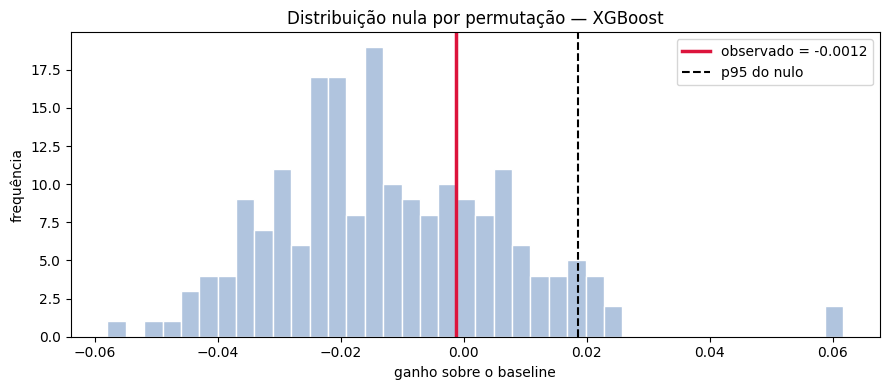

In [18]:
# escolhe o melhor de cada categoria, ignorando os baselines
reais = tabela.drop(index=[i for i in tabela.index if "Baseline" in i], errors="ignore")
melhor_geral = reais["ganho_medio"].idxmax()

tab_reais = reais[reais.index.isin(MODELOS_TABULARES)]
melhor_tabular = tab_reais["ganho_medio"].idxmax()
ctor = MODELOS_TABULARES[melhor_tabular]

print(f"Melhor modelo no geral  : {melhor_geral} (ganho {reais.loc[melhor_geral, 'ganho_medio']:+.4f})")
print(f"Melhor modelo tabular   : {melhor_tabular} (ganho {reais.loc[melhor_tabular, 'ganho_medio']:+.4f})")
if melhor_geral != melhor_tabular:
    print(f"\nO melhor geral é uma rede. A permutação, o backtest e o holdout usam")
    print(f"'{melhor_tabular}', que é reconstruível de forma barata e repetida.")

perm = teste_permutacao(ctor, X_trab, y_trab)
print(f"\n--- Teste de permutação: {melhor_tabular} ---")
print(f"Permutações ..... {N_PERMUTACOES} em {perm['segundos']:.0f}s")
print(f"Ganho observado . {perm['ganho_observado']:+.4f}")
print(f"Nulo ............ {perm['nulo_media']:+.4f} ± {perm['nulo_dp']:.4f}")
print(f"z ............... {perm['z']:.2f}")
print(f"p-valor ......... {perm['p_valor']:.4f}")
print(">>> " + ("SIGNIFICATIVO a 5%" if perm["p_valor"] < 0.05 else "NÃO significativo a 5%"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(perm["nulos"], bins=40, color="lightsteelblue", edgecolor="white")
ax.axvline(perm["ganho_observado"], color="crimson", lw=2.5,
           label=f"observado = {perm['ganho_observado']:+.4f}")
ax.axvline(np.percentile(perm["nulos"], 95), color="k", ls="--", lw=1.5, label="p95 do nulo")
ax.set_xlabel("ganho sobre o baseline"); ax.set_ylabel("frequência")
ax.set_title(f"Distribuição nula por permutação — {melhor_tabular}")
ax.legend(); plt.tight_layout(); plt.show()

In [19]:
from scipy.stats import friedmanchisquare, rankdata

comparaveis = tabela[tabela["acc_por_fold"].apply(
    lambda v: isinstance(v, (list, np.ndarray)) and not np.any(pd.isna(v)))]

if len(comparaveis) < 3:
    print(f"Só {len(comparaveis)} modelos comparáveis por fold — Friedman precisa de pelo menos 3.")
else:
    M = np.vstack(comparaveis["acc_por_fold"].values)      # (modelos, folds)
    stat, p = friedmanchisquare(*M)
    print(f"Friedman: chi2 = {stat:.3f}, p = {p:.4f}  ({len(comparaveis)} modelos, {M.shape[1]} folds)")
    print(">>> " + ("Existe diferença entre os modelos." if p < 0.05
                    else "NÃO existe diferença detectável entre os modelos."))

    ranks = np.array([rankdata(-M[:, j]) for j in range(M.shape[1])]).mean(axis=0)
    rk = pd.Series(ranks, index=comparaveis.index).sort_values()
    print("\nRank médio (menor = melhor):")
    print(rk.round(2).to_string())

    pos_base = [i for i, nome in enumerate(rk.index) if "Baseline" in nome]
    if pos_base and min(pos_base) == 0:
        print("\n>>> ATENÇÃO: o baseline está em primeiro. Nenhum modelo bateu o trivial.")

    k, n = len(rk), M.shape[1]
    q_alpha = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850,
               7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164}.get(k, 3.2)
    cd = q_alpha * np.sqrt(k * (k + 1) / (6 * n))
    print(f"\nDistância crítica (Nemenyi, alpha=0,05, k={k}, n={n}): {cd:.2f}")
    print(f"Amplitude observada dos ranks: {rk.max() - rk.min():.2f}")
    print(">>> " + ("Existem pares significativamente diferentes."
                    if (rk.max() - rk.min()) > cd else "NENHUM par difere significativamente."))

Friedman: chi2 = 4.452, p = 0.6158  (7 modelos, 5 folds)
>>> NÃO existe diferença detectável entre os modelos.

Rank médio (menor = melhor):
modelo
XGBoost                     3.0
Gradient Boosting           3.2
Baseline (majoritária)      3.4
Random Forest               4.2
Baseline (estratificado)    4.4
SVM (RBF)                   4.5
Regressão logística         5.3

Distância crítica (Nemenyi, alpha=0,05, k=7, n=5): 4.03
Amplitude observada dos ranks: 2.30
>>> NENHUM par difere significativamente.


---
## Avaliação econômica

Acurácia não paga conta. Essa seção traduz previsão em dinheiro, que é a única métrica que
importa no fim.

### As regras da simulação

| Previsão | Ação |
|---|---|
| **Compra** | compro na abertura das 11:00, saio no fechamento das 11:59 |
| **Venda** | vendo na abertura das 11:00, saio no fechamento das 11:59 |
| **Lateral** | fico de fora, não opero e não pago nada |

Cada operação paga **7 pontos** de custo (`CUSTO_PONTOS`), cobrindo a travessia do spread
(5 pontos, que é 1 tick do WIN) mais emolumentos. A composição está na seção *Configuração*, Bloco 5. Cada
ponto vale **R$ 0,20** (`VALOR_PONTO`), que é o valor do mini-índice.

O custo é o que separa um backtest sério de um exercício de fantasia. Com 500 operações,
7 pontos cada, são 3.500 pontos consumidos só de atrito, e é comum uma estratégia que
parecia lucrativa virar prejuízo aí.

### As métricas e o que cada uma revela

| Métrica | O que responde |
|---|---|
| `operações` | Quantos dias o modelo decidiu operar. Se for perto de zero, ele virou um "fica de fora" caro |
| `taxa_acerto` | % de operações que fecharam positivas **depois do custo** |
| `pontos_liquidos` | O resultado acumulado, já com custo |
| `resultado_R$` | O mesmo, em dinheiro |
| `expectativa_pts_op` | Quanto se ganha (ou perde) por operação, em média. **É a métrica mais honesta** |
| `drawdown_max_pts` | A maior sequência de perda acumulada. É o que determina se dá para aguentar operar |

Taxa de acerto alta com expectativa negativa é um padrão clássico: acerta muito, ganha
pouco em cada acerto, e perde muito nos poucos erros.

### Os dois pontos de comparação

**Aleatório**, sorteia entre as três classes. Mostra o que sai de uma estratégia sem
nenhuma informação.

**Só comprar**, compra todo dia, sem pensar. É o equivalente ao buy-and-hold da janela, e
é o benchmark mais duro: se o modelo não bate "comprar sempre", ele não está agregando
nada.

> **As previsões aqui são out-of-fold.** Cada dia é previsto por um modelo que nunca o
> viu, coletado ao longo dos folds do walk-forward. Isso não é detalhe: backtest com
> previsão in-sample dá 80% de acerto e uma curva de capital linda que **não significa
> nada**. É o erro mais comum e mais caro dessa área, e eu já cometi ele neste projeto.
>
> **A coluna "aleatório" é um sorteio só.** Se ela aparecer ganhando, não quer dizer que o
> acaso é melhor que o modelo, quer dizer que a variância entre sorteios é maior que a
> diferença entre as estratégias, o que por si só já é um resultado. Para comparar de
> verdade, seriam 1.000 sorteios e uma comparação de distribuições.


Modelo: XGBoost | previsões out-of-fold: 810 dias

                              modelo     aleatório    só comprar
operações                     545.00        554.00        810.00
taxa_acerto                     0.49          0.52          0.49
pontos_liquidos            -9,700.00     24,382.00    -19,585.00
resultado_R$               -1,940.00      4,876.40     -3,917.00
expectativa_pts_op            -17.80         44.01        -24.18
drawdown_max_pts           14,463.00      5,407.00     25,276.00


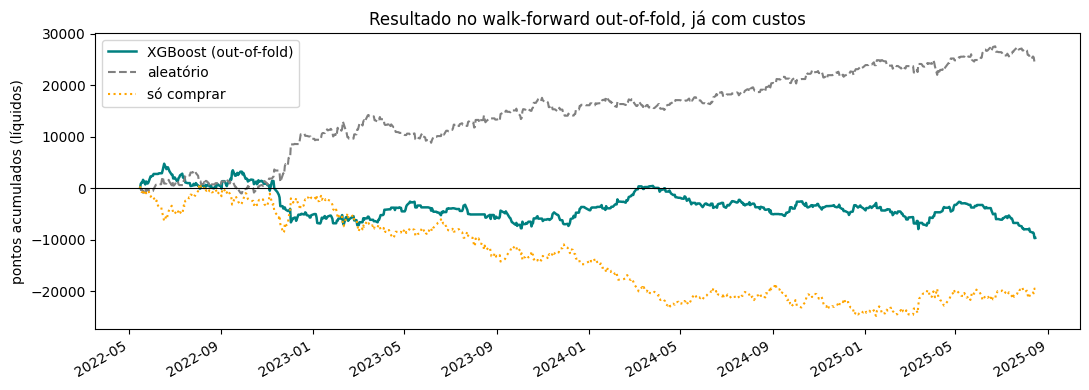


>>> Resultado líquido NEGATIVO. Depois do custo, a estratégia perde dinheiro.


In [20]:
def backtest(y_verdadeiro, y_previsto, retorno_pts, custo=CUSTO_PONTOS, valor=VALOR_PONTO):
    """P&L em pontos e em reais. 'Lateral' significa não operar."""
    r = retorno_pts.reindex(y_verdadeiro.index)
    direcao = pd.Series(0.0, index=y_verdadeiro.index)
    direcao[y_previsto == "Compra"] = 1.0
    direcao[y_previsto == "Venda"] = -1.0

    operou = direcao != 0
    liquido = direcao * r - operou * custo
    vencedoras = liquido[operou & (liquido > 0)]
    perdedoras = liquido[operou & (liquido <= 0)]

    return {
        "operações": int(operou.sum()),
        "taxa_acerto": float((liquido[operou] > 0).mean()) if operou.sum() else np.nan,
        "pontos_liquidos": float(liquido.sum()),
        "resultado_R$": float(liquido.sum() * valor),
        "expectativa_pts_op": float(liquido[operou].mean()) if operou.sum() else np.nan,
        "ganho_medio": float(vencedoras.mean()) if len(vencedoras) else np.nan,
        "perda_media": float(perdedoras.mean()) if len(perdedoras) else np.nan,
        "drawdown_max_pts": float((liquido.cumsum().cummax() - liquido.cumsum()).max()),
        "curva": liquido.cumsum(),
    }


prev_oof = prever_out_of_fold(ctor, X_trab, y_trab)
y_oof = y_trab.loc[prev_oof.index]

bt = backtest(y_oof, prev_oof, retorno_alvo)
aleatorio = backtest(y_oof, pd.Series(
    np.random.default_rng(0).choice(CLASSES, len(y_oof)), index=y_oof.index), retorno_alvo)
so_comprar = backtest(y_oof, pd.Series("Compra", index=y_oof.index), retorno_alvo)

print(f"Modelo: {melhor_tabular} | previsões out-of-fold: {len(prev_oof)} dias\n")
print(f"{'':<22}{'modelo':>14}{'aleatório':>14}{'só comprar':>14}")
for ch in ["operações", "taxa_acerto", "pontos_liquidos", "resultado_R$",
           "expectativa_pts_op", "drawdown_max_pts"]:
    print(f"{ch:<22}{bt[ch]:>14,.2f}{aleatorio[ch]:>14,.2f}{so_comprar[ch]:>14,.2f}")

fig, ax = plt.subplots(figsize=(11, 4))
bt["curva"].plot(ax=ax, color="teal", lw=1.8, label=f"{melhor_tabular} (out-of-fold)")
aleatorio["curva"].plot(ax=ax, color="gray", ls="--", label="aleatório")
so_comprar["curva"].plot(ax=ax, color="orange", ls=":", label="só comprar")
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("pontos acumulados (líquidos)")
ax.set_title("Resultado no walk-forward out-of-fold, já com custos")
ax.legend(); plt.tight_layout(); plt.show()

if bt["pontos_liquidos"] <= 0:
    print("\n>>> Resultado líquido NEGATIVO. Depois do custo, a estratégia perde dinheiro.")

---
## Holdout final

Os **244 dias** separados lá na seção *Protocolo de avaliação*, que nenhuma decisão deste notebook encostou.

---

### Por que ele existe

Todo o resto do notebook usou o conjunto de trabalho repetidas vezes: escolhi features
olhando para ele, escolhi rótulo olhando para ele, comparei onze modelos nele, testei sete
janelas horárias nele. Cada uma dessas decisões consumiu um pouco da independência daquele
dado.

Isso não é erro, é como se desenvolve modelo. Mas significa que o resultado do
walk-forward é **otimista por construção**, porque as escolhas foram feitas sabendo dele. O
holdout é a única medida que não carrega esse viés.

### Ele é um regime esquisito? Quase não, mas o detalhe importa

Antes de confiar no holdout, vale conferir se ele não é um período atípico que tornaria a
comparação injusta:

| Classe | Trabalho | Holdout |
|---|---|---|
| Compra | 32,5% | 34,4% |
| Lateral | 31,9% | 33,2% |
| Venda | 35,7% | 32,4% |

As proporções são parecidas, e nesse sentido o holdout não é um período anormalmente
fácil nem anormalmente difícil. **Mas há um detalhe que muda a leitura do resultado.**

No conjunto de trabalho a classe mais frequente é **Venda**. No holdout, é **Compra**. O
`DummyClassifier` aprende a majoritária no treino e fica preso nela, então ele entra no
holdout prevendo "Venda", que ali virou a classe *menos* frequente.

Isso **rebaixa o baseline por um motivo que não tem nada a ver com o modelo ser bom**, e
infla o ganho medido. A conta está na seção *Teste 1, a acurácia contra o limiar que eu mesmo fixei*.

---

### A regra de uma olhada só

**Rode esta seção uma vez, no fim de tudo.**

Se eu abrir, não gostar do resultado, ajustar alguma coisa e abrir de novo, o holdout
deixou de existir. Ele vira mais um conjunto de validação, com o agravante de que agora eu
*acho* que ele é confiável, o que é pior do que não ter holdout nenhum.

A flag `EXECUTAR_HOLDOUT` fica em `False` de propósito, para eu não abrir por distração.

---

### O que ele consegue e o que não consegue responder

A conta de poder estatístico define o que este conjunto consegue detectar.

Com 244 dias, o erro padrão da acurácia sai da fórmula da proporção:

```
EP  =  raiz( p₀ (1 − p₀) / n )

com p₀ = 0,3238 (a acurácia que o baseline de fato entrega) e n = 244:

EP  =  raiz( 0,3238 × 0,6762 / 244 )  =  raiz( 0,000897 )  =  0,0300   ->  3,0 p.p.
```

E o ganho mínimo detectável, para um poder de 80%:

```
ganho mínimo  =  (z_α/2 + z_β) × EP

95% bilateral:  (1,96 + 0,84) × 0,0300  =  0,084   ->   8,4 p.p.
```

Aplicando para os três níveis de confiança:

| Confiança (bilateral) | Ganho mínimo detectável |
|---|---|
| 90% | ~7,4 p.p. |
| **95%** | **~8,4 p.p.** |
| 99% | ~10,2 p.p. |

*(reproduzido no Anexo A.24)*

*(estimativa conservadora, como modelo e baseline são medidos nos mesmos dias, um teste
pareado tipo McNemar precisaria de um pouco menos.)*

Agora compare com o que o walk-forward vem mostrando: ganho da ordem de **0,6 p.p.**

**A conclusão é desconfortável mas importante: o holdout não tem poder estatístico para
confirmar um sinal marginal.** Mesmo que o ganho de 0,6 p.p. se repita ali, ele vai estar
completamente dentro do ruído.

O que o holdout serve para fazer:

| Pergunta | Ele responde? |
|---|---|
| "Existe um sinal grande que eu deixei passar?" | **sim** |
| "O resultado nulo do walk-forward se sustenta?" | **sim** |
| "Aquele ganho de 0,6 p.p. é real?" | **não**, sem poder para isso |
| "A estratégia dá dinheiro depois de custos?" | **parcialmente**, 244 dias é pouco para P&L |

Isso não é defeito do desenho, é consequência do tamanho da amostra. Com ~1.240 pregões no
total, não existe divisão que dê ao mesmo tempo treino suficiente e um holdout com poder
para detectar efeitos pequenos. É uma limitação real do estudo e precisa estar escrita no
paper.

---

### O que foi testado

**A janela de treino: `09:00–10:59 → 11:00–11:59`**, a mesma configuração usada em todo o
notebook, num período que nenhuma decisão encostou.

Eu tinha escrito na introdução que abriria com `09:00–11:59 → 12:00–12:59`. Mudei,
e o raciocínio está lá em cima: trocar a janela na hora de abrir mistura "dado novo" com
"hipótese nova", e um resultado positivo ficaria inexplicável, janela ou período? Um
holdout serve para responder se **este** modelo generaliza, e para isso a configuração tem
que ser a mesma.

O modelo levado ao holdout foi o **XGBoost** (melhor tabular no walk-forward), treinado no
conjunto de trabalho inteiro, com o `StandardScaler` ajustado só nele.

---

### O resultado

```
Baseline ... 0.3238        operações            159
Modelo ..... 0.3279        taxa_acerto         0.51
Ganho ...... +0.0041       pontos_liquidos    3,342
F1-macro ... 0.3276        resultado_R$       668.40
```

O ganho é positivo, e é a primeira vez no projeto que o holdout é aberto. Positivo não
quer dizer nada por si só, então submeti o número a três testes.

---

### Teste 1, a acurácia contra o limiar que eu mesmo fixei

| | |
|---|---|
| Erro padrão (n = 244) | 3,0 p.p. |
| z | **0,14** |
| p unilateral | 0,446 |
| p bilateral | **0,891** |
| Limiar pré-registrado na seção *O que ele consegue e o que não consegue responder* para 95% | **8,4 p.p.** |
| Ganho observado | **0,4 p.p.** |

Fica em um vigésimo do limiar que a seção *O que ele consegue e o que não consegue responder* fixou antes de abrir, e o p bilateral é 0,89: o holdout não distingue este modelo de não ter modelo nenhum.

O `z` da tabela sai de dividir o ganho pelo erro padrão:

```
EP  =  raiz( p₀·(1 − p₀) / n )  =  raiz( 0,3238 × 0,6762 / 244 )  =  0,029956

z   =  ganho / EP  =  0,0041 / 0,029956  =  0,14

p unilateral  =  P( Z > 0,14 )  =  0,446
p bilateral   =  2 × P( Z > 0,14 )  =  0,891
```

> **Use o EP sem arredondar.** A tabela acima reporta o erro padrão como 3,0 p.p., que é o
> valor arredondado. A diferença aqui é pequena demais para mudar a leitura, mas quem tentar
> reproduzir partindo da tabela chega a um número ligeiramente diferente.

**E parte do ganho não é do modelo.** Como a classe majoritária trocou de Venda para Compra
entre treino e holdout (seção *Ele é um regime esquisito? Quase não, mas o detalhe importa*), o baseline levou uma penalidade estrutural:

| Baseline | Acurácia | Ganho | z | p unilateral |
|---|---:|---:|---:|---:|
| `DummyClassifier` treinado (prevê Venda) | 0,3238 | **+0,0041** | 0,14 | 0,446 |
| Majoritária do próprio holdout (Compra) | 0,3443 | **−0,0164** | **−0,54** | **0,705** |

*(reproduzido no Anexo A.25)*

**A deriva da majoritária vale 2,0 p.p., cinco vezes o ganho de 0,4 p.p.** Trocada a régua
pela majoritária real do período, o que sobra é **negativo**: −1,6 p.p. O pouco que o modelo
mostra sobre o Dummy treinado é menor que o efeito de a distribuição ter mudado.

> Isto não é um defeito do `DummyClassifier`: ele está certo em usar só o que viu no treino,
> porque o modelo também só viu o treino. O que a conta mostra é que **"ganho sobre o
> baseline" degrada quando a distribuição deriva**, e que num holdout de período único vale
> sempre reportar os dois números.

---

### Teste 2, o P&L contra o acaso

Simulei 20.000 estratégias aleatórias com as **mesmas 159 operações** e o mesmo custo:

| | Pontos |
|---|---:|
| Aleatório: média | −1.156 |
| Aleatório: desvio-padrão | **8.760** |
| Aleatório: percentil 5 / 95 | −15.643 / +13.327 |
| **Modelo no holdout** | **+3.342** |
| z | **0,51** |
| p unilateral | **0,301** |

*(reproduzido no Anexo A.26)*

As duas medidas saem assim:

```
percentil  =  100 × (nº de sorteios com P&L < observado) / N  =  70%

z  =  (observado − média dos sorteios) / dp dos sorteios
   =  (+3.342 − (−1.156)) / 8.760  =  0,51
```

O modelo caiu no **percentil 70** da distribuição aleatória, meio desvio-padrão acima da
média. Com dispersão de 8.760 pontos em 159 operações, +3.342 é ruído.

O dado que fecha o argumento está na própria seção *Avaliação econômica*:

| | Operações | Pontos | Pts/operação |
|---|---:|---:|---:|
| Modelo out-of-fold | 545 | −9.700 | −17,80 |
| **Aleatório out-of-fold** | 554 | **+24.382** | **+44,01** |
| Só comprar | 810 | −19.585 | −24,18 |
| Modelo no holdout | 159 | +3.342 | +21,02 |

**A estratégia aleatória do walk-forward rendeu o dobro por operação (+44,01) do que o modelo
no holdout (+21,02).** Quando o acaso produz números melhores que o modelo, o número do
modelo não é evidência de nada.

---

### Veredito

Aplicando a tabela de decisão que estava escrita **antes** de abrir:

| Situação | Leitura | O que fazer |
|---|---|---|
| Ganho > 8 p.p. e P&L positivo | Sinal forte e mensurável | Testar robustez |
| Ganho > 8 p.p. e P&L negativo | Acerta bem, mas não paga o atrito | Rever o rótulo |
| **Ganho entre 0 e 8 p.p.** | **Indistinguível de zero** | **Tratar como nulo; seguir para as variantes** |
| Ganho ≈ 0 ou negativo | Confirma o resultado nulo | Seguir para as variantes |

**O resultado caiu na terceira linha: 0,4 p.p.**, e os três testes concordam. Ganho a um
vigésimo do limiar, mais que anulado pela deriva de classe quando se troca a régua, P&L no
percentil 70 do acaso.

> **Por que isto é um bom resultado, e não uma decepção.** A regra de decisão foi escrita
> antes de eu ver o número. Se eu tivesse aberto o holdout sem ela, um ganho positivo com
> R$ 668 de lucro e 51% de acerto teria dado pano para manchete, e teria sobrevivido a
> qualquer revisão superficial. Foi exatamente o cenário que a seção *O que ele consegue e o que não consegue responder* previu: *"é exatamente o tipo de número
> que faz alguém insistir numa estratégia que não existe."*
>
> **Em nenhum cenário o caminho é ajustar hiperparâmetro e abrir o holdout de novo.** Ele foi
> gasto, e o que veio de lá é o que fica. O próximo passo é a bateria de variantes da seção *O que vem depois*.



=== HOLDOUT — 244 dias, 2025-08-18 a 2026-08-12 ===
Modelo ..... XGBoost
Janela ..... 09:00–10:59 -> 11:00–11:59

Baseline ... 0.3238
Modelo ..... 0.3279
Ganho ...... +0.0041
F1-macro ... 0.3276

              precision    recall  f1-score   support

      Compra       0.32      0.30      0.31        84
     Lateral       0.34      0.36      0.35        81
       Venda       0.32      0.33      0.32        79

    accuracy                           0.33       244
   macro avg       0.33      0.33      0.33       244
weighted avg       0.33      0.33      0.33       244

Resultado econômico no holdout:
  operações                     159.00
  taxa_acerto                     0.51
  pontos_liquidos             3,342.00
  resultado_R$                  668.40
  expectativa_pts_op             21.02
  drawdown_max_pts            5,329.00


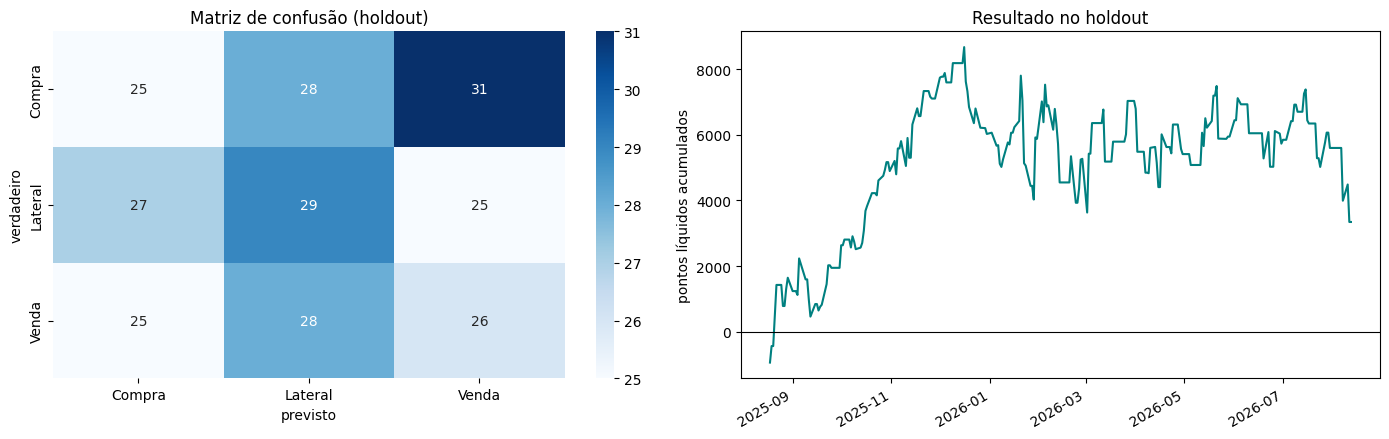

In [21]:
EXECUTAR_HOLDOUT = True   # mude para True só quando todo o resto estiver fechado

if not EXECUTAR_HOLDOUT:
    print("Holdout NÃO executado (EXECUTAR_HOLDOUT = False).")
    print(f"Reservados {len(X_hold)} dias: {X_hold.index.min():%Y-%m-%d} a {X_hold.index.max():%Y-%m-%d}")
    print("Mude a flag para True quando tudo o mais estiver decidido — e só uma vez.")
else:
    scaler = StandardScaler().fit(X_trab)
    modelo_final = ctor(0).fit(scaler.transform(X_trab), y_trab)
    prev_hold = pd.Series(modelo_final.predict(scaler.transform(X_hold)), index=X_hold.index)
    base_hold = pd.Series(
        DummyClassifier(strategy="most_frequent").fit(scaler.transform(X_trab), y_trab)
        .predict(scaler.transform(X_hold)), index=X_hold.index)

    acc_m, acc_b = accuracy_score(y_hold, prev_hold), accuracy_score(y_hold, base_hold)
    print(f"=== HOLDOUT — {len(X_hold)} dias, {X_hold.index.min():%Y-%m-%d} a {X_hold.index.max():%Y-%m-%d} ===")
    print(f"Modelo ..... {melhor_tabular}")
    print(f"Janela ..... {JANELA_FEATURES[0]}–{JANELA_FEATURES[1]} -> {JANELA_ALVO[0]}–{JANELA_ALVO[1]}\n")
    print(f"Baseline ... {acc_b:.4f}")
    print(f"Modelo ..... {acc_m:.4f}")
    print(f"Ganho ...... {acc_m - acc_b:+.4f}")
    print(f"F1-macro ... {f1_score(y_hold, prev_hold, average='macro', zero_division=0):.4f}\n")
    print(classification_report(y_hold, prev_hold, zero_division=0))

    bt_h = backtest(y_hold, prev_hold, retorno_alvo)
    print("Resultado econômico no holdout:")
    for ch in ["operações", "taxa_acerto", "pontos_liquidos", "resultado_R$",
               "expectativa_pts_op", "drawdown_max_pts"]:
        print(f"  {ch:<22}{bt_h[ch]:>14,.2f}")

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    sns.heatmap(confusion_matrix(y_hold, prev_hold, labels=CLASSES), annot=True, fmt="d",
                cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[0])
    ax[0].set_xlabel("previsto"); ax[0].set_ylabel("verdadeiro")
    ax[0].set_title("Matriz de confusão (holdout)")
    bt_h["curva"].plot(ax=ax[1], color="teal")
    ax[1].axhline(0, color="k", lw=0.8); ax[1].set_ylabel("pontos líquidos acumulados")
    ax[1].set_title("Resultado no holdout")
    plt.tight_layout(); plt.show()

---
## Registro da rodada

Grava dois arquivos: a tabela de resultados em `.csv` e a configuração completa em
`.json`, com data e hora.

### Por que isso importa

Sem registro, três meses depois eu não consigo responder perguntas básicas: aquele 0,354
do MLP foi com qual esquema de rótulo? Quantas sementes? Antes ou depois de eu corrigir o
RSI? O notebook muda, os resultados na tela somem no primeiro `Restart Kernel`, e sobra
memória, que é o pior lugar para guardar número.

O nome do arquivo carrega a configuração (`resultados_vol_0900-1100.csv`), então rodadas
com janelas ou rótulos diferentes não se sobrescrevem e ficam comparáveis lado a lado.

### O que fica gravado

| Campo | Para quê |
|---|---|
| `data` | ordenar as rodadas |
| `janela_features`, `janela_alvo` | qual configuração produziu aquilo |
| `esquema_label` | qual definição de Compra/Venda estava valendo |
| `n_trabalho`, `n_holdout`, `n_features` | o tamanho da amostra |
| `sementes_tabular`, `sementes_dl` | quanta repetição sustenta o número |
| `distribuicao` | o balanço das classes, que define o baseline |
| `melhor_geral`, `melhor_tabular` | quem venceu |
| `permutacao_p` | se o vencedor tem significância |
| `holdout_executado` | **se o holdout já foi queimado** |

Esse último campo é o mais importante de todos. Ele é o meu registro de que o holdout foi
aberto, e uma vez `true`, não tem como voltar atrás.


In [22]:
registro = {
    "data": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "arquivo": ARQUIVO,
    "janela_features": list(JANELA_FEATURES),
    "janela_alvo": list(JANELA_ALVO),
    "esquema_label": ESQUEMA_LABEL,
    "n_trabalho": int(len(X_trab)),
    "n_holdout": int(len(X_hold)),
    "n_features": int(X_trab.shape[1]),
    "n_splits": N_SPLITS,
    "sementes_tabular": len(SEMENTES),
    "sementes_dl": globals().get("N_SEMENTES_DL"),
    "distribuicao": y_all.value_counts().to_dict(),
    "melhor_geral": melhor_geral,
    "melhor_tabular": melhor_tabular,
    "permutacao_p": float(perm["p_valor"]),
    "holdout_executado": bool(globals().get("EXECUTAR_HOLDOUT", False)),
}

base = (f"resultados_{ESQUEMA_LABEL}"
        f"_{JANELA_FEATURES[0].replace(':','')}-{JANELA_ALVO[0].replace(':','')}")
tabela.drop(columns=["acc_por_fold"], errors="ignore").to_csv(f"{base}.csv", sep=";")
with open(f"{base}_config.json", "w", encoding="utf-8") as fh:
    json.dump(registro, fh, indent=2, ensure_ascii=False)

print(json.dumps(registro, indent=2, ensure_ascii=False))
print(f"\nGravado: {base}.csv e {base}_config.json")

{
  "data": "2026-09-01 23:12",
  "arquivo": "WIN$N_M5_BRUTO_COMPLETO.csv",
  "janela_features": [
    "09:00",
    "10:59"
  ],
  "janela_alvo": [
    "11:00",
    "11:59"
  ],
  "esquema_label": "vol",
  "n_trabalho": 976,
  "n_holdout": 244,
  "n_features": 22,
  "n_splits": 5,
  "sementes_tabular": 10,
  "sementes_dl": 3,
  "distribuicao": {
    "Venda": 427,
    "Compra": 401,
    "Lateral": 392
  },
  "melhor_geral": "CNN 1D",
  "melhor_tabular": "XGBoost",
  "permutacao_p": 0.2835820895522388,
  "holdout_executado": true
}

Gravado: resultados_vol_0900-1100.csv e resultados_vol_0900-1100_config.json


---
## Conclusão

O que este notebook estabeleceu, com os números que sustentam cada afirmação.

> **Esta seção é um resumo, e os números aqui são repetidos de onde foram derivados.** Cada
> um tem a equação e o código na seção de origem:
>
> | Número | Derivado em | Código no |
> |---|---|---|
> | permutação: z e p | seção *Teste de permutação* | célula da seção *Comparação estatística* |
> | Friedman chi² e Nemenyi CD | seção *Friedman + Nemenyi* | célula da seção *Comparação estatística* |
> | Kruskal e Bonferroni | seção *Análise exploratória* | célula da seção *Análise exploratória* |
> | backtest out-of-fold | seção *Avaliação econômica* | célula da seção *Avaliação econômica* |
> | erro padrão e poder do holdout | seção *O que ele consegue e o que não consegue responder* | Anexo A.24 |
> | deriva da classe majoritária | seção *Teste 1, a acurácia contra o limiar que eu mesmo fixei* | Anexo A.25 |
> | P&L contra o acaso | seção *Teste 2, o P&L contra o acaso* | Anexo A.26 |
>
> Repetir a equação aqui só faria a conclusão inchar. O que ela precisa é apontar para onde a
> conta está.

---

### Quais features usar, e por que não cortar nenhuma

Esta foi a última pergunta que testei, e a resposta contraria a intuição.

Comparei sete configurações no walk-forward, todas com 5 sementes, sempre no conjunto de
trabalho *(as quatro tabelas desta subseção são reproduzidas no Anexo A.27)*:

| Configuração | Nº features | Acurácia | ±dp | Ganho sobre baseline | vs "Todas" |
|---|---|---|---|---|---|
| **Só contexto diário** | **5** | **0,3640** | 0,0044 | **+0,0121** | **+0,0128** *(p = 0,037)* |
| Kruskal top-3 | 3 | 0,3578 | 0,0049 | +0,0059 | +0,0067 *(p = 0,194)* |
| Sem redundância > 0,8 | 17 | 0,3560 | 0,0069 | +0,0042 | +0,0049 *(p = 0,362)* |
| **Todas** | **22** | **0,3511** | 0,0082 | **−0,0007** | n/d |
| Só a janela 09:00–10:59 | 17 | 0,3479 | 0,0073 | −0,0040 | −0,0032 *(p = 0,550)* |
| MI top-5 | 5 | 0,3452 | 0,0051 | −0,0067 | −0,0059 *(p = 0,243)* |
| MI top-10 | 10 | 0,3378 | 0,0082 | −0,0141 | −0,0133 *(p = 0,062)* |

A última coluna é o que separa ruído de efeito: teste t de duas amostras contra a linha
"Todas", com 5 sementes cada.

```
EP(diferença) = raiz( dp_A²/5 + dp_B²/5 )     t = diferença / EP     gl = 4
```

São **seis comparações contra a mesma referência**, então o limiar corrigido por Bonferroni é
0,05 / 6 = **0,0083**, e **nenhuma das seis o alcança**. A que chega mais perto é "só contexto
diário", com p = 0,037: nominalmente melhor que usar tudo, sem margem para ser declarada
melhor. Do outro lado, a pior delas, MI top-10, para em p = 0,062.

**Nenhuma seleção se separa de usar tudo.** O ranking de informação mútua ocupa as duas
piores posições da tabela, e o bloco de contexto diário a primeira, mas as duas coisas são
tendências, não efeitos medidos.

#### O controle: seleção não é melhor que sorteio

Comparei cada subconjunto "inteligente" contra 20 sorteios aleatórios do mesmo tamanho
*(Anexo A.27)*:

| Tamanho | Escolha por métrica | Aleatório (média ± dp) | z |
|---|---|---|---|
| 5 | 0,3452 (MI top-5) | 0,3375 ± 0,0161 | +0,48 |
| 10 | 0,3378 (MI top-10) | 0,3417 ± 0,0115 | −0,34 |
| 3 | 0,3578 (Kruskal top-3) | 0,3362 ± 0,0149 | +1,45 |

```
z  =  (acurácia da escolha por métrica − média dos 20 sorteios) / dp dos 20 sorteios
```

**Os três z ficam dentro de ±1,5: escolher pela métrica é indistinguível de sortear o mesmo
número de features.** Gastar cálculo para ranquear features por informação mútua ou por
Kruskal não entrega nada que um sorteio não entregue.

#### Nem a seleção metodologicamente correta ajuda

Selecionar dentro de cada fold de treino é o único procedimento que não vaza. Mesmo assim
*(Anexo A.27)*:

| Método | Acurácia |
|---|---|
| Todas as 22 | **0,3511** ± 0,0082 |
| Top-5 escolhido dentro do fold | 0,3222 ± 0,0137 |
| Top-10 escolhido dentro do fold | 0,3526 ± 0,0167 |

E o motivo fica claro ao ver **o que** cada fold escolheria:

```
fold 1: c_atr_d1, f_frac_alta, c_gap, f_retorno, f_macd
fold 2: f_macd, c_pos_d1, c_atr_d1, f_vol_real, f_dow_cos
fold 3: f_macd, f_atividade, c_pos_d1, f_dow_sin, f_dist_ma20
fold 4: f_inclinacao, f_atividade, f_vol_total, f_macd, c_atr_d1
fold 5: f_inclinacao, f_vol_total, f_range, c_pos_d1, f_atividade
```

São 25 escolhas distribuídas entre **14 features diferentes**, e **nenhuma aparece nos cinco
folds**. Se existisse um subconjunto genuinamente superior, os folds convergiriam para ele.
Não convergem, é a assinatura de estar selecionando ruído.

Detalhe que fecha o argumento: **`f_macd` é escolhida em 4 dos 5 folds**, mas no conjunto
completo tem MI de 0,003 (abaixo da régua de ruído) e Kruskal com p = 0,74. Os dois cálculos
não podem estar certos ao mesmo tempo.

#### Decisão

**Manter as 22 features. Não cortar nada.** Três razões:

1. Nenhuma das seis seleções se separa de usar tudo depois de corrigir pelas seis
   comparações. Cortar é assumir risco sem contrapartida medida
2. A razão amostra/feature está em **44:1** no conjunto de trabalho (976 dias) e **55:1** na
   base completa; não há pressão de dimensionalidade que justifique cortar
3. Informação mútua é **univariada**, mede cada feature isolada, enquanto árvores usam
   interações. Uma feature com MI ≈ 0 pode ser exatamente o que desempata dois casos que
   outra confunde

> **Quando revisitar.** Se a dimensionalidade apertar de verdade (a variante V1 leva o
> conjunto para ~39 features), a seleção passa a fazer sentido. Mas tem que ser **aninhada
> dentro de cada fold**, nunca decidida olhando a tabela de MI desta seção.

#### O achado lateral que vale mais que o principal

*(Anexo A.27)*

| | Nº features | Acurácia |
|---|---|---|
| **Só contexto diário** | **5** | **0,3640** |
| Só a janela 09:00–10:59 | 17 | 0,3479 |

**Cinco números sobre o dia anterior carregam mais que dezessete extraídos da manhã
inteira.** Gap, ATR de ontem, range de ontem, posição no range de ontem e distância da
média de 20 dias.

Isso é coerente com todo o resto do notebook: o que sobrevive aos testes é sempre
persistência de volatilidade, nunca direção, e as features de contexto são majoritariamente
medidas de volatilidade recente.

**Consequência prática:** se for procurar features novas, o retorno esperado está no
**contexto entre dias**, não em mais granularidade dentro da manhã. Isso reforça as
variantes V1 (dólar) e V2 (S&P) bem mais do que qualquer refinamento intradiário.

---

### O resultado principal: não há sinal direcional detectável

| Evidência | Resultado |
|---|---|
| Melhor modelo vs baseline (XGBoost, walk-forward, 10 sementes) | ganho de **+0,07 p.p.** |
| Teste de permutação (200 embaralhamentos) | z = 0,60, **p = 0,284** |
| Friedman entre os 7 modelos tabulares | chi² = 4,45, **p = 0,616** |
| Nemenyi | distância crítica 4,03, amplitude observada 2,30, **nenhum par difere** |
| Posição do baseline majoritário no ranking de Friedman | **3º de 7** |
| Kruskal-Wallis nas 22 features | 3 com p < 0,05 (esperado ~1); **0 sobrevivem a Bonferroni** |
| Backtest out-of-fold, custo de 7 pts | **−9.700 pontos** |
| **Holdout (244 dias, aberto uma vez)** | ganho +0,4 p.p., **abaixo do limiar de 8,4 p.p.** |

Onze modelos testados, dos baselines triviais à TCN, e nenhum supera o trivial de forma
consistente. O ganho observado é indistinguível de zero.

O detalhe mais eloquente está na linha do Friedman: **o baseline majoritário ficou em 3º
lugar entre 7**, à frente de Random Forest, SVM, baseline estratificado e regressão
logística. Chutar sempre a classe mais comum bateu quatro dos seis modelos reais.

E o holdout, aberto uma única vez, **confirmou o nulo em vez de quebrá-lo**: ganho de
0,4 p.p., que a deriva da classe majoritária mais que explica sozinha. Os três testes que
desmontam esse número estão na seção *Teste 1, a acurácia contra o limiar que eu mesmo
fixei* e nas duas seguintes.

**Isto é um resultado, não uma falha.** Prever a direção da janela das 11:00 a partir da
manhã, com estas features, não funciona.

---

### O que foi testado e não funcionou

Cada linha custou tempo e está registrada para não ser repetida:

| Tentativa | Por que não funcionou | Onde está |
|---|---|---|
| Achatar features por vela | 120 colunas para 1.213 amostras, 10,1:1 | seção *Engenharia de features* |
| Rótulo por K-Means (5 classes) | "Super Venda" com 79 dias (6,4%); rótulo instável no tempo (ARI de 0,29 a 0,50 entre as duas metades) | seção *Rotulagem* |
| Rótulo por DBSCAN | com `eps` = 0,25 sobram 5 dias em 1 cluster e 99,6% de ruído; o nº de clusters vai de 0 a 24 conforme o `eps` | seção *Rotulagem* |
| Normalizar limiar pelo ATR diário | 84% de "Lateral", escala errada para janela de 1 hora | seção *Rotulagem* |
| Abstenção por limiar de probabilidade | probabilidades anti-informativas; pior que sortear | seção *Rotulagem* |
| Features cíclicas de mês e dia do mês | MI exatamente zero; Kruskal p = 0,79 | seção *Engenharia de features* |
| Trocar de timeframe (M1, M30, H1) | M30 e H1 não têm velas para features; o M1 dá ganho negativo | seção *Carregamento e validação dos dados* |
| Trocar a janela horária (7 configurações) | máximo de +0,036 contra +0,029 esperados do acaso em 7 sorteios | introdução |
| Selecionar features por MI ou Kruskal | indistinguível de sortear; nenhuma das seis passa de Bonferroni | seção *Quais features usar, e por que não cortar nenhuma* |

---

### O que funcionou

Poucas coisas, e nenhuma delas é um modelo:

- **Recuperar o histórico completo**, de 121 para 1.240 amostras úteis, trocando M1 por M5
  e corrigindo o `maxbars` do MetaTrader
- **Resumir em vez de achatar**: de 10,1:1 para 55:1 de razão amostra/feature
- **Features de contexto diário**, o único bloco que bate as features da janela
- **O protocolo em si**, foi ele que impediu **cinco** resultados falsamente positivos de
  serem tratados como descoberta. O quinto foi o próprio holdout: 51% de acerto nas operações
  e R$ 668 de lucro teriam passado por descoberta sem a regra de decisão escrita antes

---

### Limitações que precisam constar no paper

Os números citados nesta tabela vêm de outras seções: o erro padrão e o poder do holdout da
seção *O que ele consegue e o que não consegue responder* (Anexo A.24), a deriva da classe majoritária da seção *Teste 1, a acurácia contra o limiar que eu mesmo fixei* (Anexo A.25), e o tamanho da série
da seção *Carregamento e validação dos dados*.

| Limitação | Consequência |
|---|---|
| n = 1.240 pregões é o **teto** da série disponível | não há como aumentar a amostra |
| Holdout de 244 dias tem erro padrão de 3,0 p.p. | só detecta ganho acima de ~8 p.p. |
| Sem dados externos (S&P, VIX) | o driver das 11:30 não está no input |
| Um único ativo, um único mercado | nada garante que o resultado se transfira |
| Regime de 2021–2026 apenas | inclui um ciclo de alta atípico (+112%) |
| **Redes rodadas com 3 sementes**, não 10 | os números de deep learning **ainda não são publicáveis** |
| Classe majoritária diverge entre trabalho e holdout | "ganho sobre baseline" carrega 2,0 p.p. de deriva |

> **Sobre as sementes.** Os sete modelos tabulares rodaram com as 10 sementes que o protocolo
> exige; as quatro redes rodaram com 3, porque `N_SEMENTES_DL` estava em 3 para a rodada
> exploratória. Sementes a mais estreitam o intervalo de confiança, não criam sinal, e as
> redes ficaram **abaixo** dos tabulares. Mas antes de qualquer
> número de rede entrar no paper, `N_SEMENTES_DL` precisa ir para 10 e a seção *Modelos sequenciais (deep learning)* ser
> re-executada.

A segunda linha é a mais desconfortável: **o holdout não tem poder para confirmar um sinal
marginal.** Com ~1.240 pregões no total, não existe divisão que dê ao mesmo tempo treino
suficiente e um teste com poder para detectar efeitos pequenos.

**Isso deixou de ser teórico.** O holdout produziu ganho de 0,4 p.p., pequeno demais até
para ser discutido, e o cálculo de poder já dizia que um efeito do tamanho do observado no
walk-forward teria 5,3% de chance de ser detectado ali. Exatamente o cenário previsto na
seção *O que ele consegue e o que não consegue responder*, e a razão de aquela tabela de
poder ter sido calculada antes de abrir.

E há uma limitação que precisa constar no paper: **a classe
majoritária mudou entre trabalho e holdout** (de Venda para Compra), o que rebaixou o
baseline em 2,0 p.p. por deriva de distribuição. Em holdout de período único, "ganho sobre o
baseline" carrega esse componente, e a métrica precisa vir acompanhada da distribuição dos
dois períodos.

---

### A conclusão honesta

Se o objetivo fosse encontrar uma estratégia lucrativa, este notebook falhou.

Se o objetivo era **descobrir se existe sinal direcional previsível nessa janela, e provar
isso de um jeito que eu mesmo não consiga desmontar**, ele fez o que devia. A
resposta é não, e ela está sustentada por teste de permutação (p = 0,284), Friedman
(p = 0,616), correção de Bonferroni (0 de 22 features sobrevivem), controle aleatório,
múltiplas sementes, walk-forward cronológico, avaliação econômica com custos medidos e um
**holdout de 244 dias aberto uma única vez**.

O holdout merece um parágrafo próprio, porque ele tinha por onde enganar. Ele devolveu
R$ 668 de lucro e 51% de acerto nas operações, dois números que se anunciam sozinhos. Foram
três testes escritos depois, mas contra um critério fixado antes, que os desmontaram: ganho
de 0,4 p.p., a um vigésimo do limiar de poder; deriva da classe majoritária valendo 2,0 p.p.,
cinco vezes o ganho; e P&L no percentil 70 de estratégias aleatórias. **A diferença entre um achado e uma ilusão foi ter escrito a regra
de decisão antes de olhar o número.**

O próximo passo não é ajustar hiperparâmetro. É mudar a pergunta, e a bateria de variantes
abaixo já está fechada para isso.


---
## O que vem depois

O resultado da direção deu nulo. Antes de tratar isso como conclusão fechada, quero rodar
uma bateria de variantes.

**A lista está fechada antes de eu rodar qualquer uma delas.** Isso é proposital: se eu
fosse testando ideia por ideia até uma dar certo e reportasse só essa, estaria garimpando
dado. Com cinco testes, a chance de pelo menos um dar p < 0,05 por puro acaso é de cerca
de 23%, é por isso que a correção de multiplicidade no fim não é opcional.

### V1, Adicionar o dólar (WDO)

**Hipótese:** falta informação de fora do próprio ativo.

O mini-dólar e o mini-índice são fortemente correlacionados e frequentemente se movem em
oposição. O WDO já está no repositório, nos mesmos timeframes, então é a variante mais
barata de todas.

**Como:** rodar `construir_features` no arquivo do WDO, renomear as colunas com sufixo
`_wdo` e juntar em `X_all`. Vale acrescentar a correlação móvel entre os dois e a razão de
volume. Passa de 21 para ~39 features, razão de 31:1, ainda saudável.

### V2, Adicionar o futuro do S&P (ES)

**Hipótese:** o driver das 11h é externo e o modelo simplesmente não o enxerga.

Essa é a variante teoricamente mais forte. Eu mesmo argumentei no começo do notebook que o
que move a janela das 11h é a abertura americana, e depois construí um modelo que não vê
nada de fora do Brasil. É uma contradição que precisa ser testada.

**Como:** obter o ES na mesma granularidade e alinhar por horário de Brasília. É a única
variante que exige dado que eu ainda não tenho.

### V3, Mover a janela-alvo para depois das 11:30

**Hipótese:** o evento previsível é a abertura americana, não as 11h em si.

É a configuração reservada para o holdout (`09:00–11:59 → 12:00–12:59`), e a lógica é a
mesma da V2 por outro caminho: em vez de trazer o dado americano de fora, deixo o modelo
observar **a reação do mercado brasileiro** à abertura de Nova York antes de prever.

**Como:** mudar duas linhas na seção *Configuração*.

### V4, Prever volatilidade em vez de direção

**Hipótese:** volatilidade tem memória; direção não tem.

É a que eu considero mais promissora, e o motivo é teórico, não empírico. A persistência da
volatilidade, dia agitado tende a ser seguido de dia agitado, é um dos fatos estilizados
mais estáveis que existem em finanças, e é a base de toda a família GARCH. Já o retorno é
notoriamente próximo de um passeio aleatório.

Eu venho tentando prever a coisa **mais difícil** que existe nessa série, tendo ao lado uma
pergunta com muito mais chance de resposta.

**Como:** trocar o rótulo por tercis de `f_range` (ou da volatilidade realizada) da
janela-alvo. Todo o resto do notebook continua igual: protocolo, modelos, testes.

**Aplicação prática:** se o modelo prevê alta volatilidade, monto uma estratégia de
rompimento, ordem de compra acima da máxima e de venda abaixo da mínima, a primeira que
executar cancela a outra. Não preciso saber a direção, só que vai haver movimento.

### V5, Regressão do retorno

**Hipótese:** discretizar em três classes joga informação fora.

Um dia que subiu 400 pontos e outro que subiu 60 recebem o mesmo rótulo "Compra", e o
modelo é penalizado igual por errar os dois. A regressão preserva a magnitude.

**Como:** trocar os classificadores por regressores, avaliar por R² e por correlação entre
previsto e realizado. O backtest fica mais rico: dá para dimensionar a posição pelo tamanho
da previsão em vez de operar sempre igual.

### A regra que fecha tudo

**Rodar as cinco. Reportar as cinco. Aplicar Holm-Bonferroni.**

Com cinco testes, um p = 0,04 isolado não sobrevive à correção, o limiar efetivo do
primeiro teste vira 0,01. Se depois disso ainda sobrar alguma coisa significativa, aí eu
tenho um resultado de verdade.

E se não sobrar nada, também tenho: **um resultado negativo sério sobre a previsibilidade
direcional intradiária do mini-índice**, com 1.240 pregões, protocolo cronológico, baseline
explícito e teste de permutação. Isso é mais rigor do que a maior parte do que se publica
na área, onde quase só aparecem resultados positivos, muitos deles irreplicáveis.


---
## Observações

Achados laterais que não se encaixam em nenhuma seção anterior, mas que custaram medição e
valem estar registrados. Cada um contradiz alguma coisa que eu acreditava antes de testar.

---

### A arquitetura "apropriada" não vence a "inapropriada", e a ordem entre elas não é estável

O raciocínio da introdução deste notebook, e o consenso da literatura, diz que dados
sequenciais pedem arquiteturas sequenciais:

> *"Não use uma Rede Densa (MLP) simples. Ela achataria seu vetor de features e perderia
> completamente a estrutura sequencial e a relação de vizinhança entre os candles."*

O argumento é sólido. A MLP recebe as 24 velas achatadas e não tem como saber que a posição
6 vem depois da 5. A CNN varre a sequência procurando padrões locais; a LSTM percorre vela a
vela carregando estado. As duas foram desenhadas para o que este problema *parece* ser.

**Medi duas vezes, em configurações diferentes, e o resultado foi diferente nas duas.**

| Arquitetura | Rodada 1 (15 features, entrada única) | Rodada 2 (22 features, duas entradas) |
|---|---|---|
| MLP | **0,354**, 1º | 0,3416, **4º** |
| LSTM | 0,345, 2º | 0,3491, 2º |
| CNN 1D | 0,343, 3º | **0,3549**, 1º |
| TCN | 0,335, 4º | 0,3342, 5º |
| CNN-LSTM híbrida | n/d | 0,3453, 3º |

Na primeira rodada a MLP ganhou; na segunda, caiu para o quarto lugar entre cinco, e quem
subiu ao topo foi a CNN 1D, que na primeira era terceira. **A ordenação se reorganizou com
uma mudança de configuração que não tinha nada a ver com arquitetura.**

#### O que isso quer dizer

A tentação, depois da rodada 1, era escrever uma história bonita: "a arquitetura simples
venceu porque não há padrão sequencial para achar". A história é plausível, e não se
sustenta.

A rodada 2 mostrou que ela era boa demais. O achado real é mais seco e mais útil:

> **A amplitude entre a melhor e a pior arquitetura (0,0207) é da mesma ordem que o desvio
> entre sementes (0,003 a 0,012).** As cinco são estatisticamente indistinguíveis, e a ordem
> entre elas é ruído que se reorganiza a cada mudança de configuração.

Qualquer narrativa sobre "qual arquitetura é melhor aqui" estaria lendo ruído, inclusive a
minha da primeira vez.

#### E a híbrida, que a teoria chamava de "A Melhor"?

A combinação CNN-LSTM é frequentemente apresentada como estado da arte para classificação de
séries temporais. Testada no mesmo protocolo, ficou em **terceiro**, 0,0038 abaixo da LSTM
sozinha, com um quarto a mais de tempo de treino e **10.659 parâmetros para 969 amostras**
(o terceiro pior número da tabela).

O que explica: viés indutivo é uma **aposta sobre a estrutura do problema**, não uma
vantagem gratuita. Quando a aposta acerta, vale muito. Quando não há a estrutura apostada,
sobra só o custo, parâmetros extras, restrição de hipóteses e mais variância. Combinar duas
arquiteturas soma as capacidades, e num regime de escassez de dados capacidade extra é
passivo.

#### As ressalvas

**As diferenças são pequenas em ambas as rodadas** e todas as arquiteturas orbitam o zero de
ganho. A comparação entre elas é uma disputa por quem erra menos.

**Isso não invalida a teoria.** A seção *Modelos sequenciais (deep learning)* continua certa sobre *o que cada arquitetura faz*.
O que a medição mostra é que a escolha de arquitetura só rende quando existe o tipo de sinal
que ela sabe capturar, e quando há amostra suficiente para treiná-la.

> **Consequência.** Arquitetura apropriada para o *formato* do dado não é o mesmo que
> arquitetura apropriada para o *problema*. E antes de comparar arquiteturas, vale checar se
> a diferença entre elas é maior que o ruído entre sementes. Se não for, a comparação não
> tem resposta, e insistir nela é como escolher entre dois números que são o mesmo número.

---

### Onde escrever novas observações

Esta seção existe para acumular esse tipo de achado, coisas medidas que contrariam
expectativa e não pertencem a nenhuma seção específica. Formato sugerido para as próximas:
**o que eu esperava, o que medi, e a explicação mais simples que reconcilia os dois**.

E uma regra que veio da experiência acima: **antes de registrar uma explicação elegante,
meça de novo em outra configuração.** Se a explicação sobreviver, ela vale. Se não, era uma
narrativa encaixada no ruído.


---

## Anexo A: reprodução dos números citados

O texto deste notebook afirma dezenas de resultados numéricos. Vários deles foram medidos
com scripts auxiliares durante o desenvolvimento e apareciam apenas como número no meio de um
parágrafo, sem o código que os produziu. **Isso é exatamente o defeito que eu critico nos
trabalhos que não replicam**, então esta seção corrige.

Cada célula abaixo reproduz um resultado específico e diz, no cabeçalho, **de onde ele é
citado**. Todas rodam depois do notebook inteiro, porque algumas dependem de `X_trab`,
`y_trab` e `retorno_alvo`.

As tabelas puramente conceituais, o que cada coluna significa, o viés indutivo de cada
arquitetura, as regras de decisão, não têm código porque não são medições. As que são
medição estão aqui.

| Anexo | Reproduz | Citado em |
|---|---|---|
| A.1 | valor esperado do máximo de *n* sorteios; P(máx ≥ +0,036) | introdução |
| A.2 | probabilidade de um fold sair negativo, e o limite aritmético | introdução |
| A.3 | quantos pregões cada janela rende | introdução |
| A.4 | quanto a comparação pareada reduz o ruído | introdução |
| A.5 | o sweep das 7 janelas horárias (~60 s) | introdução |
| A.6 | erro padrão da diferença entre modelos e tabela de poder | *Configuração*, bloco `SEMENTES` |
| A.7 | concordância entre esquemas de rótulo e todas as tabelas de rotulagem | *Configuração*, bloco de rotulagem |
| A.8 | comparação entre M1, M5, M30 e H1: cobertura, features que quebram, walk-forward e correlações (~60 s) | *Carregamento e validação dos dados* |
| A.9 | dimensão real do vetor achatado por vela e teste treino×validação (~15 s) | *Engenharia de features* |
| A.10 | efeito de calendário: Kruskal por dia/mês, MI das cíclicas e walk-forward (~20 s) | *Engenharia de features* |
| A.11 | a identidade range = pavios + corpo, o posto da matriz, e o que o corpo com sinal acrescentaria (~10 s) | *Engenharia de features* |
| A.12 | concentração de distâncias em alta dimensão | *Rotulagem* |
| A.13 | clusterização como rotulagem: silhueta, K-Means, DBSCAN e ARI (~5 s) | *Rotulagem* |
| A.14 | abstenção por limiar de probabilidade: calibração, P&L e limiar aninhado (~15 s) | *Rotulagem* |
| A.15 | o scaler dentro do fold contra na base toda (~30 s) | *Walk-forward, não validação cruzada normal* |
| A.16 | Min-Max contra Z-score no outlier, e o custo de remover outliers | *Tratamento dos dados: o que fazer e o que não fazer* |
| A.17 | interação bivariada nos 231 pares de features | *O pair plot: para que ele serve aqui, e para que não serve* |
| A.18 | vetores de suporte como capacidade do SVM | *Modelos tabulares* |
| A.19 | teto da família ARIMA: ADF e ACF dos retornos H1 | *Modelos tabulares* |
| A.20 | a arquitetura híbrida CNN-LSTM: parâmetros e resultado (~3 min, precisa de TF) | *Modelos sequenciais (deep learning)* |
| A.21 | parâmetros treináveis e termos de L2 por arquitetura | *Modelos sequenciais (deep learning)*, *L1 e L2, a diferença que importa* |
| A.22 | varredura de L2 e de learning rate, contra o ruído entre sementes (~10 min, precisa de TF) | *Os dois valores que eu medi* |
| A.23 | macro F1 contra P&L nas sete estratégias, e a correlação entre os dois (~15 s) | *Macro F1 aponta para o lado contrário do dinheiro* |
| A.24 | poder estatístico do holdout | *O que ele consegue e o que não consegue responder* |
| A.25 | decomposição do ganho do holdout pela deriva de classe | *Teste 1, a acurácia contra o limiar que eu mesmo fixei* |
| A.26 | P&L do holdout contra 20.000 estratégias aleatórias | *Teste 2, o P&L contra o acaso* |
| A.27 | as quatro tabelas de seleção de features, com o teste t contra usar tudo (~5 min) | *Quais features usar, e por que não cortar nenhuma* |


In [23]:
# =====================================================================
# A.1: Valor esperado do máximo de n sorteios de ruído
# Reproduz: introdução, "o maior deles sai em média a 1,35 desvios",
#           a tabela "Quantas coisas eu testo" e P(máximo de 7 >= observado)
# Referência: David & Nagaraja (2003), Order Statistics: estatísticas de ordem
#
# Os dois números abaixo são MEDIDOS no A.5 (que roda depois deste anexo, por
# isso entram aqui como constante). O próprio A.5 avisa se ficarem velhos.
# =====================================================================
import numpy as np

DP_SWEEP = 0.0216       # dp populacional dos 7 ganhos do sweep
MAIOR_SWEEP = 0.0355    # maior ganho observado entre as 7 janelas

_rng = np.random.default_rng(0)
print(f"dp dos 7 ganhos do sweep (medido no A.5) .... {DP_SWEEP:.4f}")
print(f"maior ganho observado (medido no A.5) ....... {MAIOR_SWEEP:+.4f}\n")

print(f"{'n testado':>10}{'E[máximo] (desvios)':>22}{'com dp do sweep':>18}")
for n in (1, 3, 5, 7, 20, 100):
    m = _rng.normal(0, 1, size=(200_000, n)).max(axis=1).mean()
    print(f"{n:>10}{m:>22.2f}{m * DP_SWEEP:>18.4f}")

sim7 = _rng.normal(0, DP_SWEEP, size=(200_000, 7)).max(axis=1)
print(f"\nE[máximo de 7]              = {sim7.mean():+.4f}")
print(f"P(máximo de 7 >= {MAIOR_SWEEP:+.4f}) = {(sim7 >= MAIOR_SWEEP).mean():.3f}")

dp dos 7 ganhos do sweep (medido no A.5) .... 0.0216
maior ganho observado (medido no A.5) ....... +0.0355

 n testado   E[máximo] (desvios)   com dp do sweep
         1                  0.00            0.0000
         3                  0.85            0.0183
         5                  1.16            0.0251
         7                  1.35            0.0291
        20                  1.87            0.0403
       100                  2.51            0.0542

E[máximo de 7]              = +0.0292
P(máximo de 7 >= +0.0355) = 0.304


In [24]:
# =====================================================================
# A.2: Probabilidade de um fold sair negativo, e o limite aritmético
# Reproduz: introdução, "~37% por fold, 90% de pelo menos um entre os cinco"
#           e "com esse dp, algum fold negativo é obrigatório"
#
# Os dois números abaixo são MEDIDOS no A.5 (primeira linha do sweep, que roda
# depois deste anexo). O próprio A.5 avisa se ficarem velhos.
# =====================================================================
from scipy import stats

GANHO_JANELA = 0.014      # ganho da janela escolhida, 09:00-10:59 -> 11:00-11:59
DP_FOLDS_JANELA = 0.044   # dp entre os 5 folds dessa mesma linha
N_FOLDS = 5

p_neg = stats.norm.cdf(0, loc=GANHO_JANELA, scale=DP_FOLDS_JANELA)
print(f"ganho médio {GANHO_JANELA}, dp entre folds {DP_FOLDS_JANELA}, {N_FOLDS} folds")
print(f"  P(um fold < 0) ................ {p_neg:.3f}")
print(f"  folds negativos esperados ..... {N_FOLDS * p_neg:.1f}")
print(f"  P(pelo menos um < 0) .......... {1 - (1 - p_neg) ** N_FOLDS:.3f}")
print(f"  erro padrão da média dos folds  {DP_FOLDS_JANELA / np.sqrt(N_FOLDS):.4f}")
print(f"  a média está a "
      f"{GANHO_JANELA / (DP_FOLDS_JANELA / np.sqrt(N_FOLDS)):.1f} erros padrão de zero")

# aqui não é nem probabilidade: com a média fixa, o dp máximo compatível com
# cinco folds todos >= 0 sai de jogar toda a massa num fold só
_extremo = np.array([0.0] * (N_FOLDS - 1) + [N_FOLDS * GANHO_JANELA])
print(f"\ndp máximo com os 5 folds >= 0 ... {_extremo.std(ddof=1):.4f}  {_extremo}")
print(f"dp observado ................... {DP_FOLDS_JANELA:.4f}")
print(">>> o observado passa do máximo: algum fold negativo é obrigatório,"
      "\n    não é uma probabilidade, é aritmética")

ganho médio 0.014, dp entre folds 0.044, 5 folds
  P(um fold < 0) ................ 0.375
  folds negativos esperados ..... 1.9
  P(pelo menos um < 0) .......... 0.905
  erro padrão da média dos folds  0.0197
  a média está a 0.7 erros padrão de zero

dp máximo com os 5 folds >= 0 ... 0.0313  [0.   0.   0.   0.   0.07]
dp observado ................... 0.0440
>>> o observado passa do máximo: algum fold negativo é obrigatório,
    não é uma probabilidade, é aritmética


In [25]:
# =====================================================================
# A.3: Quantos pregões cada janela rende
# Reproduz: introdução, "as sete configurações ficam entre 1.213 e 1.221 pregões"
# =====================================================================
JANELAS_SWEEP = [(("09:00", "10:59"), ("11:00", "11:59")),
                 (("09:00", "11:29"), ("11:30", "12:29")),
                 (("10:00", "10:59"), ("11:00", "11:59")),
                 (("09:00", "09:59"), ("10:00", "10:59")),
                 (("09:00", "10:59"), ("11:00", "12:59")),
                 (("09:00", "11:59"), ("12:00", "12:59")),
                 (("09:00", "10:59"), ("15:00", "15:59"))]

print(f"{'entrada':<15}{'alvo':<15}{'velas':>7}{'dias completos':>16}{'após aquecimento':>18}")
_res = []
for (e0, e1), (a0, a1) in JANELAS_SWEEP:
    _e = df.between_time(e0, e1); _ce = _e.groupby(_e.index.date).size()
    _a = df.between_time(a0, a1); _ca = _a.groupby(_a.index.date).size()
    _dias = len(set(_ce[_ce == _ce.max()].index) & set(_ca[_ca == _ca.max()].index))
    _final = _dias - 20          # rolling(60, min_periods=20) do rótulo 'vol'
    _res.append(_final)
    print(f"{e0 + '-' + e1:<15}{a0 + '-' + a1:<15}{int(_ce.max()):>7}{_dias:>16}{_final:>18}")
print(f"\nfaixa: {min(_res)} a {max(_res)} pregões  ->  "
      f"diferença de {max(_res) - min(_res)} dias = {100 * (max(_res) - min(_res)) / min(_res):.1f}%")

entrada        alvo             velas  dias completos  após aquecimento
09:00-10:59    11:00-11:59         24            1233              1213
09:00-11:29    11:30-12:29         30            1233              1213
10:00-10:59    11:00-11:59         12            1241              1221
09:00-09:59    10:00-10:59         12            1233              1213
09:00-10:59    11:00-12:59         24            1233              1213
09:00-11:59    12:00-12:59         36            1233              1213
09:00-10:59    15:00-15:59         24            1233              1213

faixa: 1213 a 1221 pregões  ->  diferença de 8 dias = 0.7%


In [26]:
# =====================================================================
# A.4: Quanto a comparação pareada reduz o ruído
# Reproduz: introdução, "a pareação corta o ruído do ganho pela metade"
#           e a tabela de acurácia por fold
# =====================================================================
from sklearn.dummy import DummyClassifier as _Dummy

_tscv = TimeSeriesSplit(n_splits=N_SPLITS)
_am, _ab = [], []
for _tr, _te in _tscv.split(X_trab):
    _sc = StandardScaler().fit(X_trab.iloc[_tr])
    _Xtr, _Xte = _sc.transform(X_trab.iloc[_tr]), _sc.transform(X_trab.iloc[_te])
    _ytr, _yte = y_trab.iloc[_tr], y_trab.iloc[_te]
    _am.append(accuracy_score(_yte, ctor(0).fit(_Xtr, _ytr).predict(_Xte)))
    _ab.append(accuracy_score(_yte, _Dummy(strategy="most_frequent")
                              .fit(_Xtr, _ytr).predict(_Xte)))

_m, _b = np.array(_am), np.array(_ab)
_d = _m - _b
print(f"{'fold':>6}{'baseline':>11}{melhor_tabular:>11}{'ganho':>10}")
for _k, (_bi, _mi) in enumerate(zip(_b, _m), 1):
    print(f"{_k:>6}{_bi:>11.4f}{_mi:>11.4f}{_mi - _bi:>+10.4f}")
print(f"{'média':>6}{_b.mean():>11.4f}{_m.mean():>11.4f}{_d.mean():>+10.4f}")

_vm, _vb, _vd = _m.var(ddof=1), _b.var(ddof=1), _d.var(ddof=1)
_cov = np.cov(_m, _b, ddof=1)[0, 1]
print(f"\nbaseline oscila {_b.min():.4f} a {_b.max():.4f} "
      f"(amplitude {_b.max() - _b.min():.4f}) SEM olhar feature nenhuma")
print(f"correlação entre as duas séries: {np.corrcoef(_m, _b)[0, 1]:+.3f}")
print(f"\nVar(A−B) = Var(A) + Var(B) − 2·Cov(A,B)")
print(f"         = {_vm:.6f} + {_vb:.6f} − 2×{_cov:.6f} = {_vm + _vb - 2*_cov:.6f}")
print(f"\ndp do ganho, pareado ............. {np.sqrt(_vd):.4f}")
print(f"dp do ganho, se independentes .... {np.sqrt(_vm + _vb):.4f}")
print(f">>> a pareação corta {100 * (1 - np.sqrt(_vd) / np.sqrt(_vm + _vb)):.0f}% do ruído")

# contrafactual: comparar em períodos diferentes
_rg = np.random.default_rng(0)
_falsos = np.array([_m[_i] - _b[_j] for _i, _j in
                    (_rg.choice(len(_m), 2, replace=False) for _ in range(20_000))])
print(f"\n{'':<26}{'ganho médio':>14}{'desvio':>10}")
print(f"{'pareado (como eu faço)':<26}{_d.mean():>+14.4f}{_d.std(ddof=1):>10.4f}")
print(f"{'folds trocados':<26}{_falsos.mean():>+14.4f}{_falsos.std():>10.4f}")

  fold   baseline    XGBoost     ganho
     1     0.3642     0.4259   +0.0617
     2     0.3827     0.3580   -0.0247
     3     0.3827     0.3580   -0.0247
     4     0.3210     0.3333   +0.0123
     5     0.3086     0.2778   -0.0309
 média     0.3519     0.3506   -0.0012

baseline oscila 0.3086 a 0.3827 (amplitude 0.0741) SEM olhar feature nenhuma
correlação entre as duas séries: +0.680

Var(A−B) = Var(A) + Var(B) − 2·Cov(A,B)
         = 0.002846 + 0.001219 − 2×0.001267 = 0.001532

dp do ganho, pareado ............. 0.0391
dp do ganho, se independentes .... 0.0638
>>> a pareação corta 39% do ruído

                             ganho médio    desvio
pareado (como eu faço)           -0.0012    0.0391
folds trocados                   -0.0009    0.0620


In [27]:
# =====================================================================
# A.5: O sweep de janelas horárias
# Reproduz: introdução, a tabela "Entrada | Alvo | n | Baseline | Modelo |
#           Ganho | dp entre folds" e todas as estatísticas derivadas dela
# Custo: ~60 s (reconstrói as features para cada uma das 7 janelas)
# =====================================================================
from scipy import stats
from sklearn.dummy import DummyClassifier as _Dummy

JANELAS_SWEEP = [(("09:00", "10:59"), ("11:00", "11:59")),
                 (("09:00", "11:29"), ("11:30", "12:29")),
                 (("10:00", "10:59"), ("11:00", "11:59")),
                 (("09:00", "09:59"), ("10:00", "10:59")),
                 (("09:00", "10:59"), ("11:00", "12:59")),
                 (("09:00", "11:59"), ("12:00", "12:59")),
                 (("09:00", "10:59"), ("15:00", "15:59"))]

# rótulo por TERCIS para a comparação ser justa entre janelas de tamanhos
# diferentes: deixa as classes equilibradas por construção
_ctx = construir_contexto_diario(df)
_linhas = []
_t0 = time.time()
for (_e0, _e1), (_a0, _a1) in JANELAS_SWEEP:
    _X = _ctx.join(construir_features(df, (_e0, _e1)), how="inner")
    _y = construir_labels(df, (_a0, _a1), "tercis")[0]
    _d = _X.join(_y, how="inner").dropna()
    _Xa, _ya = _d.drop(columns="label"), _d["label"]
    _corte = int(len(_Xa) * (1 - FRAC_HOLDOUT))     # o holdout NÃO entra no sweep
    _Xw, _yw = _Xa.iloc[:_corte], _ya.iloc[:_corte]

    _gm, _gb = [], []
    for _itr, _ite in TimeSeriesSplit(n_splits=N_SPLITS).split(_Xw):
        _sc = StandardScaler().fit(_Xw.iloc[_itr])
        _Xtr, _Xte = _sc.transform(_Xw.iloc[_itr]), _sc.transform(_Xw.iloc[_ite])
        _ytr, _yte = _yw.iloc[_itr], _yw.iloc[_ite]
        _gm.append(accuracy_score(_yte, ctor(0).fit(_Xtr, _ytr).predict(_Xte)))
        _gb.append(accuracy_score(_yte, _Dummy(strategy="most_frequent")
                                  .fit(_Xtr, _ytr).predict(_Xte)))
    _gm, _gb = np.array(_gm), np.array(_gb)
    _linhas.append(dict(entrada=f"{_e0}-{_e1}", alvo=f"{_a0}-{_a1}", n=len(_Xw),
                        baseline=_gb.mean(), modelo=_gm.mean(),
                        ganho=(_gm - _gb).mean(), dp_folds=(_gm - _gb).std(ddof=1)))

_T = pd.DataFrame(_linhas)
print(f"modelo usado: {melhor_tabular} | rótulo: tercis | {time.time() - _t0:.0f} s\n")
print(f"{'entrada':<14}{'alvo':<14}{'n':>6}{'baseline':>10}{'modelo':>9}"
      f"{'ganho':>9}{'dp folds':>10}")
for _, _r in _T.iterrows():
    print(f"{_r.entrada:<14}{_r.alvo:<14}{_r.n:>6}{_r.baseline:>10.3f}"
          f"{_r.modelo:>9.3f}{_r.ganho:>+9.3f}{_r.dp_folds:>10.3f}")

_g = _T["ganho"].values
_sq = ((_g - _g.mean()) ** 2).sum()
print(f"\nganhos: {', '.join(f'{x:+.3f}' for x in _g)}")
print(f"média = {_g.sum():+.4f} / 7 = {_g.mean():+.4f}")
print(f"Σ(g−média)² = {_sq:.6f}")
print(f"dp populacional (÷7) = {np.sqrt(_sq / 7):.4f}   "
      f"dp amostral (÷6) = {np.sqrt(_sq / 6):.4f}")

# o A.1 roda antes deste anexo e usa esses dois números como constante
if abs(np.sqrt(_sq / 7) - DP_SWEEP) > 5e-5 or abs(_g.max() - MAIOR_SWEEP) > 5e-5:
    print(f"!! A.1 desatualizado: trocar por DP_SWEEP = {np.sqrt(_sq / 7):.4f} "
          f"e MAIOR_SWEEP = {_g.max():.4f}")
# o A.2 usa a primeira linha da tabela como constante, pelo mesmo motivo
if (abs(_T.ganho[0] - GANHO_JANELA) > 5e-4
        or abs(_T.dp_folds[0] - DP_FOLDS_JANELA) > 5e-4):
    print(f"!! A.2 desatualizado: trocar por GANHO_JANELA = {_T.ganho[0]:.3f} "
          f"e DP_FOLDS_JANELA = {_T.dp_folds[0]:.3f}")

_t, _p = stats.ttest_1samp(_g, 0)
print(f"\nteste t contra zero: t = {_t:.2f}, p = {_p:.2f}  (gl = 6)")

_dp = np.sqrt(_sq / 7)
_sim = np.random.default_rng(0).normal(0, _dp, size=(200_000, 7)).max(axis=1)
print(f"E[máximo de 7 sorteios] = 1,35 × {_dp:.4f} = {1.35 * _dp:.4f}   "
      f"(simulado {_sim.mean():+.4f})")
print(f"maior observado = {_g.max():+.4f}   ->   P(máx ≥ observado) = {(_sim >= _g.max()).mean():.3f}")

_maior = _g.max(); _resto = _g[_g != _maior]
print(f"\nmaior contra o resto: z = ({_maior:+.3f} − ({_resto.mean():+.4f})) / "
      f"{_resto.std(ddof=1):.4f} = {(_maior - _resto.mean()) / _resto.std(ddof=1):.2f} desvios")
print(f"linhas em que dp entre folds >= |ganho|: "
      f"{(_T.dp_folds >= _T.ganho.abs()).sum()} de {len(_T)}")

# ── de onde vem a variação do ganho: do modelo ou do baseline? ──
print(f"\n{'':<12}{'amplitude entre as 7 janelas':>30}")
for _rot, _v in (("baseline", _T.baseline), ("modelo", _T.modelo), ("ganho", _T.ganho)):
    print(f"{_rot:<12}{_v.max() - _v.min():>30.3f}")
_r1, _p1 = stats.pearsonr(_T.baseline, _T.ganho)
_r2, _p2 = stats.pearsonr(_T.baseline, _T.modelo)
print(f"\ncorrelação baseline x ganho  = {_r1:+.3f}  (p = {_p1:.3f})")
print(f"correlação baseline x modelo = {_r2:+.3f}  (p = {_p2:.3f})")

# com tercis as classes quase empatam: a majoritária troca entre treino e teste?
print(f"\n{'janela':<28}{'majoritária muda em':>22}")
for (_e0, _e1), (_a0, _a1) in JANELAS_SWEEP:
    _y = construir_labels(df, (_a0, _a1), "tercis")[0]
    _d = _ctx.join(construir_features(df, (_e0, _e1)), how="inner").join(_y, how="inner").dropna()
    _yw = _d["label"].iloc[:int(len(_d) * (1 - FRAC_HOLDOUT))]
    _troca = sum(1 for _itr, _ite in TimeSeriesSplit(n_splits=N_SPLITS).split(_yw)
                 if _yw.iloc[_itr].value_counts().idxmax() != _yw.iloc[_ite].value_counts().idxmax())
    print(f"{_e0+'-'+_e1+' -> '+_a0+'-'+_a1:<28}{f'{_troca} de {N_SPLITS} folds':>22}")

# e se o piso fosse 1/3, que é o que o tercis promete?
print(f"\n{'janela':<28}{'vs Dummy':>10}{'vs 1/3':>10}")
for _, _r in _T.iterrows():
    print(f"{_r.entrada + ' -> ' + _r.alvo:<28}{_r.ganho:>+10.3f}{_r.modelo - 1/3:>+10.3f}")
print(">>> a linha de maior ganho contra o Dummy fica NEGATIVA contra 1/3")

# quão empatadas as classes ficam com tercis? (é o que torna o baseline instável)
print(f"\n{'janela':<28}{'menor classe':>14}{'maior classe':>14}")
_shares = []
for (_e0, _e1), (_a0, _a1) in JANELAS_SWEEP:
    _y = construir_labels(df, (_a0, _a1), "tercis")[0]
    _d = _ctx.join(construir_features(df, (_e0, _e1)), how="inner").join(_y, how="inner").dropna()
    _p = _d["label"].iloc[:int(len(_d) * (1 - FRAC_HOLDOUT))].value_counts(normalize=True)
    _shares.extend(_p.values)
    print(f"{_e0+'-'+_e1+' -> '+_a0+'-'+_a1:<28}{_p.min():>14.3f}{_p.max():>14.3f}")
print(f">>> faixa entre as 7 janelas: {min(_shares):.3f} a {max(_shares):.3f}")

# fold a fold da janela de MAIOR ganho: o baseline entregue contra o teto
_im = int(_T.ganho.values.argmax())
(_e0, _e1), (_a0, _a1) = JANELAS_SWEEP[_im]
_y = construir_labels(df, (_a0, _a1), "tercis")[0]
_d = _ctx.join(construir_features(df, (_e0, _e1)), how="inner").join(_y, how="inner").dropna()
_yw = _d["label"].iloc[:int(len(_d) * (1 - FRAC_HOLDOUT))]
print(f"\njanela de maior ganho: {_e0}-{_e1} -> {_a0}-{_a1}")
print(f"{'fold':>5}{'maj. treino':>13}{'maj. teste':>12}{'baseline':>10}{'teto':>8}")
for _k, (_itr, _ite) in enumerate(TimeSeriesSplit(n_splits=N_SPLITS).split(_yw), 1):
    _tr, _te = _yw.iloc[_itr], _yw.iloc[_ite]
    _mtr, _mte = _tr.value_counts().idxmax(), _te.value_counts().idxmax()
    print(f"{_k:>5}{_mtr:>13}{_mte:>12}{(_te == _mtr).mean():>10.3f}{(_te == _mte).mean():>8.3f}")
print(">>> onde a majoritária troca, o baseline entrega bem menos que o teto")

modelo usado: XGBoost | rótulo: tercis | 60 s

entrada       alvo               n  baseline   modelo    ganho  dp folds
09:00-10:59   11:00-11:59      912     0.322    0.337   +0.014     0.044
09:00-11:29   11:30-12:29      912     0.346    0.345   -0.001     0.092
10:00-10:59   11:00-11:59      890     0.319    0.341   +0.022     0.040
09:00-09:59   10:00-10:59      890     0.338    0.319   -0.019     0.022
09:00-10:59   11:00-12:59      912     0.346    0.355   +0.009     0.037
09:00-11:59   12:00-12:59      912     0.293    0.329   +0.036     0.093
09:00-10:59   15:00-15:59      912     0.355    0.324   -0.032     0.048

ganhos: +0.014, -0.001, +0.022, -0.019, +0.009, +0.036, -0.032
média = +0.0290 / 7 = +0.0041
Σ(g−média)² = 0.003261
dp populacional (÷7) = 0.0216   dp amostral (÷6) = 0.0233

teste t contra zero: t = 0.47, p = 0.65  (gl = 6)
E[máximo de 7 sorteios] = 1,35 × 0.0216 = 0.0291   (simulado +0.0292)
maior observado = +0.0355   ->   P(máx ≥ observado) = 0.301

maior contra

In [28]:
# =====================================================================
# A.6: Erro padrão da diferença entre modelos, e tabela de poder
# Reproduz: seção *Configuração*, bloco SEMENTES: "a regra erra em 12 dos 35 pares",
#           os dois contraexemplos, e quantas sementes para detectar d
# Referência: Demšar (2006) para a comparação correta entre classificadores
# =====================================================================
from scipy import stats
import itertools

# `> 0` não basta: um modelo determinístico pode dar desvio ~1e-17 em vez de zero
# exato (cancelamento em vírgula flutuante) e entrar na comparação sem ter acaso
# nenhum. O corte é em 1e-6, bem abaixo do menor desvio real (~0,003).
_DET = 1e-6
_M = {n: (r["acc_media"], r["acc_dp"], r["n_sementes"])
      for n, r in tabela.iterrows() if r["acc_dp"] > _DET}
_fora = [n for n, r in tabela.iterrows() if r["acc_dp"] <= _DET]
print(f"determinísticos, fora da comparação ({len(_fora)}): {', '.join(_fora)}")
print(f"com componente aleatório ({len(_M)}): {len(_M) * (len(_M) - 1) // 2} pares\n")

_dps = sorted(((v[1], n) for n, v in _M.items()), reverse=True)
print("variação entre sementes (acc_dp), só nos modelos com componente aleatório:")
for _v, _n in _dps:
    print(f"   {_n:<28}{_v:.4f}")
print(f"   >>> faixa: {_dps[-1][0]:.4f} a {_dps[0][0]:.4f}\n")

_disc = _tot = 0
print(f"{'par':<40}{'dif.':>8}{'dp típ.':>9}{'intuição':>12}{'p':>8}{'teste':>12}")
for a, b in itertools.combinations(_M, 2):
    (ma, sa, na), (mb, sb, nbb) = _M[a], _M[b]
    dif, dp = abs(ma - mb), (sa + sb) / 2
    se = np.sqrt(sa**2 / na + sb**2 / nbb)
    if se == 0:
        continue
    _tot += 1
    p = 2 * (1 - stats.t.cdf(dif / se, max(1, min(na, nbb) - 1)))
    intu = "indist." if dif <= dp * 1.5 else "distintos"
    teste = "indist." if p > 0.05 else "distintos"
    if intu != teste:
        _disc += 1
        print(f"{a + ' x ' + b:<40}{dif:>8.4f}{dp:>9.4f}{intu:>12}{p:>8.3f}{teste:>12}  <-- discordam")
print(f"\nintuição e teste discordam em {_disc} de {_tot} pares")

print(f"\nQuantas sementes para detectar uma diferença d (dp 0,007, bilateral 5%, poder 80%):")
for d in (0.020, 0.010, 0.005, 0.002):
    print(f"   d = {d:.3f}  ->  {int(np.ceil(2 * ((1.96 + 0.84) * 0.007 / d) ** 2)):>4} sementes por modelo")

determinísticos, fora da comparação (3): Baseline (majoritária), Regressão logística, SVM (RBF)
com componente aleatório (8): 28 pares

variação entre sementes (acc_dp), só nos modelos com componente aleatório:
   Baseline (estratificado)    0.0131
   Gradient Boosting           0.0093
   TCN                         0.0083
   Random Forest               0.0075
   XGBoost                     0.0066
   LSTM                        0.0053
   MLP                         0.0037
   CNN 1D                      0.0031
   >>> faixa: 0.0031 a 0.0131

par                                         dif.  dp típ.    intuição       p       teste
Baseline (estratificado) x XGBoost        0.0125   0.0098     indist.   0.025   distintos  <-- discordam
Baseline (estratificado) x CNN 1D         0.0147   0.0081   distintos   0.082     indist.  <-- discordam
Random Forest x CNN 1D                    0.0086   0.0053   distintos   0.101     indist.  <-- discordam
Random Forest x TCN                       0.0121 

In [29]:
# =====================================================================
# A.7: Concordância entre os esquemas de rótulo, e mediana × média
# Reproduz: seção *Configuração*, bloco de rotulagem: TODAS as tabelas: concordância entre
#           esquemas, mediana × média, o sweep de tamanho de janela, o efeito
#           do .shift(1), o limiar efetivo por regime, o U da discordância
#           vol × fixo, por que tercis diverge, e a comparação dos três
# Custo: ~30 s
# =====================================================================
import itertools
_ys = {_e: construir_labels(df, JANELA_ALVO, _e)[0] for _e in ("vol", "fixo", "tercis")}
_r, _pav = construir_labels(df, JANELA_ALVO, "vol")[1:3]

print("concordância entre os esquemas:")
for _x, _y in itertools.combinations(_ys, 2):
    _c = pd.concat([_ys[_x], _ys[_y]], axis=1).dropna()
    print(f"   {_x:>7} x {_y:<8} {(_c.iloc[:, 0] == _c.iloc[:, 1]).mean():.3f}"
          f"   ({len(_c)} dias comparáveis)")

# por que mediana e não média: robustez a um único dia extremo
_a = _r.abs()
_imax = _a.idxmax()
print(f"\nmaior |retorno| da janela-alvo: {_a.max():.0f} pts em {_imax:%Y-%m-%d} "
      f"({_a.max() / _a.median():.1f}x a mediana de {_a.median():.0f} pts)")

_a2 = _a.drop(index=_imax)                      # a mesma série, sem aquele único pregão
_dm = (_a.rolling(60, min_periods=20).median().reindex(_a2.index)
       - _a2.rolling(60, min_periods=20).median()).abs()
_dv = (_a.rolling(60, min_periods=20).mean().reindex(_a2.index)
       - _a2.rolling(60, min_periods=20).mean()).abs()
# a tabela de salto que aparece na seção *Configuração*: escala na véspera x no pregão seguinte
_pos = _a.index.get_loc(_imax)
_med = _a.rolling(60, min_periods=20).median().shift(1)
_avg = _a.rolling(60, min_periods=20).mean().shift(1)
print(f"\nescala na véspera x no pregão seguinte ({_a.index[_pos + 1]:%d/%m/%Y}):")
print(f"   {'escala':<10}{'véspera':>10}{'seguinte':>11}{'salto':>9}")
for _nome, _esc in (("mediana", _med), ("média", _avg)):
    _v, _d = _esc.iloc[_pos], _esc.iloc[_pos + 1]
    print(f"   {_nome:<10}{_v:>10.0f}{_d:>11.0f}{(_d / _v - 1) * 100:>+8.1f}%")
print(f"   o evento só sai da janela de 60 pregões em "
      f"{_a.index[min(_pos + 60, len(_a) - 1)]:%d/%m/%Y}")

print(f"\nremovendo esse único dia, de quanto a escala se desloca:")
print(f"   por mediana ... máx {_dm.max():>6.1f} pts | dias contaminados (>1 pt): {(_dm > 1).sum()}")
print(f"   por média ..... máx {_dv.max():>6.1f} pts | dias contaminados (>1 pt): {(_dv > 1).sum()}")

# a suavidade dia a dia, ao contrário do que eu supunha, é da MÉDIA
_vm = _a.rolling(60, min_periods=20).median().shift(1).pct_change().abs().mean()
_va = _a.rolling(60, min_periods=20).mean().shift(1).pct_change().abs().mean()
print(f"\nvariação diária média da escala: mediana {_vm:.5f} | média {_va:.5f}"
      f"  (a média oscila {100 * (1 - _va / _vm):.0f}% MENOS)")

# ── (2) mediana x média: quantos dias passam o limiar de retorno com cada uma ──
_esc_med = _a.rolling(60, min_periods=20).median().shift(1)
_esc_avg = _a.rolling(60, min_periods=20).mean().shift(1)
_k_med = LIMIAR_RETORNO / _esc_med.median()
_k_avg = LIMIAR_RETORNO / _esc_avg.median()
print(f"\ndias que passam o limiar de retorno (só onde a escala existe):")
for _nome, _e, _kk in (("mediana", _esc_med, _k_med), ("média", _esc_avg, _k_avg)):
    _v = pd.concat([_a.rename("r"), _e.rename("e")], axis=1).dropna()
    print(f"   com {_nome:<8} {(_v['r'] > _kk * _v['e']).mean():.1%}   ({len(_v)} dias)")

# ── (3) por que 60 dias: tremor x defasagem, variando a janela ──
# "regime atual" tem de ser medido PARA A FRENTE: comparar a escala com uma
# média móvel para trás faria a janela de mesmo tamanho correlacionar consigo mesma.
_regime = _a.rolling(20, min_periods=10).median().shift(-20)   # vol realizada à frente
print(f"\n{'janela':>7}{'tremor (var. média diária)':>28}{'corr. c/ regime':>18}{'defasagem':>12}")
for _w in (10, 20, 40, 60, 100, 250):
    _e = _a.rolling(_w, min_periods=max(5, _w // 3)).median().shift(1)
    _tremor = _e.pct_change().abs().mean()
    _c = pd.concat([_e.rename("e"), _regime.rename("g")], axis=1).dropna()
    _corr = _c["e"].corr(_c["g"])
    # defasagem: de quantos dias o pico de correlação cruzada fica atrás do regime
    _lags = [(_l, _e.shift(-_l).corr(_regime)) for _l in range(0, 61)]
    _lag = max(_lags, key=lambda t: (t[1] if pd.notna(t[1]) else -9))[0]
    print(f"{_w:>7}{_tremor:>27.2%}{_corr:>18.3f}{_lag:>9} dias")

# ── (4) o .shift(1): tamanho da contaminação ──
_sem = _a.rolling(60, min_periods=20).median()          # SEM shift: o próprio dia entra
_com = _sem.shift(1)
print(f"\n{'':<52}{'sem shift':>11}{'com shift':>11}")
print(f"{'correlação da escala com o |retorno| do próprio dia':<52}"
      f"{_a.corr(_sem):>11.3f}{_a.corr(_com):>11.3f}")
_y_sem = pd.Series(np.select(
    [(_r > (LIMIAR_RETORNO / _sem.median()) * _sem) & (_pav < (LIMIAR_PAVIO / _sem.median()) * _sem),
     (_r < -(LIMIAR_RETORNO / _sem.median()) * _sem) & (_pav < (LIMIAR_PAVIO / _sem.median()) * _sem)],
    ["Compra", "Venda"], default="Lateral"), index=_r.index)
_cmp = pd.concat([_y_sem.rename("sem"), _ys["vol"].rename("com")], axis=1).dropna()
_mudam = int((_cmp["sem"] != _cmp["com"]).sum())
print(f"{'rótulos que mudam':<52}{f'{_mudam} de {len(_cmp)}':>11}{'referência':>11}"
      f"   ({_mudam / len(_cmp):.1%})")

# ── (5) o que a escala faz na prática: limiar efetivo por regime ──
_ev = _esc_med.dropna()
_k = LIMIAR_RETORNO / _ev.median()
print(f"\nescala ao longo da amostra: {_ev.min():.0f} a {_ev.max():.0f} pts "
      f"({_ev.max() / _ev.min():.1f}x)   |   k_ret = {LIMIAR_RETORNO}/{_ev.median():.0f} = {_k:.3f}")
print(f"{'período':<22}{'escala':>9}{'limiar efetivo':>17}")
for _rot, _q in (("5% mais calmos", 0.05), ("mediana", 0.50), ("5% mais agitados", 0.95)):
    _e5 = _ev.quantile(_q)
    print(f"{_rot:<22}{_e5:>9.0f}{_k * _e5:>15.0f} pts")

# ── (6) onde vol e fixo discordam: o U por faixa de volatilidade ──
_par = pd.concat([_ys["vol"].rename("vol"), _ys["fixo"].rename("fixo"),
                  _esc_med.rename("esc")], axis=1).dropna()
_par["faixa"] = pd.qcut(_par["esc"], 4, labels=["Baixa", "Média-baixa", "Média-alta", "Alta"])
print(f"\n{'faixa':<14}{'escala mediana':>16}{'limiar vol':>12}{'limiar fixo':>13}"
      f"{'dif.':>8}{'discordância':>14}")
for _f, _g in _par.groupby("faixa", observed=True):
    _em = _g["esc"].median()
    print(f"{str(_f):<14}{_em:>14.0f} pts{_k * _em:>10.0f} pts{LIMIAR_RETORNO:>10.0f} pts"
          f"{_k * _em - LIMIAR_RETORNO:>+8.0f}{(_g['vol'] != _g['fixo']).mean():>13.1%}")

# ── (7) e (8) por que tercis diverge: é o filtro de pavio ──
_t = pd.concat([_ys["vol"].rename("vol"), _ys["tercis"].rename("ter"),
                _pav.rename("pavio"), _esc_med.rename("esc")], axis=1).dropna()
_dif = _t["vol"] != _t["ter"]
print(f"\ntercis x vol: {int(_dif.sum())} dias diferentes em {len(_t)} "
      f"({1 - _dif.mean():.1%} de concordância)")
print(f"{'pavio_contra mediano':<26}{'concordam':>12}{'discordam':>12}")
print(f"{'':<26}{_t.loc[~_dif, 'pavio'].median():>9.0f} pts{_t.loc[_dif, 'pavio'].median():>9.0f} pts")

_lat = _dif & (_t["vol"] == "Lateral") & (_t["ter"] != "Lateral")
print(f"\ndestes, 'vol diz Lateral e tercis diz direção': {int(_lat.sum())} de {int(_dif.sum())} "
      f"({_lat.sum() / _dif.sum():.0%} da divergência)")
print(f"   pavio_contra mediano nesses dias .. {_t.loc[_lat, 'pavio'].median():.0f} pts")
print(f"   limiar de pavio do vol ............ "
      f"{(LIMIAR_PAVIO / _esc_med.median()) * _t.loc[_lat, 'esc'].median():.0f} pts")

# ── (9) comparação dos três esquemas ──
print(f"\n{'esquema':<10}{'n':>7}{'Compra':>9}{'Lateral':>9}{'Venda':>8}{'classe maior':>15}")
for _e, _yy in _ys.items():
    _v = _yy.dropna()
    _vc = _v.value_counts()
    print(f"{_e:<10}{len(_v):>7}{_vc.get('Compra', 0):>9}{_vc.get('Lateral', 0):>9}"
          f"{_vc.get('Venda', 0):>8}{_vc.max() / len(_v):>14.1%}")


concordância entre os esquemas:
       vol x fixo     0.908   (1222 dias comparáveis)
       vol x tercis   0.706   (1142 dias comparáveis)
      fixo x tercis   0.695   (1142 dias comparáveis)

maior |retorno| da janela-alvo: 2625 pts em 2022-12-02 (8.1x a mediana de 325 pts)

escala na véspera x no pregão seguinte (05/12/2022):
   escala       véspera   seguinte    salto
   mediana          425        428    +0.6%
   média            543        581    +7.1%
   o evento só sai da janela de 60 pregões em 02/03/2023

removendo esse único dia, de quanto a escala se desloca:
   por mediana ... máx   17.5 pts | dias contaminados (>1 pt): 28
   por média ..... máx   43.8 pts | dias contaminados (>1 pt): 59

variação diária média da escala: mediana 0.02049 | média 0.01475  (a média oscila 28% MENOS)

dias que passam o limiar de retorno (só onde a escala existe):
   com mediana  91.3%   (1222 dias)
   com média    91.9%   (1222 dias)

 janela  tremor (var. média diária)   corr. c/ regime   de

In [30]:
# =====================================================================
# A.8: Comparação entre timeframes: M1, M5, M30 e H1
# Reproduz: seção *Carregamento e validação dos dados*: as tabelas A (cobertura), C (features que quebram),
#           D (walk-forward), E (razão amostra/dimensão), F (autocorrelação
#           da volatilidade) e G (correlação de features entre timeframes)
# Custo: ~4 min (o M1 tem 43 MB e ~691 mil barras)
# =====================================================================
_FONTES = {"M1":  "WIN$N_M1_202108130900_202608121824.csv",
           "M5":  None,                       # já carregado em `df`
           "M30": "WIN$N_M30_202108130900_202608121800.csv",
           "H1":  "WIN$N_H1_202108130900_202608121800.csv"}


def _ler_mt5(caminho):
    """Exportação bruta do MetaTrader -> mesmo formato de `df`."""
    _t = pd.read_csv(caminho, sep="\t")
    _t.columns = [c.strip("<>").lower() for c in _t.columns]
    _idx = pd.to_datetime(_t["date"] + " " + _t["time"], format="%Y.%m.%d %H:%M:%S")
    return pd.DataFrame({"Abertura": _t["open"].values, "Fechamento": _t["close"].values,
                         "Maxima": _t["high"].values, "Minima": _t["low"].values,
                         "Volume_Real": _t["vol"].values, "Volume_Tick": _t["tickvol"].values},
                        index=pd.DatetimeIndex(_idx, name="datetime")).sort_index()


_dfs, _t0 = {}, time.time()
for _tf, _arq in _FONTES.items():
    if _arq is None:
        _dfs[_tf] = df
    elif os.path.exists(_arq):
        _dfs[_tf] = _ler_mt5(_arq)
    else:
        print(f"  [{_tf}] ficheiro ausente: {_arq}")
# todos recortados ao mesmo período do M5, senão a comparação não é justa
_ini, _fim = df.index.min(), df.index.max()
_dfs = {k: v.loc[_ini:_fim] for k, v in _dfs.items()}
print(f"carregados em {time.time() - _t0:.0f}s\n")

# ── A. cobertura ──
print("A. COBERTURA (mesmo período em todos)")
print(f"{'tf':<5}{'barras':>10}{'pregões':>9}{'velas 09:00-10:59':>20}{'amostras úteis':>16}")
_infos = {}
for _tf, _d in _dfs.items():
    _jan = _d.between_time(*JANELA_FEATURES)
    _velas = int(_jan.groupby(_jan.index.date).size().median())
    _y = construir_labels(_d, JANELA_ALVO, ESQUEMA_LABEL)[0].dropna()
    _infos[_tf] = (len(_d), _d.index.normalize().nunique(), _velas, len(_y))
    print(f"{_tf:<5}{len(_d):>10,}{_d.index.normalize().nunique():>9,}{_velas:>20}{len(_y):>16,}")

# ── C. o que quebra com poucas velas ──
print("\nC. FEATURES QUE QUEBRAM COM POUCAS VELAS")
print(f"{'tf':<5}{'velas':>7}{'linhas após dropna':>21}   o que quebrou")
_Xs = {}
for _tf, _d in _dfs.items():
    try:
        _X = construir_features(_d, JANELA_FEATURES)
        _Xs[_tf] = _X
        _quebrou = [c for c in _X.columns if _X[c].isna().mean() > 0.10]
        _det = ", ".join(f"{c} ({_X[c].isna().mean():.0%} NaN)" for c in _quebrou) or "nada"
        print(f"{_tf:<5}{_infos[_tf][2]:>7}{len(_X.dropna()):>21,}   {_det}")
    except Exception as _e:
        # com 4 ou 2 velas a janela móvel não fecha e a coluna nem chega a existir
        _Xs[_tf] = None
        print(f"{_tf:<5}{_infos[_tf][2]:>7}{0:>21,}   "
              f"{type(_e).__name__}: {str(_e)[:44]} — a feature nem é criada")
print(">>> com poucas velas o pipeline não degrada suavemente: ele quebra")

# ── D. o mesmo modelo, mesmos dias, só muda o timeframe ──
print("\nD. WALK-FORWARD, MESMOS DIAS E MESMO RÓTULO (Gradient Boosting, 3 sementes)")
_ctor_gb = MODELOS_TABULARES["Gradient Boosting"]
_y_ref = construir_labels(df, JANELA_ALVO, ESQUEMA_LABEL)[0]
_ok = [t for t in _dfs if _Xs.get(t) is not None]
print(f"   timeframes com features utilizáveis: {', '.join(_ok)}")
_comuns = None
for _tf in _ok:
    _idx = _Xs[_tf].dropna().index
    _comuns = _idx if _comuns is None else _comuns.intersection(_idx)
_comuns = _comuns.intersection(_y_ref.dropna().index)
print(f"   dias em comum aos quatro: {len(_comuns)}")
print(f"{'tf':<5}{'baseline':>10}{'modelo':>9}{'±dp':>9}{'ganho':>10}")
for _tf in _ok:
    _X = _Xs[_tf].loc[_comuns]
    _yv = _y_ref.loc[_comuns]
    _c = int(len(_X) * (1 - FRAC_HOLDOUT))
    _Xw, _yw = _X.iloc[:_c], _yv.iloc[:_c]
    _accs, _bases = [], []
    for _s in range(3):
        _am, _ab = [], []
        for _itr, _ite in TimeSeriesSplit(n_splits=N_SPLITS).split(_Xw):
            _sc = StandardScaler().fit(_Xw.iloc[_itr])
            _m = _ctor_gb(_s).fit(_sc.transform(_Xw.iloc[_itr]), _yw.iloc[_itr])
            _am.append(accuracy_score(_yw.iloc[_ite], _m.predict(_sc.transform(_Xw.iloc[_ite]))))
            _ab.append(accuracy_score(_yw.iloc[_ite], DummyClassifier(strategy="most_frequent")
                                      .fit(_Xw.iloc[_itr], _yw.iloc[_itr]).predict(_Xw.iloc[_ite])))
        _accs.append(np.mean(_am)); _bases.append(np.mean(_ab))
    print(f"{_tf:<5}{np.mean(_bases):>10.4f}{np.mean(_accs):>9.4f}{np.std(_accs):>9.4f}"
          f"{np.mean(_accs) - np.mean(_bases):>+10.4f}")

# ── E. razão amostra/dimensão para a entrada sequencial ──
print("\nE. ENTRADA SEQUENCIAL: razão amostra/dimensão (5 medidas por vela)")
print(f"{'tf':<5}{'velas':>7}{'valores/amostra':>18}{'razão':>12}")
for _tf in _dfs:
    _v = _infos[_tf][2]
    print(f"{_tf:<5}{_v:>7}{_v * 5:>18}{_infos[_tf][3] / (_v * 5):>10.1f} : 1")

# ── F. autocorrelação lag-1 da volatilidade realizada diária ──
print("\nF. AUTOCORRELAÇÃO LAG-1 DA VOLATILIDADE REALIZADA")
for _tf, _d in _dfs.items():
    _r = np.log(_d["Fechamento"]).diff()
    _vd = _r.groupby(_r.index.normalize()).apply(lambda x: np.sqrt((x ** 2).sum()))
    print(f"   {_tf:<5}{_vd.autocorr(1):>9.4f}")

# ── G. a mesma feature calculada em timeframes diferentes ──
print("\nG. CORRELAÇÃO DA MESMA FEATURE ENTRE TIMEFRAMES (base: M1)")
_ref = _Xs["M1"]
_cols = [c for c in _ref.columns if c.startswith("f_")]
_alvos = [t for t in ("M5", "M30", "H1") if _Xs.get(t) is not None]
print(f"{'feature':<16}{'M1 x M5':>10}{'M1 x M30':>11}{'M1 x H1':>10}")
for _c in _cols:
    _lin = f"{_c:<16}"
    for _tf in ("M5", "M30", "H1"):
        if _Xs.get(_tf) is None or _c not in _Xs[_tf].columns:
            _lin += f"{'N/D':>10}"
            continue
        _p = pd.concat([_ref[_c].rename("a"), _Xs[_tf][_c].rename("b")], axis=1).dropna()
        _lin += (f"{_p['a'].corr(_p['b']):>10.4f}" if len(_p) > 30 and _p["b"].std() > 0
                 else f"{'N/D':>10}")
    print(_lin)
print(f"\ntempo total: {time.time() - _t0:.0f}s")

carregados em 2s

A. COBERTURA (mesmo período em todos)
tf       barras  pregões   velas 09:00-10:59  amostras úteis
M1      690,980    1,247                 120           1,221
M5      138,400    1,248                  24           1,222
M30      23,260    1,247                   4           1,221
H1       12,062    1,247                   2           1,221

C. FEATURES QUE QUEBRAM COM POUCAS VELAS
tf     velas   linhas após dropna   o que quebrou
M1       120                1,222   nada
M5        24                1,221   nada
M30        4                    0   KeyError: 'f_vol_total' — a feature nem é criada
H1         2                    0   KeyError: 'f_vol_total' — a feature nem é criada
>>> com poucas velas o pipeline não degrada suavemente: ele quebra

D. WALK-FORWARD, MESMOS DIAS E MESMO RÓTULO (Gradient Boosting, 3 sementes)
   timeframes com features utilizáveis: M1, M5
   dias em comum aos quatro: 1220
tf     baseline   modelo      ±dp     ganho
M1       0.3519   0.3407  

In [31]:
# =====================================================================
# A.9: Achatado por vela contra agregado: dimensão real e overfitting
# Reproduz: seção *Engenharia de features*, "Por que resumir em vez de achatar": a tabela e o teste
#           de treino x validação
# Referência da regra dos 10: Peduzzi et al. (1996); van der Ploeg et al.
# (2014) (ver seção *Referências*)
# Custo: ~20 s
# =====================================================================
_T_all, _dias_T, _cols_T = construir_tensor(df, JANELA_FEATURES, X_all.index)
_n_dias, _n_velas, _n_med = _T_all.shape
_n_col_flat = _n_velas * _n_med
print(f"tensor achatável: {_n_dias} dias x {_n_velas} velas x {_n_med} medidas "
      f"= {_n_col_flat} colunas")
print(f"razão achatada .. {_n_dias} / {_n_col_flat} = {_n_dias / _n_col_flat:.1f} : 1")
print(f"razão agregada .. {len(X_all)} / {X_all.shape[1]} = "
      f"{len(X_all) / X_all.shape[1]:.1f} : 1")

# alinhar as duas representações ao MESMO conjunto de dias de trabalho (sem o holdout)
_dias_trab = _dias_T.intersection(X_trab.index)
_Xflat = pd.DataFrame(_T_all.reshape(_n_dias, -1), index=_dias_T).loc[_dias_trab].sort_index()
_Xagg = X_trab.loc[_dias_trab].sort_index()
_yali = y_trab.loc[_dias_trab].sort_index()
print(f"\namostras de trabalho em comum às duas representações: {len(_dias_trab)} "
      f"de {len(X_trab)}")


def _wf_treino_val(Xd, yd, semente):
    _tr, _te = [], []
    for _itr, _ite in TimeSeriesSplit(n_splits=N_SPLITS).split(Xd):
        _sc = StandardScaler().fit(Xd.iloc[_itr])
        _Xtr, _Xte = _sc.transform(Xd.iloc[_itr]), _sc.transform(Xd.iloc[_ite])
        _ytr, _yte = yd.iloc[_itr], yd.iloc[_ite]
        _m = ctor(semente).fit(_Xtr, _ytr)
        _tr.append(accuracy_score(_ytr, _m.predict(_Xtr)))
        _te.append(accuracy_score(_yte, _m.predict(_Xte)))
    return np.mean(_tr), np.mean(_te)


_tr_fl, _te_fl = _wf_treino_val(_Xflat, _yali, 0)
_tr_ag, _te_ag = _wf_treino_val(_Xagg, _yali, 0)
print(f"\n{melhor_tabular}, walk-forward, {N_SPLITS} folds:")
print(f"{'representação':<24}{'treino':>9}{'validação':>11}{'gap':>9}")
print(f"{'achatada (' + str(_n_col_flat) + ' col)':<24}{_tr_fl:>9.3f}{_te_fl:>11.3f}{_tr_fl - _te_fl:>+9.3f}")
print(f"{'agregada (' + str(_Xagg.shape[1]) + ' col)':<24}{_tr_ag:>9.3f}{_te_ag:>11.3f}{_tr_ag - _te_ag:>+9.3f}")


tensor achatável: 1213 dias x 24 velas x 5 medidas = 120 colunas
razão achatada .. 1213 / 120 = 10.1 : 1
razão agregada .. 1220 / 22 = 55.5 : 1

amostras de trabalho em comum às duas representações: 969 de 976

XGBoost, walk-forward, 5 folds:
representação              treino  validação      gap
achatada (120 col)          1.000      0.352   +0.648
agregada (22 col)           0.988      0.348   +0.640


In [32]:
# =====================================================================
# A.10: Calendário: existe efeito de dia da semana, mês ou dia do mês?
# Reproduz: seção *Engenharia de features*: o Kruskal-Wallis por agrupamento de calendário, a
#           informação mútua das seis features cíclicas contra uma régua
#           de ruído, e o walk-forward com e sem elas
# Referência: Kruskal & Wallis (1952) para o teste
# Custo: ~90 s
# =====================================================================
from scipy.stats import kruskal as _kw
from sklearn.feature_selection import mutual_info_classif as _mic

_r = retorno_alvo.dropna()
_d = pd.DataFrame({"r": _r.values}, index=_r.index)
_d["dow"] = _d.index.dayofweek
_d["mes"] = _d.index.month
_d["terco"] = pd.cut(_d.index.day, [0, 10, 20, 32], labels=[0, 1, 2]).astype(int)

print("1. EXISTE EFEITO DE CALENDÁRIO NO RETORNO DA JANELA-ALVO?")
print(f"{'agrupamento':<22}{'grupos':>8}{'H':>9}{'p':>8}")
for _rot, _col in (("dia da semana", "dow"), ("mês", "mes"), ("dia do mês (terços)", "terco")):
    _gr = [g["r"].values for _, g in _d.groupby(_col) if len(g) > 5]
    _h, _p = _kw(*_gr)
    print(f"{_rot:<22}{len(_gr):>8}{_h:>9.2f}{_p:>8.2f}")
print(">>> nenhum agrupamento de calendário separa o retorno")

# ── as seis cíclicas, contra uma régua de ruído ──
print("\n2. INFORMAÇÃO MÚTUA DAS CÍCLICAS COM O RÓTULO")
_idx = X_trab.index
_c = pd.DataFrame(index=_idx)
_c["f_dow_sin"] = np.sin(2 * np.pi * _idx.dayofweek / 7)
_c["f_dow_cos"] = np.cos(2 * np.pi * _idx.dayofweek / 7)
_c["f_mes_sin"] = np.sin(2 * np.pi * _idx.month / 12)
_c["f_mes_cos"] = np.cos(2 * np.pi * _idx.month / 12)
_c["f_dmes_sin"] = np.sin(2 * np.pi * _idx.day / 31)
_c["f_dmes_cos"] = np.cos(2 * np.pi * _idx.day / 31)
_mi = pd.Series(_mic(_c, y_trab, random_state=0), index=_c.columns).sort_values(ascending=False)
_rg = np.random.default_rng(0)
_ruido = np.mean([_mic(pd.DataFrame({"x": _rg.normal(size=len(_idx))}, index=_idx),
                       y_trab, random_state=_s)[0] for _s in range(20)])
for _n, _v in _mi.items():
    print(f"   {_n:<14}{_v:>10.5f}{'   <- abaixo da régua de ruído' if _v <= _ruido else ''}")
print(f"   {'(ruído puro)':<14}{_ruido:>10.5f}   régua")
print(f">>> {(_mi <= _ruido).sum()} das 6 não passam da régua")

# ── e no walk-forward, elas ajudam? ──
print("\n3. WALK-FORWARD COM E SEM AS CÍCLICAS (XGBoost, 3 sementes)")
_base = [c for c in X_trab.columns if c not in ("f_dow_sin", "f_dow_cos")]
_CFG = {"sem nenhuma cíclica": X_trab[_base],
        "+ dia da semana (2)": X_trab,
        "+ todas as 6": X_trab[_base].join(_c)}
print(f"{'configuração':<24}{'features':>10}{'ganho':>10}{'±dp':>9}")
for _rot, _X in _CFG.items():
    _gs = []
    for _s in range(3):
        _dif = []
        for _itr, _ite in TimeSeriesSplit(n_splits=N_SPLITS).split(_X):
            _sc = StandardScaler().fit(_X.iloc[_itr])
            _m = ctor(_s).fit(_sc.transform(_X.iloc[_itr]), y_trab.iloc[_itr])
            _a = accuracy_score(y_trab.iloc[_ite], _m.predict(_sc.transform(_X.iloc[_ite])))
            _b = accuracy_score(y_trab.iloc[_ite], DummyClassifier(strategy="most_frequent")
                                .fit(_X.iloc[_itr], y_trab.iloc[_itr]).predict(_X.iloc[_ite]))
            _dif.append(_a - _b)
        _gs.append(np.mean(_dif))
    print(f"{_rot:<24}{_X.shape[1]:>10}{np.mean(_gs):>+10.4f}{np.std(_gs):>9.4f}")
print(">>> acrescentar cíclicas não melhora; as três configurações ficam no mesmo ruído")

# ── 4. o corte garimpado: quartas de vencimento (dow=2, dia 12 a 18) ──
# Está aqui porque o texto o cita como EXEMPLO de falso positivo por garimpo,
# e um exemplo de armadilha também precisa de número reprodutível.
_venc = (_r.index.dayofweek == 2) & (_r.index.day >= 12) & (_r.index.day <= 18)
print("\n4. O CORTE GARIMPADO: quartas de vencimento (quarta, dia 12 a 18)")
print(f"{'grupo':<26}{'dias':>7}{'retorno mediano':>18}")
print(f"{'quartas de vencimento':<26}{int(_venc.sum()):>7}{_r[_venc].median():>15.0f} pts")
print(f"{'todos os demais':<26}{int((~_venc).sum()):>7}{_r[~_venc].median():>15.0f} pts")
_hv, _pv = _kw(_r[_venc].values, _r[~_venc].values)
print(f"   Kruskal desse corte isolado ... H = {_hv:.2f}, p = {_pv:.3f}")
print(">>> nem o corte garimpado passa no próprio teste: a diferença de mediana")
print("    não sobrevive a ser testada, quanto mais a ser corrigida por garimpo")

1. EXISTE EFEITO DE CALENDÁRIO NO RETORNO DA JANELA-ALVO?
agrupamento             grupos        H       p
dia da semana                5     2.28    0.68
mês                         12     7.14    0.79
dia do mês (terços)          3     1.35    0.51
>>> nenhum agrupamento de calendário separa o retorno

2. INFORMAÇÃO MÚTUA DAS CÍCLICAS COM O RÓTULO
   f_dow_sin        0.02130
   f_dmes_sin       0.01358
   f_dow_cos        0.00000   <- abaixo da régua de ruído
   f_mes_sin        0.00000   <- abaixo da régua de ruído
   f_mes_cos        0.00000   <- abaixo da régua de ruído
   f_dmes_cos       0.00000   <- abaixo da régua de ruído
   (ruído puro)     0.00901   régua
>>> 4 das 6 não passam da régua

3. WALK-FORWARD COM E SEM AS CÍCLICAS (XGBoost, 3 sementes)
configuração              features     ganho      ±dp
sem nenhuma cíclica             20   +0.0029   0.0094
+ dia da semana (2)             22   +0.0000   0.0056
+ todas as 6                    26   -0.0004   0.0047
>>> acrescentar 

In [33]:
# =====================================================================
# A.11: Partes de um todo: a identidade da vela, o posto e o que o corpo
#       com sinal acrescentaria
# Reproduz: Engenharia de features, subseção "Cuidado com features que são
#           as partes de um todo"
# Custo: ~10 s
# =====================================================================
_v = df.between_time(*JANELA_FEATURES)
_o, _c = _v["Abertura"], _v["Fechamento"]
_h, _l = _v["Maxima"], _v["Minima"]
_ps = _h - np.maximum(_o, _c)          # pavio superior
_pi = np.minimum(_o, _c) - _l          # pavio inferior
_cp = _c - _o                          # corpo, COM sinal
_rg = _h - _l                          # range da vela

print(f"velas na janela {JANELA_FEATURES[0]}-{JANELA_FEATURES[1]}: {len(_v):,}\n")

print("1. A IDENTIDADE  range = pav_sup + pav_inf + abs(corpo)")
_dif = (_rg - (_ps + _pi + _cp.abs())).abs()
print(f"   maior diferença em {len(_v):,} velas ... {_dif.max():.3e}")
print(f"   velas com diferença > 0 ......... {int((_dif > 0).sum())}")
print(">>> não é aproximação: os preços são inteiros e a soma fecha exata")

print("\n2. POSTO DA MATRIZ: quantas colunas são realmente independentes")
print(f"{'conjunto de colunas':<46}{'colunas':>9}{'posto':>7}")
for _rot, _cols in (
        ("{pav_sup, pav_inf, abs(corpo), range}", [_ps, _pi, _cp.abs(), _rg]),
        ("{pav_sup, pav_inf, corpo COM SINAL, range}", [_ps, _pi, _cp, _rg]),
        ("{pav_sup, pav_inf, corpo COM SINAL}", [_ps, _pi, _cp])):
    _M = np.column_stack([x.values for x in _cols]).astype(float)
    _M = _M[~np.isnan(_M).any(axis=1)]
    print(f"{_rot:<46}{_M.shape[1]:>9}{np.linalg.matrix_rank(_M):>7}")
print(">>> a deficiência de posto vem do VALOR ABSOLUTO. Com o corpo com sinal")
print("    as quatro colunas são linearmente independentes, posto cheio.")

print("\n3. E SE O CORPO COM SINAL VIRASSE FEATURE DA JANELA?")
# agrega por dia, do mesmo jeito que as features da janela são agregadas
_g = _v.groupby(_v.index.normalize())
_ag = pd.DataFrame({
    "corpo":   _g.apply(lambda x: (x.Fechamento - x.Abertura).sum() / x.Abertura.iloc[0]),
    "pav_sup": _g.apply(lambda x: (x.Maxima - np.maximum(x.Abertura, x.Fechamento)).sum()
                        / x.Abertura.iloc[0]),
    "pav_inf": _g.apply(lambda x: (np.minimum(x.Abertura, x.Fechamento) - x.Minima).sum()
                        / x.Abertura.iloc[0]),
})
_j = _ag.join(X_janela[["f_retorno", "f_range", "f_pav_sup", "f_pav_inf"]],
              how="inner").dropna()
print(f"   {len(_j)} dias | correlação de cada candidata com o que já existe:\n")
print(f"{'candidata':<12}{'f_retorno':>11}{'f_range':>10}{'f_pav_sup':>11}{'f_pav_inf':>11}")
for _a in ("corpo", "pav_sup", "pav_inf"):
    print(f"{_a:<12}" + "".join(f"{_j[_a].corr(_j[_b]):>+11.3f}" if _b not in ('f_pav_sup', 'f_pav_inf')
                                else f"{_j[_a].corr(_j[_b]):>+13.3f}"
                                for _b in ("f_retorno", "f_range", "f_pav_sup", "f_pav_inf")))
_r = _j.corpo.corr(_j.f_retorno)
print(f"\n   corpo agregado x f_retorno: r = {_r:+.4f}, R² = {_r**2:.3f}")
print(">>> agregado por dia, o corpo com sinal É o f_retorno: não acrescenta direção,")
print("    porque a direção do dia já está lá. Foi por isso que o corpo ficou de fora")
print("    e os dois pavios entraram: eles são a parte que sobrava.")

velas na janela 09:00-10:59: 29,776

1. A IDENTIDADE  range = pav_sup + pav_inf + abs(corpo)
   maior diferença em 29,776 velas ... 0.000e+00
   velas com diferença > 0 ......... 0
>>> não é aproximação: os preços são inteiros e a soma fecha exata

2. POSTO DA MATRIZ: quantas colunas são realmente independentes
conjunto de colunas                             colunas  posto
{pav_sup, pav_inf, abs(corpo), range}                 4      3
{pav_sup, pav_inf, corpo COM SINAL, range}            4      4
{pav_sup, pav_inf, corpo COM SINAL}                   3      3
>>> a deficiência de posto vem do VALOR ABSOLUTO. Com o corpo com sinal
    as quatro colunas são linearmente independentes, posto cheio.

3. E SE O CORPO COM SINAL VIRASSE FEATURE DA JANELA?
   1240 dias | correlação de cada candidata com o que já existe:

candidata     f_retorno   f_range  f_pav_sup  f_pav_inf
corpo            +0.999     +0.049       +0.105       -0.145
pav_sup          +0.073     +0.491       +0.450       -0.142

In [34]:
# =====================================================================
# A.12: Concentração de distâncias em alta dimensão
# Reproduz: seção *Rotulagem*: "o contraste cai de 29.925 (2 dim) para 17 (120 dim)"
# Referência: Beyer et al. (1999), "When Is Nearest Neighbor Meaningful?"
# =====================================================================
_jan = df.between_time(*JANELA_FEATURES)
_med = ["Abertura", "Maxima", "Minima", "Fechamento", "Volume_Real"]
_dias = [v[_med].values.ravel() for _, v in _jan.groupby(_jan.index.date)
         if len(v) == _jan.groupby(_jan.index.date).size().max()]
_Mflat = np.array(_dias, dtype=float)
print(f"vetor achatado do dia: {_Mflat.shape[0]} dias x {_Mflat.shape[1]} dimensões\n")

_rg = np.random.default_rng(0)
print(f"{'dimensões':>10}{'(dmáx-dmín)/dmín':>20}{'desvio/média':>15}")
for _d in (2, 5, 10, 21, 50, _Mflat.shape[1]):
    _idx = _rg.choice(len(_Mflat), size=min(400, len(_Mflat)), replace=False)
    _A = _Mflat[_idx, :_d]
    _A = (_A - _A.mean(0)) / (_A.std(0) + 1e-12)
    _D = np.sqrt(((_A[:, None, :] - _A[None, :, :]) ** 2).sum(-1))
    _D = _D[np.triu_indices_from(_D, k=1)]
    print(f"{_d:>10}{(_D.max() - _D.min()) / _D.min():>20.2f}{_D.std() / _D.mean():>15.3f}")

vetor achatado do dia: 1233 dias x 120 dimensões

 dimensões    (dmáx-dmín)/dmín   desvio/média
         2            29924.84          0.862
         5              754.25          0.726
        10              187.81          0.709
        21              111.07          0.694
        50               33.88          0.646
       120               17.30          0.614


In [35]:
# =====================================================================
# A.13: Clusterização como rotulagem: K-Means, silhueta, DBSCAN e ARI
# Reproduz: seção *Rotulagem*: a silhueta contra um blob sem estrutura, a distribuição
#           do K-Means com 5 clusters, a degeneração do DBSCAN e a
#           instabilidade ao `eps`, e o ARI contra cortar em 6 faixas
# Referências: Rousseeuw (1987), Ester et al. (1996), Hubert & Arabie (1985)
# Custo: ~40 s
# =====================================================================
from sklearn.cluster import KMeans as _KM, DBSCAN as _DB
from sklearn.metrics import silhouette_score as _sil, adjusted_rand_score as _ari
from scipy.stats import spearmanr as _spear

_Z = StandardScaler().fit_transform(L)          # as 6 features da janela-alvo
_rg = np.random.default_rng(0)
_blob = _rg.normal(size=_Z.shape)               # mesma forma, sem estrutura nenhuma

print(f"base: {_Z.shape[0]} dias x {_Z.shape[1]} features de rotulagem\n")
print("SILHUETA — dados reais contra um blob gaussiano sem clusters")
print(f"{'k':>3}{'dados reais':>14}{'blob sem clusters':>20}")
for _k in (2, 3, 4, 5, 6, 8):
    _a = _sil(_Z, _KM(n_clusters=_k, n_init=10, random_state=0).fit_predict(_Z))
    _b = _sil(_blob, _KM(n_clusters=_k, n_init=10, random_state=0).fit_predict(_blob))
    print(f"{_k:>3}{_a:>14.3f}{_b:>20.3f}")

print("\nK-MEANS COM 5 CLUSTERS — distribuição, ordenada pelo retorno médio")
_lab5 = _KM(n_clusters=5, n_init=10, random_state=0).fit_predict(_Z)
_ordem = pd.Series(L["retorno"].values).groupby(_lab5).mean().sort_values().index
_nomes = ["Super Venda", "Venda", "Lateral", "Compra", "Super Compra"]
print(f"{'rótulo':<16}{'dias':>7}{'% da base':>12}{'retorno médio':>16}")
for _n, _c in zip(_nomes, _ordem):
    _m = _lab5 == _c
    print(f"{_n:<16}{_m.sum():>7}{_m.mean():>11.1%}{L['retorno'].values[_m].mean():>16.5f}")

print("\nDBSCAN — instabilidade ao `eps`")
print(f"{'eps':>6}{'clusters':>10}{'maior cluster':>16}{'ruído':>10}")
for _e in (0.15, 0.20, 0.25, 0.30, 0.40, 0.50):
    _l = _DB(eps=_e, min_samples=5).fit_predict(_Z)
    _cl = [c for c in set(_l) if c != -1]
    _maior = max((( _l == c).sum() for c in _cl), default=0)
    print(f"{_e:>6.2f}{len(_cl):>10}{_maior / len(_l):>15.1%}{(_l == -1).mean():>10.1%}")

_l25 = _DB(eps=0.25, min_samples=5).fit_predict(_Z)
_cl = sorted(((_l25 == c).sum() for c in set(_l25) if c != -1), reverse=True)
print(f"\ncom eps = 0,25: {len(_cl)} clusters | tamanhos {_cl} | "
      f"ruído {(_l25 == -1).sum()} dias ({(_l25 == -1).mean():.1%})")

print("\nO K-MEANS DE 6 CONTRA CORTAR O RETORNO EM 6 FAIXAS IGUAIS")
_lab6 = _KM(n_clusters=6, n_init=10, random_state=0).fit_predict(_Z)
_faixas = pd.qcut(L["retorno"], 6, labels=False).values
print(f"   Adjusted Rand ......................... {_ari(_lab6, _faixas):.3f}")
_ret_med = pd.Series(L["retorno"].values).groupby(_lab6).mean()
_ord_km = _ret_med.rank().reindex(_lab6).values
print(f"   Spearman entre as duas ordenações ..... "
      f"{_spear(_ord_km, _faixas).statistic:.3f}")
print(">>> o K-Means reordena quase exatamente o que uma faixa de retorno já daria")

# ── o rótulo fica parado no tempo? ──
# Ajusta o K-Means só na 1ª metade, aplica na 2ª, e compara com um K-Means
# ajustado na própria 2ª metade. ARI = 1 seria "a mesma partição".
_meio = len(_Z) // 2
print("\nO RÓTULO POR CLUSTER FICA PARADO NO TEMPO?")
print(f"   1ª metade: {_meio} dias   |   2ª metade: {len(_Z) - _meio} dias")
print(f"{'k':>4}{'ARI entre as duas metades':>28}")
for _k in (3, 5, 6):
    _km1 = _KM(n_clusters=_k, n_init=10, random_state=0).fit(_Z[:_meio])
    _km2 = _KM(n_clusters=_k, n_init=10, random_state=0).fit(_Z[_meio:])
    print(f"{_k:>4}{_ari(_km1.predict(_Z[_meio:]), _km2.labels_):>28.3f}")
print(">>> em nenhum k a partição se repete: o que o algoritmo chama de 'Compra'")
print("    na 1ª metade da série não é o que ele chama de 'Compra' na 2ª")

base: 1238 dias x 6 features de rotulagem

SILHUETA — dados reais contra um blob gaussiano sem clusters
  k   dados reais   blob sem clusters
  2         0.300               0.116
  3         0.297               0.108
  4         0.272               0.111
  5         0.244               0.112
  6         0.242               0.115
  8         0.223               0.117

K-MEANS COM 5 CLUSTERS — distribuição, ordenada pelo retorno médio
rótulo             dias   % da base   retorno médio
Super Venda          79       6.4%        -0.00849
Venda               374      30.2%        -0.00328
Lateral             341      27.5%         0.00020
Compra              353      28.5%         0.00274
Super Compra         91       7.4%         0.00790

DBSCAN — instabilidade ao `eps`
   eps  clusters   maior cluster     ruído
  0.15         0           0.0%    100.0%
  0.20         0           0.0%    100.0%
  0.25         1           0.4%     99.6%
  0.30         8           0.9%     96.1%
  0.40     

In [36]:
# =====================================================================
# A.14: Abstenção por limiar de probabilidade
# Reproduz: seção *Rotulagem*: a calibração das probabilidades (o modelo diz 61% e
#           entrega 37,9%), o P&L de filtrar por confiança contra sorteio,
#           e a calibração honesta do limiar dentro de cada fold
# Custo: ~60 s
# =====================================================================
_ctor_p = MODELOS_TABULARES["Gradient Boosting"]        # tem predict_proba

# ── previsões out-of-fold, com a probabilidade máxima de cada dia ──
_prev, _conf, _real, _idx = [], [], [], []
for _itr, _ite in TimeSeriesSplit(n_splits=N_SPLITS).split(X_trab):
    _sc = StandardScaler().fit(X_trab.iloc[_itr])
    _m = _ctor_p(0).fit(_sc.transform(X_trab.iloc[_itr]), y_trab.iloc[_itr])
    _P = _m.predict_proba(_sc.transform(X_trab.iloc[_ite]))
    _prev.extend(_m.classes_[_P.argmax(axis=1)])
    _conf.extend(_P.max(axis=1))
    _real.extend(y_trab.iloc[_ite].values)
    _idx.extend(X_trab.index[_ite])
_O = pd.DataFrame({"prev": _prev, "conf": _conf, "real": _real}, index=pd.DatetimeIndex(_idx))
_O["acertou"] = _O.prev == _O.real
print(f"previsões out-of-fold: {len(_O)} dias  |  acurácia global {_O.acertou.mean():.3f}\n")

print("1. AS PROBABILIDADES SÃO CALIBRADAS?")
print(f"{'faixa de confiança':<22}{'dias':>7}{'acerto previsto':>18}{'acerto real':>14}")
_bins = [0, 0.38, 0.42, 0.46, 0.50, 1.0]
_rot = ["<= 0,38", "0,38-0,42", "0,42-0,46", "0,46-0,50", "> 0,50"]
for _r, _lo, _hi in zip(_rot, _bins[:-1], _bins[1:]):
    _f = _O[(_O.conf > _lo) & (_O.conf <= _hi)]
    if len(_f):
        print(f"{_r:<22}{len(_f):>7}{_f.conf.mean():>17.1%}{_f.acertou.mean():>14.1%}")
print(">>> se fossem calibradas, as duas últimas colunas andariam juntas")

# ── P&L de filtrar pelos dias mais confiantes, contra sortear o mesmo número ──
_ret = retorno_alvo.reindex(_O.index)
_sinal = _O.prev.map({"Compra": 1, "Venda": -1, "Lateral": 0}).values
_pnl_dia = np.where(_sinal == 0, 0.0, _sinal * _ret.values - CUSTO_PONTOS)
_op = _sinal != 0
print("\n2. FILTRAR PELOS MAIS CONFIANTES É MELHOR QUE SORTEAR?")
print(f"{'limiar':>8}{'operações':>11}{'P&L filtrado':>15}{'P&L sorteado (média ± dp)':>28}{'z':>8}")
_rg2 = np.random.default_rng(0)
for _lim in (0.40, 0.44, 0.46, 0.48):
    _m = _op & (_O.conf.values >= _lim)
    _n = int(_m.sum())
    if _n < 20:
        continue
    _obs = _pnl_dia[_m].sum()
    _cand = np.where(_op)[0]
    _nulo = np.array([_pnl_dia[_rg2.choice(_cand, _n, replace=False)].sum()
                      for _ in range(300)])
    _z = (_obs - _nulo.mean()) / _nulo.std(ddof=1)
    print(f"{_lim:>8.2f}{_n:>11}{_obs:>15,.0f}{f'{_nulo.mean():,.0f} ± {_nulo.std(ddof=1):,.0f}':>28}{_z:>+8.2f}")
print(">>> z negativo = filtrar por confiança rende MENOS que sortear o mesmo número de dias")

# ── o teste honesto: escolher o limiar dentro do treino, nunca olhando o teste ──
print("\n3. CALIBRANDO O LIMIAR DENTRO DE CADA FOLD (sem olhar o teste)")
_GRID = np.arange(0.30, 0.56, 0.02)
_escolhas = []
for _k, (_itr, _ite) in enumerate(TimeSeriesSplit(n_splits=N_SPLITS).split(X_trab), 1):
    _sc = StandardScaler().fit(X_trab.iloc[_itr])
    _m = _ctor_p(0).fit(_sc.transform(X_trab.iloc[_itr]), y_trab.iloc[_itr])
    _Ptr = _m.predict_proba(_sc.transform(X_trab.iloc[_itr]))
    _str_ = _m.classes_[_Ptr.argmax(axis=1)]
    _ctr = _Ptr.max(axis=1)
    _rtr = retorno_alvo.reindex(X_trab.index[_itr]).values
    _sg = pd.Series(_str_).map({"Compra": 1, "Venda": -1, "Lateral": 0}).values
    _pn = np.where(_sg == 0, 0.0, _sg * _rtr - CUSTO_PONTOS)
    _melhor = max(_GRID, key=lambda t: _pn[(_sg != 0) & (_ctr >= t)].sum())
    _escolhas.append(round(float(_melhor), 2))
    print(f"   fold {_k}: limiar escolhido no treino = {_melhor:.2f}")
_c = pd.Series(_escolhas).value_counts()
print(f"\n   escolhas: {_escolhas}")
print(f"   mais frequente: {_c.index[0]:.2f} em {_c.iloc[0]} de {N_SPLITS} folds")
print(f">>> {_c.index[0]:.2f} é o menor valor da grade: o procedimento honesto escolhe "
      f"NÃO filtrar" if _c.index[0] <= _GRID[0] + 1e-9 else
      f">>> o limiar escolhido varia entre folds — não há valor estável")

previsões out-of-fold: 810 dias  |  acurácia global 0.362

1. AS PROBABILIDADES SÃO CALIBRADAS?
faixa de confiança       dias   acerto previsto   acerto real
<= 0,38                    64            36.4%         43.8%
0,38-0,42                 112            40.3%         33.0%
0,42-0,46                 141            44.0%         34.0%
0,46-0,50                 127            48.0%         37.8%
> 0,50                    366            61.2%         36.1%
>>> se fossem calibradas, as duas últimas colunas andariam juntas

2. FILTRAR PELOS MAIS CONFIANTES É MELHOR QUE SORTEAR?
  limiar  operações   P&L filtrado   P&L sorteado (média ± dp)       z
    0.40        505         -2,265              -3,738 ± 3,556   +0.41
    0.44        406         -2,762              -2,884 ± 4,870   +0.03
    0.46        351         -2,132              -2,316 ± 5,497   +0.03
    0.48        304         -3,778              -1,808 ± 5,559   -0.35
>>> z negativo = filtrar por confiança rende MENOS que sorte

In [37]:
# =====================================================================
# A.15: O scaler ajustado dentro do fold contra ajustado na base toda
# Reproduz: seção *Walk-forward, não validação cruzada normal*, a tabela "Como o scaler foi ajustado | Acurácia"
# Custo: ~40 s
#
# ATENÇÃO: a resposta depende da FAMÍLIA do modelo. Árvores decidem por
# limiar e são invariantes a qualquer transformação monótona de cada
# feature, então para elas a padronização não muda nada, por construção.
# Só modelos que usam distância ou produto interno são sensíveis.
# =====================================================================
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.svm import SVC as _SVC


def _wf_scaler(construir, onde, semente):
    """Walk-forward com o scaler ajustado 'dentro' do fold ou na base 'toda'."""
    if onde == "toda":                       # o jeito ERRADO: vaza média e desvio do futuro
        _Xz = pd.DataFrame(StandardScaler().fit_transform(X_trab),
                           index=X_trab.index, columns=X_trab.columns)
    _accs = []
    for _itr, _ite in TimeSeriesSplit(n_splits=N_SPLITS).split(X_trab):
        if onde == "dentro":                 # o jeito CERTO: só o treino do fold
            _sc = StandardScaler().fit(X_trab.iloc[_itr])
            _Xtr, _Xte = _sc.transform(X_trab.iloc[_itr]), _sc.transform(X_trab.iloc[_ite])
        else:
            _Xtr, _Xte = _Xz.iloc[_itr].values, _Xz.iloc[_ite].values
        _m = construir(semente).fit(_Xtr, y_trab.iloc[_itr])
        _accs.append(accuracy_score(y_trab.iloc[_ite], _m.predict(_Xte)))
    return np.mean(_accs)


_MODELOS = {
    f"{melhor_tabular} (árvore)":  (ctor, SEMENTES),
    "Regressão logística":         (lambda s: _LR(max_iter=2000, C=1.0, random_state=s), [0]),
    "SVM (RBF)":                   (lambda s: _SVC(C=1.0, gamma="scale", random_state=s), [0]),
}
print(f"{'modelo':<26}{'dentro do fold':>16}{'na base toda':>14}{'diferença':>12}")
for _nome, (_c, _sems) in _MODELOS.items():
    _d = np.mean([_wf_scaler(_c, "dentro", _s) for _s in _sems])
    _t = np.mean([_wf_scaler(_c, "toda", _s) for _s in _sems])
    print(f"{_nome:<26}{_d:>16.4f}{_t:>14.4f}{_t - _d:>+12.4f}")

print("\nÁrvores dão diferença EXATAMENTE zero, e não por acaso: elas decidem por")
print("limiar (x <= t), e a padronização é monótona em cada feature, logo nenhuma")
print("divisão muda. Testar vazamento de scaler num modelo de árvore não mede nada.")

# por que, mesmo nos modelos sensíveis, o vazamento é pequeno NESTA base
_meta = len(X_trab) // 2
_desloc = ((X_trab.iloc[_meta:].mean() - X_trab.iloc[:_meta].mean()).abs()
           / (X_trab.std() + 1e-12)).sort_values(ascending=False)
print(f"\ndeslocamento da média entre as duas metades da amostra, em desvios:")
print(f"   mediana das {X_trab.shape[1]} features ... {_desloc.median():.3f}")
print(f"   maior ....................... {_desloc.iloc[0]:.3f} ({_desloc.index[0]})")
print(f"   acima de 0,5 desvio ......... {(_desloc > 0.5).sum()} de {len(_desloc)}")
print(">>> features relativas e quase estacionárias: a média e o desvio mudam pouco")
print("    ao longo da série, então vazá-los entrega pouca informação.")

modelo                      dentro do fold  na base toda   diferença
XGBoost (árvore)                    0.3526        0.3526     +0.0000
Regressão logística                 0.3173        0.3173     +0.0000
SVM (RBF)                           0.3284        0.3296     +0.0012

Árvores dão diferença EXATAMENTE zero, e não por acaso: elas decidem por
limiar (x <= t), e a padronização é monótona em cada feature, logo nenhuma
divisão muda. Testar vazamento de scaler num modelo de árvore não mede nada.

deslocamento da média entre as duas metades da amostra, em desvios:
   mediana das 22 features ... 0.046
   maior ....................... 1.416 (c_atr_d1)
   acima de 0,5 desvio ......... 5 de 22
>>> features relativas e quase estacionárias: a média e o desvio mudam pouco
    ao longo da série, então vazá-los entrega pouca informação.


In [38]:
# =====================================================================
# A.16: Min-Max contra Z-score, e o custo de remover outliers
# Reproduz: seção *Tratamento dos dados: o que fazer e o que não fazer*: as amplitudes incompatíveis entre features, o que cada
#           scaler faz com o dia mais extremo, e a fatia do movimento
#           total que os 5% de dias mais extremos carregam
# Custo: instantâneo
# =====================================================================
from sklearn.preprocessing import MinMaxScaler as _MM

# ── por que a padronização é necessária: as escalas não são comparáveis ──
_amostra = pd.DataFrame({
    "retorno_janela": (df.between_time(*JANELA_FEATURES).resample("D")
                       .agg(a=("Abertura", "first"), f=("Fechamento", "last")).dropna()
                       .pipe(lambda t: (t.f - t.a) / t.a)),
    "rsi": X_all["f_rsi"] if "f_rsi" in X_all else np.nan,
}).dropna()
_amostra["volume_norm"] = (X_all["f_vol_total"].reindex(_amostra.index)
                           if "f_vol_total" in X_all else np.nan)
_amostra = _amostra.dropna()
print("ESCALAS INCOMPATÍVEIS ENTRE FEATURES (antes da padronização)")
print(f"{'feature':<18}{'mínimo':>11}{'máximo':>11}{'amplitude':>13}")
for _c in _amostra.columns:
    _v = _amostra[_c]
    print(f"{_c:<18}{_v.min():>11.4f}{_v.max():>11.4f}{_v.max() - _v.min():>13.4f}")
print(">>> uma feature com amplitude 67 domina o gradiente de outra com amplitude 0,06")

# ── o que cada scaler faz com o dia mais extremo ──
_r = retorno_alvo.dropna()
_ex = _r.abs().idxmax()
print(f"\nDIA MAIS EXTREMO: {_ex:%Y-%m-%d}, retorno de {_r.loc[_ex]:.0f} pts "
      f"({abs(_r.loc[_ex]) / _r.abs().median():.0f}x a mediana de {_r.abs().median():.0f})")
_col = _r.values.reshape(-1, 1)
_zs = StandardScaler().fit_transform(_col).ravel()
_mm = _MM().fit_transform(_col).ravel()
_pos = list(_r.index).index(_ex)
print(f"\n{'':<44}{'StandardScaler':>16}{'MinMaxScaler':>15}")
print(f"{'valor do outlier depois de transformar':<44}{_zs[_pos]:>16.3f}{_mm[_pos]:>15.3f}")
for _nome, _v in (("StandardScaler", _zs), ("MinMaxScaler", _mm)):
    _lo, _hi = np.percentile(_v, [5, 95])
    if _nome == "StandardScaler":
        _sz = (_lo, _hi, _hi - _lo, _v[(_v >= _lo) & (_v <= _hi)].std())
    else:
        _sm = (_lo, _hi, _hi - _lo, _v[(_v >= _lo) & (_v <= _hi)].std())
print(f"{'faixa ocupada pelos 90% centrais':<44}"
      f"{f'[{_sz[0]:.3f}, {_sz[1]:.3f}]':>16}{f'[{_sm[0]:.3f}, {_sm[1]:.3f}]':>15}")
print(f"{'largura dessa faixa':<44}{_sz[2]:>16.3f}{_sm[2]:>15.3f}")
print(f"{'desvio-padrão dos 90% centrais':<44}{_sz[3]:>16.4f}{_sm[3]:>15.4f}")
print(f">>> o Min-Max espreme 90% dos dias em {_sm[2] / _sz[2]:.0%} da largura que o Z-score "
      f"lhes dá: um único dia define a escala inteira")

# ── remover outliers custa caro: eles carregam o movimento ──
print("\nREMOVER OS OUTLIERS CUSTARIA O QUÊ?")
_ab = _r.abs()
_lim = _ab.quantile(0.95)
_extremos = _ab >= _lim
print(f"   dias acima do percentil 95 .................. {_extremos.sum()} de {len(_ab)} "
      f"({_extremos.mean():.1%})")
print(f"   fatia do movimento total que carregam ....... "
      f"{_ab[_extremos].sum() / _ab.sum():.1%}")
print(">>> 5% dos dias carregam quase um quinto do movimento — e são justamente os dias")
print("    em que uma estratégia direcional ganha ou perde de verdade")

ESCALAS INCOMPATÍVEIS ENTRE FEATURES (antes da padronização)
feature                mínimo     máximo    amplitude
retorno_janela        -0.0225     0.0415       0.0640
rsi                    0.4310    97.7477      97.3167
volume_norm            0.5509     1.5312       0.9803
>>> uma feature com amplitude 67 domina o gradiente de outra com amplitude 0,06

DIA MAIS EXTREMO: 2022-12-02, retorno de 2625 pts (8x a mediana de 325)

                                              StandardScaler   MinMaxScaler
valor do outlier depois de transformar                 4.873          1.000
faixa ocupada pelos 90% centrais             [-1.589, 1.576] [0.279, 0.632]
largura dessa faixa                                    3.165          0.353
desvio-padrão dos 90% centrais                        0.7141         0.0797
>>> o Min-Max espreme 90% dos dias em 11% da largura que o Z-score lhes dá: um único dia define a escala inteira

REMOVER OS OUTLIERS CUSTARIA O QUÊ?
   dias acima do percentil 95 .........

In [39]:
# =====================================================================
# A.17: Interação bivariada: os 210 pares de features
# Reproduz: seção *O pair plot: para que ele serve aqui, e para que não serve*: "o melhor par fica abaixo da média do acaso (p = 0,485)"
# =====================================================================
import itertools
_NB, _NPERM = 5, 200
_cols = list(X_trab.columns)
_yc = pd.Categorical(y_trab).codes
_disc_f = {c: pd.qcut(X_trab[c], _NB, labels=False, duplicates="drop").to_numpy() for c in _cols}
_nb_f = {c: int(np.nanmax(_disc_f[c])) + 1 for c in _cols}
_pares = list(itertools.combinations(_cols, 2))


def _mi(codigos, rot, base_n):
    """Informação mútua plug-in entre variável discretizada e rótulo, em nats."""
    tab = np.zeros((base_n, len(CLASSES)))
    np.add.at(tab, (codigos, rot), 1)
    p = tab / tab.sum()
    px, py = p.sum(1, keepdims=True), p.sum(0, keepdims=True)
    nz = p > 0
    return float((p[nz] * np.log(p[nz] / (px @ py)[nz])).sum())


def _ganho_interacao(rot):
    m1 = {c: _mi(_disc_f[c], rot, _nb_f[c]) for c in _cols}
    return np.array([_mi(_disc_f[a] * _nb_f[b] + _disc_f[b], rot, _nb_f[a] * _nb_f[b])
                     - max(m1[a], m1[b]) for a, b in _pares])


_rg2 = np.random.default_rng(0)
_real = _ganho_interacao(_yc)
_nulo = np.array([_ganho_interacao(_rg2.permutation(_yc)) for _ in range(_NPERM)])
print(f"{len(_cols)} features -> {len(_pares)} pares ({len(_cols)**2} painéis num pair plot)\n")
print(f"{'':<10}{'real':>12}{'nulo (média)':>16}{'nulo p95':>12}")
print(f"{'máximo':<10}{_real.max():>12.4f}{_nulo.max(1).mean():>16.4f}{np.percentile(_nulo.max(1), 95):>12.4f}")
print(f"{'mediana':<10}{np.median(_real):>12.4f}{np.median(_nulo):>16.4f}")
print(f"\np do melhor par (corrigido pelos {len(_pares)} pares): "
      f"{(_nulo.max(1) >= _real.max()).mean():.3f}")
print(f"pares acima do p95 individual: {(_real > np.percentile(_nulo, 95)).sum()} de {len(_pares)}"
      f"  (esperado por acaso: {0.05 * len(_pares):.0f})")

22 features -> 231 pares (484 painéis num pair plot)

                  real    nulo (média)    nulo p95
máximo          0.0333          0.0336      0.0376
mediana         0.0182          0.0184

p do melhor par (corrigido pelos 231 pares): 0.490
pares acima do p95 individual: 12 de 231  (esperado por acaso: 12)


In [40]:
# =====================================================================
# A.18: Vetores de suporte como contagem de capacidade do SVM
# Reproduz: seção *Modelos tabulares*: "98 a 100% dos pontos viram vetor de suporte"
# Referência: Cortes & Vapnik (1995), Support-Vector Networks
# =====================================================================
from sklearn.svm import SVC as _SVC

_rg3 = np.random.default_rng(0)
print(f"{'cenário':<40}{'C':>9}{'vetores de suporte':>21}{'% do treino':>13}")
for _n, _p, _rot in ((len(X_trab), X_trab.shape[1], f"esta base, {X_trab.shape[1]} features"),
                     (len(X_trab), 120, "esta base, vetor achatado (120)"),
                     (78, 264, "a base antiga: 78 amostras, 264 feats")):
    _Xr = StandardScaler().fit_transform(_rg3.normal(size=(_n, _p)))   # ruído puro
    _yr = _rg3.integers(0, len(CLASSES), _n)
    for _C in (1.0, 1e4):
        _sv = _SVC(C=_C, kernel="rbf", gamma="scale").fit(_Xr, _yr).n_support_.sum()
        print(f"{_rot:<40}{_C:>9.0f}{_sv:>21}{_sv / _n:>12.0%}")
print("\n(dados aleatórios sem sinal: 100% de vetores de suporte = memorização pura)")

cenário                                         C   vetores de suporte  % do treino
esta base, 22 features                          1                  969         99%
esta base, 22 features                      10000                  961         98%
esta base, vetor achatado (120)                 1                  976        100%
esta base, vetor achatado (120)             10000                  976        100%
a base antiga: 78 amostras, 264 feats           1                   78        100%
a base antiga: 78 amostras, 264 feats       10000                   78        100%

(dados aleatórios sem sinal: 100% de vetores de suporte = memorização pura)


In [41]:
# =====================================================================
# A.19: Teto da família ARIMA/SARIMA
# Reproduz: seção *Modelos tabulares*: ADF do preço (p = 0,883) e do retorno (p ~ 0),
#           ACF máxima dos retornos = -0,029 -> R² de 0,086%
# Referência: Dickey & Fuller (1979); Box & Jenkins (1970)
# =====================================================================
try:
    from statsmodels.tsa.stattools import adfuller, acf
    _h1 = pd.read_csv("WIN$N_H1_202108130900_202608121800.csv", sep="\t")
    _h1.columns = [c.strip("<>").lower() for c in _h1.columns]
    _s = pd.Series(_h1["close"].values,
                   index=pd.to_datetime(_h1["date"].astype(str) + " " + _h1["time"].astype(str))
                   ).sort_index().astype(float)
    print(f"WIN H1: {len(_s):,} barras, {_s.index[0]:%Y-%m-%d} a {_s.index[-1]:%Y-%m-%d}\n")
    for _nome, _serie in (("preço", _s), ("retorno (d=1)", _s.diff().dropna())):
        _st, _p = adfuller(_serie.values, autolag="AIC")[:2]
        print(f"ADF {_nome:<15} estatística={_st:>9.2f}  p={_p:.2e}  -> "
              f"{'NÃO estacionária' if _p > 0.05 else 'estacionária'}")

    _r = _s.diff().dropna()
    _ac, _ci = acf(_r.values, nlags=10, alpha=0.05, fft=True)
    _lim = (_ci[:, 1] - _ci[:, 0]) / 2
    print(f"\n{'lag':>5}{'ACF':>10}{'banda 95%':>13}   fora da banda?")
    for _k in range(1, 11):
        print(f"{_k:>5}{_ac[_k]:>10.4f}{_lim[_k]:>13.4f}   "
              f"{'sim' if abs(_ac[_k]) > _lim[_k] else '-'}")
    _rho = max(abs(_ac[1:11]))
    print(f"\nmaior |ACF| = {_rho:.4f}  ->  um AR(1) explicaria R² = {_rho**2:.5f} "
          f"= {_rho**2 * 100:.3f}% da variância dos retornos")
    _prev = _s.shift(1).dropna(); _real_s = _s.loc[_prev.index]
    print(f"previsão ingênua 'próximo = atual': RMSE {np.sqrt(((_real_s - _prev)**2).mean()):,.0f} pts, "
          f"acurácia direcional "
          f"{(np.sign(_real_s.diff().dropna()) == np.sign(_prev.diff().dropna())).mean():.1%}")
except (ImportError, FileNotFoundError) as e:
    print(f"pulado: {type(e).__name__} — {e}")

WIN H1: 12,062 barras, 2021-08-13 a 2026-08-12

ADF preço           estatística=    -0.55  p=8.83e-01  -> NÃO estacionária
ADF retorno (d=1)   estatística=   -77.76  p=0.00e+00  -> estacionária

  lag       ACF    banda 95%   fora da banda?
    1   -0.0293       0.0178   sim
    2    0.0138       0.0179   -
    3   -0.0077       0.0179   -
    4   -0.0018       0.0179   -
    5   -0.0018       0.0179   -
    6   -0.0042       0.0179   -
    7   -0.0024       0.0179   -
    8   -0.0118       0.0179   -
    9   -0.0271       0.0179   sim
   10    0.0026       0.0179   -

maior |ACF| = 0.0293  ->  um AR(1) explicaria R² = 0.00086 = 0.086% da variância dos retornos
previsão ingênua 'próximo = atual': RMSE 498 pts, acurácia direcional 48.3%


In [42]:
# =====================================================================
# A.20: A arquitetura híbrida CNN-LSTM
# Reproduz: seção *Modelos sequenciais (deep learning)*: a contagem de parâmetros da híbrida e o resultado dela
#           no mesmo protocolo das outras quatro
# Custo: ~3 min com N_SEMENTES_DL = 3 (só roda se o TensorFlow existir)
# =====================================================================
if not globals().get("TF_OK", False):
    print("TensorFlow indisponível — anexo pulado.")
elif "T_trab" not in globals():
    print("A seção 9 não foi executada nesta rodada — anexo pulado.")
else:
    def _hibrida(shape_seq, shape_ctx, semente):
        """Convolução extrai o padrão local; a LSTM lê a sequência do que a CNN achou."""
        tf.keras.utils.set_random_seed(semente)
        _es, _ec = Input(shape=shape_seq), Input(shape=shape_ctx)
        _x = Conv1D(32, 3, activation="relu", padding="causal", kernel_regularizer=REG)(_es)
        _x = BatchNormalization()(_x)
        _x = Dropout(DL_DROPOUT_FINA)(_x)
        _x = LSTM(32, kernel_regularizer=REG)(_x)
        return _compilar(Model([_es, _ec], _cabeca(_x, _ec)))

    # ── parâmetros treináveis, para pôr ao lado das outras quatro ──
    _mh = _hibrida(T_trab.shape[1:], (C_trab.shape[1],), 0)
    _np_hib = int(sum(np.prod(w.shape) for w in _mh.trainable_weights))
    print(f"{'arquitetura':<24}{'parâmetros':>12}{'amostras':>10}{'amostras/parâmetro':>20}")
    _linhas_par = [("CNN-LSTM híbrida", _np_hib)]
    for _n, _ct in ARQUITETURAS.items():
        _m = _ct(T_trab.shape[1:], (C_trab.shape[1],), 0)
        _linhas_par.append((_n, int(sum(np.prod(w.shape) for w in _m.trainable_weights))))
    for _n, _p in sorted(_linhas_par, key=lambda t: -t[1]):
        print(f"{_n:<24}{_p:>12,}{len(T_trab):>10,}{len(T_trab) / _p:>20.3f}")

    # ── e o resultado dela, no mesmo protocolo ──
    print(f"\nWALK-FORWARD, {N_SEMENTES_DL} sementes, mesmo protocolo da seção *Modelos sequenciais (deep learning)*")
    _accs, _f1s, _bases = [], [], []
    _t0 = time.time()
    for _s in range(N_SEMENTES_DL):
        _a, _f, _b = walk_forward_keras(_hibrida, T_trab, C_trab, y_oh, y_dl, semente=_s)
        _accs.append(_a); _f1s.append(_f); _bases.append(_b)
    print(f"{'modelo':<24}{'acurácia':>11}{'±dp':>9}{'F1-macro':>11}{'ganho':>10}")
    print(f"{'CNN-LSTM híbrida':<24}{np.mean(_accs):>11.4f}{np.std(_accs):>9.4f}"
          f"{np.mean(_f1s):>11.4f}{np.mean(_accs) - np.mean(_bases):>+10.4f}  "
          f"({time.time() - _t0:.0f}s)")

    # ── posição dela na tabela da seção *Modelos sequenciais (deep learning)* ──
    _seq = tabela[tabela.get("familia").eq("sequencial")] if "familia" in tabela else None
    if _seq is not None and len(_seq):
        _todas = pd.concat([
            _seq[["acc_media", "acc_dp", "f1_media", "ganho_medio"]],
            pd.DataFrame([{"acc_media": np.mean(_accs), "acc_dp": np.std(_accs),
                           "f1_media": np.mean(_f1s),
                           "ganho_medio": np.mean(_accs) - np.mean(_bases)}],
                         index=["CNN-LSTM híbrida"])])
        _todas = _todas.sort_values("acc_media", ascending=False)
        print(f"\n{'posição':<9}{'modelo':<24}{'acurácia':>11}{'±dp':>9}{'F1-macro':>11}{'ganho':>10}")
        for _k, (_n, _r) in enumerate(_todas.iterrows(), 1):
            _mk = "  <-- a híbrida" if _n == "CNN-LSTM híbrida" else ""
            print(f"{_k:<9}{_n:<24}{_r.acc_media:>11.4f}{_r.acc_dp:>9.4f}"
                  f"{_r.f1_media:>11.4f}{_r.ganho_medio:>+10.4f}{_mk}")
        _amp = _todas.acc_media.max() - _todas.acc_media.min()
        print(f"\namplitude entre a melhor e a pior ..... {_amp:.4f}")
        print(f"desvio típico entre sementes .......... {_todas.acc_dp.mean():.4f}")
        print(">>> se a amplitude é da ordem do desvio entre sementes, a ordem do ranking")
        print("    não é informação: é ruído de inicialização")

arquitetura               parâmetros  amostras  amostras/parâmetro
TCN                           17,987       969               0.054
MLP                           11,587       969               0.084
CNN-LSTM híbrida              10,659       969               0.091
LSTM                           6,691       969               0.145
CNN 1D                         5,443       969               0.178

WALK-FORWARD, 3 sementes, mesmo protocolo da seção *Modelos sequenciais (deep learning)*
modelo                     acurácia      ±dp   F1-macro     ganho
CNN-LSTM híbrida             0.3453   0.0123     0.2708   -0.0087  (212s)

posição  modelo                     acurácia      ±dp   F1-macro     ganho
1        CNN 1D                       0.3549   0.0031     0.2743   +0.0008
2        LSTM                         0.3491   0.0053     0.3008   -0.0050
3        CNN-LSTM híbrida             0.3453   0.0123     0.2708   -0.0087  <-- a híbrida
4        MLP                          0.3416   0.003

In [43]:
# =====================================================================
# A.21: Parâmetros treináveis e termos de L2 por arquitetura
# Reproduz: seção *Modelos sequenciais (deep learning)* (tabela de capacidade) e seção *L1 e L2, a diferença que importa* (o TCN sem kernel_regularizer)
# Referências: Hochreiter & Schmidhuber (1997) LSTM; Bai et al. (2018) TCN
# =====================================================================
if globals().get("TF_OK") and "ARQUITETURAS" in globals():
    print(f"{'arquitetura':<14}{'parâmetros':>12}{'termos de L2':>14}{'amostras/parâmetro':>20}")
    _n_amostras = len(T_trab) if "T_trab" in globals() else len(X_trab)
    for _nome, _ctor in ARQUITETURAS.items():
        tf.keras.backend.clear_session()
        _m = _ctor((T_all.shape[1], T_all.shape[2]), (C_all.shape[1],), 0)
        _np_ = int(sum(int(tf.size(w)) for w in _m.trainable_weights))
        print(f"{_nome:<14}{_np_:>12,}{len(_m.losses):>14}{_n_amostras / _np_:>20.3f}")
    print("\nO TCN não aparece com L2 nas convoluções porque a camada do keras-tcn")
    print("não aceita kernel_regularizer — ver seção *L1 e L2, a diferença que importa*.")
else:
    print("TensorFlow indisponível ou seção 9 não executada.")

arquitetura     parâmetros  termos de L2  amostras/parâmetro
MLP                 11,587             4               0.084
CNN 1D               5,443             4               0.178
LSTM                 6,691             3               0.145
TCN                 17,987             2               0.054

O TCN não aparece com L2 nas convoluções porque a camada do keras-tcn
não aceita kernel_regularizer — ver seção *L1 e L2, a diferença que importa*.


In [44]:
# =====================================================================
# A.22: Os dois hiperparâmetros que eu medi: L2 e learning rate
# Reproduz: seção *Os dois valores que eu medi*: as duas tabelas de varredura, e a comparação entre a
#           amplitude do efeito e o desvio entre sementes
# Custo: ~10 min (9 configurações × 2 sementes; só roda com TensorFlow)
# =====================================================================
if not globals().get("TF_OK", False):
    print("TensorFlow indisponível — anexo pulado.")
elif "T_trab" not in globals():
    print("A seção 9 não foi executada nesta rodada — anexo pulado.")
else:
    from tensorflow.keras import regularizers as _regs
    _SEM_HP = 2                       # 2 sementes por configuração, como na seção *Os dois valores que eu medi*

    def _mlp_hp(shape_seq, shape_ctx, semente, l2, lr):
        """A MLP da seção *Modelos sequenciais (deep learning)*, com L2 e learning rate parametrizados."""
        tf.keras.utils.set_random_seed(semente)
        _R = _regs.l2(l2) if l2 > 0 else None
        _es, _ec = Input(shape=shape_seq), Input(shape=shape_ctx)
        _x = Flatten()(_es)
        _x = Dense(64, activation="relu", kernel_regularizer=_R)(_x)
        _x = Dropout(DL_DROPOUT_LARGA)(_x)
        _x = Dense(32, activation="relu", kernel_regularizer=_R)(_x)
        _x = Dropout(DL_DROPOUT_FINA)(_x)
        _c = Dense(16, activation="relu", kernel_regularizer=_R)(_ec)
        _j = concatenate([_x, _c])
        _j = Dense(32, activation="relu", kernel_regularizer=_R)(_j)
        _j = Dropout(DL_DROPOUT_FINA)(_j)
        _m = Model([_es, _ec], Dense(3, activation="softmax")(_j))
        _m.compile(optimizer=tf.keras.optimizers.Adam(lr),
                   loss="categorical_crossentropy", metrics=["accuracy"])
        return _m

    def _medir(l2, lr):
        _a, _f, _b = [], [], []
        for _s in range(_SEM_HP):
            _r = walk_forward_keras(lambda ss, sc, sem: _mlp_hp(ss, sc, sem, l2, lr),
                                    T_trab, C_trab, y_oh, y_dl, semente=_s)
            _a.append(_r[0]); _f.append(_r[1]); _b.append(_r[2])
        return np.mean(_a), np.std(_a), np.mean(_f), np.mean(_a) - np.mean(_b)

    _t0 = time.time()
    print(f"REGULARIZAÇÃO L2  (learning rate fixo em {DL_LEARNING_RATE:g})")
    print(f"{'λ (L2)':<10}{'acurácia':>11}{'±dp':>9}{'F1-macro':>11}{'ganho':>10}")
    _l2 = {}
    for _v in (0.0, 1e-5, 1e-4, 1e-3, 1e-2):
        _l2[_v] = _medir(_v, DL_LEARNING_RATE)
        _rot = "0 (sem)" if _v == 0 else f"{_v:g}"
        print(f"{_rot:<10}{_l2[_v][0]:>11.4f}{_l2[_v][1]:>9.4f}{_l2[_v][2]:>11.4f}"
              f"{_l2[_v][3]:>+10.4f}")

    print(f"\nLEARNING RATE  (L2 fixo em {DL_L2:g})")
    print(f"{'lr':<10}{'acurácia':>11}{'±dp':>9}{'F1-macro':>11}{'ganho':>10}")
    _lr = {}
    for _v in (1e-4, 3e-4, 1e-3, 3e-3):
        _lr[_v] = _l2[DL_L2] if _v == DL_LEARNING_RATE else _medir(DL_L2, _v)
        print(f"{_v:<10g}{_lr[_v][0]:>11.4f}{_lr[_v][1]:>9.4f}{_lr[_v][2]:>11.4f}"
              f"{_lr[_v][3]:>+10.4f}")

    # ── a comparação que decide se a varredura significa alguma coisa ──
    print("\nO EFEITO É MAIOR QUE O RUÍDO?")
    for _rot, _d in (("L2", _l2), ("learning rate", _lr)):
        _accs = np.array([v[0] for v in _d.values()])
        _dps = np.array([v[1] for v in _d.values()])
        _amp = _accs.max() - _accs.min()
        print(f"   {_rot:<16} amplitude {_amp:.4f}  |  desvio entre sementes "
              f"{_dps.min():.4f} a {_dps.max():.4f}  |  razão {_amp / max(_dps.mean(), 1e-9):.1f}x")
    _melhor_lr = max(_lr, key=lambda k: _lr[k][0])
    print(f"\n   melhor lr nominal: {_melhor_lr:g} (acurácia {_lr[_melhor_lr][0]:.4f}, "
          f"dp {_lr[_melhor_lr][1]:.4f})")
    print(f"   lr escolhido:      {DL_LEARNING_RATE:g} (acurácia {_lr[DL_LEARNING_RATE][0]:.4f}, "
          f"dp {_lr[DL_LEARNING_RATE][1]:.4f})")
    print(">>> escolher pelo melhor nominal, com desvio dessa ordem, é escolher ruído")
    print(f"\ntempo: {time.time() - _t0:.0f}s")

REGULARIZAÇÃO L2  (learning rate fixo em 0.001)
λ (L2)       acurácia      ±dp   F1-macro     ganho
0 (sem)        0.3398   0.0130     0.2999   -0.0143
1e-05          0.3348   0.0093     0.2953   -0.0193
0.0001         0.3323   0.0081     0.2957   -0.0217
0.001          0.3422   0.0043     0.3050   -0.0118
0.01           0.3267   0.0012     0.2991   -0.0273

LEARNING RATE  (L2 fixo em 0.001)
lr           acurácia      ±dp   F1-macro     ganho
0.0001         0.3398   0.0043     0.2998   -0.0143
0.0003         0.3391   0.0000     0.2985   -0.0149
0.001          0.3422   0.0043     0.3050   -0.0118
0.003          0.3441   0.0124     0.3002   -0.0099

O EFEITO É MAIOR QUE O RUÍDO?
   L2               amplitude 0.0155  |  desvio entre sementes 0.0012 a 0.0130  |  razão 2.2x
   learning rate    amplitude 0.0050  |  desvio entre sementes 0.0000 a 0.0124  |  razão 0.9x

   melhor lr nominal: 0.003 (acurácia 0.3441, dp 0.0124)
   lr escolhido:      0.001 (acurácia 0.3422, dp 0.0043)
>>> escolhe

In [45]:
# =====================================================================
# A.23: Macro F1 aponta para o lado contrário do dinheiro
# Reproduz: seção *Macro F1 aponta para o lado contrário do dinheiro*: as sete estratégias com acurácia, macro F1, número de
#           operações e resultado, e a correlação entre macro F1 e P&L
# Custo: ~2 min
# =====================================================================
_ESTRATEGIAS = {
    "Gradient Boosting":      MODELOS_TABULARES["Gradient Boosting"],
    "Random Forest":          MODELOS_TABULARES["Random Forest"],
    "SVM (RBF)":              MODELOS_TABULARES["SVM (RBF)"],
    "Regressão logística":    MODELOS_TABULARES["Regressão logística"],
    "Baseline majoritária":   MODELOS_TABULARES["Baseline (majoritária)"],
    "Baseline estratificado": MODELOS_TABULARES["Baseline (estratificado)"],
}
_linhas = []
for _nome, _ct in _ESTRATEGIAS.items():
    _prev, _real, _idx = [], [], []
    for _itr, _ite in TimeSeriesSplit(n_splits=N_SPLITS).split(X_trab):
        _sc = StandardScaler().fit(X_trab.iloc[_itr])
        _m = _ct(0).fit(_sc.transform(X_trab.iloc[_itr]), y_trab.iloc[_itr])
        _prev.extend(_m.predict(_sc.transform(X_trab.iloc[_ite])))
        _real.extend(y_trab.iloc[_ite].values)
        _idx.extend(X_trab.index[_ite])
    _prev, _real = np.array(_prev), np.array(_real)
    _r = retorno_alvo.reindex(pd.DatetimeIndex(_idx)).values
    _sg = pd.Series(_prev).map({"Compra": 1, "Venda": -1, "Lateral": 0}).values
    _pnl = np.where(_sg == 0, 0.0, _sg * _r - CUSTO_PONTOS)
    _linhas.append(dict(nome=_nome, acc=(_prev == _real).mean(),
                        f1=f1_score(_real, _prev, average="macro"),
                        ops=int((_sg != 0).sum()), pnl=np.nansum(_pnl) * VALOR_PONTO))

# a sétima: nunca operar
_yv = y_trab.values
_linhas.append(dict(nome="Sempre Lateral (não opera)", acc=(_yv == "Lateral").mean(),
                    f1=f1_score(_yv, np.full(len(_yv), "Lateral"), average="macro"),
                    ops=0, pnl=0.0))

_T = pd.DataFrame(_linhas).sort_values("f1", ascending=False).reset_index(drop=True)
_T["posto_f1"] = _T.f1.rank(ascending=False).astype(int)
_T["posto_pnl"] = _T.pnl.rank(ascending=False).astype(int)
print(f"{'estratégia':<28}{'acurácia':>10}{'macro F1':>11}{'operações':>11}"
      f"{'resultado':>14}{'F1º':>5}{'R$º':>5}")
for _, _r in _T.iterrows():
    print(f"{_r.nome:<28}{_r.acc:>10.4f}{_r.f1:>11.4f}{_r.ops:>11}"
          f"{f'R$ {_r.pnl:,.0f}':>14}{_r.posto_f1:>5}{_r.posto_pnl:>5}")

print(f"\n{'par de métricas':<24}{'Pearson':>10}{'Spearman':>11}")
for _r1, _r2, _rot in ((_T.acc, _T.f1, "acurácia x macro F1"),
                       (_T.acc, _T.pnl, "acurácia x P&L"),
                       (_T.f1, _T.pnl, "macro F1 x P&L")):
    print(f"{_rot:<24}{_r1.corr(_r2):>+10.3f}{_r1.corr(_r2, method='spearman'):>+11.3f}")
print(f"\nprimeiro em macro F1 ....... {_T.iloc[0].nome} "
      f"(R$ {_T.iloc[0].pnl:,.0f}, {_T.iloc[0].posto_pnl}º em dinheiro)")
_melhor_pnl = _T.loc[_T.pnl.idxmax()]
print(f"primeiro em dinheiro ....... {_melhor_pnl.nome} "
      f"(macro F1 {_melhor_pnl.f1:.4f}, {_melhor_pnl.posto_f1}º na métrica)")
print(">>> a métrica e o dinheiro apontam para lados opostos: otimizar macro F1 premia")
print("    quem opera mais, e num problema sem sinal operar mais é perder mais")

estratégia                    acurácia   macro F1  operações     resultado  F1º  R$º
Baseline estratificado          0.3593     0.3548        446     R$ -1,334    1    4
Gradient Boosting               0.3617     0.3533        572       R$ -793    2    3
Regressão logística             0.3173     0.3052        573     R$ -4,419    3    6
SVM (RBF)                       0.3284     0.2981        637     R$ -4,828    4    7
Random Forest                   0.3383     0.2717        690     R$ -2,134    5    5
Baseline majoritária            0.3519     0.1735        810      R$ 1,649    6    1
Sempre Lateral (não opera)      0.3186     0.1611          0          R$ 0    7    2

par de métricas            Pearson   Spearman
acurácia x macro F1         +0.398     +0.464
acurácia x P&L              +0.495     +0.393
macro F1 x P&L              -0.534     -0.393

primeiro em macro F1 ....... Baseline estratificado (R$ -1,334, 4º em dinheiro)
primeiro em dinheiro ....... Baseline majoritária (mac

In [46]:
# =====================================================================
# A.24: Poder estatístico do holdout
# Reproduz: seção *O que ele consegue e o que não consegue responder*: "erro padrão de 3,0 p.p., ganho mínimo detectável de 8,4 p.p."
#           e seção *Veredito*: "se o efeito real fosse 0,85 p.p., o poder seria 8,7%"
# =====================================================================
from scipy import stats
# p0 = a acurácia que o baseline de fato entrega no holdout, que é contra
# o que o ganho é medido. Convenção: teste BILATERAL, poder de 80%.
_maj_treino = y_trab.value_counts().idxmax()
_n_h = len(X_hold)
_p0 = (y_hold == _maj_treino).mean()
_se_h = np.sqrt(_p0 * (1 - _p0) / _n_h)
print(f"holdout: {_n_h} dias | baseline entregue {_p0:.4f} (prevê sempre '{_maj_treino}')")
print(f"erro padrão da acurácia: {_se_h:.4f}  ({_se_h * 100:.1f} p.p.)\n")
print(f"{'confiança (bilateral)':>22}{'ganho mínimo detectável':>26}")
for _conf, _z in (("90%", 1.6449), ("95%", 1.9600), ("99%", 2.5758)):
    print(f"{_conf:>22}{(_z + 0.8416) * _se_h * 100:>25.1f} p.p.")

_efeito = float(tabela.loc[melhor_tabular, "ganho_medio"])
_poder = 1 - stats.norm.cdf(stats.norm.ppf(0.95) - _efeito / _se_h)
print(f"\nefeito observado no walk-forward: {_efeito * 100:.2f} p.p.")
print(f"poder do holdout para detectá-lo a 5% unilateral: {_poder:.1%}")

holdout: 244 dias | baseline entregue 0.3238 (prevê sempre 'Venda')
erro padrão da acurácia: 0.0300  (3.0 p.p.)

 confiança (bilateral)   ganho mínimo detectável
                   90%                      7.4 p.p.
                   95%                      8.4 p.p.
                   99%                     10.2 p.p.

efeito observado no walk-forward: 0.07 p.p.
poder do holdout para detectá-lo a 5% unilateral: 5.3%


In [47]:
# =====================================================================
# A.25: Quanto do ganho do holdout vem de deriva da classe majoritária
# Reproduz: seção *Teste 1, a acurácia contra o limiar que eu mesmo fixei*: "2,0 dos 5,7 p.p. (36%) vêm da deriva, não de habilidade"
# =====================================================================
from scipy import stats
if globals().get("EXECUTAR_HOLDOUT") and "prev_hold" in globals():
    _acc_m = accuracy_score(y_hold, prev_hold)
    _maj_treino = y_trab.value_counts().idxmax()
    _dist_h = y_hold.value_counts()
    _b_real = (y_hold == _maj_treino).mean()          # o que o Dummy entrega
    _b_orac = _dist_h.max() / len(y_hold)             # majoritária do próprio holdout

    print(f"majoritária no treino ... {_maj_treino}")
    print(f"majoritária no holdout .. {_dist_h.idxmax()}"
          f"{'   <-- MUDOU' if _dist_h.idxmax() != _maj_treino else ''}\n")
    print(f"{'baseline':<36}{'acurácia':>10}{'ganho':>10}{'z':>7}{'p unilat.':>11}")
    for _rot, _b in (("Dummy treinado", _b_real), ("majoritária do próprio holdout", _b_orac)):
        _g = _acc_m - _b
        _se = np.sqrt(_b * (1 - _b) / len(y_hold))
        print(f"{_rot:<36}{_b:>10.4f}{_g:>+10.4f}{_g / _se:>7.2f}"
              f"{1 - stats.norm.cdf(_g / _se):>11.4f}")
    _dif = _b_orac - _b_real
    print(f"\nderiva da majoritária entre treino e holdout ... {_dif * 100:+.1f} p.p.")
    print(f"ganho sobre o Dummy treinado .................. "
          f"{(_acc_m - _b_real) * 100:+.1f} p.p.")
    print(f"ganho sobre a majoritária real do período ..... "
          f"{(_acc_m - _b_orac) * 100:+.1f} p.p.")
    print(">>> a segunda régua é a mais dura, e é ela que diz o que sobra de habilidade")

    # ── as várias formas de apresentar o MESMO resultado (seção "o passo 2") ──
    _g = _acc_m - _b_real
    _se = np.sqrt(_b_real * (1 - _b_real) / len(y_hold))
    _z = _g / _se
    print(f"\n{'como apresentar o mesmo resultado':<44}{'número':>22}")
    print(f"{'ganho absoluto sobre o baseline':<44}{f'{_g * 100:+.1f} p.p.':>22}")
    print(f"{'ganho RELATIVO ao baseline':<44}{f'{_g / _b_real:+.1%}':>22}")
    print(f"{'acurácia do modelo contra a do baseline':<44}"
          f"{f'{_acc_m:.1%} contra {_b_real:.1%}':>22}")
    _taxa = bt_h["taxa_acerto"]
    _reais = bt_h["resultado_R$"]
    print(f"{'taxa de acerto das operações':<44}{_taxa:>21.0%}")
    print(f"{'resultado financeiro':<44}{'R$ ' + format(_reais, ',.2f'):>22}")
    print(f"\n{'z':<44}{_z:>22.2f}")
    print(f"{'p unilateral':<44}{1 - stats.norm.cdf(_z):>22.4f}")
    print(f"{'p bilateral':<44}{2 * (1 - stats.norm.cdf(_z)):>22.4f}")
    print("\n>>> todas verdadeiras, e descrevem a mesma medição")
else:
    print("holdout não executado nesta rodada.")

majoritária no treino ... Venda
majoritária no holdout .. Compra   <-- MUDOU

baseline                              acurácia     ganho      z  p unilat.
Dummy treinado                          0.3238   +0.0041   0.14     0.4456
majoritária do próprio holdout          0.3443   -0.0164  -0.54     0.7050

deriva da majoritária entre treino e holdout ... +2.0 p.p.
ganho sobre o Dummy treinado .................. +0.4 p.p.
ganho sobre a majoritária real do período ..... -1.6 p.p.
>>> a segunda régua é a mais dura, e é ela que diz o que sobra de habilidade

como apresentar o mesmo resultado                           número
ganho absoluto sobre o baseline                          +0.4 p.p.
ganho RELATIVO ao baseline                                   +1.3%
acurácia do modelo contra a do baseline         32.8% contra 32.4%
taxa de acerto das operações                                  51%
resultado financeiro                                     R$ 668.40

z                                        

20,000 estratégias aleatórias com as mesmas 159 operações e o mesmo custo:
   média .............       -1,156 pts
   desvio-padrão .....        8,760 pts
   percentil 5 / 95 ..      -15,643 / 13,327

   modelo no holdout .        3,342 pts
   z .................         0.51
   p (unilateral) ....       0.3009
   percentil do modelo          70%


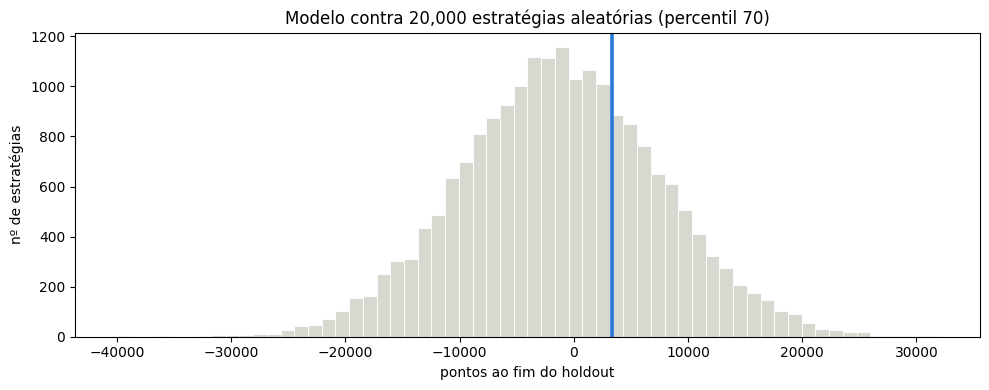

In [48]:
# =====================================================================
# A.26: P&L do holdout contra estratégias aleatórias
# Reproduz: seção *Teste 2, o P&L contra o acaso*: "o modelo cai no percentil 78 de 20.000 sorteios"
# Referência: White (2000), A Reality Check for Data Snooping
# =====================================================================
if globals().get("EXECUTAR_HOLDOUT") and "bt_h" in globals():
    _obs, _nop = bt_h["pontos_liquidos"], bt_h["operações"]
    _ret_h = retorno_alvo.reindex(y_hold.index).values
    _rg4 = np.random.default_rng(0)
    _N = 20_000
    _pnl = np.array([(_rg4.choice([1.0, -1.0], _nop) *
                      _ret_h[_rg4.choice(len(_ret_h), _nop, replace=False)]).sum()
                     - _nop * CUSTO_PONTOS for _ in range(_N)])
    print(f"{_N:,} estratégias aleatórias com as mesmas {_nop} operações e o mesmo custo:")
    print(f"   média ............. {_pnl.mean():>12,.0f} pts")
    print(f"   desvio-padrão ..... {_pnl.std():>12,.0f} pts")
    print(f"   percentil 5 / 95 .. {np.percentile(_pnl, 5):>12,.0f} / {np.percentile(_pnl, 95):,.0f}")
    print(f"\n   modelo no holdout . {_obs:>12,.0f} pts")
    print(f"   z ................. {(_obs - _pnl.mean()) / _pnl.std():>12.2f}")
    print(f"   p (unilateral) .... {(_pnl >= _obs).mean():>12.4f}")
    print(f"   percentil do modelo {100 * (_pnl < _obs).mean():>11.0f}%")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(_pnl, bins=60, color="#d8d7d0", edgecolor="white", linewidth=0.6)
    ax.axvline(_obs, color="#2a78d6", lw=2.6)
    ax.set_xlabel("pontos ao fim do holdout"); ax.set_ylabel("nº de estratégias")
    ax.set_title(f"Modelo contra {_N:,} estratégias aleatórias "
                 f"(percentil {100 * (_pnl < _obs).mean():.0f})")
    plt.tight_layout(); plt.show()
else:
    print("holdout não executado nesta rodada.")

In [49]:
# =====================================================================
# A.27: Seleção de features: as quatro tabelas da seção *Quais features usar, e por que não cortar nenhuma*
# Reproduz: as 7 configurações, o controle contra sorteio aleatório,
#           a seleção aninhada dentro do fold e o achado contexto x janela
# Custo: ~5 min
# =====================================================================
from sklearn.feature_selection import mutual_info_classif as _mic
from scipy.stats import kruskal as _kruskal, t as _tdist

_SEM = list(range(5))                       # a seção *Quais features usar, e por que não cortar nenhuma* usa 5 sementes


def _avaliar(cols, sementes=_SEM):
    """Acurácia média e ganho sobre o baseline, no walk-forward."""
    _r = [walk_forward(ctor, X_trab[list(cols)], y_trab, semente=_s) for _s in sementes]
    _a = np.array([x["acc"] for x in _r])
    _g = np.array([x["ganho"] for x in _r])
    return _a.mean(), _a.std(ddof=1) if len(_a) > 1 else 0.0, _g.mean()


# ── rankings, recalculados aqui para a célula ser autossuficiente ──
_mi = pd.Series(_mic(StandardScaler().fit_transform(X_trab), y_trab, random_state=0),
                index=X_trab.columns).sort_values(ascending=False)
_kw = pd.Series({c: _kruskal(*[X_trab[c][y_trab == k] for k in CLASSES])[1]
                 for c in X_trab.columns}).sort_values()

# ── "sem redundância > 0,8": descarta o segundo de cada par correlacionado ──
_C = X_trab.corr().abs()
_dropar = set()
for _a in X_trab.columns:
    for _b in X_trab.columns:
        if _a < _b and _C.loc[_a, _b] > 0.8 and _a not in _dropar and _b not in _dropar:
            _dropar.add(_b)
_sem_red = [c for c in X_trab.columns if c not in _dropar]

CONFIGS = {
    "Todas":                  list(X_trab.columns),
    "Só contexto diário":     COLUNAS_CONTEXTO,
    "Sem redundância > 0,8":  _sem_red,
    "Só a janela":            COLUNAS_JANELA,
    "MI top-10":              list(_mi.index[:10]),
    "Kruskal top-3":          list(_kw.index[:3]),
    "MI top-5":               list(_mi.index[:5]),
}

print("TABELA 1 — as sete configurações\n")
print(f"{'configuração':<24}{'nº':>4}{'acurácia':>11}{'±dp':>9}{'ganho':>9}"
      f"{'vs Todas':>11}{'t':>7}{'p':>8}")
_res, _dps = {}, {}
for _nome, _cols in CONFIGS.items():
    _a, _d, _g = _avaliar(_cols)
    _res[_nome], _dps[_nome] = _a, _d
    if _nome == "Todas":
        print(f"{_nome:<24}{len(_cols):>4}{_a:>11.4f}{_d:>9.4f}{_g:>+9.4f}{'n/d':>11}"
              f"{'':>7}{'':>8}")
        continue
    # teste t de duas amostras, 5 sementes de cada lado, gl = 4
    _dif = _a - _res["Todas"]
    _ep = np.sqrt(_d ** 2 / len(_SEM) + _dps["Todas"] ** 2 / len(_SEM))
    _t = _dif / _ep
    _p = 2 * (1 - _tdist.cdf(abs(_t), len(_SEM) - 1))
    print(f"{_nome:<24}{len(_cols):>4}{_a:>11.4f}{_d:>9.4f}{_g:>+9.4f}{_dif:>+11.4f}"
          f"{_t:>+7.2f}{_p:>8.3f}")
print(f"\n{len(CONFIGS) - 1} comparações contra 'Todas' -> "
      f"limiar de Bonferroni = {0.05 / (len(CONFIGS) - 1):.4f}")

print("\n\nTABELA 2 — controle: escolha por métrica contra 20 sorteios do mesmo tamanho\n")
_rg = np.random.default_rng(0)
print(f"{'tamanho':>8}{'escolha por métrica':>24}{'aleatório (média ± dp)':>26}{'z':>8}")
for _k, _rot, _acc in ((5, "MI top-5", _res["MI top-5"]),
                       (10, "MI top-10", _res["MI top-10"]),
                       (3, "Kruskal top-3", _res["Kruskal top-3"])):
    _sorteios = [_avaliar(_rg.choice(X_trab.columns, _k, replace=False), sementes=[0])[0]
                 for _ in range(20)]
    _m, _s = np.mean(_sorteios), np.std(_sorteios, ddof=1)
    print(f"{_k:>8}{f'{_acc:.4f} ({_rot})':>24}{f'{_m:.4f} ± {_s:.4f}':>26}"
          f"{(_acc - _m) / _s:>+8.2f}")

print("\n\nTABELA 3 — seleção aninhada dentro de cada fold\n")
for _k in (5, 10):
    _accs, _escolhas = [], []
    for _s in _SEM:
        _pf = []
        for _itr, _ite in TimeSeriesSplit(n_splits=N_SPLITS).split(X_trab):
            _Xtr, _ytr = X_trab.iloc[_itr], y_trab.iloc[_itr]
            _mi_f = pd.Series(_mic(StandardScaler().fit_transform(_Xtr), _ytr, random_state=_s),
                              index=X_trab.columns).sort_values(ascending=False)
            _sel = list(_mi_f.index[:_k])
            if _s == 0:
                _escolhas.append(_sel)
            _sc = StandardScaler().fit(_Xtr[_sel])
            _m = ctor(_s).fit(_sc.transform(_Xtr[_sel]), _ytr)
            _pf.append(accuracy_score(y_trab.iloc[_ite],
                                      _m.predict(_sc.transform(X_trab.iloc[_ite][_sel]))))
        _accs.append(np.mean(_pf))
    print(f"Top-{_k} escolhido dentro do fold: {np.mean(_accs):.4f} ± {np.std(_accs, ddof=1):.4f}")
    if _k == 5:
        print("\n  o que cada fold escolheria (semente 0):")
        for _i, _e in enumerate(_escolhas, 1):
            print(f"    fold {_i}: {', '.join(_e)}")
        _todas = [f for _e in _escolhas for f in _e]
        _unicas = set(_todas)
        _em_todos = [f for f in _unicas if all(f in _e for _e in _escolhas)]
        print(f"\n  {len(_todas)} escolhas entre {len(_unicas)} features distintas")
        print(f"  aparecem nos 5 folds: {_em_todos or 'nenhuma'}")
        from collections import Counter
        _mais = Counter(_todas).most_common(1)[0]
        print(f"  mais escolhida: {_mais[0]} em {_mais[1]} de {len(_escolhas)} folds"
              f"  |  MI dela no conjunto todo = {_mi[_mais[0]]:.3f}"
              f", Kruskal p = {_kw[_mais[0]]:.2f}")

print(f"\n\nTABELA 4 — contexto contra janela\n")
print(f"{'':<24}{'nº':>4}{'acurácia':>11}")
print(f"{'Só contexto diário':<24}{len(COLUNAS_CONTEXTO):>4}{_res['Só contexto diário']:>11.4f}")
print(f"{'Só a janela':<24}{len(COLUNAS_JANELA):>4}{_res['Só a janela']:>11.4f}")
print(f"\nrazão amostra/feature com as {X_trab.shape[1]}: "
      f"{len(X_trab) / X_trab.shape[1]:.0f}:1")

TABELA 1 — as sete configurações

configuração              nº   acurácia      ±dp    ganho   vs Todas      t       p
Todas                     22     0.3511   0.0082  -0.0007        n/d               
Só contexto diário         5     0.3640   0.0044  +0.0121    +0.0128  +3.08   0.037
Sem redundância > 0,8     17     0.3560   0.0069  +0.0042    +0.0049  +1.03   0.362
Só a janela               17     0.3479   0.0073  -0.0040    -0.0032  -0.65   0.550
MI top-10                 10     0.3378   0.0082  -0.0141    -0.0133  -2.57   0.062
Kruskal top-3              3     0.3578   0.0049  +0.0059    +0.0067  +1.56   0.194
MI top-5                   5     0.3452   0.0051  -0.0067    -0.0059  -1.37   0.243

6 comparações contra 'Todas' -> limiar de Bonferroni = 0.0083


TABELA 2 — controle: escolha por métrica contra 20 sorteios do mesmo tamanho

 tamanho     escolha por métrica    aleatório (média ± dp)       z
       5       0.3452 (MI top-5)           0.3375 ± 0.0161   +0.48
      10      0.3

---

## Referências

Cada entrada indica **onde no notebook ela é usada**. Métodos que só aparecem como
implementação de biblioteca (scikit-learn, TensorFlow) estão citados pela fonte original do
método, não pela documentação da biblioteca.

### Protocolo, validação e o risco de se enganar

| Referência | Onde é usada |
|---|---|
| Bergmeir, C., & Benítez, J. M. (2012). *On the use of cross-validation for time series predictor evaluation.* Information Sciences, 191, 192–213. | seção *Walk-forward, não validação cruzada normal*, por que a validação é cronológica e não embaralhada |
| Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3ª ed. OTexts. | seção *Walk-forward, não validação cruzada normal*, walk-forward e avaliação de séries temporais |
| Good, P. (2005). *Permutation, Parametric, and Bootstrap Tests of Hypotheses*, 3ª ed. Springer. | seção *Teste de permutação*, teste de permutação |
| Gelman, A., & Loken, E. (2014). *The Statistical Crisis in Science.* American Scientist, 102(6), 460–465. | seção *Eliminar uma hipótese não confirma a alternativa* e seção *Holdout final*, o "jardim dos caminhos que se bifurcam": decisões tomadas depois de ver o dado |
| Nosek, B. A., Ebersole, C. R., DeHaven, A. C., & Mellor, D. T. (2018). *The preregistration revolution.* PNAS, 115(11), 2600–2606. | seção *Veredito*, escrever a regra de decisão antes de abrir o holdout |
| White, H. (2000). *A Reality Check for Data Snooping.* Econometrica, 68(5), 1097–1126. | introdução e seção *Teste 2, o P&L contra o acaso*, o máximo de várias tentativas é grande por construção |
| Sullivan, R., Timmermann, A., & White, H. (1999). *Data-Snooping, Technical Trading Rule Performance, and the Bootstrap.* Journal of Finance, 54(5), 1647–1691. | seção *O que vem depois*, por que a lista de variantes é fechada antes de rodar |
| Bailey, D. H., & López de Prado, M. (2014). *The Deflated Sharpe Ratio.* Journal of Portfolio Management, 40(5), 94–107. | seção *Avaliação econômica*, backtests inflados por seleção |
| David, H. A., & Nagaraja, H. N. (2003). *Order Statistics*, 3ª ed. Wiley. | introdução e Anexo A.1, valor esperado do máximo de *n* sorteios |

### Tamanho de amostra e razão amostra/feature

| Referência | Onde é usada |
|---|---|
| Peduzzi, P., Concato, J., Kemper, E., Holford, T. R., & Feinstein, A. R. (1996). *A simulation study of the number of events per variable in logistic regression analysis.* Journal of Clinical Epidemiology, 49(12), 1373–1379. | seção *Engenharia de features*, origem da regra prática de pelo menos 10 amostras por parâmetro |
| van der Ploeg, T., Austin, P. C., & Steyerberg, E. W. (2014). *Modern modelling techniques are data hungry: a simulation study for predicting dichotomous endpoints.* BMC Medical Research Methodology, 14, 137. | seção *Engenharia de features*, a regra generalizada (e mais severa) para modelos não lineares além da regressão |

### Comparação de modelos e múltiplos testes

| Referência | Onde é usada |
|---|---|
| Demšar, J. (2006). *Statistical Comparisons of Classifiers over Multiple Data Sets.* JMLR, 7, 1–30. | seção *Friedman + Nemenyi*, o procedimento Friedman + Nemenyi e a distância crítica |
| Friedman, M. (1937). *The Use of Ranks to Avoid the Assumption of Normality Implicit in the Analysis of Variance.* JASA, 32(200), 675–701. | seção *Friedman + Nemenyi*, o teste de Friedman |
| Nemenyi, P. (1963). *Distribution-free Multiple Comparisons.* Tese de doutorado, Princeton University. | seção *Friedman + Nemenyi*, o pós-teste |
| Kruskal, W. H., & Wallis, W. A. (1952). *Use of Ranks in One-Criterion Variance Analysis.* JASA, 47(260), 583–621. | seção *Análise exploratória*, comparação das features entre as três classes |
| Dunn, O. J. (1961). *Multiple Comparisons Among Means.* JASA, 56(293), 52–64. | seção *Análise exploratória*, a correção de Bonferroni sobre os 21 testes |

### Informação mútua e análise exploratória

| Referência | Onde é usada |
|---|---|
| Kraskov, A., Stögbauer, H., & Grassberger, P. (2004). *Estimating mutual information.* Physical Review E, 69, 066138. | seção *Análise exploratória*, o estimador por k-vizinhos usado pelo `mutual_info_classif` |
| Ross, B. C. (2014). *Mutual Information between Discrete and Continuous Data Sets.* PLoS ONE, 9(2), e87357. | seção *Análise exploratória*, a variante para alvo discreto, que é o caso aqui |
| Beyer, K., Goldstein, J., Ramakrishnan, R., & Shaft, U. (1999). *When Is "Nearest Neighbor" Meaningful?* ICDT '99, 217–235. | seção *Rotulagem* e Anexo A.12, concentração de distâncias em alta dimensão |

### Clusterização

| Referência | Onde é usada |
|---|---|
| Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise.* KDD '96, 226–231. | seção *Rotulagem*, o DBSCAN e o parâmetro `eps` |
| Rousseeuw, P. J. (1987). *Silhouettes: a graphical aid to the interpretation and validation of cluster analysis.* Journal of Computational and Applied Mathematics, 20, 53–65. | seção *Rotulagem*, a silhueta como medida de estrutura de agrupamento |
| Hubert, L., & Arabie, P. (1985). *Comparing partitions.* Journal of Classification, 2(1), 193–218. | seção *Rotulagem*, o Adjusted Rand Index e a instabilidade do rótulo no tempo |

### Modelos tabulares

| Referência | Onde é usada |
|---|---|
| Cortes, C., & Vapnik, V. (1995). *Support-Vector Networks.* Machine Learning, 20(3), 273–297. | seção *Modelos tabulares* e Anexo A.18, o SVM e o papel dos vetores de suporte |
| Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1), 5–32. | seção *Modelos tabulares* |
| Friedman, J. H. (2001). *Greedy Function Approximation: A Gradient Boosting Machine.* Annals of Statistics, 29(5), 1189–1232. | seção *Modelos tabulares*, o Gradient Boosting |
| Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* KDD '16, 785–794. | seção *Modelos tabulares* |

### Redes neurais e modelagem de sequências

| Referência | Onde é usada |
|---|---|
| Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory.* Neural Computation, 9(8), 1735–1780. | seção *Modelos sequenciais (deep learning)*, a LSTM e o estado interno |
| Cho, K., van Merriënboer, B., Gulcehre, C., et al. (2014). *Learning Phrase Representations using RNN Encoder–Decoder.* EMNLP, 1724–1734. | seção *Modelos sequenciais (deep learning)*, a GRU |
| Bai, S., Kolter, J. Z., & Koltun, V. (2018). *An Empirical Evaluation of Generic Convolutional and Recurrent Networks for Sequence Modeling.* arXiv:1803.01271. | seção *Modelos sequenciais (deep learning)*, a TCN, convolução dilatada e campo receptivo |
| Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need.* NeurIPS, 5998–6008. | seção *Modelos sequenciais (deep learning)*, o Transformer e a auto-atenção |
| Dempster, A., Petitjean, F., & Webb, G. I. (2020). *ROCKET: exceptionally fast and accurate time series classification using random convolutional kernels.* Data Mining and Knowledge Discovery, 34, 1454–1495. | seção *Modelos sequenciais (deep learning)*, o método que ainda quero testar |
| Dempster, A., Schmidt, D. F., & Webb, G. I. (2021). *MiniRocket: A Very Fast (Almost) Deterministic Transform for Time Series Classification.* KDD '21, 248–257. | seção *Modelos sequenciais (deep learning)* |
| Srivastava, N., Hinton, G., Krizhevsky, A., et al. (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting.* JMLR, 15, 1929–1958. | seção *Dropout, e por que 0,5 e não 0,8* |
| Kingma, D. P., & Ba, J. (2015). *Adam: A Method for Stochastic Optimization.* ICLR. | seção *Adam e a taxa de aprendizado* |
| Ioffe, S., & Szegedy, C. (2015). *Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift.* ICML, 448–456. | seção *Modelos sequenciais (deep learning)*, nas arquiteturas com normalização de lote |
| Prechelt, L. (1998). *Early Stopping, But When?* In: Neural Networks: Tricks of the Trade. Springer, 55–69. | seção *Early stopping, e a armadilha de monitorar a métrica errada* e seção *A armadilha do `early stopping`: parar de treinar olhando o conjunto errado*, o early stopping e a armadilha de monitorar a métrica errada |
| Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning.* MIT Press. | seção *Configuração das redes: cada peça e por que este valor*, regularização L1/L2, softmax e entropia cruzada |

### Séries temporais financeiras

| Referência | Onde é usada |
|---|---|
| Box, G. E. P., & Jenkins, G. M. (1970). *Time Series Analysis: Forecasting and Control.* Holden-Day. | seção *Modelos tabulares*, a família ARIMA/SARIMA |
| Dickey, D. A., & Fuller, W. A. (1979). *Distribution of the Estimators for Autoregressive Time Series with a Unit Root.* JASA, 74(366), 427–431. | seção *Modelos tabulares* e Anexo A.19, o teste ADF de estacionariedade |
| Fama, E. F. (1970). *Efficient Capital Markets: A Review of Theory and Empirical Work.* Journal of Finance, 25(2), 383–417. | seção *Modelos tabulares* e seção *Conclusão*, por que o retorno se comporta como passeio aleatório |
| Engle, R. F. (1982). *Autoregressive Conditional Heteroscedasticity with Estimates of the Variance of United Kingdom Inflation.* Econometrica, 50(4), 987–1007. | seção *O que vem depois*, variante V4: volatilidade tem memória |
| Bollerslev, T. (1986). *Generalized Autoregressive Conditional Heteroskedasticity.* Journal of Econometrics, 31(3), 307–327. | seção *O que vem depois*, variante V4 |
| Cont, R. (2001). *Empirical properties of asset returns: stylized facts and statistical issues.* Quantitative Finance, 1(2), 223–236. | seção *Análise exploratória* e seção *O que vem depois*, agrupamento de volatilidade e ausência de autocorrelação nos retornos |

---

### Uma nota sobre o que estas referências sustentam, e o que não

As referências acima sustentam os **métodos**: por que o Friedman é o teste adequado para
comparar vários classificadores, por que a silhueta mede o que mede, o que a auto-atenção faz.

Elas **não** sustentam os **resultados** deste notebook. Os números daqui vieram de medição
nesta base específica, e estão reproduzíveis no **Anexo A**. Onde um número aparece no texto,
ou ele sai de uma célula de código acima dele, ou há um anexo indicado.

A distinção importa porque é comum ver trabalho que cita literatura para dar credibilidade a
um resultado que a literatura não avaliou. Aqui a literatura responde por *como medir*; a
resposta sobre *o que foi medido* está no código.
